In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Paths for the processed data and TSFRESH features
processed_train_path = 'data/processed/train_transformed_combined.csv'
processed_test_path = 'data/processed/test_transformed_combined.csv'
tsfresh_train_path = 'data/tsfresh/train_combined_all_features_filled.csv'
tsfresh_test_path = 'data/tsfresh/test_combined_all_features_filled.csv'

# Load data
train_combined = pd.read_csv(processed_train_path, index_col='Date', parse_dates=True)
test_combined = pd.read_csv(processed_test_path, index_col='Date', parse_dates=True)
tsfresh_features_train = pd.read_csv(tsfresh_train_path, index_col='Date', parse_dates=True)
tsfresh_features_test = pd.read_csv(tsfresh_test_path, index_col='Date', parse_dates=True)

# Selected targets and their respective features
target_features = {
    'FEDFUNDS': ['UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2'],
    'CPIAUCSL': [
        'PCEPI__fft_coefficient__attr_"angle"__coeff_0', 
        'CUSR0000SAH1__large_standard_deviation__r_0.25',
        'CUMFNS__large_standard_deviation__r_0.30000000000000004',
        'CPILFESL__large_standard_deviation__r_0.30000000000000004',
        'DGS10__longest_strike_below_mean',
        'HOUST__number_peaks__n_50',
        'CUMFNS__has_duplicate_min',
        'BAA__sum_of_reoccurring_values',
        'CPIAUCSL__large_standard_deviation__r_0.4'
    ],
    'PRFI': ['PCEPI__longest_strike_below_mean']
}

# Model parameters
xgboost_params = {'max_depth': 9, 'learning_rate': 0.0168, 'n_estimators': 193, 'min_child_weight': 3, 'subsample': 0.5866, 'colsample_bytree': 0.9177, 'reg_alpha': 0.0125, 'reg_lambda': 8.577e-05, 'verbosity': 0}
lightgbm_params = {'num_leaves': 119, 'learning_rate': 0.0832, 'n_estimators': 71, 'max_depth': 3, 'min_child_samples': 18, 'subsample': 0.7402, 'colsample_bytree': 0.9405, 'reg_alpha': 0.000756, 'reg_lambda': 0.000259, 'verbosity': -1}

# Function to compute MSE
def compute_mse(X_train, X_test, y_train, y_test, features):
    X_train = X_train[features].dropna()
    X_test = X_test[features].dropna()
    y_train = y_train.dropna()
    y_test = y_test.dropna()

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    mse_scores = {}

    # XGBoost
    xgb_model = XGBRegressor(**xgboost_params)
    xgb_model.fit(X_train_scaled, y_train)
    y_pred_xgb = xgb_model.predict(X_test_scaled)
    mse_scores['XGBoost'] = mean_squared_error(y_test, y_pred_xgb)

    # LightGBM
    lgb_model = LGBMRegressor(**lightgbm_params)
    lgb_model.fit(X_train_scaled, y_train)
    y_pred_lgb = lgb_model.predict(X_test_scaled)
    mse_scores['LightGBM'] = mean_squared_error(y_test, y_pred_lgb)

    return mse_scores

# Evaluate the selected targets
results = {}
for target, features in target_features.items():
    print(f"\nEvaluating target: {target}")
    X_train = tsfresh_features_train[features]
    X_test = tsfresh_features_test[features]
    y_train = train_combined[[target]].dropna()
    y_test = test_combined[[target]].dropna()

    mse_scores = compute_mse(X_train, X_test, y_train, y_test, features)
    results[target] = mse_scores
    # print number of features
    print(f"Number of features: {len(features)}")
    print(f"XGBoost MSE: {mse_scores['XGBoost']}")
    print(f"LightGBM MSE: {mse_scores['LightGBM']}")

# Display results
print("\nFinal MSE Results:")
for target, mse in results.items():
    print(f"Target: {target}, XGBoost MSE: {mse['XGBoost']}, LightGBM MSE: {mse['LightGBM']}")



Evaluating target: FEDFUNDS


c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Number of features: 1
XGBoost MSE: 0.007369381570450693
LightGBM MSE: 0.006462867402757572

Evaluating target: CPIAUCSL


c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Number of features: 9
XGBoost MSE: 3.800471050499076e-05
LightGBM MSE: 3.8607107130609205e-05

Evaluating target: PRFI


c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Number of features: 1
XGBoost MSE: 0.0003052800622916007
LightGBM MSE: 0.0003018709799264559

Final MSE Results:
Target: FEDFUNDS, XGBoost MSE: 0.007369381570450693, LightGBM MSE: 0.006462867402757572
Target: CPIAUCSL, XGBoost MSE: 3.800471050499076e-05, LightGBM MSE: 3.8607107130609205e-05
Target: PRFI, XGBoost MSE: 0.0003052800622916007, LightGBM MSE: 0.0003018709799264559


NameError: name 'results_df' is not defined

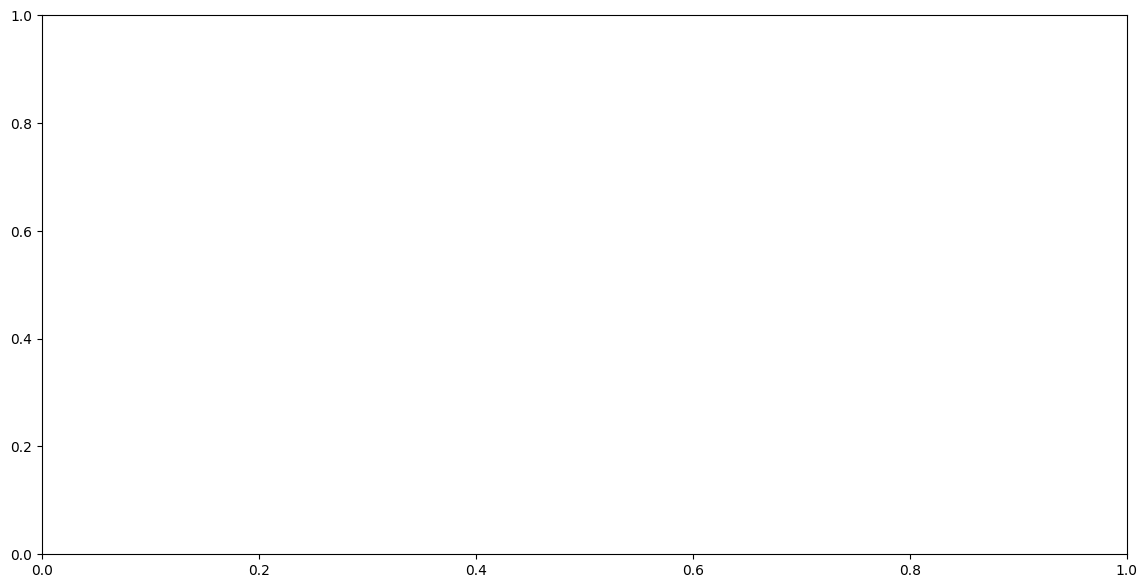

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'results_df' contains 'Target', 'XGBoost_MSE', 'LightGBM_MSE', and 'Num_Features'

# Create a figure and axis
fig, ax1 = plt.subplots(figsize=(14, 7))

# Bar plot for the number of features
bar_width = 0.35
index = np.arange(len(results_df))

bars = ax1.bar(index, results_df['Num_Features'], bar_width, color='lightgray', label='Number of Features')

# Set up the first y-axis for the number of features
ax1.set_xlabel('Targets')
ax1.set_ylabel('Number of Features', color='black')
ax1.set_xticks(index)
ax1.set_xticklabels(results_df['Target'], rotation=45, ha='right')

# Create a secondary y-axis for the MSE scores
ax2 = ax1.twinx()

# Plot XGBoost MSE as a line plot
ax2.plot(index, results_df['XGBoost_MSE'], color='blue', marker='o', linestyle='-', label='XGBoost MSE')

# Plot LightGBM MSE as a line plot
ax2.plot(index, results_df['LightGBM_MSE'], color='green', marker='s', linestyle='-', label='LightGBM MSE')

# Set up the second y-axis for the MSE scores
ax2.set_ylabel('MSE Score', color='black')

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')

# Add a grid and show the plot
ax1.grid(True)
plt.title('Relationship Between Number of Features and MSE Scores Across All Targets')
plt.tight_layout()
plt.show()


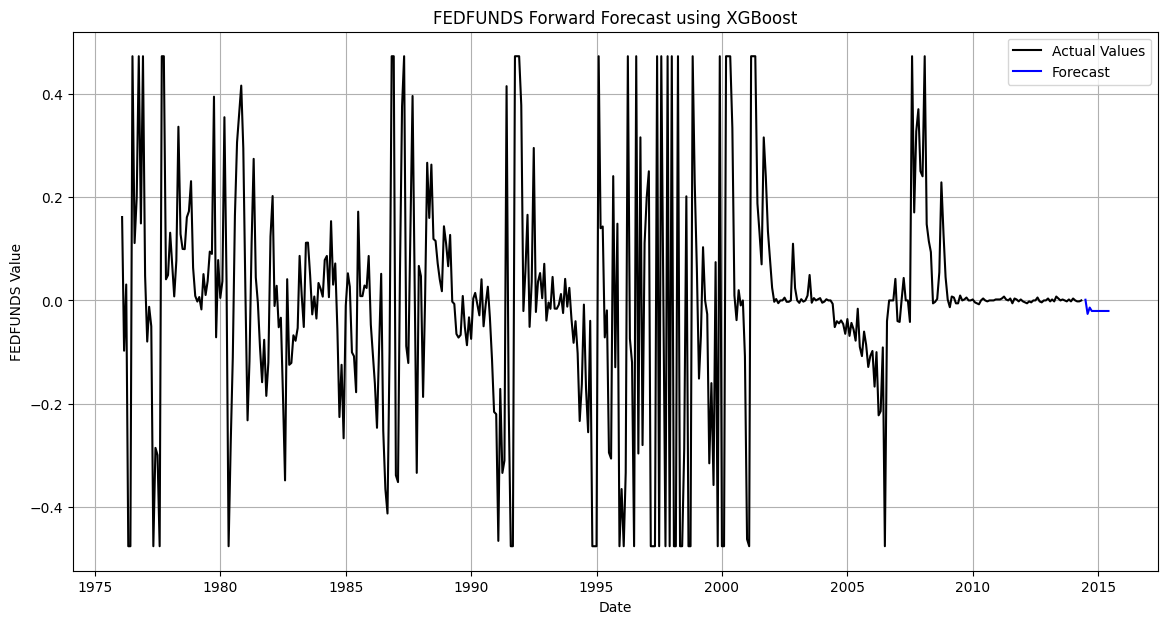

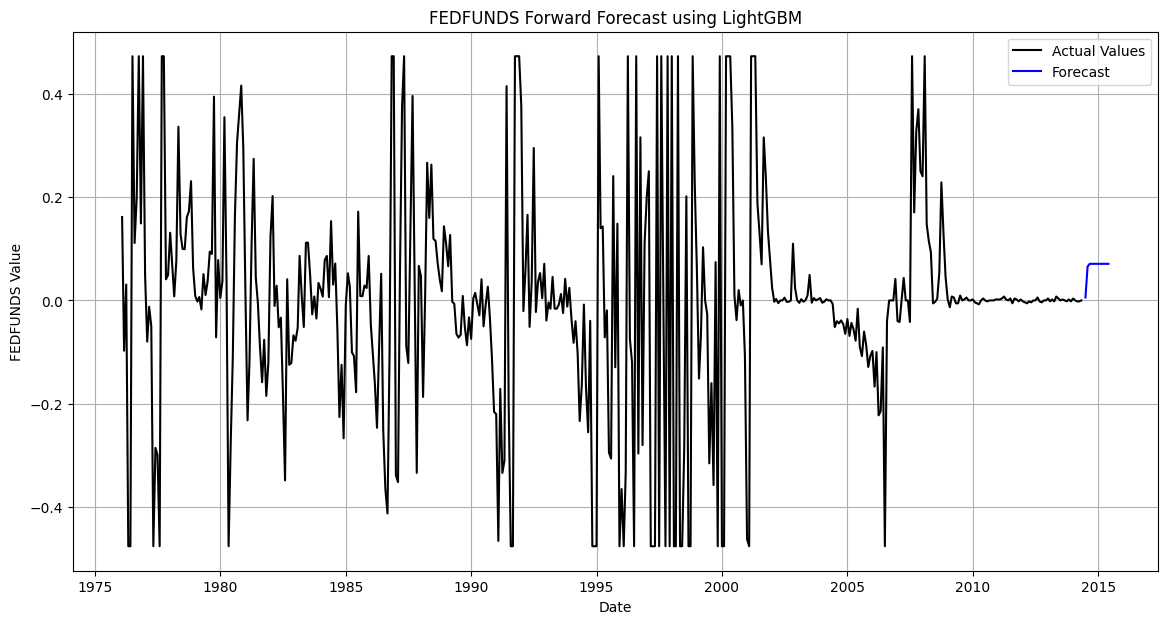

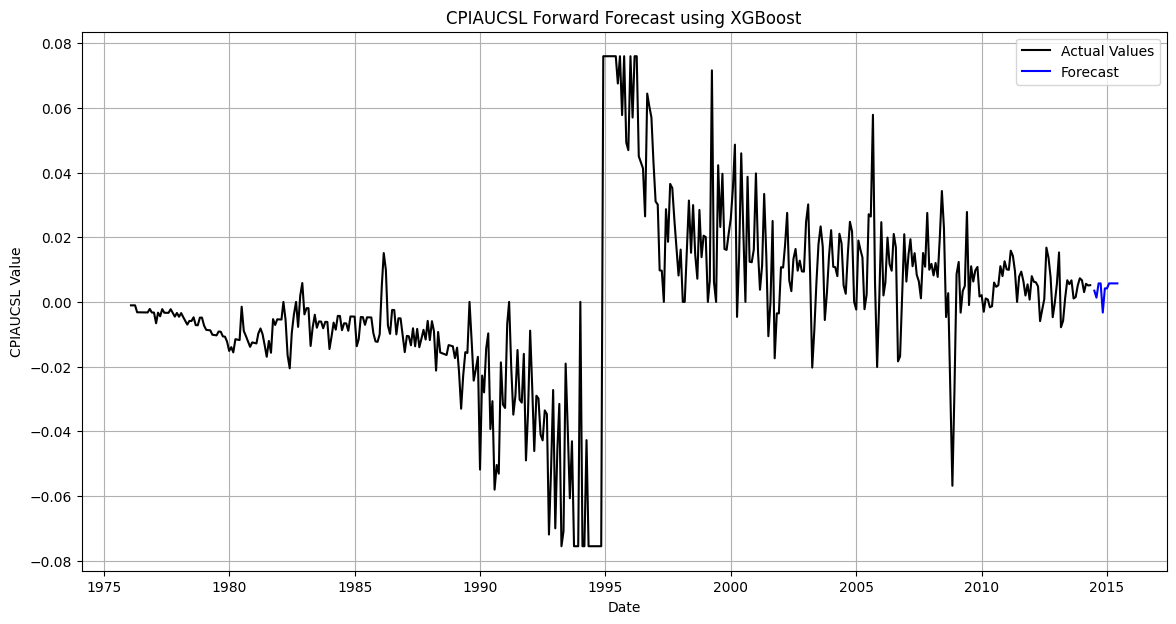

c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\lightgbm\basic.py:696: UserWarning: Usage of np.ndarray subset (sliced data) is not recommended due to it will double the peak memory cost in LightGBM.
  _log_warning("Usage of np.ndarray subset (sliced data) is not recommended "


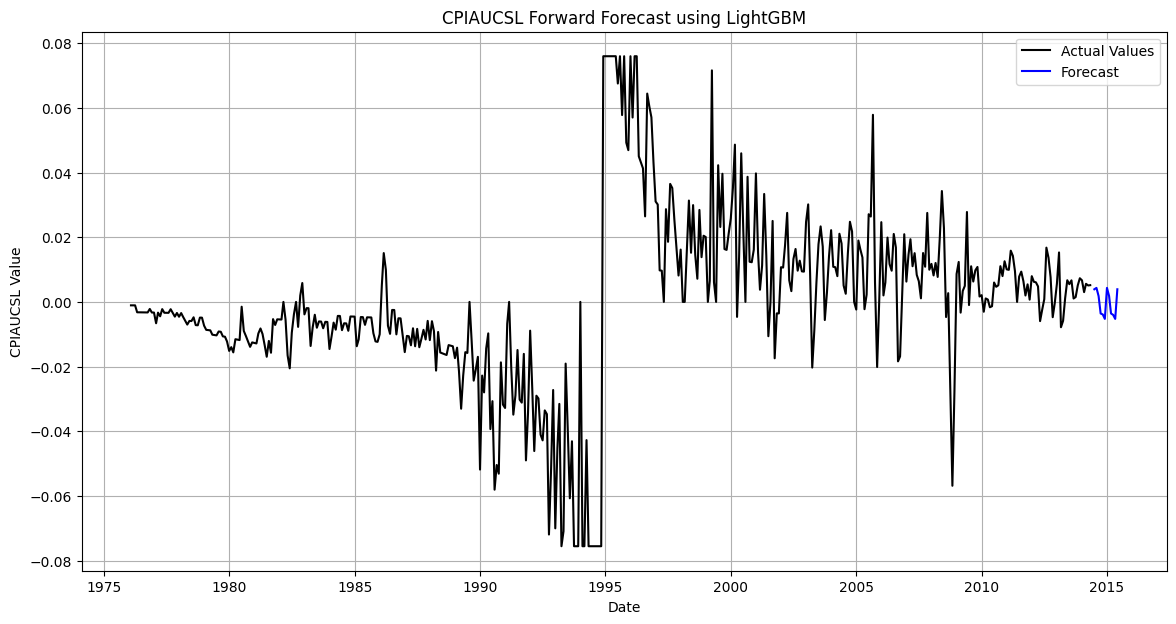

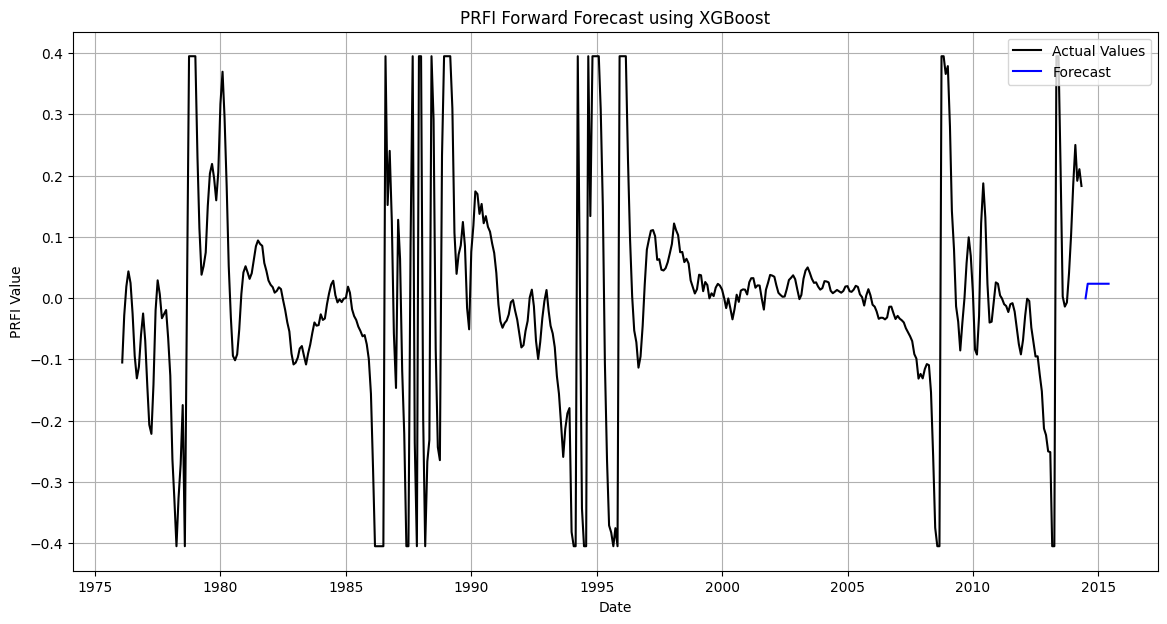

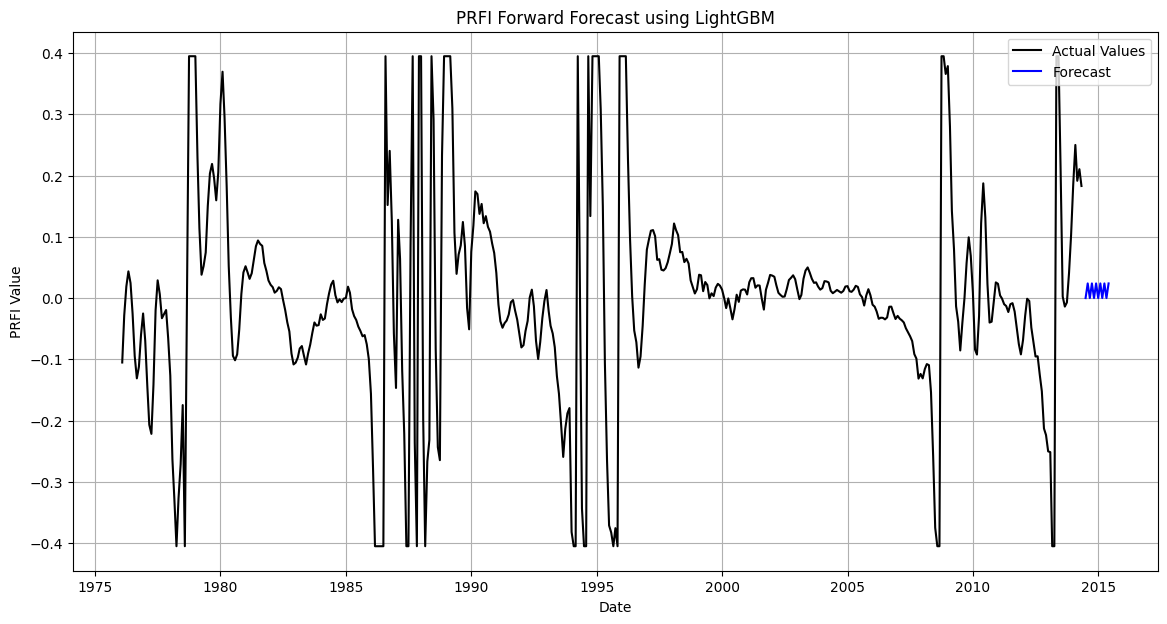

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import StandardScaler

# Define a function to make forward forecasts and plot results
def forecast_and_plot_forward(target, X_all, y_all, future_dates, forecast_steps, model_name, model_params):
    # Initialize the model
    if model_name == 'XGBoost':
        model = XGBRegressor(**model_params)
    elif model_name == 'LightGBM':
        model = LGBMRegressor(**model_params)
    else:
        raise ValueError(f"Unsupported model name: {model_name}")

    # Scale the data
    scaler = StandardScaler()
    X_all_scaled = scaler.fit_transform(X_all)

    # Fit the model on the entire data
    model.fit(X_all_scaled, y_all)

    # Initialize the forecast input with the last available data point
    X_last = X_all_scaled[-1].reshape(1, -1)

    # Perform iterative forecasting
    forecast = []
    for step in range(forecast_steps):
        y_pred = model.predict(X_last)
        forecast.append(y_pred[0])

        # Update the input for the next step
        X_last = np.append(X_last[:, 1:], y_pred).reshape(1, -1)  # Shift and append the predicted value

    # Plot the results
    plt.figure(figsize=(14, 7))
    plt.plot(X_all.index, y_all, label='Actual Values', color='black')
    plt.plot(future_dates, forecast, label='Forecast', color='blue')
    plt.title(f'{target} Forward Forecast using {model_name}')
    plt.xlabel('Date')
    plt.ylabel(f'{target} Value')
    plt.legend()
    plt.grid(True)
    plt.show()

# Load the data
train_combined = pd.read_csv(processed_train_path, index_col='Date', parse_dates=True)
tsfresh_features_train = pd.read_csv(tsfresh_train_path, index_col='Date', parse_dates=True)

# Targets and model parameters
targets = ['FEDFUNDS', 'CPIAUCSL', 'PRFI']
forecast_steps = 12  # Example: Forecast for the next 12 months

# Example future dates (you should provide realistic future dates based on your data's frequency)
last_date = train_combined.index[-1]
future_dates = pd.date_range(last_date, periods=forecast_steps + 1, freq='M')[1:]

# Iterate over each target and model
for target in targets:
    # Prepare data
    y_all = train_combined[[target]].dropna().values.ravel()

    # Use the features selected earlier for this target
    selected_features = pd.read_csv(f'{target}_final_features.csv')['features'].tolist()
    X_all = tsfresh_features_train[selected_features].dropna()

    # Forecast with XGBoost
    forecast_and_plot_forward(target, X_all, y_all, future_dates, forecast_steps, 'XGBoost', xgboost_params)

    # Forecast with LightGBM
    forecast_and_plot_forward(target, X_all, y_all, future_dates, forecast_steps, 'LightGBM', lightgbm_params)


In [ ]:
GDP_features = pd.read_csv('GDP_final_features.csv')['features'].tolist()
print(len(GDP_features))
print(GDP_features)

2
['CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2', 'CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4']


In [16]:
# Example text input
text_data = r"""
Processing target: FEDFUNDS
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2', 'BAA__large_standard_deviation__r_0.2', 'UNRATE__fft_coefficient__attr_"angle"__coeff_0']
Added feature: UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2 with improvement: inf
Added feature: BAA__large_standard_deviation__r_0.2 with improvement: inf
Added feature: UNRATE__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 0.01306229199186499
New MSE for XGBoost: 0.006397485030696956
New MSE for LightGBM: 0.006664806961168034

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['BAA__large_standard_deviation__r_0.2', 'UNRATE__fft_coefficient__attr_"angle"__coeff_0', 'UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2']
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.01306229199186499
Final MSE for XGBoost: 0.006397485030696956
Final MSE for LightGBM: 0.006664806961168034

---- Round 2 of feature addition ----
Top features considered for addition: ['INDPRO__minimum', 'FGCE__has_duplicate_min', 'EXPGS__fft_coefficient__attr_"angle"__coeff_0']
Added feature: INDPRO__minimum with improvement: 0.0005281316768375385
Added feature: FGCE__has_duplicate_min with improvement: 0.0004899539741174339
Added feature: EXPGS__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0004461558488607492
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 0.014753815754698557
New MSE for XGBoost: 0.008312239865952534
New MSE for LightGBM: 0.006441575888746022

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['FGCE__has_duplicate_min', 'INDPRO__minimum', 'EXPGS__fft_coefficient__attr_"angle"__coeff_0', 'UNRATE__fft_coefficient__attr_"angle"__coeff_0', 'BAA__large_standard_deviation__r_0.2', 'UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2']
Dropped feature: FGCE__has_duplicate_min with improvement: 0.002239380883096968
Dropped feature: INDPRO__minimum with improvement: 0.002117742220709422
Dropped feature: EXPGS__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.001996701180977112
Dropped feature: UNRATE__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0019683860838153634
Dropped feature: BAA__large_standard_deviation__r_0.2 with improvement: 0.0008554697444930134
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.013832248973208266
Final MSE for XGBoost: 0.007369381570450693
Final MSE for LightGBM: 0.006462867402757572

---- Round 3 of feature addition ----
Top features considered for addition: ['FEDFUNDS__minimum', 'FEDFUNDS__has_duplicate', 'CUMFNS__has_duplicate']
Added feature: FEDFUNDS__minimum with improvement: 0.001822623241452801
Added feature: FEDFUNDS__has_duplicate with improvement: 0.0017777071777526458
Added feature: CUMFNS__has_duplicate with improvement: 0.0017777071777526458
New aggregated MSE after addition: 0.014334092954883249
New MSE for XGBoost: 0.007871225552125676
New MSE for LightGBM: 0.006462867402757572

---- Round 3 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['FEDFUNDS__has_duplicate', 'CUMFNS__has_duplicate', 'FEDFUNDS__minimum', 'UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2']
Dropped feature: FEDFUNDS__has_duplicate with improvement: 0.0010590850888606233
Dropped feature: CUMFNS__has_duplicate with improvement: 0.0010590850888606233
Dropped feature: FEDFUNDS__minimum with improvement: 0.000861384455489651
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.013832248973208266
Final MSE for XGBoost: 0.007369381570450693
Final MSE for LightGBM: 0.006462867402757572

---- Round 4 of feature addition ----
Top features considered for addition: ['FEDFUNDS__minimum', 'FEDFUNDS__has_duplicate', 'CUMFNS__has_duplicate']
Added feature: FEDFUNDS__minimum with improvement: 0.0014029004416374925
Added feature: FEDFUNDS__has_duplicate with improvement: 0.0013579843779373373
Added feature: CUMFNS__has_duplicate with improvement: 0.0013579843779373373
New aggregated MSE after addition: 0.014334092954883249
New MSE for XGBoost: 0.007871225552125676
New MSE for LightGBM: 0.006462867402757572

---- Round 4 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['FEDFUNDS__has_duplicate', 'CUMFNS__has_duplicate', 'FEDFUNDS__minimum', 'UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2']
Dropped feature: FEDFUNDS__has_duplicate with improvement: 0.0010590850888606233
Dropped feature: CUMFNS__has_duplicate with improvement: 0.0010590850888606233
Dropped feature: FEDFUNDS__minimum with improvement: 0.000861384455489651
Final aggregated MSE after dropping: 0.013832248973208266
Final MSE for XGBoost: 0.007369381570450693
Final MSE for LightGBM: 0.006462867402757572

---- Round 5 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['FEDFUNDS__minimum', 'FEDFUNDS__has_duplicate', 'CUMFNS__has_duplicate']
Added feature: FEDFUNDS__minimum with improvement: 0.0014029004416374925
Added feature: FEDFUNDS__has_duplicate with improvement: 0.0013579843779373373
Added feature: CUMFNS__has_duplicate with improvement: 0.0013579843779373373
New aggregated MSE after addition: 0.014334092954883249
New MSE for XGBoost: 0.007871225552125676
New MSE for LightGBM: 0.006462867402757572

---- Round 5 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['FEDFUNDS__has_duplicate', 'CUMFNS__has_duplicate', 'FEDFUNDS__minimum', 'UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2']
Dropped feature: FEDFUNDS__has_duplicate with improvement: 0.0010590850888606233
Dropped feature: CUMFNS__has_duplicate with improvement: 0.0010590850888606233
Dropped feature: FEDFUNDS__minimum with improvement: 0.000861384455489651
Final aggregated MSE after dropping: 0.013832248973208266
Final MSE for XGBoost: 0.007369381570450693
Final MSE for LightGBM: 0.006462867402757572

Processing target: GDP
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2', 'WTISPLC__index_mass_quantile__q_0.4', 'CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4']
Added feature: CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2 with improvement: inf
Added feature: WTISPLC__index_mass_quantile__q_0.4 with improvement: inf
Added feature: CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4 with improvement: inf
New aggregated MSE after addition: 0.00025059257595974886
New MSE for XGBoost: 0.0001146259053508202
New MSE for LightGBM: 0.00013596667060892864

---- Round 1 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['WTISPLC__index_mass_quantile__q_0.4', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2', 'CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4']
Dropped feature: WTISPLC__index_mass_quantile__q_0.4 with improvement: 1.675701648792263e-06
Final aggregated MSE after dropping: 0.0002489168743109566
Final MSE for XGBoost: 0.00012544477858931284
Final MSE for LightGBM: 0.00012347209572164373

---- Round 2 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)', 'PNFI__index_mass_quantile__q_0.9', 'EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)']
Added feature: CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20) with improvement: 7.407920395650688e-05
Added feature: PNFI__index_mass_quantile__q_0.9 with improvement: 7.222773244357748e-05
Added feature: EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 6.982720979234182e-05
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 0.00021752647677760113
New MSE for XGBoost: 9.444042653769981e-05
New MSE for LightGBM: 0.0001230860502399013

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)', 'PNFI__index_mass_quantile__q_0.9', 'EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)', 'CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2']
Dropped feature: CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20) with improvement: 3.9328799832572203e-05
Dropped feature: PNFI__index_mass_quantile__q_0.9 with improvement: 3.2359086137034794e-05
Dropped feature: EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 1.651681491727532e-05
Final aggregated MSE after dropping: 0.0002489168743109566
Final MSE for XGBoost: 0.00012544477858931284
Final MSE for LightGBM: 0.00012347209572164373

---- Round 3 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)', 'PNFI__index_mass_quantile__q_0.9', 'EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)']
Added feature: CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20) with improvement: 4.1013104774359146e-05
Added feature: PNFI__index_mass_quantile__q_0.9 with improvement: 3.9161633261429745e-05
Added feature: EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 3.676111061019408e-05
New aggregated MSE after addition: 0.00021752647677760113
New MSE for XGBoost: 9.444042653769981e-05
New MSE for LightGBM: 0.0001230860502399013

---- Round 3 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)', 'PNFI__index_mass_quantile__q_0.9', 'EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)', 'CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2']
Dropped feature: CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20) with improvement: 3.9328799832572203e-05
Dropped feature: PNFI__index_mass_quantile__q_0.9 with improvement: 3.2359086137034794e-05
Dropped feature: EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 1.651681491727532e-05
Final aggregated MSE after dropping: 0.0002489168743109566
Final MSE for XGBoost: 0.00012544477858931284
Final MSE for LightGBM: 0.00012347209572164373

---- Round 4 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)', 'PNFI__index_mass_quantile__q_0.9', 'EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)']
Added feature: CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20) with improvement: 4.1013104774359146e-05
Added feature: PNFI__index_mass_quantile__q_0.9 with improvement: 3.9161633261429745e-05
Added feature: EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 3.676111061019408e-05
New aggregated MSE after addition: 0.00021752647677760113
New MSE for XGBoost: 9.444042653769981e-05
New MSE for LightGBM: 0.0001230860502399013

---- Round 4 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)', 'PNFI__index_mass_quantile__q_0.9', 'EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)', 'CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2']
Dropped feature: CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20) with improvement: 3.9328799832572203e-05
Dropped feature: PNFI__index_mass_quantile__q_0.9 with improvement: 3.2359086137034794e-05
Dropped feature: EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 1.651681491727532e-05
Final aggregated MSE after dropping: 0.0002489168743109566
Final MSE for XGBoost: 0.00012544477858931284
Final MSE for LightGBM: 0.00012347209572164373

---- Round 5 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)', 'PNFI__index_mass_quantile__q_0.9', 'EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)']
Added feature: CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20) with improvement: 4.1013104774359146e-05
Added feature: PNFI__index_mass_quantile__q_0.9 with improvement: 3.9161633261429745e-05
Added feature: EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 3.676111061019408e-05
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 0.00021752647677760113
New MSE for XGBoost: 9.444042653769981e-05
New MSE for LightGBM: 0.0001230860502399013

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)', 'PNFI__index_mass_quantile__q_0.9', 'EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)', 'CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2']
Dropped feature: CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20) with improvement: 3.9328799832572203e-05
Dropped feature: PNFI__index_mass_quantile__q_0.9 with improvement: 3.2359086137034794e-05
Dropped feature: EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 1.651681491727532e-05
Final aggregated MSE after dropping: 0.0002489168743109566
Final MSE for XGBoost: 0.00012544477858931284
Final MSE for LightGBM: 0.00012347209572164373

Processing target: CPIAUCSL
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['PCEPI__fft_coefficient__attr_"angle"__coeff_0', 'CUSR0000SAH1__large_standard_deviation__r_0.25', 'PCEPI__longest_strike_below_mean']
Added feature: PCEPI__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf
Added feature: CUSR0000SAH1__large_standard_deviation__r_0.25 with improvement: inf
Added feature: PCEPI__longest_strike_below_mean with improvement: inf
New aggregated MSE after addition: 7.941932364033371e-05
New MSE for XGBoost: 3.9189618577848856e-05
New MSE for LightGBM: 4.0229705062484854e-05

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['PCEPI__longest_strike_below_mean', 'CUSR0000SAH1__large_standard_deviation__r_0.25', 'PCEPI__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: PCEPI__longest_strike_below_mean with improvement: 2.3792215571331258e-07
Final aggregated MSE after dropping: 7.91814014846204e-05
Final MSE for XGBoost: 3.909123010970776e-05
Final MSE for LightGBM: 4.0090171374912644e-05

---- Round 2 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['CUMFNS__large_standard_deviation__r_0.30000000000000004', 'CPILFESL__large_standard_deviation__r_0.30000000000000004', 'GDPCTPI__large_standard_deviation__r_0.30000000000000004']
Added feature: CUMFNS__large_standard_deviation__r_0.30000000000000004 with improvement: 1.8031120258758224e-06
Added feature: CPILFESL__large_standard_deviation__r_0.30000000000000004 with improvement: 1.5883855604859894e-06
Added feature: GDPCTPI__large_standard_deviation__r_0.30000000000000004 with improvement: 9.712509664379674e-07
New aggregated MSE after addition: 7.794753167936596e-05
New MSE for XGBoost: 3.875064441747111e-05
New MSE for LightGBM: 3.919688726189485e-05

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['GDPCTPI__large_standard_deviation__r_0.30000000000000004', 'CUMFNS__large_standard_deviation__r_0.30000000000000004', 'CPILFESL__large_standard_deviation__r_0.30000000000000004', 'PCEPI__fft_coefficient__attr_"angle"__coeff_0', 'CUSR0000SAH1__large_standard_deviation__r_0.25']
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 7.794753167936596e-05
Final MSE for XGBoost: 3.875064441747111e-05
Final MSE for LightGBM: 3.919688726189485e-05

---- Round 3 of feature addition ----
Top features considered for addition: ['DGS10__longest_strike_below_mean', 'PRFI__maximum', 'HOUST__number_peaks__n_50']
Added feature: DGS10__longest_strike_below_mean with improvement: 6.951694714755553e-07
Added feature: PRFI__maximum with improvement: 3.5225964513274535e-07
Added feature: HOUST__number_peaks__n_50 with improvement: 3.450650214583621e-07
New aggregated MSE after addition: 7.76947932681114e-05
New MSE for XGBoost: 3.8490372944404606e-05
New MSE for LightGBM: 3.9204420323706795e-05

---- Round 3 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['GDPCTPI__large_standard_deviation__r_0.30000000000000004', 'PRFI__maximum', 'HOUST__number_peaks__n_50', 'DGS10__longest_strike_below_mean', 'CPILFESL__large_standard_deviation__r_0.30000000000000004', 'CUMFNS__large_standard_deviation__r_0.30000000000000004', 'PCEPI__fft_coefficient__attr_"angle"__coeff_0', 'CUSR0000SAH1__large_standard_deviation__r_0.25']
Dropped feature: GDPCTPI__large_standard_deviation__r_0.30000000000000004 with improvement: 8.359737791206403e-07
Dropped feature: PRFI__maximum with improvement: 3.742428047996156e-07
Final aggregated MSE after dropping: 7.657108004839566e-05
Final MSE for XGBoost: 3.796397291778645e-05
Final MSE for LightGBM: 3.8607107130609205e-05

---- Round 4 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['CUMFNS__has_duplicate_min', 'BAA__sum_of_reoccurring_values', 'CPIAUCSL__large_standard_deviation__r_0.4']
Added feature: CUMFNS__has_duplicate_min with improvement: 1.0613473176439059e-06
Added feature: BAA__sum_of_reoccurring_values with improvement: 1.0541719509879743e-06
Added feature: CPIAUCSL__large_standard_deviation__r_0.4 with improvement: 1.0533717268531478e-06
New aggregated MSE after addition: 7.661181763559996e-05
New MSE for XGBoost: 3.800471050499076e-05
New MSE for LightGBM: 3.8607107130609205e-05

---- Round 4 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['BAA__sum_of_reoccurring_values', 'CPIAUCSL__large_standard_deviation__r_0.4', 'CPILFESL__large_standard_deviation__r_0.30000000000000004', 'CUMFNS__has_duplicate_min', 'HOUST__number_peaks__n_50', 'CUMFNS__large_standard_deviation__r_0.30000000000000004', 'DGS10__longest_strike_below_mean', 'PCEPI__fft_coefficient__attr_"angle"__coeff_0', 'CUSR0000SAH1__large_standard_deviation__r_0.25']
Final aggregated MSE after dropping: 7.661181763559996e-05
Final MSE for XGBoost: 3.800471050499076e-05
Final MSE for LightGBM: 3.8607107130609205e-05

---- Round 5 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['CUSR0000SAH1__has_duplicate', 'DSPI__symmetry_looking__r_0.1', 'DGS5__has_duplicate']
New aggregated MSE after addition: 7.661181763559996e-05
New MSE for XGBoost: 3.800471050499076e-05
New MSE for LightGBM: 3.8607107130609205e-05

---- Round 5 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['BAA__sum_of_reoccurring_values', 'CPIAUCSL__large_standard_deviation__r_0.4', 'CPILFESL__large_standard_deviation__r_0.30000000000000004', 'CUMFNS__has_duplicate_min', 'HOUST__number_peaks__n_50', 'CUMFNS__large_standard_deviation__r_0.30000000000000004', 'DGS10__longest_strike_below_mean', 'PCEPI__fft_coefficient__attr_"angle"__coeff_0', 'CUSR0000SAH1__large_standard_deviation__r_0.25']
Final aggregated MSE after dropping: 7.661181763559996e-05
Final MSE for XGBoost: 3.800471050499076e-05
Final MSE for LightGBM: 3.8607107130609205e-05

Processing target: CUSR0000SAH1
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['DGS10__symmetry_looking__r_0.15000000000000002', 'UNRATE__large_standard_deviation__r_0.35000000000000003', 'DGS10__symmetry_looking__r_0.1']
Added feature: DGS10__symmetry_looking__r_0.15000000000000002 with improvement: inf
Added feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: inf
Added feature: DGS10__symmetry_looking__r_0.1 with improvement: inf
New aggregated MSE after addition: 8.311870858306826e-06
New MSE for XGBoost: 4.146775850836301e-06
New MSE for LightGBM: 4.1650950074705255e-06

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['DGS10__symmetry_looking__r_0.1', 'DGS10__symmetry_looking__r_0.15000000000000002', 'UNRATE__large_standard_deviation__r_0.35000000000000003']
Final aggregated MSE after dropping: 8.311870858306826e-06
Final MSE for XGBoost: 4.146775850836301e-06
Final MSE for LightGBM: 4.1650950074705255e-06

---- Round 2 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['CUMFNS__has_duplicate_min', 'PCEPILFE__ratio_beyond_r_sigma__r_5', 'FEDFUNDS__has_duplicate_min']
Added feature: CUMFNS__has_duplicate_min with improvement: 2.1737342144306754e-08
Added feature: PCEPILFE__ratio_beyond_r_sigma__r_5 with improvement: 2.133901516745405e-08
Added feature: FEDFUNDS__has_duplicate_min with improvement: 2.1143376764432313e-08
New aggregated MSE after addition: 8.336148260160348e-06
New MSE for XGBoost: 4.171053252689823e-06
New MSE for LightGBM: 4.1650950074705255e-06

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['PCEPILFE__ratio_beyond_r_sigma__r_5', 'UNRATE__large_standard_deviation__r_0.35000000000000003', 'CUMFNS__has_duplicate_min', 'DGS10__symmetry_looking__r_0.1', 'DGS10__symmetry_looking__r_0.15000000000000002', 'FEDFUNDS__has_duplicate_min']
Dropped feature: PCEPILFE__ratio_beyond_r_sigma__r_5 with improvement: 3.598787678605739e-08
Dropped feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: 2.985410955435913e-08
Dropped feature: CUMFNS__has_duplicate_min with improvement: 2.0348317280634168e-08
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 8.296684124198094e-06
Final MSE for XGBoost: 4.131589116727568e-06
Final MSE for LightGBM: 4.1650950074705255e-06

---- Round 3 of feature addition ----
Top features considered for addition: ['PAYEMS__symmetry_looking__r_0.1', 'PRFI__fft_coefficient__attr_"angle"__coeff_0', 'WTISPLC__has_duplicate']
Added feature: PAYEMS__symmetry_looking__r_0.1 with improvement: 4.996848756298477e-08
Added feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 4.189796255532284e-08
Added feature: WTISPLC__has_duplicate with improvement: 3.9958757534520816e-08
New aggregated MSE after addition: 8.293276557334793e-06
New MSE for XGBoost: 4.132133341885157e-06
New MSE for LightGBM: 4.161143215449635e-06

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['FEDFUNDS__has_duplicate_min', 'PRFI__fft_coefficient__attr_"angle"__coeff_0', 'DGS10__symmetry_looking__r_0.15000000000000002', 'PAYEMS__symmetry_looking__r_0.1', 'WTISPLC__has_duplicate', 'DGS10__symmetry_looking__r_0.1']
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 8.293276557334793e-06
Final MSE for XGBoost: 4.132133341885157e-06
Final MSE for LightGBM: 4.161143215449635e-06

---- Round 4 of feature addition ----
Top features considered for addition: ['BAA__symmetry_looking__r_0.15000000000000002', 'DGS10__symmetry_looking__r_0.25', 'DGS10__symmetry_looking__r_0.30000000000000004']
Added feature: BAA__symmetry_looking__r_0.15000000000000002 with improvement: 1.4399101381934188e-08
Added feature: DGS10__symmetry_looking__r_0.25 with improvement: 1.271282708973292e-08
Added feature: DGS10__symmetry_looking__r_0.30000000000000004 with improvement: 1.271282708973292e-08
New aggregated MSE after addition: 8.27975293559052e-06
New MSE for XGBoost: 4.118609720140885e-06
New MSE for LightGBM: 4.161143215449635e-06

---- Round 4 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['DGS10__symmetry_looking__r_0.1', 'WTISPLC__has_duplicate', 'DGS10__symmetry_looking__r_0.25', 'DGS10__symmetry_looking__r_0.30000000000000004', 'PAYEMS__symmetry_looking__r_0.1', 'DGS10__symmetry_looking__r_0.15000000000000002', 'FEDFUNDS__has_duplicate_min', 'BAA__symmetry_looking__r_0.15000000000000002', 'PRFI__fft_coefficient__attr_"angle"__coeff_0']
Final aggregated MSE after dropping: 8.27975293559052e-06
Final MSE for XGBoost: 4.118609720140885e-06
Final MSE for LightGBM: 4.161143215449635e-06

---- Round 5 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['FGCE__large_standard_deviation__r_0.35000000000000003', 'FGCE__large_standard_deviation__r_0.4', 'FGCE__large_standard_deviation__r_0.45']
Added feature: FGCE__large_standard_deviation__r_0.35000000000000003 with improvement: 1.1258319727428824e-09
Added feature: FGCE__large_standard_deviation__r_0.4 with improvement: 9.120353244974715e-10
Added feature: FGCE__large_standard_deviation__r_0.45 with improvement: 8.569728990632662e-10
New aggregated MSE after addition: 8.290551312662667e-06
New MSE for XGBoost: 4.129408097213033e-06
New MSE for LightGBM: 4.161143215449635e-06

---- Round 5 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['WTISPLC__has_duplicate', 'FGCE__large_standard_deviation__r_0.4', 'FGCE__large_standard_deviation__r_0.45', 'DGS10__symmetry_looking__r_0.25', 'DGS10__symmetry_looking__r_0.30000000000000004', 'FGCE__large_standard_deviation__r_0.35000000000000003', 'DGS10__symmetry_looking__r_0.1', 'BAA__symmetry_looking__r_0.15000000000000002', 'FEDFUNDS__has_duplicate_min', 'DGS10__symmetry_looking__r_0.15000000000000002', 'PAYEMS__symmetry_looking__r_0.1', 'PRFI__fft_coefficient__attr_"angle"__coeff_0']
Final aggregated MSE after dropping: 8.290551312662667e-06
Final MSE for XGBoost: 4.129408097213033e-06
Final MSE for LightGBM: 4.161143215449635e-06

Processing target: CPILFESL
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['PAYEMS__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'PNFI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'DGS2__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)']
Added feature: PAYEMS__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20) with improvement: inf
Added feature: PNFI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20) with improvement: inf
Added feature: DGS2__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20) with improvement: inf
New aggregated MSE after addition: 1.961870542459148e-05
New MSE for XGBoost: 9.816785938369153e-06
New MSE for LightGBM: 9.801919486222327e-06

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['PAYEMS__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'DGS2__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'PNFI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)']
Final aggregated MSE after dropping: 1.961870542459148e-05
Final MSE for XGBoost: 9.816785938369153e-06
Final MSE for LightGBM: 9.801919486222327e-06

---- Round 2 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['DSPI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'DGS10__minimum', 'UNRATE__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)']
Added feature: DSPI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20) with improvement: 2.646869898995815e-08
Added feature: DGS10__minimum with improvement: 2.5071841415050174e-08
Added feature: UNRATE__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20) with improvement: 2.122253839182317e-08
New aggregated MSE after addition: 1.9593326967762493e-05
New MSE for XGBoost: 9.791407481540167e-06
New MSE for LightGBM: 9.801919486222327e-06

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['UNRATE__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'DSPI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'PNFI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'DGS2__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'DGS10__minimum', 'PAYEMS__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)']
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 1.9593326967762493e-05
Final MSE for XGBoost: 9.791407481540167e-06
Final MSE for LightGBM: 9.801919486222327e-06

---- Round 3 of feature addition ----
Top features considered for addition: ['EXPGS__symmetry_looking__r_0.1', 'GDP__symmetry_looking__r_0.05', 'DGS2__large_standard_deviation__r_0.30000000000000004']
Added feature: EXPGS__symmetry_looking__r_0.1 with improvement: 2.0450096783821716e-08
Added feature: GDP__symmetry_looking__r_0.05 with improvement: 1.0393122591573076e-08
Added feature: DGS2__large_standard_deviation__r_0.30000000000000004 with improvement: 3.917374235661296e-09
New aggregated MSE after addition: 1.958127396363026e-05
New MSE for XGBoost: 9.779354477407931e-06
New MSE for LightGBM: 9.801919486222327e-06

---- Round 3 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['PNFI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'DGS2__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'DSPI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'GDP__symmetry_looking__r_0.05', 'DGS10__minimum', 'DGS2__large_standard_deviation__r_0.30000000000000004', 'UNRATE__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'EXPGS__symmetry_looking__r_0.1', 'PAYEMS__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)']
Final aggregated MSE after dropping: 1.958127396363026e-05
Final MSE for XGBoost: 9.779354477407931e-06
Final MSE for LightGBM: 9.801919486222327e-06

---- Round 4 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['BAA__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'CUSR0000SAH1__symmetry_looking__r_0.1', 'AAA__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)']
Added feature: BAA__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20) with improvement: 9.025710474371191e-09
Added feature: CUSR0000SAH1__symmetry_looking__r_0.1 with improvement: 8.246826014593966e-09
Added feature: AAA__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20) with improvement: 7.692600906929393e-09
New aggregated MSE after addition: 1.9573810452016774e-05
New MSE for XGBoost: 9.77458024415765e-06
New MSE for LightGBM: 9.799230207859125e-06

---- Round 4 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['DGS2__large_standard_deviation__r_0.30000000000000004', 'GDP__symmetry_looking__r_0.05', 'DSPI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'PNFI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'DGS2__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'DGS10__minimum', 'BAA__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'AAA__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'CUSR0000SAH1__symmetry_looking__r_0.1', 'PAYEMS__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'EXPGS__symmetry_looking__r_0.1', 'UNRATE__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)']
Final aggregated MSE after dropping: 1.9573810452016774e-05
Final MSE for XGBoost: 9.77458024415765e-06
Final MSE for LightGBM: 9.799230207859125e-06

---- Round 5 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['INDPRO__symmetry_looking__r_0.05', 'CUSR0000SAH1__symmetry_looking__r_0.15000000000000002', 'FEDFUNDS__absolute_maximum']
Added feature: INDPRO__symmetry_looking__r_0.05 with improvement: 9.97730501162982e-09
Added feature: CUSR0000SAH1__symmetry_looking__r_0.15000000000000002 with improvement: 8.379475439116254e-09
Added feature: FEDFUNDS__absolute_maximum with improvement: 7.990769541755117e-09
New aggregated MSE after addition: 1.956418719504441e-05
New MSE for XGBoost: 9.764956987185286e-06
New MSE for LightGBM: 9.799230207859125e-06

---- Round 5 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['GDP__symmetry_looking__r_0.05', 'DGS2__large_standard_deviation__r_0.30000000000000004', 'DGS10__minimum', 'UNRATE__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)','CUSR0000SAH1__symmetry_looking__r_0.15000000000000002', 'FEDFUNDS__absolute_maximum', 'INDPRO__symmetry_looking__r_0.05', 'PAYEMS__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'PNFI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'DGS2__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'AAA__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'CUSR0000SAH1__symmetry_looking__r_0.1', 'BAA__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'DSPI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'EXPGS__symmetry_looking__r_0.1']
Final aggregated MSE after dropping: 1.956418719504441e-05
Final MSE for XGBoost: 9.764956987185286e-06
Final MSE for LightGBM: 9.799230207859125e-06

Processing target: PCE
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['INDPRO__cid_ce__normalize_False', 'IMPGS__first_location_of_minimum', 'IMPGS__approximate_entropy__m_2__r_0.1']
Added feature: INDPRO__cid_ce__normalize_False with improvement: inf
Added feature: IMPGS__first_location_of_minimum with improvement: inf
Added feature: IMPGS__approximate_entropy__m_2__r_0.1 with improvement: inf
New aggregated MSE after addition: 0.0018149908411302933
New MSE for XGBoost: 0.0007502391090247912
New MSE for LightGBM: 0.0010647517321055022

---- Round 1 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['IMPGS__first_location_of_minimum', 'INDPRO__cid_ce__normalize_False', 'IMPGS__approximate_entropy__m_2__r_0.1']
Dropped feature: IMPGS__first_location_of_minimum with improvement: 4.071817952125542e-05
Dropped feature: INDPRO__cid_ce__normalize_False with improvement: 1.7670614737660528e-05
Final aggregated MSE after dropping: 0.0020787175303681182
Final MSE for XGBoost: 0.0010461689191564435
Final MSE for LightGBM: 0.0010325486112116747

---- Round 2 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['PCE__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'PCE__last_location_of_minimum', 'INDPRO__cid_ce__normalize_False']
Added feature: PCE__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 0.00045194898662336697
Added feature: PCE__last_location_of_minimum with improvement: 0.0002982492430620566
Added feature: INDPRO__cid_ce__normalize_False with improvement: 5.033030022925586e-05
New aggregated MSE after addition: 0.0007975506856109143
New MSE for XGBoost: 0.00036357200181905337
New MSE for LightGBM: 0.000433978683791861

---- Round 2 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['PCE__last_location_of_minimum', 'INDPRO__cid_ce__normalize_False', 'IMPGS__approximate_entropy__m_2__r_0.1', 'PCE__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Final aggregated MSE after dropping: 0.0007975506856109143
Final MSE for XGBoost: 0.00036357200181905337
Final MSE for LightGBM: 0.000433978683791861

---- Round 3 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['GDP__c3__lag_1', 'GDP__sum_values', 'GDP__fft_coefficient__attr_"real"__coeff_0']
Added feature: GDP__c3__lag_1 with improvement: 3.619019547480059e-05
Added feature: GDP__sum_values with improvement: 3.172669050253659e-05
Added feature: GDP__fft_coefficient__attr_"real"__coeff_0 with improvement: 3.172669050253659e-05
New aggregated MSE after addition: 0.0007581075036166682
New MSE for XGBoost: 0.00034656826568915834
New MSE for LightGBM: 0.0004115392379275099

---- Round 3 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['GDP__sum_values', 'GDP__fft_coefficient__attr_"real"__coeff_0', 'INDPRO__cid_ce__normalize_False', 'PCE__last_location_of_minimum', 'IMPGS__approximate_entropy__m_2__r_0.1', 'GDP__c3__lag_1', 'PCE__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.0007581075036166682
Final MSE for XGBoost: 0.00034656826568915834
Final MSE for LightGBM: 0.0004115392379275099

---- Round 4 of feature addition ----
Top features considered for addition: ['DGS10__approximate_entropy__m_2__r_0.1', 'PCE__energy_ratio_by_chunks__num_segments_10__segment_focus_9', 'FGCE__count_below_mean']
Added feature: DGS10__approximate_entropy__m_2__r_0.1 with improvement: 2.1538838663739566e-05
Added feature: PCE__energy_ratio_by_chunks__num_segments_10__segment_focus_9 with improvement: 2.1075372079297668e-05
Added feature: FGCE__count_below_mean with improvement: 1.9523305420164334e-05
New aggregated MSE after addition: 0.0007225517274403898
New MSE for XGBoost: 0.00033046442989967926
New MSE for LightGBM: 0.00039208729754071055

---- Round 4 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['FGCE__count_below_mean', 'DGS10__approximate_entropy__m_2__r_0.1', 'PCE__energy_ratio_by_chunks__num_segments_10__segment_focus_9', 'GDP__sum_values', 'GDP__fft_coefficient__attr_"real"__coeff_0', 'GDP__c3__lag_1', 'PCE__last_location_of_minimum', 'IMPGS__approximate_entropy__m_2__r_0.1', 'INDPRO__cid_ce__normalize_False', 'PCE__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: FGCE__count_below_mean with improvement: 6.20851627092028e-06
Final aggregated MSE after dropping: 0.0007163432111694695
Final MSE for XGBoost: 0.0003257722286072825
Final MSE for LightGBM: 0.000390570982562187

---- Round 5 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['PNFI__agg_autocorrelation__f_agg_"var"__maxlag_40', 'DSPI__ar_coefficient__coeff_10__k_10', 'GDP__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0']
Added feature: PNFI__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 2.4274649396323735e-05
Added feature: DSPI__ar_coefficient__coeff_10__k_10 with improvement: 2.1352178495358883e-05
Added feature: GDP__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 1.9665145838282188e-05
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 0.0007171923263845421
New MSE for XGBoost: 0.0003306432510644027
New MSE for LightGBM: 0.00038654907532013937

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['GDP__sum_values', 'GDP__fft_coefficient__attr_"real"__coeff_0', 'GDP__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'DSPI__ar_coefficient__coeff_10__k_10', 'PNFI__agg_autocorrelation__f_agg_"var"__maxlag_40', 'PCE__energy_ratio_by_chunks__num_segments_10__segment_focus_9', 'GDP__c3__lag_1', 'DGS10__approximate_entropy__m_2__r_0.1', 'IMPGS__approximate_entropy__m_2__r_0.1', 'PCE__last_location_of_minimum', 'INDPRO__cid_ce__normalize_False', 'PCE__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: GDP__sum_values with improvement: 4.6470132783181e-06
Dropped feature: GDP__fft_coefficient__attr_"real"__coeff_0 with improvement: 4.6470132783181e-06
Dropped feature: GDP__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 4.1977008799492935e-06
Dropped feature: DSPI__ar_coefficient__coeff_10__k_10 with improvement: 2.957797072119183e-06
Final aggregated MSE after dropping: 0.0007530484731545608
Final MSE for XGBoost: 0.00035366810970258595
Final MSE for LightGBM: 0.0003993803634519748

Processing target: PRFI
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['PCEPI__longest_strike_below_mean', 'DGS10__symmetry_looking__r_0.25', 'DGS10__symmetry_looking__r_0.30000000000000004']
Added feature: PCEPI__longest_strike_below_mean with improvement: inf
Added feature: DGS10__symmetry_looking__r_0.25 with improvement: inf
Added feature: DGS10__symmetry_looking__r_0.30000000000000004 with improvement: inf
New aggregated MSE after addition: 0.0006146184573789766
New MSE for XGBoost: 0.0003127474774525207
New MSE for LightGBM: 0.0003018709799264559

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['DGS10__symmetry_looking__r_0.25', 'DGS10__symmetry_looking__r_0.30000000000000004', 'PCEPI__longest_strike_below_mean']
Dropped feature: DGS10__symmetry_looking__r_0.25 with improvement: 1.1443230872874399e-05
Dropped feature: DGS10__symmetry_looking__r_0.30000000000000004 with improvement: 1.1443230872874399e-05
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.0006071510422180565
Final MSE for XGBoost: 0.0003052800622916007
Final MSE for LightGBM: 0.0003018709799264559

---- Round 2 of feature addition ----
Top features considered for addition: ['UNRATE__large_standard_deviation__r_0.35000000000000003', 'IMPGS__large_standard_deviation__r_0.35000000000000003', 'FGCE__has_duplicate_min']
Added feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: 1.8054556964839036e-05
Added feature: IMPGS__large_standard_deviation__r_0.35000000000000003 with improvement: 1.780810042996948e-05
Added feature: FGCE__has_duplicate_min with improvement: 1.6944315656059958e-05
New aggregated MSE after addition: 0.000629934225476579
New MSE for XGBoost: 0.0003306216418214353
New MSE for LightGBM: 0.00029931258365514373

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['UNRATE__large_standard_deviation__r_0.35000000000000003', 'FGCE__has_duplicate_min', 'IMPGS__large_standard_deviation__r_0.35000000000000003', 'PCEPI__longest_strike_below_mean']
Dropped feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: 2.587245616701814e-05
Dropped feature: FGCE__has_duplicate_min with improvement: 2.0396761573373157e-05
Dropped feature: IMPGS__large_standard_deviation__r_0.35000000000000003 with improvement: 1.7048951726315138e-05
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.0006071510422180565
Final MSE for XGBoost: 0.0003052800622916007
Final MSE for LightGBM: 0.0003018709799264559

---- Round 3 of feature addition ----
Top features considered for addition: ['UNRATE__large_standard_deviation__r_0.35000000000000003', 'IMPGS__large_standard_deviation__r_0.35000000000000003', 'FGCE__has_duplicate_min']
Added feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: 3.337032506244139e-05
Added feature: IMPGS__large_standard_deviation__r_0.35000000000000003 with improvement: 3.312386852757183e-05
Added feature: FGCE__has_duplicate_min with improvement: 3.226008375366231e-05
New aggregated MSE after addition: 0.000629934225476579
New MSE for XGBoost: 0.0003306216418214353
New MSE for LightGBM: 0.00029931258365514373

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['UNRATE__large_standard_deviation__r_0.35000000000000003', 'FGCE__has_duplicate_min', 'IMPGS__large_standard_deviation__r_0.35000000000000003', 'PCEPI__longest_strike_below_mean']
Dropped feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: 2.587245616701814e-05
Dropped feature: FGCE__has_duplicate_min with improvement: 2.0396761573373157e-05
Dropped feature: IMPGS__large_standard_deviation__r_0.35000000000000003 with improvement: 1.7048951726315138e-05
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.0006071510422180565
Final MSE for XGBoost: 0.0003052800622916007
Final MSE for LightGBM: 0.0003018709799264559

---- Round 4 of feature addition ----
Top features considered for addition: ['UNRATE__large_standard_deviation__r_0.35000000000000003', 'IMPGS__large_standard_deviation__r_0.35000000000000003', 'FGCE__has_duplicate_min']
Added feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: 3.337032506244139e-05
Added feature: IMPGS__large_standard_deviation__r_0.35000000000000003 with improvement: 3.312386852757183e-05
Added feature: FGCE__has_duplicate_min with improvement: 3.226008375366231e-05
New aggregated MSE after addition: 0.000629934225476579
New MSE for XGBoost: 0.0003306216418214353
New MSE for LightGBM: 0.00029931258365514373

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['UNRATE__large_standard_deviation__r_0.35000000000000003', 'FGCE__has_duplicate_min', 'IMPGS__large_standard_deviation__r_0.35000000000000003', 'PCEPI__longest_strike_below_mean']
Dropped feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: 2.587245616701814e-05
Dropped feature: FGCE__has_duplicate_min with improvement: 2.0396761573373157e-05
Dropped feature: IMPGS__large_standard_deviation__r_0.35000000000000003 with improvement: 1.7048951726315138e-05
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.0006071510422180565
Final MSE for XGBoost: 0.0003052800622916007
Final MSE for LightGBM: 0.0003018709799264559

---- Round 5 of feature addition ----
Top features considered for addition: ['UNRATE__large_standard_deviation__r_0.35000000000000003', 'IMPGS__large_standard_deviation__r_0.35000000000000003', 'FGCE__has_duplicate_min']
Added feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: 3.337032506244139e-05
Added feature: IMPGS__large_standard_deviation__r_0.35000000000000003 with improvement: 3.312386852757183e-05
Added feature: FGCE__has_duplicate_min with improvement: 3.226008375366231e-05
New aggregated MSE after addition: 0.000629934225476579
New MSE for XGBoost: 0.0003306216418214353
New MSE for LightGBM: 0.00029931258365514373

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['UNRATE__large_standard_deviation__r_0.35000000000000003', 'FGCE__has_duplicate_min', 'IMPGS__large_standard_deviation__r_0.35000000000000003', 'PCEPI__longest_strike_below_mean']
Dropped feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: 2.587245616701814e-05
Dropped feature: FGCE__has_duplicate_min with improvement: 2.0396761573373157e-05
Dropped feature: IMPGS__large_standard_deviation__r_0.35000000000000003 with improvement: 1.7048951726315138e-05
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.0006071510422180565
Final MSE for XGBoost: 0.0003052800622916007
Final MSE for LightGBM: 0.0003018709799264559

Processing target: PNFI
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['UNRATE__fft_coefficient__attr_"angle"__coeff_0', 'PCE__fft_coefficient__attr_"angle"__coeff_0', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.0']
Added feature: UNRATE__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf
Added feature: PCE__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf
Added feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.0 with improvement: inf
New aggregated MSE after addition: 0.00036076192266531993
New MSE for XGBoost: 0.00013041516301722333
New MSE for LightGBM: 0.0002303467596480966

---- Round 1 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.0', 'PCE__fft_coefficient__attr_"angle"__coeff_0', 'UNRATE__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.0 with improvement: 0.00011942568766919724
Dropped feature: PCE__fft_coefficient__attr_"angle"__coeff_0 with improvement: 9.572760954703062e-05
Final aggregated MSE after dropping: 0.00021933773313373536
Final MSE for XGBoost: 0.00010968861377425883
Final MSE for LightGBM: 0.00010964911935947652

---- Round 2 of feature addition ----
Top features considered for addition: ['GCE__fft_coefficient__attr_"angle"__coeff_0', 'EXPGS__fft_coefficient__attr_"angle"__coeff_0', 'CUMFNS__large_standard_deviation__r_0.30000000000000004']
Added feature: GCE__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.00016243368296936517
Added feature: EXPGS__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0001472419114764343
Added feature: CUMFNS__large_standard_deviation__r_0.30000000000000004 with improvement: 0.00014439214829972067
New aggregated MSE after addition: 0.0001901174747515534
New MSE for XGBoost: 9.901551675325417e-05
New MSE for LightGBM: 9.110195799829924e-05

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['CUMFNS__large_standard_deviation__r_0.30000000000000004', 'EXPGS__fft_coefficient__attr_"angle"__coeff_0', 'GCE__fft_coefficient__attr_"angle"__coeff_0', 'UNRATE__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: CUMFNS__large_standard_deviation__r_0.30000000000000004 with improvement: 6.919578164850447e-07
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.00018942551693506836
Final MSE for XGBoost: 9.698988026599061e-05
Final MSE for LightGBM: 9.243563666907775e-05

---- Round 3 of feature addition ----
Top features considered for addition: ['GDPCTPI__large_standard_deviation__r_0.2', 'PRFI__number_peaks__n_50', 'PCEPILFE__large_standard_deviation__r_0.25']
Added feature: GDPCTPI__large_standard_deviation__r_0.2 with improvement: 1.0675542359229497e-05
Added feature: PRFI__number_peaks__n_50 with improvement: 1.053580446935915e-05
Added feature: PCEPILFE__large_standard_deviation__r_0.25 with improvement: 9.237486288038422e-06
New aggregated MSE after addition: 0.00020676637257316803
New MSE for XGBoost: 0.00011272454368594499
New MSE for LightGBM: 9.404182888722304e-05

---- Round 3 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['GDPCTPI__large_standard_deviation__r_0.2', 'PCEPILFE__large_standard_deviation__r_0.25', 'PRFI__number_peaks__n_50', 'GCE__fft_coefficient__attr_"angle"__coeff_0', 'EXPGS__fft_coefficient__attr_"angle"__coeff_0', 'UNRATE__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: GDPCTPI__large_standard_deviation__r_0.2 with improvement: 3.145416008790128e-05
Dropped feature: PCEPILFE__large_standard_deviation__r_0.25 with improvement: 2.3181135026377307e-05
Dropped feature: PRFI__number_peaks__n_50 with improvement: 1.298230216444912e-05
Final aggregated MSE after dropping: 0.00018942551693506836
Final MSE for XGBoost: 9.698988026599061e-05
Final MSE for LightGBM: 9.243563666907775e-05

---- Round 4 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['GDPCTPI__large_standard_deviation__r_0.2', 'PRFI__number_peaks__n_50', 'PCEPILFE__large_standard_deviation__r_0.25']
Added feature: GDPCTPI__large_standard_deviation__r_0.2 with improvement: 2.7324440180844124e-05
Added feature: PRFI__number_peaks__n_50 with improvement: 2.7184702290973777e-05
Added feature: PCEPILFE__large_standard_deviation__r_0.25 with improvement: 2.588638410965305e-05
New aggregated MSE after addition: 0.00020676637257316803
New MSE for XGBoost: 0.00011272454368594499
New MSE for LightGBM: 9.404182888722304e-05

---- Round 4 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['GDPCTPI__large_standard_deviation__r_0.2', 'PCEPILFE__large_standard_deviation__r_0.25', 'PRFI__number_peaks__n_50', 'GCE__fft_coefficient__attr_"angle"__coeff_0', 'EXPGS__fft_coefficient__attr_"angle"__coeff_0', 'UNRATE__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: GDPCTPI__large_standard_deviation__r_0.2 with improvement: 3.145416008790128e-05
Dropped feature: PCEPILFE__large_standard_deviation__r_0.25 with improvement: 2.3181135026377307e-05
Dropped feature: PRFI__number_peaks__n_50 with improvement: 1.298230216444912e-05
Final aggregated MSE after dropping: 0.00018942551693506836
Final MSE for XGBoost: 9.698988026599061e-05
Final MSE for LightGBM: 9.243563666907775e-05

---- Round 5 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['GDPCTPI__large_standard_deviation__r_0.2', 'PRFI__number_peaks__n_50', 'PCEPILFE__large_standard_deviation__r_0.25']
Added feature: GDPCTPI__large_standard_deviation__r_0.2 with improvement: 2.7324440180844124e-05
Added feature: PRFI__number_peaks__n_50 with improvement: 2.7184702290973777e-05
Added feature: PCEPILFE__large_standard_deviation__r_0.25 with improvement: 2.588638410965305e-05
New aggregated MSE after addition: 0.00020676637257316803
New MSE for XGBoost: 0.00011272454368594499
New MSE for LightGBM: 9.404182888722304e-05

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['GDPCTPI__large_standard_deviation__r_0.2', 'PCEPILFE__large_standard_deviation__r_0.25', 'PRFI__number_peaks__n_50', 'GCE__fft_coefficient__attr_"angle"__coeff_0', 'EXPGS__fft_coefficient__attr_"angle"__coeff_0', 'UNRATE__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: GDPCTPI__large_standard_deviation__r_0.2 with improvement: 3.145416008790128e-05
Dropped feature: PCEPILFE__large_standard_deviation__r_0.25 with improvement: 2.3181135026377307e-05
Dropped feature: PRFI__number_peaks__n_50 with improvement: 1.298230216444912e-05
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.00018942551693506836
Final MSE for XGBoost: 9.698988026599061e-05
Final MSE for LightGBM: 9.243563666907775e-05

Processing target: EXPGS
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['IMPGS__energy_ratio_by_chunks__num_segments_10__segment_focus_0', 'PAYEMS__index_mass_quantile__q_0.2', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2']
Added feature: IMPGS__energy_ratio_by_chunks__num_segments_10__segment_focus_0 with improvement: inf
Added feature: PAYEMS__index_mass_quantile__q_0.2 with improvement: inf
Added feature: CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2 with improvement: inf
New aggregated MSE after addition: 0.0012842153317273234
New MSE for XGBoost: 0.00045158039822965193
New MSE for LightGBM: 0.0008326349334976715

---- Round 1 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['IMPGS__energy_ratio_by_chunks__num_segments_10__segment_focus_0', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2', 'PAYEMS__index_mass_quantile__q_0.2']
Dropped feature: IMPGS__energy_ratio_by_chunks__num_segments_10__segment_focus_0 with improvement: 3.2760389717138502e-06
Final aggregated MSE after dropping: 0.0012809392927556095
Final MSE for XGBoost: 0.00047930604952959894
Final MSE for LightGBM: 0.0008016332432260106

---- Round 2 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['PNFI__longest_strike_below_mean', 'DGS2__number_peaks__n_10', 'PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6']
Added feature: PNFI__longest_strike_below_mean with improvement: 0.00022402366025420597
Added feature: DGS2__number_peaks__n_10 with improvement: 0.00021355463347116454
Added feature: PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6 with improvement: 0.00020810481264441094
New aggregated MSE after addition: 0.001071356815069559
New MSE for XGBoost: 0.0005156806245837764
New MSE for LightGBM: 0.0005556761904857826

---- Round 2 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['PNFI__longest_strike_below_mean', 'DGS2__number_peaks__n_10', 'PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2', 'PAYEMS__index_mass_quantile__q_0.2']
Dropped feature: PNFI__longest_strike_below_mean with improvement: 5.716115782445491e-06
Final aggregated MSE after dropping: 0.0010656406992871135
Final MSE for XGBoost: 0.0005396428615305081
Final MSE for LightGBM: 0.0005259978377566056

---- Round 3 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['EXPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_0.4__ql_0.0', 'DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8', 'INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.6']
Added feature: EXPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_0.4__ql_0.0 with improvement: 0.00027509046528321124
Added feature: DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8 with improvement: 0.00011410223358047174
Added feature: INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.6 with improvement: 0.00010817605234807268
New aggregated MSE after addition: 0.0008403716480180803
New MSE for XGBoost: 0.00038538432677705963
New MSE for LightGBM: 0.00045498732124102067

---- Round 3 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.6', 'DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8', 'DGS2__number_peaks__n_10', 'PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6', 'EXPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_0.4__ql_0.0', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2', 'PAYEMS__index_mass_quantile__q_0.2']
Dropped feature: INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.6 with improvement: 0.00011873701090973497
Dropped feature: DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8 with improvement: 3.602541319572077e-05
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.0007962663497863478
Final MSE for XGBoost: 0.0003912995262738698
Final MSE for LightGBM: 0.00040496682351247803

---- Round 4 of feature addition ----
Top features considered for addition: ['PAYEMS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)', 'DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8', 'PRFI__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PAYEMS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 0.00012096648765332974
Added feature: DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8 with improvement: 0.00011873701090973497
Added feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.00011848813682099261
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 0.0007950264872791948
New MSE for XGBoost: 0.0002965767321058313
New MSE for LightGBM: 0.0004984497551733635

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['DGS2__number_peaks__n_10', 'PAYEMS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)', 'DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8', 'PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6', 'PRFI__fft_coefficient__attr_"angle"__coeff_0', 'EXPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_0.4__ql_0.0', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2', 'PAYEMS__index_mass_quantile__q_0.2']
Dropped feature: DGS2__number_peaks__n_10 with improvement: 0.00011352204868425608
Dropped feature: PAYEMS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 7.089501157241064e-05
Dropped feature: DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8 with improvement: 4.523078355768439e-05
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.0007083075575865404
Final MSE for XGBoost: 0.0003575527559418474
Final MSE for LightGBM: 0.00035075480164469306

---- Round 5 of feature addition ----
Top features considered for addition: ['PAYEMS__cid_ce__normalize_True', 'DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8', 'PCEPILFE__number_peaks__n_50']
Added feature: PAYEMS__cid_ce__normalize_True with improvement: 0.00012762216786006654
Added feature: DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8 with improvement: 0.00010155444547826767
Added feature: PCEPILFE__number_peaks__n_50 with improvement: 9.508593047775232e-05
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 0.000752095833213188
New MSE for XGBoost: 0.00030537231345721227
New MSE for LightGBM: 0.0004467235197559758

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8', 'PAYEMS__cid_ce__normalize_True', 'PCEPILFE__number_peaks__n_50', 'PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6', 'EXPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_0.4__ql_0.0', 'PRFI__fft_coefficient__attr_"angle"__coeff_0', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2', 'PAYEMS__index_mass_quantile__q_0.2']
Dropped feature: DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8 with improvement: 0.00011271832973874514
Dropped feature: PAYEMS__cid_ce__normalize_True with improvement: 9.62470895351944e-05
Dropped feature: PCEPILFE__number_peaks__n_50 with improvement: 4.9278353788718954e-05
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.0007083075575865404
Final MSE for XGBoost: 0.0003575527559418474
Final MSE for LightGBM: 0.00035075480164469306

Processing target: HOUST
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['HOUST__last_location_of_maximum', 'HOUST__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'HOUST__last_location_of_minimum']
Added feature: HOUST__last_location_of_maximum with improvement: inf
Added feature: HOUST__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: inf
Added feature: HOUST__last_location_of_minimum with improvement: inf
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 22.29524361892718
New MSE for XGBoost: 11.07210136031604
New MSE for LightGBM: 11.223142258611139

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['HOUST__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'HOUST__last_location_of_minimum', 'HOUST__last_location_of_maximum']
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 22.29524361892718
Final MSE for XGBoost: 11.07210136031604
Final MSE for LightGBM: 11.223142258611139

---- Round 2 of feature addition ----
Top features considered for addition: ['PCEPI__quantile__q_0.4', 'GDP__percentage_of_reoccurring_values_to_all_values', 'GDP__percentage_of_reoccurring_datapoints_to_all_datapoints']
Added feature: PCEPI__quantile__q_0.4 with improvement: 0.7322154376018588
Added feature: GDP__percentage_of_reoccurring_values_to_all_values with improvement: 0.6640320855751654
Added feature: GDP__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.6629435467012996
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 21.41179070125282
New MSE for XGBoost: 10.675870967069047
New MSE for LightGBM: 10.73591973418377

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['HOUST__last_location_of_minimum', 'GDP__percentage_of_reoccurring_datapoints_to_all_datapoints', 'GDP__percentage_of_reoccurring_values_to_all_values', 'PCEPI__quantile__q_0.4', 'HOUST__last_location_of_maximum', 'HOUST__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: HOUST__last_location_of_minimum with improvement: 0.45928886045834716
Dropped feature: GDP__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.06738352783222723
Dropped feature: GDP__percentage_of_reoccurring_values_to_all_values with improvement: 0.05217810994181349
Final aggregated MSE after dropping: 21.5155204404318
Final MSE for XGBoost: 10.905371214554187
Final MSE for LightGBM: 10.610149225877613

---- Round 3 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['GDP__percentage_of_reoccurring_values_to_all_values', 'GDP__ratio_value_number_to_time_series_length', 'GDP__percentage_of_reoccurring_datapoints_to_all_datapoints']
Added feature: GDP__percentage_of_reoccurring_values_to_all_values with improvement: 0.4880684937104114
Added feature: GDP__ratio_value_number_to_time_series_length with improvement: 0.4660980489747466
Added feature: GDP__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.46513986262402085
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 21.032877148292897
New MSE for XGBoost: 10.522076664972543
New MSE for LightGBM: 10.510800483320354

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['GDP__percentage_of_reoccurring_values_to_all_values', 'GDP__ratio_value_number_to_time_series_length', 'GDP__percentage_of_reoccurring_datapoints_to_all_datapoints', 'PCEPI__quantile__q_0.4', 'HOUST__last_location_of_maximum', 'HOUST__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: GDP__percentage_of_reoccurring_values_to_all_values with improvement: 0.0835998749218021
Dropped feature: GDP__ratio_value_number_to_time_series_length with improvement: 0.08037530749842503
Dropped feature: GDP__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.07781852469556583
Final aggregated MSE after dropping: 21.5155204404318
Final MSE for XGBoost: 10.905371214554187
Final MSE for LightGBM: 10.610149225877613

---- Round 4 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['GDP__percentage_of_reoccurring_values_to_all_values', 'GDP__ratio_value_number_to_time_series_length', 'GDP__percentage_of_reoccurring_datapoints_to_all_datapoints']
Added feature: GDP__percentage_of_reoccurring_values_to_all_values with improvement: 0.10915494075048926
Added feature: GDP__ratio_value_number_to_time_series_length with improvement: 0.08718449601482448
Added feature: GDP__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.08622630966409872
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 21.032877148292897
New MSE for XGBoost: 10.522076664972543
New MSE for LightGBM: 10.510800483320354

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['GDP__percentage_of_reoccurring_values_to_all_values', 'GDP__ratio_value_number_to_time_series_length', 'GDP__percentage_of_reoccurring_datapoints_to_all_datapoints', 'PCEPI__quantile__q_0.4', 'HOUST__last_location_of_maximum', 'HOUST__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: GDP__percentage_of_reoccurring_values_to_all_values with improvement: 0.0835998749218021
Dropped feature: GDP__ratio_value_number_to_time_series_length with improvement: 0.08037530749842503
Dropped feature: GDP__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.07781852469556583
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 21.5155204404318
Final MSE for XGBoost: 10.905371214554187
Final MSE for LightGBM: 10.610149225877613

---- Round 5 of feature addition ----
Top features considered for addition: ['GDP__percentage_of_reoccurring_values_to_all_values', 'GDP__ratio_value_number_to_time_series_length', 'GDP__percentage_of_reoccurring_datapoints_to_all_datapoints']
Added feature: GDP__percentage_of_reoccurring_values_to_all_values with improvement: 0.10915494075048926
Added feature: GDP__ratio_value_number_to_time_series_length with improvement: 0.08718449601482448
Added feature: GDP__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.08622630966409872
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 21.032877148292897
New MSE for XGBoost: 10.522076664972543
New MSE for LightGBM: 10.510800483320354

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['GDP__percentage_of_reoccurring_values_to_all_values', 'GDP__ratio_value_number_to_time_series_length', 'GDP__percentage_of_reoccurring_datapoints_to_all_datapoints', 'PCEPI__quantile__q_0.4', 'HOUST__last_location_of_maximum', 'HOUST__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: GDP__percentage_of_reoccurring_values_to_all_values with improvement: 0.0835998749218021
Dropped feature: GDP__ratio_value_number_to_time_series_length with improvement: 0.08037530749842503
Dropped feature: GDP__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.07781852469556583
Final aggregated MSE after dropping: 21.5155204404318
Final MSE for XGBoost: 10.905371214554187
Final MSE for LightGBM: 10.610149225877613

Processing target: DSPI
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['DSPI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'DSPI__last_location_of_maximum', 'INDPRO__last_location_of_maximum']
Added feature: DSPI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: inf
Added feature: DSPI__last_location_of_maximum with improvement: inf
Added feature: INDPRO__last_location_of_maximum with improvement: inf
New aggregated MSE after addition: 0.003184674018547502
New MSE for XGBoost: 0.0017058612583584337
New MSE for LightGBM: 0.001478812760189068

---- Round 1 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['INDPRO__last_location_of_maximum', 'DSPI__last_location_of_maximum', 'DSPI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Final aggregated MSE after dropping: 0.003184674018547502
Final MSE for XGBoost: 0.0017058612583584337
Final MSE for LightGBM: 0.001478812760189068

---- Round 2 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['UNRATE__approximate_entropy__m_2__r_0.1', 'EXPGS__lempel_ziv_complexity__bins_3', 'CPILFESL__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0']
Added feature: UNRATE__approximate_entropy__m_2__r_0.1 with improvement: 0.0011437562132384448
Added feature: EXPGS__lempel_ziv_complexity__bins_3 with improvement: 0.0011282729549820748
Added feature: CPILFESL__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.0011089100066965043
New aggregated MSE after addition: 0.0020191158848832766
New MSE for XGBoost: 0.000974129958124052
New MSE for LightGBM: 0.0010449859267592245

---- Round 2 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['CPILFESL__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'EXPGS__lempel_ziv_complexity__bins_3', 'INDPRO__last_location_of_maximum', 'UNRATE__approximate_entropy__m_2__r_0.1', 'DSPI__last_location_of_maximum', 'DSPI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Final aggregated MSE after dropping: 0.0020191158848832766
Final MSE for XGBoost: 0.000974129958124052
Final MSE for LightGBM: 0.0010449859267592245

---- Round 3 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['PAYEMS__energy_ratio_by_chunks__num_segments_10__segment_focus_0', 'IMPGS__lempel_ziv_complexity__bins_3', 'DGS10__percentage_of_reoccurring_values_to_all_values']
Added feature: PAYEMS__energy_ratio_by_chunks__num_segments_10__segment_focus_0 with improvement: 0.0001211492246284624
Added feature: IMPGS__lempel_ziv_complexity__bins_3 with improvement: 0.00011903325436882456
Added feature: DGS10__percentage_of_reoccurring_values_to_all_values with improvement: 9.03649709558512e-05
New aggregated MSE after addition: 0.001965545262257753
New MSE for XGBoost: 0.000993535002082635
New MSE for LightGBM: 0.0009720102601751175

---- Round 3 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['EXPGS__lempel_ziv_complexity__bins_3', 'DGS10__percentage_of_reoccurring_values_to_all_values', 'INDPRO__last_location_of_maximum', 'IMPGS__lempel_ziv_complexity__bins_3', 'PAYEMS__energy_ratio_by_chunks__num_segments_10__segment_focus_0', 'CPILFESL__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'DSPI__last_location_of_maximum', 'UNRATE__approximate_entropy__m_2__r_0.1', 'DSPI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: EXPGS__lempel_ziv_complexity__bins_3 with improvement: 4.885958878037e-05
Dropped feature: DGS10__percentage_of_reoccurring_values_to_all_values with improvement: 4.72267485199455e-05
Dropped feature: INDPRO__last_location_of_maximum with improvement: 4.269489836177453e-05
Dropped feature: IMPGS__lempel_ziv_complexity__bins_3 with improvement: 4.1242631607230854e-05
Dropped feature: PAYEMS__energy_ratio_by_chunks__num_segments_10__segment_focus_0 with improvement: 2.4416799419417143e-05
Dropped feature: CPILFESL__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 1.7616940331353394e-05
Final aggregated MSE after dropping: 0.002150842750891116
Final MSE for XGBoost: 0.001130044958795196
Final MSE for LightGBM: 0.0010207977920959198

---- Round 4 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['AAA__agg_autocorrelation__f_agg_"mean"__maxlag_40', 'IMPGS__lempel_ziv_complexity__bins_10', 'PCE__energy_ratio_by_chunks__num_segments_10__segment_focus_0']
Added feature: AAA__agg_autocorrelation__f_agg_"mean"__maxlag_40 with improvement: 4.87005075985778e-05
Added feature: IMPGS__lempel_ziv_complexity__bins_10 with improvement: 4.146677251192681e-05
Added feature: PCE__energy_ratio_by_chunks__num_segments_10__segment_focus_0 with improvement: 3.397484952127059e-05
New aggregated MSE after addition: 0.0019178296437332573
New MSE for XGBoost: 0.0009667031383393504
New MSE for LightGBM: 0.0009511265053939069

---- Round 4 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['IMPGS__lempel_ziv_complexity__bins_10', 'PCE__energy_ratio_by_chunks__num_segments_10__segment_focus_0', 'AAA__agg_autocorrelation__f_agg_"mean"__maxlag_40', 'UNRATE__approximate_entropy__m_2__r_0.1', 'DSPI__last_location_of_maximum', 'DSPI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: IMPGS__lempel_ziv_complexity__bins_10 with improvement: 3.818389407280452e-05
Dropped feature: PCE__energy_ratio_by_chunks__num_segments_10__segment_focus_0 with improvement: 2.269732982281155e-05
Final aggregated MSE after dropping: 0.001916844754659175
Final MSE for XGBoost: 0.0009519182443140952
Final MSE for LightGBM: 0.0009649265103450797

---- Round 5 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['DGS5__approximate_entropy__m_2__r_0.5', 'GDP__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.0', 'CUSR0000SAH1__approximate_entropy__m_2__r_0.3']
Added feature: DGS5__approximate_entropy__m_2__r_0.5 with improvement: 4.23939866644866e-05
Added feature: GDP__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.0 with improvement: 4.227812145648851e-05
Added feature: CUSR0000SAH1__approximate_entropy__m_2__r_0.3 with improvement: 3.963119106120921e-05
New aggregated MSE after addition: 0.0018684591867704492
New MSE for XGBoost: 0.0009345199138528737
New MSE for LightGBM: 0.0009339392729175755

---- Round 5 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['CUSR0000SAH1__approximate_entropy__m_2__r_0.3', 'GDP__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.0', 'DGS5__approximate_entropy__m_2__r_0.5', 'UNRATE__approximate_entropy__m_2__r_0.1', 'AAA__agg_autocorrelation__f_agg_"mean"__maxlag_40', 'DSPI__last_location_of_maximum', 'DSPI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Final aggregated MSE after dropping: 0.0018684591867704492
Final MSE for XGBoost: 0.0009345199138528737
Final MSE for LightGBM: 0.0009339392729175755

Processing target: DGS2
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0', 'DGS10__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: inf
Added feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf
New aggregated MSE after addition: 0.055399967522682676
New MSE for XGBoost: 0.02642700374097543
New MSE for LightGBM: 0.028972963781707245

---- Round 1 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['DGS10__fft_coefficient__attr_"angle"__coeff_0', 'PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.029967482405917584
Dropped feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 0.02889598110034638
Dropped feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.013211390777239047
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 2 of feature addition ----
Top features considered for addition: ['PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0', 'DGS10__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 0.02815805470841591
Added feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.02766613693707925
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.02759049031222527
New aggregated MSE after addition: 0.055399967522682676
New MSE for XGBoost: 0.02642700374097543
New MSE for LightGBM: 0.028972963781707245

---- Round 2 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['DGS10__fft_coefficient__attr_"angle"__coeff_0', 'PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.029967482405917584
Dropped feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 0.02889598110034638
Dropped feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.013211390777239047
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 3 of feature addition ----
Top features considered for addition: ['PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0', 'DGS10__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 0.02815805470841591
Added feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.02766613693707925
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.02759049031222527
New aggregated MSE after addition: 0.055399967522682676
New MSE for XGBoost: 0.02642700374097543
New MSE for LightGBM: 0.028972963781707245

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['DGS10__fft_coefficient__attr_"angle"__coeff_0', 'PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.029967482405917584
Dropped feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 0.02889598110034638
Dropped feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.013211390777239047
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 4 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0', 'DGS10__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 0.02815805470841591
Added feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.02766613693707925
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.02759049031222527
New aggregated MSE after addition: 0.055399967522682676
New MSE for XGBoost: 0.02642700374097543
New MSE for LightGBM: 0.028972963781707245

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['DGS10__fft_coefficient__attr_"angle"__coeff_0', 'PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.029967482405917584
Dropped feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 0.02889598110034638
Dropped feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.013211390777239047
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 5 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0', 'DGS10__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 0.02815805470841591
Added feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.02766613693707925
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.02759049031222527
New aggregated MSE after addition: 0.055399967522682676
New MSE for XGBoost: 0.02642700374097543
New MSE for LightGBM: 0.028972963781707245

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['DGS10__fft_coefficient__attr_"angle"__coeff_0', 'PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.029967482405917584
Dropped feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 0.02889598110034638
Dropped feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.013211390777239047
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

Processing target: DGS5
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['DGS2__fft_coefficient__attr_"angle"__coeff_0', 'DGS10__fft_coefficient__attr_"angle"__coeff_0', 'PNFI__large_standard_deviation__r_0.15000000000000002']
Added feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf
Added feature: PNFI__large_standard_deviation__r_0.15000000000000002 with improvement: inf
New aggregated MSE after addition: 0.014891188464343744
New MSE for XGBoost: 0.006978676002731461
New MSE for LightGBM: 0.007912512461612283

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['PNFI__large_standard_deviation__r_0.15000000000000002', 'DGS10__fft_coefficient__attr_"angle"__coeff_0', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: PNFI__large_standard_deviation__r_0.15000000000000002 with improvement: 0.0008170161565073594
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0005890275815146687
Final aggregated MSE after dropping: 0.014415792166031855
Final MSE for XGBoost: 0.0066586914827424844
Final MSE for LightGBM: 0.00775710068328937

---- Round 2 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['DGS10__fft_coefficient__attr_"angle"__coeff_0', 'BAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'BAA__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8']
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0008170161565073594
Added feature: BAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.0007290186449465785
Added feature: BAA__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8 with improvement: 0.0006636359288144083
New aggregated MSE after addition: 0.03807982090517618
New MSE for XGBoost: 0.023582608662529165
New MSE for LightGBM: 0.014497212242647014

---- Round 2 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['DGS10__fft_coefficient__attr_"angle"__coeff_0', 'BAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'BAA__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.023605261599277262
Dropped feature: BAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.018705155242847327
Dropped feature: BAA__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8 with improvement: 0.011063985756767127
Dropped feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.004187885867769428
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 3 of feature addition ----
Top features considered for addition: ['DGS2__fft_coefficient__attr_"angle"__coeff_0', 'DGS10__fft_coefficient__attr_"angle"__coeff_0', 'PNFI__large_standard_deviation__r_0.15000000000000002']
Added feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.023664028739144322
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.022880541494273737
Added feature: PNFI__large_standard_deviation__r_0.15000000000000002 with improvement: 0.02271060409422128
New aggregated MSE after addition: 0.014891188464343744
New MSE for XGBoost: 0.006978676002731461
New MSE for LightGBM: 0.007912512461612283

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['PNFI__large_standard_deviation__r_0.15000000000000002', 'DGS10__fft_coefficient__attr_"angle"__coeff_0', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: PNFI__large_standard_deviation__r_0.15000000000000002 with improvement: 0.0008170161565073594
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0005890275815146687
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.014415792166031855
Final MSE for XGBoost: 0.0066586914827424844
Final MSE for LightGBM: 0.00775710068328937

---- Round 4 of feature addition ----
Top features considered for addition: ['DGS10__fft_coefficient__attr_"angle"__coeff_0', 'BAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'BAA__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8']
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0008170161565073594
Added feature: BAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.0007290186449465785
Added feature: BAA__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8 with improvement: 0.0006636359288144083
New aggregated MSE after addition: 0.03807982090517618
New MSE for XGBoost: 0.023582608662529165
New MSE for LightGBM: 0.014497212242647014

---- Round 4 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['DGS10__fft_coefficient__attr_"angle"__coeff_0', 'BAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'BAA__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.023605261599277262
Dropped feature: BAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.018705155242847327
Dropped feature: BAA__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8 with improvement: 0.011063985756767127
Dropped feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.004187885867769428
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 5 of feature addition ----
Top features considered for addition: ['DGS2__fft_coefficient__attr_"angle"__coeff_0', 'DGS10__fft_coefficient__attr_"angle"__coeff_0', 'PNFI__large_standard_deviation__r_0.15000000000000002']
Added feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.023664028739144322
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.022880541494273737
Added feature: PNFI__large_standard_deviation__r_0.15000000000000002 with improvement: 0.02271060409422128
New aggregated MSE after addition: 0.014891188464343744
New MSE for XGBoost: 0.006978676002731461
New MSE for LightGBM: 0.007912512461612283

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['PNFI__large_standard_deviation__r_0.15000000000000002', 'DGS10__fft_coefficient__attr_"angle"__coeff_0', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: PNFI__large_standard_deviation__r_0.15000000000000002 with improvement: 0.0008170161565073594
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0005890275815146687
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.014415792166031855
Final MSE for XGBoost: 0.0066586914827424844
Final MSE for LightGBM: 0.00775710068328937

Processing target: DGS10
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['AAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.6', 'DGS2__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0', 'AAA__cid_ce__normalize_False']
Added feature: AAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.6 with improvement: inf
Added feature: DGS2__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0 with improvement: inf
Added feature: AAA__cid_ce__normalize_False with improvement: inf
New aggregated MSE after addition: 0.009262341392633447
New MSE for XGBoost: 0.0037095002422893363
New MSE for LightGBM: 0.0055528411503441115

---- Round 1 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['AAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.6', 'DGS2__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0', 'AAA__cid_ce__normalize_False']
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.009262341392633447
Final MSE for XGBoost: 0.0037095002422893363
Final MSE for LightGBM: 0.0055528411503441115

---- Round 2 of feature addition ----
Top features considered for addition: ['DGS5__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8', 'DGS10__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4', 'CPILFESL__longest_strike_below_mean']
Added feature: DGS5__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8 with improvement: 0.0004028147382856839
Added feature: DGS10__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4 with improvement: 0.0003611022020086306
Added feature: CPILFESL__longest_strike_below_mean with improvement: 0.0002806688404875593
New aggregated MSE after addition: 0.009165092794992828
New MSE for XGBoost: 0.00412951872411813
New MSE for LightGBM: 0.005035574070874699

---- Round 2 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['CPILFESL__longest_strike_below_mean', 'AAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.6', 'DGS10__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4', 'AAA__cid_ce__normalize_False', 'DGS2__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0', 'DGS5__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8']
Dropped feature: CPILFESL__longest_strike_below_mean with improvement: 0.0006245020884165405
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.008540590706576288
Final MSE for XGBoost: 0.004157390562953914
Final MSE for LightGBM: 0.004383200143622373

---- Round 3 of feature addition ----
Top features considered for addition: ['DSPI__fft_coefficient__attr_"angle"__coeff_0', 'EXPGS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.4', 'AAA__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4']
Added feature: DSPI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0018114190402348882
Added feature: EXPGS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.4 with improvement: 0.001675839517478495
Added feature: AAA__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4 with improvement: 0.0016604184456642645
New aggregated MSE after addition: 0.008135459351046016
New MSE for XGBoost: 0.00408370219526824
New MSE for LightGBM: 0.0040517571557777765

---- Round 3 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['AAA__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4', 'DSPI__fft_coefficient__attr_"angle"__coeff_0', 'AAA__cid_ce__normalize_False', 'AAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.6', 'EXPGS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.4', 'DGS10__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4', 'DGS2__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0', 'DGS5__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8']
Dropped feature: AAA__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4 with improvement: 0.0008111780630706191
Dropped feature: DSPI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0004834385368543085
Dropped feature: AAA__cid_ce__normalize_False with improvement: 6.039128724417628e-05
Dropped feature: AAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.6 with improvement: 3.998138217727737e-05
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.014098785216531047
Final MSE for XGBoost: 0.0038384658625532486
Final MSE for LightGBM: 0.010260319353977799

---- Round 4 of feature addition ----
Top features considered for addition: ['CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_0.2__ql_0.0', 'GDP__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2', 'PRFI__change_quantiles__f_agg_"mean"__isabs_True__qh_0.2__ql_0.0']
Added feature: CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_0.2__ql_0.0 with improvement: 0.001064937077523571
Added feature: GDP__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2 with improvement: 0.0010237179128707394
Added feature: PRFI__change_quantiles__f_agg_"mean"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.0009795722305045735
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 0.0133949991128471
New MSE for XGBoost: 0.0035572072153545395
New MSE for LightGBM: 0.00983779189749256

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['PRFI__change_quantiles__f_agg_"mean"__isabs_True__qh_0.2__ql_0.0', 'CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_0.2__ql_0.0', 'GDP__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2', 'EXPGS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.4', 'DGS10__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4', 'DGS5__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8', 'DGS2__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0']
Dropped feature: PRFI__change_quantiles__f_agg_"mean"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.005755245390442337
Dropped feature: CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_0.2__ql_0.0 with improvement: 0.0028458089987715516
Dropped feature: GDP__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2 with improvement: 0.002711215488084017
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.014098785216531047
Final MSE for XGBoost: 0.0038384658625532486
Final MSE for LightGBM: 0.010260319353977799

---- Round 5 of feature addition ----
Top features considered for addition: ['CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_0.2__ql_0.0', 'GDP__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2', 'PRFI__change_quantiles__f_agg_"mean"__isabs_True__qh_0.2__ql_0.0']
Added feature: CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_0.2__ql_0.0 with improvement: 0.006324476839324654
Added feature: GDP__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2 with improvement: 0.006283257674671822
Added feature: PRFI__change_quantiles__f_agg_"mean"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.006239111992305656
New aggregated MSE after addition: 0.0133949991128471
New MSE for XGBoost: 0.0035572072153545395
New MSE for LightGBM: 0.00983779189749256

---- Round 5 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['PRFI__change_quantiles__f_agg_"mean"__isabs_True__qh_0.2__ql_0.0', 'CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_0.2__ql_0.0', 'GDP__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2', 'EXPGS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.4', 'DGS10__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4', 'DGS5__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8', 'DGS2__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0']
Dropped feature: PRFI__change_quantiles__f_agg_"mean"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.005755245390442337
Dropped feature: CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_0.2__ql_0.0 with improvement: 0.0028458089987715516
Dropped feature: GDP__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2 with improvement: 0.002711215488084017
Final aggregated MSE after dropping: 0.014098785216531047
Final MSE for XGBoost: 0.0038384658625532486
Final MSE for LightGBM: 0.010260319353977799

Processing target: AAA
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['BAA__ratio_beyond_r_sigma__r_2', 'AAA__fft_coefficient__attr_"angle"__coeff_0', 'PAYEMS__mean']
Added feature: BAA__ratio_beyond_r_sigma__r_2 with improvement: inf
Added feature: AAA__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf
Added feature: PAYEMS__mean with improvement: inf
New aggregated MSE after addition: 0.01560805404088388
New MSE for XGBoost: 0.003784174750276867
New MSE for LightGBM: 0.011823879290607013

---- Round 1 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['PAYEMS__mean', 'BAA__ratio_beyond_r_sigma__r_2', 'AAA__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: PAYEMS__mean with improvement: 0.007938882090537834
Dropped feature: BAA__ratio_beyond_r_sigma__r_2 with improvement: 0.007674923886170283
Final aggregated MSE after dropping: 0.008713729687879758
Final MSE for XGBoost: 0.003919091108588962
Final MSE for LightGBM: 0.004794638579290796

---- Round 2 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['DGS10__time_reversal_asymmetry_statistic__lag_2', 'GDP__quantile__q_0.2', 'GDP__quantile__q_0.4']
Added feature: DGS10__time_reversal_asymmetry_statistic__lag_2 with improvement: 0.007890906888341508
Added feature: GDP__quantile__q_0.2 with improvement: 0.007832092577506973
Added feature: GDP__quantile__q_0.4 with improvement: 0.007788713303313785
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 0.01051197336800315
New MSE for XGBoost: 0.005538526752422772
New MSE for LightGBM: 0.004973446615580377

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['DGS10__time_reversal_asymmetry_statistic__lag_2', 'AAA__fft_coefficient__attr_"angle"__coeff_0', 'GDP__quantile__q_0.2', 'GDP__quantile__q_0.4']
Dropped feature: DGS10__time_reversal_asymmetry_statistic__lag_2 with improvement: 0.002257344234454081
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.008254629133549069
Final MSE for XGBoost: 0.003750892710130511
Final MSE for LightGBM: 0.0045037364234185575

---- Round 3 of feature addition ----
Top features considered for addition: ['GDPCTPI__count_below__t_0', 'EXPGS__sum_of_reoccurring_values', 'FGCE__c3__lag_1']
Added feature: GDPCTPI__count_below__t_0 with improvement: 0.00283459152407512
Added feature: EXPGS__sum_of_reoccurring_values with improvement: 0.002793370104339145
Added feature: FGCE__c3__lag_1 with improvement: 0.002785397491492303
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 0.007898881153520467
New MSE for XGBoost: 0.0033804652192765006
New MSE for LightGBM: 0.004518415934243966

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['EXPGS__sum_of_reoccurring_values', 'GDPCTPI__count_below__t_0', 'FGCE__c3__lag_1', 'GDP__quantile__q_0.4', 'AAA__fft_coefficient__attr_"angle"__coeff_0', 'GDP__quantile__q_0.2']
Dropped feature: EXPGS__sum_of_reoccurring_values with improvement: 0.00022071250493522696
Dropped feature: GDPCTPI__count_below__t_0 with improvement: 0.00015150691311815838
Dropped feature: FGCE__c3__lag_1 with improvement: 9.042009833459298e-05
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.008254629133549069
Final MSE for XGBoost: 0.003750892710130511
Final MSE for LightGBM: 0.0045037364234185575

---- Round 4 of feature addition ----
Top features considered for addition: ['GDPCTPI__count_below__t_0', 'EXPGS__sum_of_reoccurring_values', 'FGCE__c3__lag_1']
Added feature: GDPCTPI__count_below__t_0 with improvement: 0.00022149930959243763
Added feature: EXPGS__sum_of_reoccurring_values with improvement: 0.00018027788985646234
Added feature: FGCE__c3__lag_1 with improvement: 0.0001723052770096203
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 0.007898881153520467
New MSE for XGBoost: 0.0033804652192765006
New MSE for LightGBM: 0.004518415934243966

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['EXPGS__sum_of_reoccurring_values', 'GDPCTPI__count_below__t_0', 'FGCE__c3__lag_1', 'GDP__quantile__q_0.4', 'AAA__fft_coefficient__attr_"angle"__coeff_0', 'GDP__quantile__q_0.2']
Dropped feature: EXPGS__sum_of_reoccurring_values with improvement: 0.00022071250493522696
Dropped feature: GDPCTPI__count_below__t_0 with improvement: 0.00015150691311815838
Dropped feature: FGCE__c3__lag_1 with improvement: 9.042009833459298e-05
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.008254629133549069
Final MSE for XGBoost: 0.003750892710130511
Final MSE for LightGBM: 0.0045037364234185575

---- Round 5 of feature addition ----
Top features considered for addition: ['GDPCTPI__count_below__t_0', 'EXPGS__sum_of_reoccurring_values', 'FGCE__c3__lag_1']
Added feature: GDPCTPI__count_below__t_0 with improvement: 0.00022149930959243763
Added feature: EXPGS__sum_of_reoccurring_values with improvement: 0.00018027788985646234
Added feature: FGCE__c3__lag_1 with improvement: 0.0001723052770096203
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 0.007898881153520467
New MSE for XGBoost: 0.0033804652192765006
New MSE for LightGBM: 0.004518415934243966

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['EXPGS__sum_of_reoccurring_values', 'GDPCTPI__count_below__t_0', 'FGCE__c3__lag_1', 'GDP__quantile__q_0.4', 'AAA__fft_coefficient__attr_"angle"__coeff_0', 'GDP__quantile__q_0.2']
Dropped feature: EXPGS__sum_of_reoccurring_values with improvement: 0.00022071250493522696
Dropped feature: GDPCTPI__count_below__t_0 with improvement: 0.00015150691311815838
Dropped feature: FGCE__c3__lag_1 with improvement: 9.042009833459298e-05
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.008254629133549069
Final MSE for XGBoost: 0.003750892710130511
Final MSE for LightGBM: 0.0045037364234185575

Processing target: BAA
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['WTISPLC__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.4', 'WTISPLC__time_reversal_asymmetry_statistic__lag_3', 'DGS5__lempel_ziv_complexity__bins_100']
Added feature: WTISPLC__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.4 with improvement: inf
Added feature: WTISPLC__time_reversal_asymmetry_statistic__lag_3 with improvement: inf
Added feature: DGS5__lempel_ziv_complexity__bins_100 with improvement: inf
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 0.007469008072697004
New MSE for XGBoost: 0.003425591569021364
New MSE for LightGBM: 0.00404341650367564

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['WTISPLC__time_reversal_asymmetry_statistic__lag_3', 'WTISPLC__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.4', 'DGS5__lempel_ziv_complexity__bins_100']
Dropped feature: WTISPLC__time_reversal_asymmetry_statistic__lag_3 with improvement: 0.00011490185137922812
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.007354106221317776
Final MSE for XGBoost: 0.0034723098872536614
Final MSE for LightGBM: 0.0038817963340641148

---- Round 2 of feature addition ----
Top features considered for addition: ['CUSR0000SAH1__symmetry_looking__r_0.15000000000000002', 'PRFI__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.4', 'DGS2__symmetry_looking__r_0.2']
Added feature: CUSR0000SAH1__symmetry_looking__r_0.15000000000000002 with improvement: 0.0003574985637972948
Added feature: PRFI__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.4 with improvement: 0.0003212370836316661
Added feature: DGS2__symmetry_looking__r_0.2 with improvement: 0.0003017380027524547
New aggregated MSE after addition: 0.007350432415785021
New MSE for XGBoost: 0.0035197138303776454
New MSE for LightGBM: 0.0038307185854073752

---- Round 2 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['WTISPLC__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.4', 'CUSR0000SAH1__symmetry_looking__r_0.15000000000000002', 'PRFI__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.4', 'DGS2__symmetry_looking__r_0.2', 'DGS5__lempel_ziv_complexity__bins_100']
Dropped feature: WTISPLC__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.4 with improvement: 0.0001994953494321933
Dropped feature: CUSR0000SAH1__symmetry_looking__r_0.15000000000000002 with improvement: 0.0001957816231302539
Dropped feature: PRFI__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.4 with improvement: 0.0001314656427221757
Final aggregated MSE after dropping: 0.00737015968292546
Final MSE for XGBoost: 0.003309938253876831
Final MSE for LightGBM: 0.004060221429048629

---- Round 3 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['CPILFESL__maximum', 'WTISPLC__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.6', 'WTISPLC__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4']
Added feature: CPILFESL__maximum with improvement: 0.00021069070774160526
Added feature: WTISPLC__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.6 with improvement: 0.00016968988089268496
Added feature: WTISPLC__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4 with improvement: 0.00015445423642432288
New aggregated MSE after addition: 0.007240971859284504
New MSE for XGBoost: 0.0034643665204537404
New MSE for LightGBM: 0.003776605338830764

---- Round 3 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['WTISPLC__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4', 'WTISPLC__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.6', 'DGS2__symmetry_looking__r_0.2', 'CPILFESL__maximum', 'DGS5__lempel_ziv_complexity__bins_100']
Dropped feature: WTISPLC__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4 with improvement: 0.00016152588923397469
Dropped feature: WTISPLC__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.6 with improvement: 0.00010846972905167399
Final aggregated MSE after dropping: 0.007139741708043415
Final MSE for XGBoost: 0.0033030260408921748
Final MSE for LightGBM: 0.003836715667151241

---- Round 4 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['PAYEMS__large_standard_deviation__r_0.15000000000000002', 'UNRATE__large_standard_deviation__r_0.2', 'GDP__number_peaks__n_10']
Added feature: PAYEMS__large_standard_deviation__r_0.15000000000000002 with improvement: 0.0002637033070409271
Added feature: UNRATE__large_standard_deviation__r_0.2 with improvement: 0.00022758587582588034
Added feature: GDP__number_peaks__n_10 with improvement: 0.00022180662131412923
New aggregated MSE after addition: 0.007060900889625814
New MSE for XGBoost: 0.003255807974342075
New MSE for LightGBM: 0.00380509291528374

---- Round 4 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['UNRATE__large_standard_deviation__r_0.2', 'GDP__number_peaks__n_10', 'DGS2__symmetry_looking__r_0.2', 'PAYEMS__large_standard_deviation__r_0.15000000000000002', 'CPILFESL__maximum', 'DGS5__lempel_ziv_complexity__bins_100']
Dropped feature: UNRATE__large_standard_deviation__r_0.2 with improvement: 4.719644574146999e-05
Dropped feature: GDP__number_peaks__n_10 with improvement: 2.7281710459603134e-05
Final aggregated MSE after dropping: 0.006977268552243577
Final MSE for XGBoost: 0.0031629968771155017
Final MSE for LightGBM: 0.003814271675128076

---- Round 5 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['DGS10__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)', 'GDPCTPI__number_peaks__n_50', 'WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_0.6__ql_0.4']
Added feature: DGS10__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 0.00013164423797598288
Added feature: GDPCTPI__number_peaks__n_50 with improvement: 0.00011045299861493947
Added feature: WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_0.6__ql_0.4 with improvement: 0.00010674593314041487
New aggregated MSE after addition: 0.007122758281357087
New MSE for XGBoost: 0.0032667436939837684
New MSE for LightGBM: 0.003856014587373318

---- Round 5 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['DGS10__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)', 'GDPCTPI__number_peaks__n_50', 'WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_0.6__ql_0.4', 'DGS2__symmetry_looking__r_0.2', 'CPILFESL__maximum', 'PAYEMS__large_standard_deviation__r_0.15000000000000002', 'DGS5__lempel_ziv_complexity__bins_100']
Dropped feature: DGS10__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 0.00017097131561513105
Dropped feature: GDPCTPI__number_peaks__n_50 with improvement: 3.8014829209091425e-05
Final aggregated MSE after dropping: 0.006954154956485399
Final MSE for XGBoost: 0.0031264010903663464
Final MSE for LightGBM: 0.003827753866119053

Processing target: WTISPLC
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'WTISPLC__last_location_of_minimum', 'BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_4']
Added feature: WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: inf
Added feature: WTISPLC__last_location_of_minimum with improvement: inf
Added feature: BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_4 with improvement: inf
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 28.688532921617046
New MSE for XGBoost: 14.337487659751702
New MSE for LightGBM: 14.351045261865346

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['WTISPLC__last_location_of_minimum', 'BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_4', 'WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 28.688532921617046
Final MSE for XGBoost: 14.337487659751702
Final MSE for LightGBM: 14.351045261865346

---- Round 2 of feature addition ----
Top features considered for addition: ['INDPRO__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.4', 'PCEPILFE__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6', 'DGS10__mean']
Added feature: INDPRO__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.4 with improvement: 0.17164306364833948
Added feature: PCEPILFE__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6 with improvement: 0.16759532476384464
Added feature: DGS10__mean with improvement: 0.16703398748647658
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 28.509388442792286
New MSE for XGBoost: 14.268218213874736
New MSE for LightGBM: 14.241170228917552

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['PCEPILFE__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6', 'DGS10__mean', 'BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_4', 'INDPRO__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.4', 'WTISPLC__last_location_of_minimum', 'WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 28.509388442792286
Final MSE for XGBoost: 14.268218213874736
Final MSE for LightGBM: 14.241170228917552

---- Round 3 of feature addition ----
Top features considered for addition: ['GCE__index_mass_quantile__q_0.4', 'PNFI__agg_autocorrelation__f_agg_"mean"__maxlag_40', 'PCEPILFE__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.0']
Added feature: GCE__index_mass_quantile__q_0.4 with improvement: 0.027722770021565424
Added feature: PNFI__agg_autocorrelation__f_agg_"mean"__maxlag_40 with improvement: 0.025447308902361243
Added feature: PCEPILFE__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.0 with improvement: 0.022535398936206263
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 28.490300939077876
New MSE for XGBoost: 14.261712648414395
New MSE for LightGBM: 14.22858829066348

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['PNFI__agg_autocorrelation__f_agg_"mean"__maxlag_40', 'BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_4', 'DGS10__mean', 'GCE__index_mass_quantile__q_0.4', 'PCEPILFE__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.0', 'PCEPILFE__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6', 'INDPRO__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.4', 'WTISPLC__last_location_of_minimum', 'WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 28.490300939077876
Final MSE for XGBoost: 14.261712648414395
Final MSE for LightGBM: 14.22858829066348

---- Round 4 of feature addition ----
Top features considered for addition: ['CPIAUCSL__ratio_beyond_r_sigma__r_2.5', 'FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'CPILFESL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Added feature: CPIAUCSL__ratio_beyond_r_sigma__r_2.5 with improvement: 0.02235919702293998
Added feature: FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 0.02235128089724725
Added feature: CPILFESL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 0.0216302944879061
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 28.45641956539646
New MSE for XGBoost: 14.242722778712325
New MSE for LightGBM: 14.213696786684135

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['PNFI__agg_autocorrelation__f_agg_"mean"__maxlag_40', 'CPILFESL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_4', 'DGS10__mean', 'PCEPILFE__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6', 'INDPRO__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.4', 'CPIAUCSL__ratio_beyond_r_sigma__r_2.5', 'GCE__index_mass_quantile__q_0.4', 'WTISPLC__last_location_of_minimum', 'PCEPILFE__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.0', 'WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 28.45641956539646
Final MSE for XGBoost: 14.242722778712325
Final MSE for LightGBM: 14.213696786684135

---- Round 5 of feature addition ----
Top features considered for addition: ['AAA__energy_ratio_by_chunks__num_segments_10__segment_focus_1', 'BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_1', 'CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4']
Added feature: AAA__energy_ratio_by_chunks__num_segments_10__segment_focus_1 with improvement: 0.0017431264650973333
Added feature: BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_1 with improvement: 0.00034242379368265574
Added feature: CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4 with improvement: 0.00020443367087352726
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 28.460910267088835
New MSE for XGBoost: 14.25200631310089
New MSE for LightGBM: 14.208903953987946

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['PCEPILFE__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6', 'CPILFESL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'PNFI__agg_autocorrelation__f_agg_"mean"__maxlag_40', 'DGS10__mean', 'FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'INDPRO__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.4', 'BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_4', 'BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_1', 'PCEPILFE__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.0', 'CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4', 'CPIAUCSL__ratio_beyond_r_sigma__r_2.5', 'AAA__energy_ratio_by_chunks__num_segments_10__segment_focus_1', 'GCE__index_mass_quantile__q_0.4', 'WTISPLC__last_location_of_minimum', 'WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 28.460910267088835
Final MSE for XGBoost: 14.25200631310089
Final MSE for LightGBM: 14.208903953987946

Processing target: IMPGS
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.2', 'CPILFESL__ratio_beyond_r_sigma__r_5', 'PAYEMS__longest_strike_above_mean']
Added feature: CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.2 with improvement: inf
Added feature: CPILFESL__ratio_beyond_r_sigma__r_5 with improvement: inf
Added feature: PAYEMS__longest_strike_above_mean with improvement: inf
New aggregated MSE after addition: 0.000720250796600053
New MSE for XGBoost: 0.00036999272655816593
New MSE for LightGBM: 0.0003502580700418871

---- Round 1 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['PAYEMS__longest_strike_above_mean', 'CPILFESL__ratio_beyond_r_sigma__r_5', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.2']
Final aggregated MSE after dropping: 0.000720250796600053
Final MSE for XGBoost: 0.00036999272655816593
Final MSE for LightGBM: 0.0003502580700418871

---- Round 2 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['IMPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4', 'CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2']
Added feature: IMPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 0.00019357112723066602
Added feature: CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4 with improvement: 0.0001758228339419246
Added feature: CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2 with improvement: 0.00016629250964639915
New aggregated MSE after addition: 0.0005202376691851164
New MSE for XGBoost: 0.0001619580980755457
New MSE for LightGBM: 0.00035827957110957064

---- Round 2 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.2', 'CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4', 'CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'CPILFESL__ratio_beyond_r_sigma__r_5', 'IMPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'PAYEMS__longest_strike_above_mean']
Dropped feature: CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.2 with improvement: 0.00014292097512798963
Dropped feature: CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4 with improvement: 2.82356366810095e-05
Dropped feature: CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2 with improvement: 3.955562467796662e-06
Dropped feature: CPILFESL__ratio_beyond_r_sigma__r_5 with improvement: 1.4935302207546523e-06
Final aggregated MSE after dropping: 0.0007688346593466573
Final MSE for XGBoost: 0.0005950194286319619
Final MSE for LightGBM: 0.00017381523071469536

---- Round 3 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['PCE__last_location_of_maximum', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8', 'HOUST__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0']
Added feature: PCE__last_location_of_maximum with improvement: 0.0002914981431978444
Added feature: CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8 with improvement: 0.00029095190107836103
Added feature: HOUST__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.0002825723203261013
New aggregated MSE after addition: 0.0001520094960760273
New MSE for XGBoost: 8.291012637231123e-05
New MSE for LightGBM: 6.909936970371606e-05

---- Round 3 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['HOUST__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8', 'PCE__last_location_of_maximum', 'PAYEMS__longest_strike_above_mean', 'IMPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Final aggregated MSE after dropping: 0.0001520094960760273
Final MSE for XGBoost: 8.291012637231123e-05
Final MSE for LightGBM: 6.909936970371606e-05

---- Round 4 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['PCE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.6', 'PNFI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'AAA__last_location_of_minimum']
Added feature: PCE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.6 with improvement: 2.6543664864745446e-05
Added feature: PNFI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 2.5213926997898098e-05
Added feature: AAA__last_location_of_minimum with improvement: 2.4654152024764967e-05
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 0.00013002503861662176
New MSE for XGBoost: 7.29457495687492e-05
New MSE for LightGBM: 5.7079289047872544e-05

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['PCE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.6', 'AAA__last_location_of_minimum', 'PNFI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8', 'HOUST__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'PCE__last_location_of_maximum', 'PAYEMS__longest_strike_above_mean', 'IMPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: PCE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.6 with improvement: 5.567781303127687e-06
Dropped feature: AAA__last_location_of_minimum with improvement: 3.519754759186524e-06
Final aggregated MSE after dropping: 0.0001267955690781292
Final MSE for XGBoost: 6.218102672613637e-05
Final MSE for LightGBM: 6.461454235199283e-05

---- Round 5 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['FEDFUNDS__percentage_of_reoccurring_datapoints_to_all_datapoints', 'HOUST__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.2', 'PNFI__ratio_beyond_r_sigma__r_2.5']
Added feature: FEDFUNDS__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 1.228089118866022e-05
Added feature: HOUST__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.2 with improvement: 1.0614167095317743e-05
Added feature: PNFI__ratio_beyond_r_sigma__r_2.5 with improvement: 1.0482809182817512e-05
New aggregated MSE after addition: 0.00013898593639889085
New MSE for XGBoost: 7.087179323779567e-05
New MSE for LightGBM: 6.811414316109518e-05

---- Round 5 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['FEDFUNDS__percentage_of_reoccurring_datapoints_to_all_datapoints', 'PNFI__ratio_beyond_r_sigma__r_2.5', 'HOUST__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.2', 'PNFI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8', 'PCE__last_location_of_maximum', 'HOUST__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'PAYEMS__longest_strike_above_mean', 'IMPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: FEDFUNDS__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 1.8252013509950795e-05
Dropped feature: PNFI__ratio_beyond_r_sigma__r_2.5 with improvement: 1.3689386957273106e-05
Dropped feature: HOUST__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.2 with improvement: 1.1224002251290977e-05
Dropped feature: PNFI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 9.729257459497773e-07
Final aggregated MSE after dropping: 0.0001520094960760273
Final MSE for XGBoost: 8.291012637231123e-05
Final MSE for LightGBM: 6.909936970371606e-05

Processing target: GCE
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['BAA__lempel_ziv_complexity__bins_2', 'UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'EXPGS__median']
Added feature: BAA__lempel_ziv_complexity__bins_2 with improvement: inf
Added feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: inf
Added feature: EXPGS__median with improvement: inf
New aggregated MSE after addition: 0.00016900582375150796
New MSE for XGBoost: 7.809493739261648e-05
New MSE for LightGBM: 9.091088635889148e-05

---- Round 1 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'BAA__lempel_ziv_complexity__bins_2', 'EXPGS__median']
Dropped feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 5.119586011509995e-05
Dropped feature: BAA__lempel_ziv_complexity__bins_2 with improvement: 3.789814787018937e-05
Dropped feature: EXPGS__median with improvement: 1.6107200036074903e-05
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 2 of feature addition ----
Top features considered for addition: ['BAA__lempel_ziv_complexity__bins_2', 'UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'EXPGS__median']
Added feature: BAA__lempel_ziv_complexity__bins_2 with improvement: 4.489647565866602e-05
Added feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 4.4318305173970057e-05
Added feature: EXPGS__median with improvement: 4.274431144207541e-05
New aggregated MSE after addition: 0.00016900582375150796
New MSE for XGBoost: 7.809493739261648e-05
New MSE for LightGBM: 9.091088635889148e-05

---- Round 2 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'BAA__lempel_ziv_complexity__bins_2', 'EXPGS__median']
Dropped feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 5.119586011509995e-05
Dropped feature: BAA__lempel_ziv_complexity__bins_2 with improvement: 3.789814787018937e-05
Dropped feature: EXPGS__median with improvement: 1.6107200036074903e-05
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 3 of feature addition ----
Top features considered for addition: ['BAA__lempel_ziv_complexity__bins_2', 'UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'EXPGS__median']
Added feature: BAA__lempel_ziv_complexity__bins_2 with improvement: 4.489647565866602e-05
Added feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 4.4318305173970057e-05
Added feature: EXPGS__median with improvement: 4.274431144207541e-05
New aggregated MSE after addition: 0.00016900582375150796
New MSE for XGBoost: 7.809493739261648e-05
New MSE for LightGBM: 9.091088635889148e-05

---- Round 3 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'BAA__lempel_ziv_complexity__bins_2', 'EXPGS__median']
Dropped feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 5.119586011509995e-05
Dropped feature: BAA__lempel_ziv_complexity__bins_2 with improvement: 3.789814787018937e-05
Dropped feature: EXPGS__median with improvement: 1.6107200036074903e-05
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 4 of feature addition ----
Top features considered for addition: ['BAA__lempel_ziv_complexity__bins_2', 'UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'EXPGS__median']
Added feature: BAA__lempel_ziv_complexity__bins_2 with improvement: 4.489647565866602e-05
Added feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 4.4318305173970057e-05
Added feature: EXPGS__median with improvement: 4.274431144207541e-05
New aggregated MSE after addition: 0.00016900582375150796
New MSE for XGBoost: 7.809493739261648e-05
New MSE for LightGBM: 9.091088635889148e-05

---- Round 4 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'BAA__lempel_ziv_complexity__bins_2', 'EXPGS__median']
Dropped feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 5.119586011509995e-05
Dropped feature: BAA__lempel_ziv_complexity__bins_2 with improvement: 3.789814787018937e-05
Dropped feature: EXPGS__median with improvement: 1.6107200036074903e-05
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 5 of feature addition ----
Top features considered for addition: ['BAA__lempel_ziv_complexity__bins_2', 'UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'EXPGS__median']
Added feature: BAA__lempel_ziv_complexity__bins_2 with improvement: 4.489647565866602e-05
Added feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 4.4318305173970057e-05
Added feature: EXPGS__median with improvement: 4.274431144207541e-05
New aggregated MSE after addition: 0.00016900582375150796
New MSE for XGBoost: 7.809493739261648e-05
New MSE for LightGBM: 9.091088635889148e-05

---- Round 5 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'BAA__lempel_ziv_complexity__bins_2', 'EXPGS__median']
Dropped feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 5.119586011509995e-05
Dropped feature: BAA__lempel_ziv_complexity__bins_2 with improvement: 3.789814787018937e-05
Dropped feature: EXPGS__median with improvement: 1.6107200036074903e-05
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

Processing target: FGCE
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['CPILFESL__lempel_ziv_complexity__bins_2', 'PCEPILFE__index_mass_quantile__q_0.3', 'GDPCTPI__count_above__t_0']
Added feature: CPILFESL__lempel_ziv_complexity__bins_2 with improvement: inf
Added feature: PCEPILFE__index_mass_quantile__q_0.3 with improvement: inf
Added feature: GDPCTPI__count_above__t_0 with improvement: inf
New aggregated MSE after addition: 0.0005395381207319093
New MSE for XGBoost: 0.00022990197898242078
New MSE for LightGBM: 0.0003096361417494885

---- Round 1 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['PCEPILFE__index_mass_quantile__q_0.3', 'GDPCTPI__count_above__t_0', 'CPILFESL__lempel_ziv_complexity__bins_2']
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.0005395381207319093
Final MSE for XGBoost: 0.00022990197898242078
Final MSE for LightGBM: 0.0003096361417494885

---- Round 2 of feature addition ----
Top features considered for addition: ['FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'AAA__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8', 'CUSR0000SAH1__value_count__value_0']
Added feature: FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2 with improvement: 6.017472106843963e-05
Added feature: AAA__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8 with improvement: 5.219191865022814e-05
Added feature: CUSR0000SAH1__value_count__value_0 with improvement: 4.561894226917044e-05
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 0.0005433981248569841
New MSE for XGBoost: 0.0002366171837955718
New MSE for LightGBM: 0.00030678094106141227

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['GDPCTPI__count_above__t_0', 'FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'CUSR0000SAH1__value_count__value_0', 'AAA__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8', 'PCEPILFE__index_mass_quantile__q_0.3', 'CPILFESL__lempel_ziv_complexity__bins_2']
Dropped feature: GDPCTPI__count_above__t_0 with improvement: 4.425539603381131e-05
Dropped feature: FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2 with improvement: 3.3062729649202104e-05
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.0005148497245213266
Final MSE for XGBoost: 0.00026484479032172774
Final MSE for LightGBM: 0.00025000493419959877

---- Round 3 of feature addition ----
Top features considered for addition: ['HOUST__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)']
Added feature: HOUST__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 5.544646186081214e-05
Added feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 5.2232163357289864e-05
Added feature: PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 5.1817312649218915e-05
New aggregated MSE after addition: 0.0004991291546446341
New MSE for XGBoost: 0.0002491242204450353
New MSE for LightGBM: 0.00025000493419959877

---- Round 3 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['AAA__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8', 'PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'HOUST__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'CUSR0000SAH1__value_count__value_0', 'PCEPILFE__index_mass_quantile__q_0.3', 'CPILFESL__lempel_ziv_complexity__bins_2']
Dropped feature: AAA__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8 with improvement: 1.3049514409209351e-05
Dropped feature: PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 8.624948552400408e-06
Dropped feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 8.308154142056055e-06
Dropped feature: HOUST__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 3.019951590292505e-06
Final aggregated MSE after dropping: 0.0005350979962888988
Final MSE for XGBoost: 0.0002445359787612167
Final MSE for LightGBM: 0.0002905620175276822

---- Round 4 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'GDPCTPI__count_above__t_0']
Added feature: FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2 with improvement: 8.247006030533133e-06
Added feature: GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 3.2552246801060853e-06
Added feature: GDPCTPI__count_above__t_0 with improvement: 1.6982999730410456e-06
New aggregated MSE after addition: 0.0005808941145424634
New MSE for XGBoost: 0.00029141667736678426
New MSE for LightGBM: 0.00028947743717567913

---- Round 4 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['GDPCTPI__count_above__t_0', 'FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'CUSR0000SAH1__value_count__value_0', 'PCEPILFE__index_mass_quantile__q_0.3', 'GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'CPILFESL__lempel_ziv_complexity__bins_2']
Dropped feature: GDPCTPI__count_above__t_0 with improvement: 7.156684511087474e-05
Dropped feature: FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2 with improvement: 5.3225953409380584e-05
Dropped feature: CUSR0000SAH1__value_count__value_0 with improvement: 4.155600837374939e-05
Dropped feature: PCEPILFE__index_mass_quantile__q_0.3 with improvement: 3.180631213568243e-05
Dropped feature: GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 5.605846044715295e-06
Final aggregated MSE after dropping: 0.000522053678755022
Final MSE for XGBoost: 0.000253840401943875
Final MSE for LightGBM: 0.0002682132768111469

---- Round 5 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['AAA__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'CPILFESL__change_quantiles__f_agg_"var"__isabs_True__qh_0.4__ql_0.2', 'FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.6']
Added feature: AAA__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 9.831141762244261e-05
Added feature: CPILFESL__change_quantiles__f_agg_"var"__isabs_True__qh_0.4__ql_0.2 with improvement: 9.676368198210597e-05
Added feature: FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.6 with improvement: 9.618933073800664e-05
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 0.0007959861229452096
New MSE for XGBoost: 0.0005373646064227188
New MSE for LightGBM: 0.00025862151652249074

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.6', 'AAA__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'CPILFESL__change_quantiles__f_agg_"var"__isabs_True__qh_0.4__ql_0.2', 'CPILFESL__lempel_ziv_complexity__bins_2']
Dropped feature: FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.6 with improvement: 0.0002663987200697648
Final aggregated MSE after dropping: 0.0005295874028754448
Final MSE for XGBoost: 0.00027705804465465655
Final MSE for LightGBM: 0.0002525293582207882

Processing target: GDPCTPI
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2', 'PRFI__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: inf
Added feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: inf
Added feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf
New aggregated MSE after addition: 9.438485654980056e-06
New MSE for XGBoost: 5.83515671409445e-06
New MSE for LightGBM: 3.603328940885606e-06

---- Round 1 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__fft_coefficient__attr_"angle"__coeff_0', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2']
Dropped feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.0728317662546716e-06
Dropped feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 1.9708896961684714e-06
Dropped feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: 1.686162184258872e-06
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 2 of feature addition ----
Top features considered for addition: ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2', 'PRFI__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.2914378789894736e-06
Added feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: 2.1777187230736806e-06
Added feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 2.1399456336942463e-06
New aggregated MSE after addition: 9.438485654980056e-06
New MSE for XGBoost: 5.83515671409445e-06
New MSE for LightGBM: 3.603328940885606e-06

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__fft_coefficient__attr_"angle"__coeff_0', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2']
Dropped feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.0728317662546716e-06
Dropped feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 1.9708896961684714e-06
Dropped feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: 1.686162184258872e-06
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 3 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2', 'PRFI__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.2914378789894736e-06
Added feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: 2.1777187230736806e-06
Added feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 2.1399456336942463e-06
New aggregated MSE after addition: 9.438485654980056e-06
New MSE for XGBoost: 5.83515671409445e-06
New MSE for LightGBM: 3.603328940885606e-06

---- Round 3 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__fft_coefficient__attr_"angle"__coeff_0', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2']
Dropped feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.0728317662546716e-06
Dropped feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 1.9708896961684714e-06
Dropped feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: 1.686162184258872e-06
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 4 of feature addition ----
Top features considered for addition: ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2', 'PRFI__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.2914378789894736e-06
Added feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: 2.1777187230736806e-06
Added feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 2.1399456336942463e-06
New aggregated MSE after addition: 9.438485654980056e-06
New MSE for XGBoost: 5.83515671409445e-06
New MSE for LightGBM: 3.603328940885606e-06

---- Round 4 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__fft_coefficient__attr_"angle"__coeff_0', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2']
Dropped feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.0728317662546716e-06
Dropped feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 1.9708896961684714e-06
Dropped feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: 1.686162184258872e-06
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 5 of feature addition ----
Top features considered for addition: ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2', 'PRFI__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.2914378789894736e-06
Added feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: 2.1777187230736806e-06
Added feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 2.1399456336942463e-06
New aggregated MSE after addition: 9.438485654980056e-06
New MSE for XGBoost: 5.83515671409445e-06
New MSE for LightGBM: 3.603328940885606e-06

---- Round 5 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__fft_coefficient__attr_"angle"__coeff_0', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2']
Dropped feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.0728317662546716e-06
Dropped feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 1.9708896961684714e-06
Dropped feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: 1.686162184258872e-06
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

Processing target: PCEPI
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['BAA__variation_coefficient', 'INDPRO__lempel_ziv_complexity__bins_5', 'FGCE__percentage_of_reoccurring_datapoints_to_all_datapoints']
Added feature: BAA__variation_coefficient with improvement: inf
Added feature: INDPRO__lempel_ziv_complexity__bins_5 with improvement: inf
Added feature: FGCE__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: inf
New aggregated MSE after addition: 5.4075251525910085e-05
New MSE for XGBoost: 2.5027340236719816e-05
New MSE for LightGBM: 2.9047911289190266e-05

---- Round 1 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['BAA__variation_coefficient', 'INDPRO__lempel_ziv_complexity__bins_5', 'FGCE__percentage_of_reoccurring_datapoints_to_all_datapoints']
Dropped feature: BAA__variation_coefficient with improvement: 2.521667038955658e-06
Dropped feature: INDPRO__lempel_ziv_complexity__bins_5 with improvement: 1.6001933835852936e-06
Final aggregated MSE after dropping: 5.279254139617509e-05
Final MSE for XGBoost: 2.6037256287995256e-05
Final MSE for LightGBM: 2.675528510817983e-05

---- Round 2 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['PCEPI__sum_values', 'PCEPI__fft_coefficient__attr_"real"__coeff_0', 'GCE__last_location_of_maximum']
Added feature: PCEPI__sum_values with improvement: 4.317152783690274e-06
Added feature: PCEPI__fft_coefficient__attr_"real"__coeff_0 with improvement: 4.317152783690274e-06
Added feature: GCE__last_location_of_maximum with improvement: 3.6927098935762056e-06
New aggregated MSE after addition: 4.696467118041081e-05
New MSE for XGBoost: 2.3895608655815324e-05
New MSE for LightGBM: 2.3069062524595485e-05

---- Round 2 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['PCEPI__sum_values', 'PCEPI__fft_coefficient__attr_"real"__coeff_0', 'FGCE__percentage_of_reoccurring_datapoints_to_all_datapoints', 'GCE__last_location_of_maximum']
Dropped feature: PCEPI__sum_values with improvement: 5.726962128558809e-07
Dropped feature: PCEPI__fft_coefficient__attr_"real"__coeff_0 with improvement: 5.726962128558809e-07
Final aggregated MSE after dropping: 5.038254163233388e-05
Final MSE for XGBoost: 2.53266930995381e-05
Final MSE for LightGBM: 2.5055848532795775e-05

---- Round 3 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['PCEPI__sum_values', 'PCEPI__fft_coefficient__attr_"real"__coeff_0', 'PAYEMS__index_mass_quantile__q_0.9']
Added feature: PCEPI__sum_values with improvement: 1.1162941015684848e-06
Added feature: PCEPI__fft_coefficient__attr_"real"__coeff_0 with improvement: 1.1162941015684848e-06
Added feature: PAYEMS__index_mass_quantile__q_0.9 with improvement: 7.04539768135101e-07
New aggregated MSE after addition: 4.7179221545830824e-05
New MSE for XGBoost: 2.536269488828566e-05
New MSE for LightGBM: 2.1816526657545166e-05

---- Round 3 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['PAYEMS__index_mass_quantile__q_0.9', 'PCEPI__sum_values', 'PCEPI__fft_coefficient__attr_"real"__coeff_0', 'FGCE__percentage_of_reoccurring_datapoints_to_all_datapoints', 'GCE__last_location_of_maximum']
Final aggregated MSE after dropping: 4.7179221545830824e-05
Final MSE for XGBoost: 2.536269488828566e-05
Final MSE for LightGBM: 2.1816526657545166e-05

---- Round 4 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['DGS5__quantile__q_0.7', 'GCE__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'AAA__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.2']
Added feature: DGS5__quantile__q_0.7 with improvement: 5.710367807414352e-06
Added feature: GCE__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 5.406578619921164e-06
Added feature: AAA__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.2 with improvement: 5.069313269066885e-06
New aggregated MSE after addition: 4.727827894622807e-05
New MSE for XGBoost: 2.091953395720171e-05
New MSE for LightGBM: 2.635874498902636e-05

---- Round 4 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['GCE__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'AAA__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.2', 'GCE__last_location_of_maximum', 'PAYEMS__index_mass_quantile__q_0.9', 'PCEPI__sum_values', 'PCEPI__fft_coefficient__attr_"real"__coeff_0', 'DGS5__quantile__q_0.7', 'FGCE__percentage_of_reoccurring_datapoints_to_all_datapoints']
Dropped feature: GCE__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 6.657226872552423e-06
Dropped feature: AAA__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.2 with improvement: 2.125618376192236e-06
Dropped feature: GCE__last_location_of_maximum with improvement: 2.0724381356834173e-06
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 4.6111430012815265e-05
Final MSE for XGBoost: 2.356969815473325e-05
Final MSE for LightGBM: 2.2541731858082014e-05

---- Round 5 of feature addition ----
Top features considered for addition: ['GCE__last_location_of_maximum', 'CPIAUCSL__last_location_of_minimum', 'GDPCTPI__lempel_ziv_complexity__bins_10']
Added feature: GCE__last_location_of_maximum with improvement: 5.932247498277925e-06
Added feature: CPIAUCSL__last_location_of_minimum with improvement: 4.689406415444689e-06
Added feature: GDPCTPI__lempel_ziv_complexity__bins_10 with improvement: 4.337112919535785e-06
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 4.420977799763094e-05
New MSE for XGBoost: 2.2261891417456613e-05
New MSE for LightGBM: 2.1947886580174325e-05

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['GDPCTPI__lempel_ziv_complexity__bins_10', 'GCE__last_location_of_maximum', 'CPIAUCSL__last_location_of_minimum', 'FGCE__percentage_of_reoccurring_datapoints_to_all_datapoints', 'PAYEMS__index_mass_quantile__q_0.9', 'PCEPI__sum_values', 'PCEPI__fft_coefficient__attr_"real"__coeff_0', 'DGS5__quantile__q_0.7']
Dropped feature: GDPCTPI__lempel_ziv_complexity__bins_10 with improvement: 2.379175981785451e-06
Dropped feature: GCE__last_location_of_maximum with improvement: 2.043808859853832e-06
Dropped feature: CPIAUCSL__last_location_of_minimum with improvement: 1.9046482343562762e-06
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 4.6111430012815265e-05
Final MSE for XGBoost: 2.356969815473325e-05
Final MSE for LightGBM: 2.2541731858082014e-05

Processing target: PCEPILFE
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__has_duplicate']
Added feature: GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: inf
Added feature: PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: inf
Added feature: PRFI__has_duplicate with improvement: inf
New aggregated MSE after addition: 2.2630274526608618e-05
New MSE for XGBoost: 1.129015834503326e-05
New MSE for LightGBM: 1.1340116181575357e-05

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__has_duplicate']
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 2.2630274526608618e-05
Final MSE for XGBoost: 1.129015834503326e-05
Final MSE for LightGBM: 1.1340116181575357e-05

---- Round 2 of feature addition ----
Top features considered for addition: ['HOUST__number_peaks__n_50', 'EXPGS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'DGS2__number_peaks__n_50']
Added feature: HOUST__number_peaks__n_50 with improvement: 1.1301531308004502e-07
Added feature: EXPGS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 1.0742308301732098e-07
Added feature: DGS2__number_peaks__n_50 with improvement: 8.175947542344645e-08
New aggregated MSE after addition: 2.2795041031644954e-05
New MSE for XGBoost: 1.1247322573195739e-05
New MSE for LightGBM: 1.1547718458449214e-05

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['EXPGS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'DGS2__number_peaks__n_50', 'HOUST__number_peaks__n_50', 'PRFI__has_duplicate', 'PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)']
Dropped feature: EXPGS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.4172662077930944e-07
Dropped feature: DGS2__number_peaks__n_50 with improvement: 8.134969411657082e-08
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 2.2517259213528573e-05
Final MSE for XGBoost: 1.1244190764538156e-05
Final MSE for LightGBM: 1.1273068448990418e-05

---- Round 3 of feature addition ----
Top features considered for addition: ['HOUST__sum_of_reoccurring_values', 'DGS10__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'HOUST__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)']
Added feature: HOUST__sum_of_reoccurring_values with improvement: 3.1558965862865977e-07
Added feature: DGS10__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 3.1401672911568257e-07
Added feature: HOUST__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 3.1136212755889737e-07
New aggregated MSE after addition: 2.2490835340208433e-05
New MSE for XGBoost: 1.1244625407006955e-05
New MSE for LightGBM: 1.1246209933201479e-05

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['HOUST__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'HOUST__sum_of_reoccurring_values', 'DGS10__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__has_duplicate', 'HOUST__number_peaks__n_50']
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 2.2490835340208433e-05
Final MSE for XGBoost: 1.1244625407006955e-05
Final MSE for LightGBM: 1.1246209933201479e-05

---- Round 4 of feature addition ----
Top features considered for addition: ['INDPRO__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'WTISPLC__minimum', 'PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)']
Added feature: INDPRO__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.3734165250870442e-08
Added feature: WTISPLC__minimum with improvement: 1.1356642555776075e-08
Added feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 9.804863790828771e-09
New aggregated MSE after addition: 2.2464927113240075e-05
New MSE for XGBoost: 1.1226991242903679e-05
New MSE for LightGBM: 1.1237935870336398e-05

---- Round 4 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['DGS10__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'HOUST__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__has_duplicate', 'INDPRO__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'HOUST__sum_of_reoccurring_values', 'GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'WTISPLC__minimum', 'HOUST__number_peaks__n_50']
Final aggregated MSE after dropping: 2.2464927113240075e-05
Final MSE for XGBoost: 1.1226991242903679e-05
Final MSE for LightGBM: 1.1237935870336398e-05

---- Round 5 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['UNRATE__absolute_maximum', 'DGS2__maximum', 'DGS5__symmetry_looking__r_0.05']
Added feature: UNRATE__absolute_maximum with improvement: 3.813247639986072e-09
Added feature: DGS2__maximum with improvement: 3.3839225663115716e-09
Added feature: DGS5__symmetry_looking__r_0.05 with improvement: 2.2923518407384942e-09
New aggregated MSE after addition: 2.2459499357686667e-05
New MSE for XGBoost: 1.1221953582826673e-05
New MSE for LightGBM: 1.1237545774859996e-05

---- Round 5 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['HOUST__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'DGS10__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__has_duplicate', 'PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'UNRATE__absolute_maximum', 'DGS2__maximum', 'DGS5__symmetry_looking__r_0.05', 'PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'INDPRO__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'HOUST__sum_of_reoccurring_values', 'WTISPLC__minimum', 'HOUST__number_peaks__n_50']
Final aggregated MSE after dropping: 2.2459499357686667e-05
Final MSE for XGBoost: 1.1221953582826673e-05
Final MSE for LightGBM: 1.1237545774859996e-05

Processing target: PAYEMS
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['EXPGS__approximate_entropy__m_2__r_0.1', 'DSPI__index_mass_quantile__q_0.4', 'PAYEMS__last_location_of_minimum']
Added feature: EXPGS__approximate_entropy__m_2__r_0.1 with improvement: inf
Added feature: DSPI__index_mass_quantile__q_0.4 with improvement: inf
Added feature: PAYEMS__last_location_of_minimum with improvement: inf
New aggregated MSE after addition: 0.005431123848335433
New MSE for XGBoost: 0.002620261579436318
New MSE for LightGBM: 0.0028108622688991147

---- Round 1 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['EXPGS__approximate_entropy__m_2__r_0.1', 'DSPI__index_mass_quantile__q_0.4', 'PAYEMS__last_location_of_minimum']
Final aggregated MSE after dropping: 0.005431123848335433
Final MSE for XGBoost: 0.002620261579436318
Final MSE for LightGBM: 0.0028108622688991147

---- Round 2 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['PAYEMS__index_mass_quantile__q_0.8', 'GDP__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.8', 'EXPGS__lempel_ziv_complexity__bins_3']
Added feature: PAYEMS__index_mass_quantile__q_0.8 with improvement: 0.00015428408192858564
Added feature: GDP__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.8 with improvement: 0.0001429528373837882
Added feature: EXPGS__lempel_ziv_complexity__bins_3 with improvement: 9.876709748983699e-05
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 0.005114958984852889
New MSE for XGBoost: 0.0025105154384344737
New MSE for LightGBM: 0.002604443546418415

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['EXPGS__approximate_entropy__m_2__r_0.1', 'EXPGS__lempel_ziv_complexity__bins_3', 'PAYEMS__index_mass_quantile__q_0.8', 'DSPI__index_mass_quantile__q_0.4', 'GDP__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.8', 'PAYEMS__last_location_of_minimum']
Dropped feature: EXPGS__approximate_entropy__m_2__r_0.1 with improvement: 4.3518364589691105e-05
Final aggregated MSE after dropping: 0.0050714406202631976
Final MSE for XGBoost: 0.002515232716863808
Final MSE for LightGBM: 0.0025562079033993896

---- Round 3 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['DGS2__variation_coefficient', 'GCE__mean', 'PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.0']
Added feature: DGS2__variation_coefficient with improvement: 0.00016481180650816923
Added feature: GCE__mean with improvement: 0.00010009286681919843
Added feature: PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.0 with improvement: 9.428697003086798e-05
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 0.004966684256155036
New MSE for XGBoost: 0.0024607517542684825
New MSE for LightGBM: 0.002505932501886554

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.0', 'GCE__mean', 'GDP__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.8', 'DGS2__variation_coefficient', 'PAYEMS__index_mass_quantile__q_0.8', 'EXPGS__lempel_ziv_complexity__bins_3', 'DSPI__index_mass_quantile__q_0.4', 'PAYEMS__last_location_of_minimum']
Dropped feature: PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.0 with improvement: 5.2675846116978856e-05
Dropped feature: GCE__mean with improvement: 2.3026399887742487e-05
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.004950147178344719
Final MSE for XGBoost: 0.002465596844557423
Final MSE for LightGBM: 0.002484550333787296

---- Round 4 of feature addition ----
Top features considered for addition: ['FEDFUNDS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.0', 'DGS5__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'PCE__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.0']
Added feature: FEDFUNDS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.0 with improvement: 8.72013231152111e-05
Added feature: DGS5__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 7.811875347935125e-05
Added feature: PCE__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.0 with improvement: 6.259060034077748e-05
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 0.004846635225994246
New MSE for XGBoost: 0.002412295315707628
New MSE for LightGBM: 0.0024343399102866176

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['DGS5__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'PAYEMS__index_mass_quantile__q_0.8', 'FEDFUNDS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.0', 'GDP__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.8', 'PCE__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.0', 'EXPGS__lempel_ziv_complexity__bins_3', 'DGS2__variation_coefficient', 'DSPI__index_mass_quantile__q_0.4', 'PAYEMS__last_location_of_minimum']
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.004846635225994246
Final MSE for XGBoost: 0.002412295315707628
Final MSE for LightGBM: 0.0024343399102866176

---- Round 5 of feature addition ----
Top features considered for addition: ['INDPRO__lempel_ziv_complexity__bins_3', 'HOUST__lempel_ziv_complexity__bins_5', 'DSPI__energy_ratio_by_chunks__num_segments_10__segment_focus_9']
Added feature: INDPRO__lempel_ziv_complexity__bins_3 with improvement: 4.011089075884634e-05
Added feature: HOUST__lempel_ziv_complexity__bins_5 with improvement: 3.32096070360657e-05
Added feature: DSPI__energy_ratio_by_chunks__num_segments_10__segment_focus_9 with improvement: 2.2196676804198123e-05
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 0.004766032902138348
New MSE for XGBoost: 0.002403236891478201
New MSE for LightGBM: 0.0023627960106601467

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['DSPI__energy_ratio_by_chunks__num_segments_10__segment_focus_9', 'PCE__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.0', 'HOUST__lempel_ziv_complexity__bins_5', 'DGS5__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'INDPRO__lempel_ziv_complexity__bins_3', 'GDP__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.8', 'FEDFUNDS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.0', 'PAYEMS__index_mass_quantile__q_0.8', 'EXPGS__lempel_ziv_complexity__bins_3', 'PAYEMS__last_location_of_minimum', 'DGS2__variation_coefficient', 'DSPI__index_mass_quantile__q_0.4']
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.004766032902138348
Final MSE for XGBoost: 0.002403236891478201
Final MSE for LightGBM: 0.0023627960106601467

Processing target: UNRATE
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['UNRATE__last_location_of_maximum', 'CPILFESL__last_location_of_maximum', 'CPILFESL__count_above__t_0']
Added feature: UNRATE__last_location_of_maximum with improvement: inf
Added feature: CPILFESL__last_location_of_maximum with improvement: inf
Added feature: CPILFESL__count_above__t_0 with improvement: inf
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 0.9663130039507181
New MSE for XGBoost: 0.481652566431614
New MSE for LightGBM: 0.48466043751910404

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['CPILFESL__last_location_of_maximum', 'CPILFESL__count_above__t_0', 'UNRATE__last_location_of_maximum']
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.9663130039507181
Final MSE for XGBoost: 0.481652566431614
Final MSE for LightGBM: 0.48466043751910404

---- Round 2 of feature addition ----
Top features considered for addition: ['UNRATE__sum_values', 'UNRATE__fft_coefficient__attr_"real"__coeff_0', 'UNRATE__mean']
Added feature: UNRATE__sum_values with improvement: 0.0554427504928825
Added feature: UNRATE__fft_coefficient__attr_"real"__coeff_0 with improvement: 0.05494933293043991
Added feature: UNRATE__mean with improvement: 0.04432832409095988
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 0.9117757102267259
New MSE for XGBoost: 0.456054135609662
New MSE for LightGBM: 0.4557215746170638

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['UNRATE__mean', 'UNRATE__fft_coefficient__attr_"real"__coeff_0', 'UNRATE__sum_values', 'CPILFESL__last_location_of_maximum', 'CPILFESL__count_above__t_0', 'UNRATE__last_location_of_maximum']
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.9117757102267259
Final MSE for XGBoost: 0.456054135609662
Final MSE for LightGBM: 0.4557215746170638

---- Round 3 of feature addition ----
Top features considered for addition: ['UNRATE__last_location_of_minimum', 'UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0', 'PCEPI__first_location_of_minimum']
Added feature: UNRATE__last_location_of_minimum with improvement: 0.01707741318794853
Added feature: UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0 with improvement: 0.01705849604735099
Added feature: PCEPI__first_location_of_minimum with improvement: 0.014716557180147083
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 0.8901775544694472
New MSE for XGBoost: 0.4520920964414474
New MSE for LightGBM: 0.4380854580279999

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['CPILFESL__last_location_of_maximum', 'UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0', 'UNRATE__last_location_of_minimum', 'PCEPI__first_location_of_minimum', 'UNRATE__sum_values', 'UNRATE__fft_coefficient__attr_"real"__coeff_0', 'CPILFESL__count_above__t_0', 'UNRATE__mean', 'UNRATE__last_location_of_maximum']
Dropped feature: CPILFESL__last_location_of_maximum with improvement: 0.0018603732261550654
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.8883171812432922
Final MSE for XGBoost: 0.45088940988929027
Final MSE for LightGBM: 0.43742777135400185

---- Round 4 of feature addition ----
Top features considered for addition: ['INDPRO__lempel_ziv_complexity__bins_10', 'PCEPILFE__energy_ratio_by_chunks__num_segments_10__segment_focus_4', 'FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_0.6__ql_0.4']
Added feature: INDPRO__lempel_ziv_complexity__bins_10 with improvement: 0.003951674501183611
Added feature: PCEPILFE__energy_ratio_by_chunks__num_segments_10__segment_focus_4 with improvement: 0.0037793840757399666
Added feature: FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_0.6__ql_0.4 with improvement: 0.003645239765978747
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 0.8933734618800666
New MSE for XGBoost: 0.4548301259133491
New MSE for LightGBM: 0.4385433359667175

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['INDPRO__lempel_ziv_complexity__bins_10', 'FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_0.6__ql_0.4', 'UNRATE__sum_values', 'UNRATE__fft_coefficient__attr_"real"__coeff_0', 'PCEPI__first_location_of_minimum', 'PCEPILFE__energy_ratio_by_chunks__num_segments_10__segment_focus_4', 'CPILFESL__count_above__t_0', 'UNRATE__last_location_of_minimum', 'UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0', 'UNRATE__mean', 'UNRATE__last_location_of_maximum']
Dropped feature: INDPRO__lempel_ziv_complexity__bins_10 with improvement: 0.008568006257686056
Dropped feature: FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_0.6__ql_0.4 with improvement: 0.0037149769364426266
Dropped feature: UNRATE__sum_values with improvement: 0.0019369334663275062
Dropped feature: UNRATE__fft_coefficient__attr_"real"__coeff_0 with improvement: 0.001793583081736827
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.8900484269770388
Final MSE for XGBoost: 0.4526464332241711
Final MSE for LightGBM: 0.43740199375286776

---- Round 5 of feature addition ----
Top features considered for addition: ['GCE__ratio_beyond_r_sigma__r_2.5', 'DSPI__agg_autocorrelation__f_agg_"mean"__maxlag_40', 'UNRATE__fft_coefficient__attr_"real"__coeff_0']
Added feature: GCE__ratio_beyond_r_sigma__r_2.5 with improvement: 0.007011172713609293
Added feature: DSPI__agg_autocorrelation__f_agg_"mean"__maxlag_40 with improvement: 0.006778334759429905
Added feature: UNRATE__fft_coefficient__attr_"real"__coeff_0 with improvement: 0.006383941874022581
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 0.8865831037217371
New MSE for XGBoost: 0.4513557510834746
New MSE for LightGBM: 0.43522735263826257

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0', 'PCEPI__first_location_of_minimum', 'DSPI__agg_autocorrelation__f_agg_"mean"__maxlag_40', 'GCE__ratio_beyond_r_sigma__r_2.5', 'UNRATE__fft_coefficient__attr_"real"__coeff_0', 'CPILFESL__count_above__t_0', 'PCEPILFE__energy_ratio_by_chunks__num_segments_10__segment_focus_4', 'UNRATE__last_location_of_minimum', 'UNRATE__mean', 'UNRATE__last_location_of_maximum']
Dropped feature: UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0 with improvement: 0.004295997402828933
Dropped feature: PCEPI__first_location_of_minimum with improvement: 0.003045110890235514
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.8918977562255643
Final MSE for XGBoost: 0.4495097315970115
Final MSE for LightGBM: 0.44238802462855287

Processing target: INDPRO
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['AAA__percentage_of_reoccurring_values_to_all_values', 'INDPRO__last_location_of_minimum', 'INDPRO__abs_energy']
Added feature: AAA__percentage_of_reoccurring_values_to_all_values with improvement: inf
Added feature: INDPRO__last_location_of_minimum with improvement: inf
Added feature: INDPRO__abs_energy with improvement: inf
New aggregated MSE after addition: 0.007344741505057156
New MSE for XGBoost: 0.003568541049844076
New MSE for LightGBM: 0.0037762004552130803

---- Round 1 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['INDPRO__abs_energy', 'AAA__percentage_of_reoccurring_values_to_all_values', 'INDPRO__last_location_of_minimum']
Final aggregated MSE after dropping: 0.007344741505057156
Final MSE for XGBoost: 0.003568541049844076
Final MSE for LightGBM: 0.0037762004552130803

---- Round 2 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'INDPRO__last_location_of_maximum', 'IMPGS__first_location_of_minimum']
Added feature: INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 0.0007918617499619637
Added feature: INDPRO__last_location_of_maximum with improvement: 0.0004143682420517346
Added feature: IMPGS__first_location_of_minimum with improvement: 0.00017493595028674792
New aggregated MSE after addition: 0.006586132978340777
New MSE for XGBoost: 0.003214075894609626
New MSE for LightGBM: 0.0033720570837311513

---- Round 2 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['INDPRO__last_location_of_maximum', 'AAA__percentage_of_reoccurring_values_to_all_values', 'IMPGS__first_location_of_minimum', 'INDPRO__abs_energy', 'INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'INDPRO__last_location_of_minimum']
Dropped feature: INDPRO__last_location_of_maximum with improvement: 6.008660043293687e-05
Dropped feature: AAA__percentage_of_reoccurring_values_to_all_values with improvement: 4.344234238085661e-05
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.006480588948806938
Final MSE for XGBoost: 0.0031648687505438583
Final MSE for LightGBM: 0.0033157201982630803

---- Round 3 of feature addition ----
Top features considered for addition: ['INDPRO__variation_coefficient', 'CPILFESL__variation_coefficient', 'DSPI__approximate_entropy__m_2__r_0.1']
Added feature: INDPRO__variation_coefficient with improvement: 0.00022372043458425677
Added feature: CPILFESL__variation_coefficient with improvement: 0.0002125586473637484
Added feature: DSPI__approximate_entropy__m_2__r_0.1 with improvement: 0.00020800366385053531
New aggregated MSE after addition: 0.00631131750017505
New MSE for XGBoost: 0.0031460824884353214
New MSE for LightGBM: 0.0031652350117397287

---- Round 3 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['INDPRO__abs_energy', 'INDPRO__variation_coefficient', 'IMPGS__first_location_of_minimum', 'CPILFESL__variation_coefficient', 'DSPI__approximate_entropy__m_2__r_0.1', 'INDPRO__last_location_of_minimum', 'INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: INDPRO__abs_energy with improvement: 3.3251295912487856e-05
Final aggregated MSE after dropping: 0.006278066204262562
Final MSE for XGBoost: 0.0031600894508474987
Final MSE for LightGBM: 0.003117976753415063

---- Round 4 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['PCE__change_quantiles__f_agg_"var"__isabs_True__qh_0.6__ql_0.0', 'PAYEMS__lempel_ziv_complexity__bins_100', 'IMPGS__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0']
Added feature: PCE__change_quantiles__f_agg_"var"__isabs_True__qh_0.6__ql_0.0 with improvement: 0.0001404956889313651
Added feature: PAYEMS__lempel_ziv_complexity__bins_100 with improvement: 0.00013145338347606526
Added feature: IMPGS__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.00011496205854382834
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 0.006134254176362723
New MSE for XGBoost: 0.003053943971472671
New MSE for LightGBM: 0.0030803102048900517

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['IMPGS__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'PCE__change_quantiles__f_agg_"var"__isabs_True__qh_0.6__ql_0.0', 'PAYEMS__lempel_ziv_complexity__bins_100', 'IMPGS__first_location_of_minimum', 'CPILFESL__variation_coefficient', 'INDPRO__variation_coefficient', 'DSPI__approximate_entropy__m_2__r_0.1', 'INDPRO__last_location_of_minimum', 'INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.006134254176362723
Final MSE for XGBoost: 0.003053943971472671
Final MSE for LightGBM: 0.0030803102048900517

---- Round 5 of feature addition ----
Top features considered for addition: ['IMPGS__energy_ratio_by_chunks__num_segments_10__segment_focus_9', 'IMPGS__index_mass_quantile__q_0.7', 'CUSR0000SAH1__ratio_value_number_to_time_series_length']
Added feature: IMPGS__energy_ratio_by_chunks__num_segments_10__segment_focus_9 with improvement: 4.7844944126633655e-05
Added feature: IMPGS__index_mass_quantile__q_0.7 with improvement: 1.017309944952114e-05
Added feature: CUSR0000SAH1__ratio_value_number_to_time_series_length with improvement: 3.1192515660945566e-06
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 0.0060985176993022
New MSE for XGBoost: 0.003027821289058748
New MSE for LightGBM: 0.003070696410243452

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['IMPGS__index_mass_quantile__q_0.7', 'IMPGS__first_location_of_minimum', 'PCE__change_quantiles__f_agg_"var"__isabs_True__qh_0.6__ql_0.0', 'CUSR0000SAH1__ratio_value_number_to_time_series_length', 'INDPRO__variation_coefficient', 'PAYEMS__lempel_ziv_complexity__bins_100', 'IMPGS__energy_ratio_by_chunks__num_segments_10__segment_focus_9', 'DSPI__approximate_entropy__m_2__r_0.1', 'CPILFESL__variation_coefficient', 'IMPGS__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'INDPRO__last_location_of_minimum', 'INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 0.0060985176993022
Final MSE for XGBoost: 0.003027821289058748
Final MSE for LightGBM: 0.003070696410243452

Processing target: CUMFNS
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['CUMFNS__last_location_of_maximum', 'AAA__number_peaks__n_1', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Added feature: CUMFNS__last_location_of_maximum with improvement: inf
Added feature: AAA__number_peaks__n_1 with improvement: inf
Added feature: CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: inf
New aggregated MSE after addition: 3.519042982582386
New MSE for XGBoost: 1.6837499686501727
New MSE for LightGBM: 1.835293013932213

---- Round 1 of feature dropping ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Features considered for dropping (with their improvements): ['CUMFNS__last_location_of_maximum', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'AAA__number_peaks__n_1']
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 3.519042982582386
Final MSE for XGBoost: 1.6837499686501727
Final MSE for LightGBM: 1.835293013932213

---- Round 2 of feature addition ----
Top features considered for addition: ['CUMFNS__mean', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'HOUST__lempel_ziv_complexity__bins_2']
Added feature: CUMFNS__mean with improvement: 0.14728780522123675
Added feature: CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2 with improvement: 0.117380520475872
Added feature: HOUST__lempel_ziv_complexity__bins_2 with improvement: 0.10725099901700563
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 3.284581931432259
New MSE for XGBoost: 1.647168232971573
New MSE for LightGBM: 1.637413698460686

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['CUMFNS__last_location_of_maximum', 'AAA__number_peaks__n_1', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'CUMFNS__mean', 'HOUST__lempel_ziv_complexity__bins_2', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: CUMFNS__last_location_of_maximum with improvement: 0.21108524501300163
Dropped feature: AAA__number_peaks__n_1 with improvement: 0.08539252595898139
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 2.9219675291535645
Final MSE for XGBoost: 1.5238699896342964
Final MSE for LightGBM: 1.398097539519268

---- Round 3 of feature addition ----
Top features considered for addition: ['DSPI__percentage_of_reoccurring_datapoints_to_all_datapoints', 'WTISPLC__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4', 'GDPCTPI__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.0']
Added feature: DSPI__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.443099190017771
Added feature: WTISPLC__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4 with improvement: 0.4386133732020192
Added feature: GDPCTPI__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.0 with improvement: 0.4380588377013468
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 2.8836777052742097
New MSE for XGBoost: 1.5170197681315472
New MSE for LightGBM: 1.3666579371426626

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['GDPCTPI__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.0', 'WTISPLC__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4', 'HOUST__lempel_ziv_complexity__bins_2', 'DSPI__percentage_of_reoccurring_datapoints_to_all_datapoints', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'CUMFNS__mean', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: GDPCTPI__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.0 with improvement: 0.02874016036098448
Dropped feature: WTISPLC__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4 with improvement: 0.02597683580218968
Dropped feature: HOUST__lempel_ziv_complexity__bins_2 with improvement: 0.009194758056955354
Dropped feature: DSPI__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.006236878724900752
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Final aggregated MSE after dropping: 3.4580481315528493
Final MSE for XGBoost: 1.8017584924235968
Final MSE for LightGBM: 1.6562896391292528

---- Round 4 of feature addition ----
Top features considered for addition: ['PNFI__count_above__t_0', 'PNFI__count_below__t_0', 'WTISPLC__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.2']
Added feature: PNFI__count_above__t_0 with improvement: 0.05134643820305351
Added feature: PNFI__count_below__t_0 with improvement: 0.04198522216697276
Added feature: WTISPLC__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.2 with improvement: 0.0394742123085261
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 2.8403622697813766
New MSE for XGBoost: 1.510407359950149
New MSE for LightGBM: 1.3299549098312273

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['WTISPLC__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.2', 'PNFI__count_below__t_0', 'PNFI__count_above__t_0', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'CUMFNS__mean', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: WTISPLC__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.2 with improvement: 0.026527106651420773
Dropped feature: PNFI__count_below__t_0 with improvement: 0.02600246264316297
Dropped feature: PNFI__count_above__t_0 with improvement: 0.02070276642367297
Final aggregated MSE after dropping: 3.4580481315528493
Final MSE for XGBoost: 1.8017584924235968
Final MSE for LightGBM: 1.6562896391292528

---- Round 5 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['PNFI__count_above__t_0', 'PNFI__count_below__t_0', 'WTISPLC__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.2']
Added feature: PNFI__count_above__t_0 with improvement: 0.008031002710220392
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 2.8323312670711562
New MSE for XGBoost: 1.5056786979299623
New MSE for LightGBM: 1.3266525691411937

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'CUMFNS__mean', 'PNFI__count_above__t_0', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Final aggregated MSE after dropping: 2.8323312670711562
Final MSE for XGBoost: 1.5056786979299623
Final MSE for LightGBM: 1.3266525691411937

Processing target: USREC
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['FEDFUNDS__variance_larger_than_standard_deviation', 'FEDFUNDS__has_duplicate_max', 'FEDFUNDS__has_duplicate_min']
Added feature: FEDFUNDS__variance_larger_than_standard_deviation with improvement: inf
Added feature: FEDFUNDS__has_duplicate_max with improvement: inf
Added feature: FEDFUNDS__has_duplicate_min with improvement: inf
New aggregated MSE after addition: 1.201110230730729
New MSE for XGBoost: 0.6005551153653645
New MSE for LightGBM: 0.6005551153653645

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['FEDFUNDS__variance_larger_than_standard_deviation', 'FEDFUNDS__has_duplicate_max', 'FEDFUNDS__has_duplicate_min']
Final aggregated MSE after dropping: 1.201110230730729
Final MSE for XGBoost: 0.6005551153653645
Final MSE for LightGBM: 0.6005551153653645

---- Round 2 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['FEDFUNDS__has_duplicate', 'FEDFUNDS__sum_values', 'FEDFUNDS__abs_energy']
New aggregated MSE after addition: 1.201110230730729
New MSE for XGBoost: 0.6005551153653645
New MSE for LightGBM: 0.6005551153653645

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['FEDFUNDS__variance_larger_than_standard_deviation', 'FEDFUNDS__has_duplicate_max', 'FEDFUNDS__has_duplicate_min']
Final aggregated MSE after dropping: 1.201110230730729
Final MSE for XGBoost: 0.6005551153653645
Final MSE for LightGBM: 0.6005551153653645

---- Round 3 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['FEDFUNDS__has_duplicate', 'FEDFUNDS__sum_values', 'FEDFUNDS__abs_energy']
New aggregated MSE after addition: 1.201110230730729
New MSE for XGBoost: 0.6005551153653645
New MSE for LightGBM: 0.6005551153653645

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['FEDFUNDS__variance_larger_than_standard_deviation', 'FEDFUNDS__has_duplicate_max', 'FEDFUNDS__has_duplicate_min']
Final aggregated MSE after dropping: 1.201110230730729
Final MSE for XGBoost: 0.6005551153653645
Final MSE for LightGBM: 0.6005551153653645

---- Round 4 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['FEDFUNDS__has_duplicate', 'FEDFUNDS__sum_values', 'FEDFUNDS__abs_energy']
New aggregated MSE after addition: 1.201110230730729
New MSE for XGBoost: 0.6005551153653645
New MSE for LightGBM: 0.6005551153653645

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['FEDFUNDS__variance_larger_than_standard_deviation', 'FEDFUNDS__has_duplicate_max', 'FEDFUNDS__has_duplicate_min']
Final aggregated MSE after dropping: 1.201110230730729
Final MSE for XGBoost: 0.6005551153653645
Final MSE for LightGBM: 0.6005551153653645

---- Round 5 of feature addition ----
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top features considered for addition: ['FEDFUNDS__has_duplicate', 'FEDFUNDS__sum_values', 'FEDFUNDS__abs_energy']
New aggregated MSE after addition: 1.201110230730729
New MSE for XGBoost: 0.6005551153653645
New MSE for LightGBM: 0.6005551153653645

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['FEDFUNDS__variance_larger_than_standard_deviation', 'FEDFUNDS__has_duplicate_max', 'FEDFUNDS__has_duplicate_min']
Final aggregated MSE after dropping: 1.201110230730729
Final MSE for XGBoost: 0.6005551153653645
Final MSE for LightGBM: 0.6005551153653645
Feature engineering completed for all targets.
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
"""

# Word to remove
word_to_remove = r"c:\Users\nabounaser\AppData\Local\miniconda3\envs\autogluon_env\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel()."

# Remove all instances of the word
cleaned_text = text_data.replace(word_to_remove, "")
# Remove some more words

print(cleaned_text)



Processing target: FEDFUNDS
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2', 'BAA__large_standard_deviation__r_0.2', 'UNRATE__fft_coefficient__attr_"angle"__coeff_0']
Added feature: UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2 with improvement: inf
Added feature: BAA__large_standard_deviation__r_0.2 with improvement: inf
Added feature: UNRATE__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf

  y = column_or_1d(y, warn=True)
New aggregated MSE after addition: 0.01306229199186499
New MSE for XGBoost: 0.006397485030696956
New MSE for LightGBM: 0.006664806961168034

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['BAA__large_standard_deviation__r_0.2', 'UNRATE__fft_coefficient__attr_"angle"__coeff_0', 'UNRATE__ch

In [ ]:
txt =r"""

Processing target: PRFI
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['PCEPI__longest_strike_below_mean', 'DGS10__symmetry_looking__r_0.25', 'DGS10__symmetry_looking__r_0.30000000000000004']
Added feature: PCEPI__longest_strike_below_mean with improvement: inf
Added feature: DGS10__symmetry_looking__r_0.25 with improvement: inf
Added feature: DGS10__symmetry_looking__r_0.30000000000000004 with improvement: inf
New aggregated MSE after addition: 0.0006146184573789766
New MSE for XGBoost: 0.0003127474774525207
New MSE for LightGBM: 0.0003018709799264559

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['DGS10__symmetry_looking__r_0.25', 'DGS10__symmetry_looking__r_0.30000000000000004', 'PCEPI__longest_strike_below_mean']
Dropped feature: DGS10__symmetry_looking__r_0.25 with improvement: 1.1443230872874399e-05
Dropped feature: DGS10__symmetry_looking__r_0.30000000000000004 with improvement: 1.1443230872874399e-05

  

  
Final aggregated MSE after dropping: 0.0006071510422180565
Final MSE for XGBoost: 0.0003052800622916007
Final MSE for LightGBM: 0.0003018709799264559

---- Round 2 of feature addition ----
Top features considered for addition: ['UNRATE__large_standard_deviation__r_0.35000000000000003', 'IMPGS__large_standard_deviation__r_0.35000000000000003', 'FGCE__has_duplicate_min']
Added feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: 1.8054556964839036e-05
Added feature: IMPGS__large_standard_deviation__r_0.35000000000000003 with improvement: 1.780810042996948e-05
Added feature: FGCE__has_duplicate_min with improvement: 1.6944315656059958e-05
New aggregated MSE after addition: 0.000629934225476579
New MSE for XGBoost: 0.0003306216418214353
New MSE for LightGBM: 0.00029931258365514373

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['UNRATE__large_standard_deviation__r_0.35000000000000003', 'FGCE__has_duplicate_min', 'IMPGS__large_standard_deviation__r_0.35000000000000003', 'PCEPI__longest_strike_below_mean']
Dropped feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: 2.587245616701814e-05
Dropped feature: FGCE__has_duplicate_min with improvement: 2.0396761573373157e-05
Dropped feature: IMPGS__large_standard_deviation__r_0.35000000000000003 with improvement: 1.7048951726315138e-05

  

  
Final aggregated MSE after dropping: 0.0006071510422180565
Final MSE for XGBoost: 0.0003052800622916007
Final MSE for LightGBM: 0.0003018709799264559

---- Round 3 of feature addition ----
Top features considered for addition: ['UNRATE__large_standard_deviation__r_0.35000000000000003', 'IMPGS__large_standard_deviation__r_0.35000000000000003', 'FGCE__has_duplicate_min']
Added feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: 3.337032506244139e-05
Added feature: IMPGS__large_standard_deviation__r_0.35000000000000003 with improvement: 3.312386852757183e-05
Added feature: FGCE__has_duplicate_min with improvement: 3.226008375366231e-05
New aggregated MSE after addition: 0.000629934225476579
New MSE for XGBoost: 0.0003306216418214353
New MSE for LightGBM: 0.00029931258365514373

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['UNRATE__large_standard_deviation__r_0.35000000000000003', 'FGCE__has_duplicate_min', 'IMPGS__large_standard_deviation__r_0.35000000000000003', 'PCEPI__longest_strike_below_mean']
Dropped feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: 2.587245616701814e-05
Dropped feature: FGCE__has_duplicate_min with improvement: 2.0396761573373157e-05
Dropped feature: IMPGS__large_standard_deviation__r_0.35000000000000003 with improvement: 1.7048951726315138e-05

  

  
Final aggregated MSE after dropping: 0.0006071510422180565
Final MSE for XGBoost: 0.0003052800622916007
Final MSE for LightGBM: 0.0003018709799264559

---- Round 4 of feature addition ----
Top features considered for addition: ['UNRATE__large_standard_deviation__r_0.35000000000000003', 'IMPGS__large_standard_deviation__r_0.35000000000000003', 'FGCE__has_duplicate_min']
Added feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: 3.337032506244139e-05
Added feature: IMPGS__large_standard_deviation__r_0.35000000000000003 with improvement: 3.312386852757183e-05
Added feature: FGCE__has_duplicate_min with improvement: 3.226008375366231e-05
New aggregated MSE after addition: 0.000629934225476579
New MSE for XGBoost: 0.0003306216418214353
New MSE for LightGBM: 0.00029931258365514373

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['UNRATE__large_standard_deviation__r_0.35000000000000003', 'FGCE__has_duplicate_min', 'IMPGS__large_standard_deviation__r_0.35000000000000003', 'PCEPI__longest_strike_below_mean']
Dropped feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: 2.587245616701814e-05
Dropped feature: FGCE__has_duplicate_min with improvement: 2.0396761573373157e-05
Dropped feature: IMPGS__large_standard_deviation__r_0.35000000000000003 with improvement: 1.7048951726315138e-05

  

  
Final aggregated MSE after dropping: 0.0006071510422180565
Final MSE for XGBoost: 0.0003052800622916007
Final MSE for LightGBM: 0.0003018709799264559

---- Round 5 of feature addition ----
Top features considered for addition: ['UNRATE__large_standard_deviation__r_0.35000000000000003', 'IMPGS__large_standard_deviation__r_0.35000000000000003', 'FGCE__has_duplicate_min']
Added feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: 3.337032506244139e-05
Added feature: IMPGS__large_standard_deviation__r_0.35000000000000003 with improvement: 3.312386852757183e-05
Added feature: FGCE__has_duplicate_min with improvement: 3.226008375366231e-05
New aggregated MSE after addition: 0.000629934225476579
New MSE for XGBoost: 0.0003306216418214353
New MSE for LightGBM: 0.00029931258365514373

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['UNRATE__large_standard_deviation__r_0.35000000000000003', 'FGCE__has_duplicate_min', 'IMPGS__large_standard_deviation__r_0.35000000000000003', 'PCEPI__longest_strike_below_mean']
Dropped feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: 2.587245616701814e-05
Dropped feature: FGCE__has_duplicate_min with improvement: 2.0396761573373157e-05
Dropped feature: IMPGS__large_standard_deviation__r_0.35000000000000003 with improvement: 1.7048951726315138e-05

  

  
Final aggregated MSE after dropping: 0.0006071510422180565
Final MSE for XGBoost: 0.0003052800622916007
Final MSE for LightGBM: 0.0003018709799264559

Processing target: PNFI
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['UNRATE__fft_coefficient__attr_"angle"__coeff_0', 'PCE__fft_coefficient__attr_"angle"__coeff_0', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.0']
Added feature: UNRATE__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf
Added feature: PCE__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf
Added feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.0 with improvement: inf
New aggregated MSE after addition: 0.00036076192266531993
New MSE for XGBoost: 0.00013041516301722333
New MSE for LightGBM: 0.0002303467596480966

---- Round 1 of feature dropping ----

  

  
Features considered for dropping (with their improvements): ['DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.0', 'PCE__fft_coefficient__attr_"angle"__coeff_0', 'UNRATE__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.0 with improvement: 0.00011942568766919724
Dropped feature: PCE__fft_coefficient__attr_"angle"__coeff_0 with improvement: 9.572760954703062e-05
Final aggregated MSE after dropping: 0.00021933773313373536
Final MSE for XGBoost: 0.00010968861377425883
Final MSE for LightGBM: 0.00010964911935947652

---- Round 2 of feature addition ----
Top features considered for addition: ['GCE__fft_coefficient__attr_"angle"__coeff_0', 'EXPGS__fft_coefficient__attr_"angle"__coeff_0', 'CUMFNS__large_standard_deviation__r_0.30000000000000004']
Added feature: GCE__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.00016243368296936517
Added feature: EXPGS__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0001472419114764343
Added feature: CUMFNS__large_standard_deviation__r_0.30000000000000004 with improvement: 0.00014439214829972067
New aggregated MSE after addition: 0.0001901174747515534
New MSE for XGBoost: 9.901551675325417e-05
New MSE for LightGBM: 9.110195799829924e-05

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['CUMFNS__large_standard_deviation__r_0.30000000000000004', 'EXPGS__fft_coefficient__attr_"angle"__coeff_0', 'GCE__fft_coefficient__attr_"angle"__coeff_0', 'UNRATE__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: CUMFNS__large_standard_deviation__r_0.30000000000000004 with improvement: 6.919578164850447e-07

  

  
Final aggregated MSE after dropping: 0.00018942551693506836
Final MSE for XGBoost: 9.698988026599061e-05
Final MSE for LightGBM: 9.243563666907775e-05

---- Round 3 of feature addition ----
Top features considered for addition: ['GDPCTPI__large_standard_deviation__r_0.2', 'PRFI__number_peaks__n_50', 'PCEPILFE__large_standard_deviation__r_0.25']
Added feature: GDPCTPI__large_standard_deviation__r_0.2 with improvement: 1.0675542359229497e-05
Added feature: PRFI__number_peaks__n_50 with improvement: 1.053580446935915e-05
Added feature: PCEPILFE__large_standard_deviation__r_0.25 with improvement: 9.237486288038422e-06
New aggregated MSE after addition: 0.00020676637257316803
New MSE for XGBoost: 0.00011272454368594499
New MSE for LightGBM: 9.404182888722304e-05

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['GDPCTPI__large_standard_deviation__r_0.2', 'PCEPILFE__large_standard_deviation__r_0.25', 'PRFI__number_peaks__n_50', 'GCE__fft_coefficient__attr_"angle"__coeff_0', 'EXPGS__fft_coefficient__attr_"angle"__coeff_0', 'UNRATE__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: GDPCTPI__large_standard_deviation__r_0.2 with improvement: 3.145416008790128e-05
Dropped feature: PCEPILFE__large_standard_deviation__r_0.25 with improvement: 2.3181135026377307e-05
Dropped feature: PRFI__number_peaks__n_50 with improvement: 1.298230216444912e-05
Final aggregated MSE after dropping: 0.00018942551693506836
Final MSE for XGBoost: 9.698988026599061e-05
Final MSE for LightGBM: 9.243563666907775e-05

---- Round 4 of feature addition ----

  
Top features considered for addition: ['GDPCTPI__large_standard_deviation__r_0.2', 'PRFI__number_peaks__n_50', 'PCEPILFE__large_standard_deviation__r_0.25']
Added feature: GDPCTPI__large_standard_deviation__r_0.2 with improvement: 2.7324440180844124e-05
Added feature: PRFI__number_peaks__n_50 with improvement: 2.7184702290973777e-05
Added feature: PCEPILFE__large_standard_deviation__r_0.25 with improvement: 2.588638410965305e-05
New aggregated MSE after addition: 0.00020676637257316803
New MSE for XGBoost: 0.00011272454368594499
New MSE for LightGBM: 9.404182888722304e-05

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['GDPCTPI__large_standard_deviation__r_0.2', 'PCEPILFE__large_standard_deviation__r_0.25', 'PRFI__number_peaks__n_50', 'GCE__fft_coefficient__attr_"angle"__coeff_0', 'EXPGS__fft_coefficient__attr_"angle"__coeff_0', 'UNRATE__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: GDPCTPI__large_standard_deviation__r_0.2 with improvement: 3.145416008790128e-05
Dropped feature: PCEPILFE__large_standard_deviation__r_0.25 with improvement: 2.3181135026377307e-05
Dropped feature: PRFI__number_peaks__n_50 with improvement: 1.298230216444912e-05
Final aggregated MSE after dropping: 0.00018942551693506836
Final MSE for XGBoost: 9.698988026599061e-05
Final MSE for LightGBM: 9.243563666907775e-05

---- Round 5 of feature addition ----

  
Top features considered for addition: ['GDPCTPI__large_standard_deviation__r_0.2', 'PRFI__number_peaks__n_50', 'PCEPILFE__large_standard_deviation__r_0.25']
Added feature: GDPCTPI__large_standard_deviation__r_0.2 with improvement: 2.7324440180844124e-05
Added feature: PRFI__number_peaks__n_50 with improvement: 2.7184702290973777e-05
Added feature: PCEPILFE__large_standard_deviation__r_0.25 with improvement: 2.588638410965305e-05
New aggregated MSE after addition: 0.00020676637257316803
New MSE for XGBoost: 0.00011272454368594499
New MSE for LightGBM: 9.404182888722304e-05

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['GDPCTPI__large_standard_deviation__r_0.2', 'PCEPILFE__large_standard_deviation__r_0.25', 'PRFI__number_peaks__n_50', 'GCE__fft_coefficient__attr_"angle"__coeff_0', 'EXPGS__fft_coefficient__attr_"angle"__coeff_0', 'UNRATE__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: GDPCTPI__large_standard_deviation__r_0.2 with improvement: 3.145416008790128e-05
Dropped feature: PCEPILFE__large_standard_deviation__r_0.25 with improvement: 2.3181135026377307e-05
Dropped feature: PRFI__number_peaks__n_50 with improvement: 1.298230216444912e-05

  

  
Final aggregated MSE after dropping: 0.00018942551693506836
Final MSE for XGBoost: 9.698988026599061e-05
Final MSE for LightGBM: 9.243563666907775e-05

Processing target: EXPGS
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['IMPGS__energy_ratio_by_chunks__num_segments_10__segment_focus_0', 'PAYEMS__index_mass_quantile__q_0.2', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2']
Added feature: IMPGS__energy_ratio_by_chunks__num_segments_10__segment_focus_0 with improvement: inf
Added feature: PAYEMS__index_mass_quantile__q_0.2 with improvement: inf
Added feature: CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2 with improvement: inf
New aggregated MSE after addition: 0.0012842153317273234
New MSE for XGBoost: 0.00045158039822965193
New MSE for LightGBM: 0.0008326349334976715

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['IMPGS__energy_ratio_by_chunks__num_segments_10__segment_focus_0', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2', 'PAYEMS__index_mass_quantile__q_0.2']
Dropped feature: IMPGS__energy_ratio_by_chunks__num_segments_10__segment_focus_0 with improvement: 3.2760389717138502e-06
Final aggregated MSE after dropping: 0.0012809392927556095
Final MSE for XGBoost: 0.00047930604952959894
Final MSE for LightGBM: 0.0008016332432260106

---- Round 2 of feature addition ----

  
Top features considered for addition: ['PNFI__longest_strike_below_mean', 'DGS2__number_peaks__n_10', 'PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6']
Added feature: PNFI__longest_strike_below_mean with improvement: 0.00022402366025420597
Added feature: DGS2__number_peaks__n_10 with improvement: 0.00021355463347116454
Added feature: PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6 with improvement: 0.00020810481264441094
New aggregated MSE after addition: 0.001071356815069559
New MSE for XGBoost: 0.0005156806245837764
New MSE for LightGBM: 0.0005556761904857826

---- Round 2 of feature dropping ----

  
Features considered for dropping (with their improvements): ['PNFI__longest_strike_below_mean', 'DGS2__number_peaks__n_10', 'PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2', 'PAYEMS__index_mass_quantile__q_0.2']
Dropped feature: PNFI__longest_strike_below_mean with improvement: 5.716115782445491e-06
Final aggregated MSE after dropping: 0.0010656406992871135
Final MSE for XGBoost: 0.0005396428615305081
Final MSE for LightGBM: 0.0005259978377566056

---- Round 3 of feature addition ----

  
Top features considered for addition: ['EXPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_0.4__ql_0.0', 'DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8', 'INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.6']
Added feature: EXPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_0.4__ql_0.0 with improvement: 0.00027509046528321124
Added feature: DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8 with improvement: 0.00011410223358047174
Added feature: INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.6 with improvement: 0.00010817605234807268
New aggregated MSE after addition: 0.0008403716480180803
New MSE for XGBoost: 0.00038538432677705963
New MSE for LightGBM: 0.00045498732124102067

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.6', 'DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8', 'DGS2__number_peaks__n_10', 'PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6', 'EXPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_0.4__ql_0.0', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2', 'PAYEMS__index_mass_quantile__q_0.2']
Dropped feature: INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.6 with improvement: 0.00011873701090973497
Dropped feature: DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8 with improvement: 3.602541319572077e-05

  
Final aggregated MSE after dropping: 0.0007962663497863478
Final MSE for XGBoost: 0.0003912995262738698
Final MSE for LightGBM: 0.00040496682351247803

---- Round 4 of feature addition ----
Top features considered for addition: ['PAYEMS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)', 'DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8', 'PRFI__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PAYEMS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 0.00012096648765332974
Added feature: DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8 with improvement: 0.00011873701090973497
Added feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.00011848813682099261

  
New aggregated MSE after addition: 0.0007950264872791948
New MSE for XGBoost: 0.0002965767321058313
New MSE for LightGBM: 0.0004984497551733635

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['DGS2__number_peaks__n_10', 'PAYEMS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)', 'DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8', 'PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6', 'PRFI__fft_coefficient__attr_"angle"__coeff_0', 'EXPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_0.4__ql_0.0', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2', 'PAYEMS__index_mass_quantile__q_0.2']
Dropped feature: DGS2__number_peaks__n_10 with improvement: 0.00011352204868425608
Dropped feature: PAYEMS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 7.089501157241064e-05
Dropped feature: DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8 with improvement: 4.523078355768439e-05

  
Final aggregated MSE after dropping: 0.0007083075575865404
Final MSE for XGBoost: 0.0003575527559418474
Final MSE for LightGBM: 0.00035075480164469306

---- Round 5 of feature addition ----
Top features considered for addition: ['PAYEMS__cid_ce__normalize_True', 'DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8', 'PCEPILFE__number_peaks__n_50']
Added feature: PAYEMS__cid_ce__normalize_True with improvement: 0.00012762216786006654
Added feature: DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8 with improvement: 0.00010155444547826767
Added feature: PCEPILFE__number_peaks__n_50 with improvement: 9.508593047775232e-05

  
New aggregated MSE after addition: 0.000752095833213188
New MSE for XGBoost: 0.00030537231345721227
New MSE for LightGBM: 0.0004467235197559758

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8', 'PAYEMS__cid_ce__normalize_True', 'PCEPILFE__number_peaks__n_50', 'PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6', 'EXPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_0.4__ql_0.0', 'PRFI__fft_coefficient__attr_"angle"__coeff_0', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2', 'PAYEMS__index_mass_quantile__q_0.2']
Dropped feature: DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8 with improvement: 0.00011271832973874514
Dropped feature: PAYEMS__cid_ce__normalize_True with improvement: 9.62470895351944e-05
Dropped feature: PCEPILFE__number_peaks__n_50 with improvement: 4.9278353788718954e-05

  
Final aggregated MSE after dropping: 0.0007083075575865404
Final MSE for XGBoost: 0.0003575527559418474
Final MSE for LightGBM: 0.00035075480164469306

Processing target: HOUST
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['HOUST__last_location_of_maximum', 'HOUST__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'HOUST__last_location_of_minimum']
Added feature: HOUST__last_location_of_maximum with improvement: inf
Added feature: HOUST__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: inf
Added feature: HOUST__last_location_of_minimum with improvement: inf

  
New aggregated MSE after addition: 22.29524361892718
New MSE for XGBoost: 11.07210136031604
New MSE for LightGBM: 11.223142258611139

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['HOUST__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'HOUST__last_location_of_minimum', 'HOUST__last_location_of_maximum']

  
Final aggregated MSE after dropping: 22.29524361892718
Final MSE for XGBoost: 11.07210136031604
Final MSE for LightGBM: 11.223142258611139

---- Round 2 of feature addition ----
Top features considered for addition: ['PCEPI__quantile__q_0.4', 'GDP__percentage_of_reoccurring_values_to_all_values', 'GDP__percentage_of_reoccurring_datapoints_to_all_datapoints']
Added feature: PCEPI__quantile__q_0.4 with improvement: 0.7322154376018588
Added feature: GDP__percentage_of_reoccurring_values_to_all_values with improvement: 0.6640320855751654
Added feature: GDP__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.6629435467012996

  
New aggregated MSE after addition: 21.41179070125282
New MSE for XGBoost: 10.675870967069047
New MSE for LightGBM: 10.73591973418377

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['HOUST__last_location_of_minimum', 'GDP__percentage_of_reoccurring_datapoints_to_all_datapoints', 'GDP__percentage_of_reoccurring_values_to_all_values', 'PCEPI__quantile__q_0.4', 'HOUST__last_location_of_maximum', 'HOUST__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: HOUST__last_location_of_minimum with improvement: 0.45928886045834716
Dropped feature: GDP__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.06738352783222723
Dropped feature: GDP__percentage_of_reoccurring_values_to_all_values with improvement: 0.05217810994181349
Final aggregated MSE after dropping: 21.5155204404318
Final MSE for XGBoost: 10.905371214554187
Final MSE for LightGBM: 10.610149225877613

---- Round 3 of feature addition ----

  
Top features considered for addition: ['GDP__percentage_of_reoccurring_values_to_all_values', 'GDP__ratio_value_number_to_time_series_length', 'GDP__percentage_of_reoccurring_datapoints_to_all_datapoints']
Added feature: GDP__percentage_of_reoccurring_values_to_all_values with improvement: 0.4880684937104114
Added feature: GDP__ratio_value_number_to_time_series_length with improvement: 0.4660980489747466
Added feature: GDP__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.46513986262402085

  
New aggregated MSE after addition: 21.032877148292897
New MSE for XGBoost: 10.522076664972543
New MSE for LightGBM: 10.510800483320354

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['GDP__percentage_of_reoccurring_values_to_all_values', 'GDP__ratio_value_number_to_time_series_length', 'GDP__percentage_of_reoccurring_datapoints_to_all_datapoints', 'PCEPI__quantile__q_0.4', 'HOUST__last_location_of_maximum', 'HOUST__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: GDP__percentage_of_reoccurring_values_to_all_values with improvement: 0.0835998749218021
Dropped feature: GDP__ratio_value_number_to_time_series_length with improvement: 0.08037530749842503
Dropped feature: GDP__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.07781852469556583
Final aggregated MSE after dropping: 21.5155204404318
Final MSE for XGBoost: 10.905371214554187
Final MSE for LightGBM: 10.610149225877613

---- Round 4 of feature addition ----

  
Top features considered for addition: ['GDP__percentage_of_reoccurring_values_to_all_values', 'GDP__ratio_value_number_to_time_series_length', 'GDP__percentage_of_reoccurring_datapoints_to_all_datapoints']
Added feature: GDP__percentage_of_reoccurring_values_to_all_values with improvement: 0.10915494075048926
Added feature: GDP__ratio_value_number_to_time_series_length with improvement: 0.08718449601482448
Added feature: GDP__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.08622630966409872

  
New aggregated MSE after addition: 21.032877148292897
New MSE for XGBoost: 10.522076664972543
New MSE for LightGBM: 10.510800483320354

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['GDP__percentage_of_reoccurring_values_to_all_values', 'GDP__ratio_value_number_to_time_series_length', 'GDP__percentage_of_reoccurring_datapoints_to_all_datapoints', 'PCEPI__quantile__q_0.4', 'HOUST__last_location_of_maximum', 'HOUST__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: GDP__percentage_of_reoccurring_values_to_all_values with improvement: 0.0835998749218021
Dropped feature: GDP__ratio_value_number_to_time_series_length with improvement: 0.08037530749842503
Dropped feature: GDP__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.07781852469556583

  
Final aggregated MSE after dropping: 21.5155204404318
Final MSE for XGBoost: 10.905371214554187
Final MSE for LightGBM: 10.610149225877613

---- Round 5 of feature addition ----
Top features considered for addition: ['GDP__percentage_of_reoccurring_values_to_all_values', 'GDP__ratio_value_number_to_time_series_length', 'GDP__percentage_of_reoccurring_datapoints_to_all_datapoints']
Added feature: GDP__percentage_of_reoccurring_values_to_all_values with improvement: 0.10915494075048926
Added feature: GDP__ratio_value_number_to_time_series_length with improvement: 0.08718449601482448
Added feature: GDP__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.08622630966409872

  
New aggregated MSE after addition: 21.032877148292897
New MSE for XGBoost: 10.522076664972543
New MSE for LightGBM: 10.510800483320354

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['GDP__percentage_of_reoccurring_values_to_all_values', 'GDP__ratio_value_number_to_time_series_length', 'GDP__percentage_of_reoccurring_datapoints_to_all_datapoints', 'PCEPI__quantile__q_0.4', 'HOUST__last_location_of_maximum', 'HOUST__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: GDP__percentage_of_reoccurring_values_to_all_values with improvement: 0.0835998749218021
Dropped feature: GDP__ratio_value_number_to_time_series_length with improvement: 0.08037530749842503
Dropped feature: GDP__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.07781852469556583
Final aggregated MSE after dropping: 21.5155204404318
Final MSE for XGBoost: 10.905371214554187
Final MSE for LightGBM: 10.610149225877613

Processing target: DSPI
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['DSPI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'DSPI__last_location_of_maximum', 'INDPRO__last_location_of_maximum']
Added feature: DSPI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: inf
Added feature: DSPI__last_location_of_maximum with improvement: inf
Added feature: INDPRO__last_location_of_maximum with improvement: inf
New aggregated MSE after addition: 0.003184674018547502
New MSE for XGBoost: 0.0017058612583584337
New MSE for LightGBM: 0.001478812760189068

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['INDPRO__last_location_of_maximum', 'DSPI__last_location_of_maximum', 'DSPI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Final aggregated MSE after dropping: 0.003184674018547502
Final MSE for XGBoost: 0.0017058612583584337
Final MSE for LightGBM: 0.001478812760189068

---- Round 2 of feature addition ----

  
Top features considered for addition: ['UNRATE__approximate_entropy__m_2__r_0.1', 'EXPGS__lempel_ziv_complexity__bins_3', 'CPILFESL__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0']
Added feature: UNRATE__approximate_entropy__m_2__r_0.1 with improvement: 0.0011437562132384448
Added feature: EXPGS__lempel_ziv_complexity__bins_3 with improvement: 0.0011282729549820748
Added feature: CPILFESL__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.0011089100066965043
New aggregated MSE after addition: 0.0020191158848832766
New MSE for XGBoost: 0.000974129958124052
New MSE for LightGBM: 0.0010449859267592245

---- Round 2 of feature dropping ----

  
Features considered for dropping (with their improvements): ['CPILFESL__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'EXPGS__lempel_ziv_complexity__bins_3', 'INDPRO__last_location_of_maximum', 'UNRATE__approximate_entropy__m_2__r_0.1', 'DSPI__last_location_of_maximum', 'DSPI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Final aggregated MSE after dropping: 0.0020191158848832766
Final MSE for XGBoost: 0.000974129958124052
Final MSE for LightGBM: 0.0010449859267592245

---- Round 3 of feature addition ----

  
Top features considered for addition: ['PAYEMS__energy_ratio_by_chunks__num_segments_10__segment_focus_0', 'IMPGS__lempel_ziv_complexity__bins_3', 'DGS10__percentage_of_reoccurring_values_to_all_values']
Added feature: PAYEMS__energy_ratio_by_chunks__num_segments_10__segment_focus_0 with improvement: 0.0001211492246284624
Added feature: IMPGS__lempel_ziv_complexity__bins_3 with improvement: 0.00011903325436882456
Added feature: DGS10__percentage_of_reoccurring_values_to_all_values with improvement: 9.03649709558512e-05
New aggregated MSE after addition: 0.001965545262257753
New MSE for XGBoost: 0.000993535002082635
New MSE for LightGBM: 0.0009720102601751175

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['EXPGS__lempel_ziv_complexity__bins_3', 'DGS10__percentage_of_reoccurring_values_to_all_values', 'INDPRO__last_location_of_maximum', 'IMPGS__lempel_ziv_complexity__bins_3', 'PAYEMS__energy_ratio_by_chunks__num_segments_10__segment_focus_0', 'CPILFESL__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'DSPI__last_location_of_maximum', 'UNRATE__approximate_entropy__m_2__r_0.1', 'DSPI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: EXPGS__lempel_ziv_complexity__bins_3 with improvement: 4.885958878037e-05
Dropped feature: DGS10__percentage_of_reoccurring_values_to_all_values with improvement: 4.72267485199455e-05
Dropped feature: INDPRO__last_location_of_maximum with improvement: 4.269489836177453e-05
Dropped feature: IMPGS__lempel_ziv_complexity__bins_3 with improvement: 4.1242631607230854e-05
Dropped feature: PAYEMS__energy_ratio_by_chunks__num_segments_10__segment_focus_0 with improvement: 2.4416799419417143e-05
Dropped feature: CPILFESL__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 1.7616940331353394e-05
Final aggregated MSE after dropping: 0.002150842750891116
Final MSE for XGBoost: 0.001130044958795196
Final MSE for LightGBM: 0.0010207977920959198

---- Round 4 of feature addition ----

  
Top features considered for addition: ['AAA__agg_autocorrelation__f_agg_"mean"__maxlag_40', 'IMPGS__lempel_ziv_complexity__bins_10', 'PCE__energy_ratio_by_chunks__num_segments_10__segment_focus_0']
Added feature: AAA__agg_autocorrelation__f_agg_"mean"__maxlag_40 with improvement: 4.87005075985778e-05
Added feature: IMPGS__lempel_ziv_complexity__bins_10 with improvement: 4.146677251192681e-05
Added feature: PCE__energy_ratio_by_chunks__num_segments_10__segment_focus_0 with improvement: 3.397484952127059e-05
New aggregated MSE after addition: 0.0019178296437332573
New MSE for XGBoost: 0.0009667031383393504
New MSE for LightGBM: 0.0009511265053939069

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['IMPGS__lempel_ziv_complexity__bins_10', 'PCE__energy_ratio_by_chunks__num_segments_10__segment_focus_0', 'AAA__agg_autocorrelation__f_agg_"mean"__maxlag_40', 'UNRATE__approximate_entropy__m_2__r_0.1', 'DSPI__last_location_of_maximum', 'DSPI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: IMPGS__lempel_ziv_complexity__bins_10 with improvement: 3.818389407280452e-05
Dropped feature: PCE__energy_ratio_by_chunks__num_segments_10__segment_focus_0 with improvement: 2.269732982281155e-05
Final aggregated MSE after dropping: 0.001916844754659175
Final MSE for XGBoost: 0.0009519182443140952
Final MSE for LightGBM: 0.0009649265103450797

---- Round 5 of feature addition ----

  
Top features considered for addition: ['DGS5__approximate_entropy__m_2__r_0.5', 'GDP__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.0', 'CUSR0000SAH1__approximate_entropy__m_2__r_0.3']
Added feature: DGS5__approximate_entropy__m_2__r_0.5 with improvement: 4.23939866644866e-05
Added feature: GDP__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.0 with improvement: 4.227812145648851e-05
Added feature: CUSR0000SAH1__approximate_entropy__m_2__r_0.3 with improvement: 3.963119106120921e-05
New aggregated MSE after addition: 0.0018684591867704492
New MSE for XGBoost: 0.0009345199138528737
New MSE for LightGBM: 0.0009339392729175755

---- Round 5 of feature dropping ----

  
Features considered for dropping (with their improvements): ['CUSR0000SAH1__approximate_entropy__m_2__r_0.3', 'GDP__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.0', 'DGS5__approximate_entropy__m_2__r_0.5', 'UNRATE__approximate_entropy__m_2__r_0.1', 'AAA__agg_autocorrelation__f_agg_"mean"__maxlag_40', 'DSPI__last_location_of_maximum', 'DSPI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Final aggregated MSE after dropping: 0.0018684591867704492
Final MSE for XGBoost: 0.0009345199138528737
Final MSE for LightGBM: 0.0009339392729175755

Processing target: DGS2
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0', 'DGS10__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: inf
Added feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf
New aggregated MSE after addition: 0.055399967522682676
New MSE for XGBoost: 0.02642700374097543
New MSE for LightGBM: 0.028972963781707245

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['DGS10__fft_coefficient__attr_"angle"__coeff_0', 'PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.029967482405917584
Dropped feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 0.02889598110034638
Dropped feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.013211390777239047
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 2 of feature addition ----
Top features considered for addition: ['PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0', 'DGS10__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 0.02815805470841591
Added feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.02766613693707925
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.02759049031222527
New aggregated MSE after addition: 0.055399967522682676
New MSE for XGBoost: 0.02642700374097543
New MSE for LightGBM: 0.028972963781707245

---- Round 2 of feature dropping ----

  
Features considered for dropping (with their improvements): ['DGS10__fft_coefficient__attr_"angle"__coeff_0', 'PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.029967482405917584
Dropped feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 0.02889598110034638
Dropped feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.013211390777239047
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 3 of feature addition ----
Top features considered for addition: ['PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0', 'DGS10__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 0.02815805470841591
Added feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.02766613693707925
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.02759049031222527
New aggregated MSE after addition: 0.055399967522682676
New MSE for XGBoost: 0.02642700374097543
New MSE for LightGBM: 0.028972963781707245

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['DGS10__fft_coefficient__attr_"angle"__coeff_0', 'PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.029967482405917584
Dropped feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 0.02889598110034638
Dropped feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.013211390777239047
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 4 of feature addition ----

  
Top features considered for addition: ['PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0', 'DGS10__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 0.02815805470841591
Added feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.02766613693707925
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.02759049031222527
New aggregated MSE after addition: 0.055399967522682676
New MSE for XGBoost: 0.02642700374097543
New MSE for LightGBM: 0.028972963781707245

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['DGS10__fft_coefficient__attr_"angle"__coeff_0', 'PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.029967482405917584
Dropped feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 0.02889598110034638
Dropped feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.013211390777239047
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 5 of feature addition ----

  
Top features considered for addition: ['PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0', 'DGS10__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 0.02815805470841591
Added feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.02766613693707925
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.02759049031222527
New aggregated MSE after addition: 0.055399967522682676
New MSE for XGBoost: 0.02642700374097543
New MSE for LightGBM: 0.028972963781707245

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['DGS10__fft_coefficient__attr_"angle"__coeff_0', 'PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.029967482405917584
Dropped feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 0.02889598110034638
Dropped feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.013211390777239047
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

Processing target: DGS5
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['DGS2__fft_coefficient__attr_"angle"__coeff_0', 'DGS10__fft_coefficient__attr_"angle"__coeff_0', 'PNFI__large_standard_deviation__r_0.15000000000000002']
Added feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf
Added feature: PNFI__large_standard_deviation__r_0.15000000000000002 with improvement: inf
New aggregated MSE after addition: 0.014891188464343744
New MSE for XGBoost: 0.006978676002731461
New MSE for LightGBM: 0.007912512461612283

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['PNFI__large_standard_deviation__r_0.15000000000000002', 'DGS10__fft_coefficient__attr_"angle"__coeff_0', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: PNFI__large_standard_deviation__r_0.15000000000000002 with improvement: 0.0008170161565073594
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0005890275815146687
Final aggregated MSE after dropping: 0.014415792166031855
Final MSE for XGBoost: 0.0066586914827424844
Final MSE for LightGBM: 0.00775710068328937

---- Round 2 of feature addition ----

  

  
Top features considered for addition: ['DGS10__fft_coefficient__attr_"angle"__coeff_0', 'BAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'BAA__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8']
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0008170161565073594
Added feature: BAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.0007290186449465785
Added feature: BAA__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8 with improvement: 0.0006636359288144083
New aggregated MSE after addition: 0.03807982090517618
New MSE for XGBoost: 0.023582608662529165
New MSE for LightGBM: 0.014497212242647014

---- Round 2 of feature dropping ----

  
Features considered for dropping (with their improvements): ['DGS10__fft_coefficient__attr_"angle"__coeff_0', 'BAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'BAA__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.023605261599277262
Dropped feature: BAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.018705155242847327
Dropped feature: BAA__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8 with improvement: 0.011063985756767127
Dropped feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.004187885867769428
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 3 of feature addition ----
Top features considered for addition: ['DGS2__fft_coefficient__attr_"angle"__coeff_0', 'DGS10__fft_coefficient__attr_"angle"__coeff_0', 'PNFI__large_standard_deviation__r_0.15000000000000002']
Added feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.023664028739144322
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.022880541494273737
Added feature: PNFI__large_standard_deviation__r_0.15000000000000002 with improvement: 0.02271060409422128
New aggregated MSE after addition: 0.014891188464343744
New MSE for XGBoost: 0.006978676002731461
New MSE for LightGBM: 0.007912512461612283

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['PNFI__large_standard_deviation__r_0.15000000000000002', 'DGS10__fft_coefficient__attr_"angle"__coeff_0', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: PNFI__large_standard_deviation__r_0.15000000000000002 with improvement: 0.0008170161565073594
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0005890275815146687

  

  
Final aggregated MSE after dropping: 0.014415792166031855
Final MSE for XGBoost: 0.0066586914827424844
Final MSE for LightGBM: 0.00775710068328937

---- Round 4 of feature addition ----
Top features considered for addition: ['DGS10__fft_coefficient__attr_"angle"__coeff_0', 'BAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'BAA__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8']
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0008170161565073594
Added feature: BAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.0007290186449465785
Added feature: BAA__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8 with improvement: 0.0006636359288144083
New aggregated MSE after addition: 0.03807982090517618
New MSE for XGBoost: 0.023582608662529165
New MSE for LightGBM: 0.014497212242647014

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['DGS10__fft_coefficient__attr_"angle"__coeff_0', 'BAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'BAA__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.023605261599277262
Dropped feature: BAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.018705155242847327
Dropped feature: BAA__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8 with improvement: 0.011063985756767127
Dropped feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.004187885867769428
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 5 of feature addition ----
Top features considered for addition: ['DGS2__fft_coefficient__attr_"angle"__coeff_0', 'DGS10__fft_coefficient__attr_"angle"__coeff_0', 'PNFI__large_standard_deviation__r_0.15000000000000002']
Added feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.023664028739144322
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.022880541494273737
Added feature: PNFI__large_standard_deviation__r_0.15000000000000002 with improvement: 0.02271060409422128
New aggregated MSE after addition: 0.014891188464343744
New MSE for XGBoost: 0.006978676002731461
New MSE for LightGBM: 0.007912512461612283

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['PNFI__large_standard_deviation__r_0.15000000000000002', 'DGS10__fft_coefficient__attr_"angle"__coeff_0', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: PNFI__large_standard_deviation__r_0.15000000000000002 with improvement: 0.0008170161565073594
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0005890275815146687

  

  
Final aggregated MSE after dropping: 0.014415792166031855
Final MSE for XGBoost: 0.0066586914827424844
Final MSE for LightGBM: 0.00775710068328937

Processing target: DGS10
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['AAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.6', 'DGS2__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0', 'AAA__cid_ce__normalize_False']
Added feature: AAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.6 with improvement: inf
Added feature: DGS2__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0 with improvement: inf
Added feature: AAA__cid_ce__normalize_False with improvement: inf
New aggregated MSE after addition: 0.009262341392633447
New MSE for XGBoost: 0.0037095002422893363
New MSE for LightGBM: 0.0055528411503441115

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['AAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.6', 'DGS2__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0', 'AAA__cid_ce__normalize_False']

  
Final aggregated MSE after dropping: 0.009262341392633447
Final MSE for XGBoost: 0.0037095002422893363
Final MSE for LightGBM: 0.0055528411503441115

---- Round 2 of feature addition ----
Top features considered for addition: ['DGS5__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8', 'DGS10__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4', 'CPILFESL__longest_strike_below_mean']
Added feature: DGS5__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8 with improvement: 0.0004028147382856839
Added feature: DGS10__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4 with improvement: 0.0003611022020086306
Added feature: CPILFESL__longest_strike_below_mean with improvement: 0.0002806688404875593
New aggregated MSE after addition: 0.009165092794992828
New MSE for XGBoost: 0.00412951872411813
New MSE for LightGBM: 0.005035574070874699

---- Round 2 of feature dropping ----

  
Features considered for dropping (with their improvements): ['CPILFESL__longest_strike_below_mean', 'AAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.6', 'DGS10__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4', 'AAA__cid_ce__normalize_False', 'DGS2__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0', 'DGS5__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8']
Dropped feature: CPILFESL__longest_strike_below_mean with improvement: 0.0006245020884165405

  
Final aggregated MSE after dropping: 0.008540590706576288
Final MSE for XGBoost: 0.004157390562953914
Final MSE for LightGBM: 0.004383200143622373

---- Round 3 of feature addition ----
Top features considered for addition: ['DSPI__fft_coefficient__attr_"angle"__coeff_0', 'EXPGS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.4', 'AAA__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4']
Added feature: DSPI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0018114190402348882
Added feature: EXPGS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.4 with improvement: 0.001675839517478495
Added feature: AAA__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4 with improvement: 0.0016604184456642645
New aggregated MSE after addition: 0.008135459351046016
New MSE for XGBoost: 0.00408370219526824
New MSE for LightGBM: 0.0040517571557777765

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['AAA__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4', 'DSPI__fft_coefficient__attr_"angle"__coeff_0', 'AAA__cid_ce__normalize_False', 'AAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.6', 'EXPGS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.4', 'DGS10__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4', 'DGS2__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0', 'DGS5__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8']
Dropped feature: AAA__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4 with improvement: 0.0008111780630706191
Dropped feature: DSPI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0004834385368543085
Dropped feature: AAA__cid_ce__normalize_False with improvement: 6.039128724417628e-05
Dropped feature: AAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.6 with improvement: 3.998138217727737e-05

  
Final aggregated MSE after dropping: 0.014098785216531047
Final MSE for XGBoost: 0.0038384658625532486
Final MSE for LightGBM: 0.010260319353977799

---- Round 4 of feature addition ----
Top features considered for addition: ['CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_0.2__ql_0.0', 'GDP__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2', 'PRFI__change_quantiles__f_agg_"mean"__isabs_True__qh_0.2__ql_0.0']
Added feature: CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_0.2__ql_0.0 with improvement: 0.001064937077523571
Added feature: GDP__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2 with improvement: 0.0010237179128707394
Added feature: PRFI__change_quantiles__f_agg_"mean"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.0009795722305045735

  
New aggregated MSE after addition: 0.0133949991128471
New MSE for XGBoost: 0.0035572072153545395
New MSE for LightGBM: 0.00983779189749256

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['PRFI__change_quantiles__f_agg_"mean"__isabs_True__qh_0.2__ql_0.0', 'CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_0.2__ql_0.0', 'GDP__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2', 'EXPGS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.4', 'DGS10__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4', 'DGS5__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8', 'DGS2__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0']
Dropped feature: PRFI__change_quantiles__f_agg_"mean"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.005755245390442337
Dropped feature: CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_0.2__ql_0.0 with improvement: 0.0028458089987715516
Dropped feature: GDP__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2 with improvement: 0.002711215488084017

  
Final aggregated MSE after dropping: 0.014098785216531047
Final MSE for XGBoost: 0.0038384658625532486
Final MSE for LightGBM: 0.010260319353977799

---- Round 5 of feature addition ----
Top features considered for addition: ['CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_0.2__ql_0.0', 'GDP__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2', 'PRFI__change_quantiles__f_agg_"mean"__isabs_True__qh_0.2__ql_0.0']
Added feature: CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_0.2__ql_0.0 with improvement: 0.006324476839324654
Added feature: GDP__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2 with improvement: 0.006283257674671822
Added feature: PRFI__change_quantiles__f_agg_"mean"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.006239111992305656
New aggregated MSE after addition: 0.0133949991128471
New MSE for XGBoost: 0.0035572072153545395
New MSE for LightGBM: 0.00983779189749256

---- Round 5 of feature dropping ----

  
Features considered for dropping (with their improvements): ['PRFI__change_quantiles__f_agg_"mean"__isabs_True__qh_0.2__ql_0.0', 'CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_0.2__ql_0.0', 'GDP__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2', 'EXPGS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.4', 'DGS10__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4', 'DGS5__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8', 'DGS2__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0']
Dropped feature: PRFI__change_quantiles__f_agg_"mean"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.005755245390442337
Dropped feature: CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_0.2__ql_0.0 with improvement: 0.0028458089987715516
Dropped feature: GDP__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2 with improvement: 0.002711215488084017
Final aggregated MSE after dropping: 0.014098785216531047
Final MSE for XGBoost: 0.0038384658625532486
Final MSE for LightGBM: 0.010260319353977799

Processing target: AAA
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['BAA__ratio_beyond_r_sigma__r_2', 'AAA__fft_coefficient__attr_"angle"__coeff_0', 'PAYEMS__mean']
Added feature: BAA__ratio_beyond_r_sigma__r_2 with improvement: inf
Added feature: AAA__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf
Added feature: PAYEMS__mean with improvement: inf
New aggregated MSE after addition: 0.01560805404088388
New MSE for XGBoost: 0.003784174750276867
New MSE for LightGBM: 0.011823879290607013

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['PAYEMS__mean', 'BAA__ratio_beyond_r_sigma__r_2', 'AAA__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: PAYEMS__mean with improvement: 0.007938882090537834
Dropped feature: BAA__ratio_beyond_r_sigma__r_2 with improvement: 0.007674923886170283
Final aggregated MSE after dropping: 0.008713729687879758
Final MSE for XGBoost: 0.003919091108588962
Final MSE for LightGBM: 0.004794638579290796

---- Round 2 of feature addition ----

  
Top features considered for addition: ['DGS10__time_reversal_asymmetry_statistic__lag_2', 'GDP__quantile__q_0.2', 'GDP__quantile__q_0.4']
Added feature: DGS10__time_reversal_asymmetry_statistic__lag_2 with improvement: 0.007890906888341508
Added feature: GDP__quantile__q_0.2 with improvement: 0.007832092577506973
Added feature: GDP__quantile__q_0.4 with improvement: 0.007788713303313785

  
New aggregated MSE after addition: 0.01051197336800315
New MSE for XGBoost: 0.005538526752422772
New MSE for LightGBM: 0.004973446615580377

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['DGS10__time_reversal_asymmetry_statistic__lag_2', 'AAA__fft_coefficient__attr_"angle"__coeff_0', 'GDP__quantile__q_0.2', 'GDP__quantile__q_0.4']
Dropped feature: DGS10__time_reversal_asymmetry_statistic__lag_2 with improvement: 0.002257344234454081

  
Final aggregated MSE after dropping: 0.008254629133549069
Final MSE for XGBoost: 0.003750892710130511
Final MSE for LightGBM: 0.0045037364234185575

---- Round 3 of feature addition ----
Top features considered for addition: ['GDPCTPI__count_below__t_0', 'EXPGS__sum_of_reoccurring_values', 'FGCE__c3__lag_1']
Added feature: GDPCTPI__count_below__t_0 with improvement: 0.00283459152407512
Added feature: EXPGS__sum_of_reoccurring_values with improvement: 0.002793370104339145
Added feature: FGCE__c3__lag_1 with improvement: 0.002785397491492303

  
New aggregated MSE after addition: 0.007898881153520467
New MSE for XGBoost: 0.0033804652192765006
New MSE for LightGBM: 0.004518415934243966

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['EXPGS__sum_of_reoccurring_values', 'GDPCTPI__count_below__t_0', 'FGCE__c3__lag_1', 'GDP__quantile__q_0.4', 'AAA__fft_coefficient__attr_"angle"__coeff_0', 'GDP__quantile__q_0.2']
Dropped feature: EXPGS__sum_of_reoccurring_values with improvement: 0.00022071250493522696
Dropped feature: GDPCTPI__count_below__t_0 with improvement: 0.00015150691311815838
Dropped feature: FGCE__c3__lag_1 with improvement: 9.042009833459298e-05

  
Final aggregated MSE after dropping: 0.008254629133549069
Final MSE for XGBoost: 0.003750892710130511
Final MSE for LightGBM: 0.0045037364234185575

---- Round 4 of feature addition ----
Top features considered for addition: ['GDPCTPI__count_below__t_0', 'EXPGS__sum_of_reoccurring_values', 'FGCE__c3__lag_1']
Added feature: GDPCTPI__count_below__t_0 with improvement: 0.00022149930959243763
Added feature: EXPGS__sum_of_reoccurring_values with improvement: 0.00018027788985646234
Added feature: FGCE__c3__lag_1 with improvement: 0.0001723052770096203

  
New aggregated MSE after addition: 0.007898881153520467
New MSE for XGBoost: 0.0033804652192765006
New MSE for LightGBM: 0.004518415934243966

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['EXPGS__sum_of_reoccurring_values', 'GDPCTPI__count_below__t_0', 'FGCE__c3__lag_1', 'GDP__quantile__q_0.4', 'AAA__fft_coefficient__attr_"angle"__coeff_0', 'GDP__quantile__q_0.2']
Dropped feature: EXPGS__sum_of_reoccurring_values with improvement: 0.00022071250493522696
Dropped feature: GDPCTPI__count_below__t_0 with improvement: 0.00015150691311815838
Dropped feature: FGCE__c3__lag_1 with improvement: 9.042009833459298e-05

  
Final aggregated MSE after dropping: 0.008254629133549069
Final MSE for XGBoost: 0.003750892710130511
Final MSE for LightGBM: 0.0045037364234185575

---- Round 5 of feature addition ----
Top features considered for addition: ['GDPCTPI__count_below__t_0', 'EXPGS__sum_of_reoccurring_values', 'FGCE__c3__lag_1']
Added feature: GDPCTPI__count_below__t_0 with improvement: 0.00022149930959243763
Added feature: EXPGS__sum_of_reoccurring_values with improvement: 0.00018027788985646234
Added feature: FGCE__c3__lag_1 with improvement: 0.0001723052770096203

  
New aggregated MSE after addition: 0.007898881153520467
New MSE for XGBoost: 0.0033804652192765006
New MSE for LightGBM: 0.004518415934243966

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['EXPGS__sum_of_reoccurring_values', 'GDPCTPI__count_below__t_0', 'FGCE__c3__lag_1', 'GDP__quantile__q_0.4', 'AAA__fft_coefficient__attr_"angle"__coeff_0', 'GDP__quantile__q_0.2']
Dropped feature: EXPGS__sum_of_reoccurring_values with improvement: 0.00022071250493522696
Dropped feature: GDPCTPI__count_below__t_0 with improvement: 0.00015150691311815838
Dropped feature: FGCE__c3__lag_1 with improvement: 9.042009833459298e-05

  
Final aggregated MSE after dropping: 0.008254629133549069
Final MSE for XGBoost: 0.003750892710130511
Final MSE for LightGBM: 0.0045037364234185575

Processing target: BAA
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['WTISPLC__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.4', 'WTISPLC__time_reversal_asymmetry_statistic__lag_3', 'DGS5__lempel_ziv_complexity__bins_100']
Added feature: WTISPLC__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.4 with improvement: inf
Added feature: WTISPLC__time_reversal_asymmetry_statistic__lag_3 with improvement: inf
Added feature: DGS5__lempel_ziv_complexity__bins_100 with improvement: inf

  
New aggregated MSE after addition: 0.007469008072697004
New MSE for XGBoost: 0.003425591569021364
New MSE for LightGBM: 0.00404341650367564

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['WTISPLC__time_reversal_asymmetry_statistic__lag_3', 'WTISPLC__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.4', 'DGS5__lempel_ziv_complexity__bins_100']
Dropped feature: WTISPLC__time_reversal_asymmetry_statistic__lag_3 with improvement: 0.00011490185137922812

  
Final aggregated MSE after dropping: 0.007354106221317776
Final MSE for XGBoost: 0.0034723098872536614
Final MSE for LightGBM: 0.0038817963340641148

---- Round 2 of feature addition ----
Top features considered for addition: ['CUSR0000SAH1__symmetry_looking__r_0.15000000000000002', 'PRFI__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.4', 'DGS2__symmetry_looking__r_0.2']
Added feature: CUSR0000SAH1__symmetry_looking__r_0.15000000000000002 with improvement: 0.0003574985637972948
Added feature: PRFI__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.4 with improvement: 0.0003212370836316661
Added feature: DGS2__symmetry_looking__r_0.2 with improvement: 0.0003017380027524547
New aggregated MSE after addition: 0.007350432415785021
New MSE for XGBoost: 0.0035197138303776454
New MSE for LightGBM: 0.0038307185854073752

---- Round 2 of feature dropping ----

  
Features considered for dropping (with their improvements): ['WTISPLC__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.4', 'CUSR0000SAH1__symmetry_looking__r_0.15000000000000002', 'PRFI__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.4', 'DGS2__symmetry_looking__r_0.2', 'DGS5__lempel_ziv_complexity__bins_100']
Dropped feature: WTISPLC__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.4 with improvement: 0.0001994953494321933
Dropped feature: CUSR0000SAH1__symmetry_looking__r_0.15000000000000002 with improvement: 0.0001957816231302539
Dropped feature: PRFI__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.4 with improvement: 0.0001314656427221757
Final aggregated MSE after dropping: 0.00737015968292546
Final MSE for XGBoost: 0.003309938253876831
Final MSE for LightGBM: 0.004060221429048629

---- Round 3 of feature addition ----

  
Top features considered for addition: ['CPILFESL__maximum', 'WTISPLC__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.6', 'WTISPLC__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4']
Added feature: CPILFESL__maximum with improvement: 0.00021069070774160526
Added feature: WTISPLC__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.6 with improvement: 0.00016968988089268496
Added feature: WTISPLC__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4 with improvement: 0.00015445423642432288
New aggregated MSE after addition: 0.007240971859284504
New MSE for XGBoost: 0.0034643665204537404
New MSE for LightGBM: 0.003776605338830764

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['WTISPLC__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4', 'WTISPLC__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.6', 'DGS2__symmetry_looking__r_0.2', 'CPILFESL__maximum', 'DGS5__lempel_ziv_complexity__bins_100']
Dropped feature: WTISPLC__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4 with improvement: 0.00016152588923397469
Dropped feature: WTISPLC__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.6 with improvement: 0.00010846972905167399
Final aggregated MSE after dropping: 0.007139741708043415
Final MSE for XGBoost: 0.0033030260408921748
Final MSE for LightGBM: 0.003836715667151241

---- Round 4 of feature addition ----

  
Top features considered for addition: ['PAYEMS__large_standard_deviation__r_0.15000000000000002', 'UNRATE__large_standard_deviation__r_0.2', 'GDP__number_peaks__n_10']
Added feature: PAYEMS__large_standard_deviation__r_0.15000000000000002 with improvement: 0.0002637033070409271
Added feature: UNRATE__large_standard_deviation__r_0.2 with improvement: 0.00022758587582588034
Added feature: GDP__number_peaks__n_10 with improvement: 0.00022180662131412923
New aggregated MSE after addition: 0.007060900889625814
New MSE for XGBoost: 0.003255807974342075
New MSE for LightGBM: 0.00380509291528374

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['UNRATE__large_standard_deviation__r_0.2', 'GDP__number_peaks__n_10', 'DGS2__symmetry_looking__r_0.2', 'PAYEMS__large_standard_deviation__r_0.15000000000000002', 'CPILFESL__maximum', 'DGS5__lempel_ziv_complexity__bins_100']
Dropped feature: UNRATE__large_standard_deviation__r_0.2 with improvement: 4.719644574146999e-05
Dropped feature: GDP__number_peaks__n_10 with improvement: 2.7281710459603134e-05
Final aggregated MSE after dropping: 0.006977268552243577
Final MSE for XGBoost: 0.0031629968771155017
Final MSE for LightGBM: 0.003814271675128076

---- Round 5 of feature addition ----

  
Top features considered for addition: ['DGS10__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)', 'GDPCTPI__number_peaks__n_50', 'WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_0.6__ql_0.4']
Added feature: DGS10__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 0.00013164423797598288
Added feature: GDPCTPI__number_peaks__n_50 with improvement: 0.00011045299861493947
Added feature: WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_0.6__ql_0.4 with improvement: 0.00010674593314041487
New aggregated MSE after addition: 0.007122758281357087
New MSE for XGBoost: 0.0032667436939837684
New MSE for LightGBM: 0.003856014587373318

---- Round 5 of feature dropping ----

  
Features considered for dropping (with their improvements): ['DGS10__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)', 'GDPCTPI__number_peaks__n_50', 'WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_0.6__ql_0.4', 'DGS2__symmetry_looking__r_0.2', 'CPILFESL__maximum', 'PAYEMS__large_standard_deviation__r_0.15000000000000002', 'DGS5__lempel_ziv_complexity__bins_100']
Dropped feature: DGS10__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 0.00017097131561513105
Dropped feature: GDPCTPI__number_peaks__n_50 with improvement: 3.8014829209091425e-05
Final aggregated MSE after dropping: 0.006954154956485399
Final MSE for XGBoost: 0.0031264010903663464
Final MSE for LightGBM: 0.003827753866119053

Processing target: WTISPLC
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'WTISPLC__last_location_of_minimum', 'BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_4']
Added feature: WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: inf
Added feature: WTISPLC__last_location_of_minimum with improvement: inf
Added feature: BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_4 with improvement: inf

  
New aggregated MSE after addition: 28.688532921617046
New MSE for XGBoost: 14.337487659751702
New MSE for LightGBM: 14.351045261865346

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['WTISPLC__last_location_of_minimum', 'BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_4', 'WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']

  
Final aggregated MSE after dropping: 28.688532921617046
Final MSE for XGBoost: 14.337487659751702
Final MSE for LightGBM: 14.351045261865346

---- Round 2 of feature addition ----
Top features considered for addition: ['INDPRO__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.4', 'PCEPILFE__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6', 'DGS10__mean']
Added feature: INDPRO__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.4 with improvement: 0.17164306364833948
Added feature: PCEPILFE__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6 with improvement: 0.16759532476384464
Added feature: DGS10__mean with improvement: 0.16703398748647658

  
New aggregated MSE after addition: 28.509388442792286
New MSE for XGBoost: 14.268218213874736
New MSE for LightGBM: 14.241170228917552

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['PCEPILFE__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6', 'DGS10__mean', 'BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_4', 'INDPRO__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.4', 'WTISPLC__last_location_of_minimum', 'WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']

  
Final aggregated MSE after dropping: 28.509388442792286
Final MSE for XGBoost: 14.268218213874736
Final MSE for LightGBM: 14.241170228917552

---- Round 3 of feature addition ----
Top features considered for addition: ['GCE__index_mass_quantile__q_0.4', 'PNFI__agg_autocorrelation__f_agg_"mean"__maxlag_40', 'PCEPILFE__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.0']
Added feature: GCE__index_mass_quantile__q_0.4 with improvement: 0.027722770021565424
Added feature: PNFI__agg_autocorrelation__f_agg_"mean"__maxlag_40 with improvement: 0.025447308902361243
Added feature: PCEPILFE__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.0 with improvement: 0.022535398936206263

  
New aggregated MSE after addition: 28.490300939077876
New MSE for XGBoost: 14.261712648414395
New MSE for LightGBM: 14.22858829066348

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['PNFI__agg_autocorrelation__f_agg_"mean"__maxlag_40', 'BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_4', 'DGS10__mean', 'GCE__index_mass_quantile__q_0.4', 'PCEPILFE__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.0', 'PCEPILFE__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6', 'INDPRO__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.4', 'WTISPLC__last_location_of_minimum', 'WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']

  
Final aggregated MSE after dropping: 28.490300939077876
Final MSE for XGBoost: 14.261712648414395
Final MSE for LightGBM: 14.22858829066348

---- Round 4 of feature addition ----
Top features considered for addition: ['CPIAUCSL__ratio_beyond_r_sigma__r_2.5', 'FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'CPILFESL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Added feature: CPIAUCSL__ratio_beyond_r_sigma__r_2.5 with improvement: 0.02235919702293998
Added feature: FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 0.02235128089724725
Added feature: CPILFESL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 0.0216302944879061

  
New aggregated MSE after addition: 28.45641956539646
New MSE for XGBoost: 14.242722778712325
New MSE for LightGBM: 14.213696786684135

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['PNFI__agg_autocorrelation__f_agg_"mean"__maxlag_40', 'CPILFESL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_4', 'DGS10__mean', 'PCEPILFE__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6', 'INDPRO__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.4', 'CPIAUCSL__ratio_beyond_r_sigma__r_2.5', 'GCE__index_mass_quantile__q_0.4', 'WTISPLC__last_location_of_minimum', 'PCEPILFE__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.0', 'WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']

  
Final aggregated MSE after dropping: 28.45641956539646
Final MSE for XGBoost: 14.242722778712325
Final MSE for LightGBM: 14.213696786684135

---- Round 5 of feature addition ----
Top features considered for addition: ['AAA__energy_ratio_by_chunks__num_segments_10__segment_focus_1', 'BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_1', 'CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4']
Added feature: AAA__energy_ratio_by_chunks__num_segments_10__segment_focus_1 with improvement: 0.0017431264650973333
Added feature: BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_1 with improvement: 0.00034242379368265574
Added feature: CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4 with improvement: 0.00020443367087352726

  
New aggregated MSE after addition: 28.460910267088835
New MSE for XGBoost: 14.25200631310089
New MSE for LightGBM: 14.208903953987946

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['PCEPILFE__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6', 'CPILFESL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'PNFI__agg_autocorrelation__f_agg_"mean"__maxlag_40', 'DGS10__mean', 'FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'INDPRO__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.4', 'BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_4', 'BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_1', 'PCEPILFE__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.0', 'CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4', 'CPIAUCSL__ratio_beyond_r_sigma__r_2.5', 'AAA__energy_ratio_by_chunks__num_segments_10__segment_focus_1', 'GCE__index_mass_quantile__q_0.4', 'WTISPLC__last_location_of_minimum', 'WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']

  
Final aggregated MSE after dropping: 28.460910267088835
Final MSE for XGBoost: 14.25200631310089
Final MSE for LightGBM: 14.208903953987946

Processing target: IMPGS
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.2', 'CPILFESL__ratio_beyond_r_sigma__r_5', 'PAYEMS__longest_strike_above_mean']
Added feature: CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.2 with improvement: inf
Added feature: CPILFESL__ratio_beyond_r_sigma__r_5 with improvement: inf
Added feature: PAYEMS__longest_strike_above_mean with improvement: inf
New aggregated MSE after addition: 0.000720250796600053
New MSE for XGBoost: 0.00036999272655816593
New MSE for LightGBM: 0.0003502580700418871

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['PAYEMS__longest_strike_above_mean', 'CPILFESL__ratio_beyond_r_sigma__r_5', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.2']
Final aggregated MSE after dropping: 0.000720250796600053
Final MSE for XGBoost: 0.00036999272655816593
Final MSE for LightGBM: 0.0003502580700418871

---- Round 2 of feature addition ----

  
Top features considered for addition: ['IMPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4', 'CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2']
Added feature: IMPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 0.00019357112723066602
Added feature: CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4 with improvement: 0.0001758228339419246
Added feature: CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2 with improvement: 0.00016629250964639915
New aggregated MSE after addition: 0.0005202376691851164
New MSE for XGBoost: 0.0001619580980755457
New MSE for LightGBM: 0.00035827957110957064

---- Round 2 of feature dropping ----

  
Features considered for dropping (with their improvements): ['CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.2', 'CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4', 'CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'CPILFESL__ratio_beyond_r_sigma__r_5', 'IMPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'PAYEMS__longest_strike_above_mean']
Dropped feature: CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.2 with improvement: 0.00014292097512798963
Dropped feature: CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4 with improvement: 2.82356366810095e-05
Dropped feature: CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2 with improvement: 3.955562467796662e-06
Dropped feature: CPILFESL__ratio_beyond_r_sigma__r_5 with improvement: 1.4935302207546523e-06
Final aggregated MSE after dropping: 0.0007688346593466573
Final MSE for XGBoost: 0.0005950194286319619
Final MSE for LightGBM: 0.00017381523071469536

---- Round 3 of feature addition ----

  
Top features considered for addition: ['PCE__last_location_of_maximum', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8', 'HOUST__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0']
Added feature: PCE__last_location_of_maximum with improvement: 0.0002914981431978444
Added feature: CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8 with improvement: 0.00029095190107836103
Added feature: HOUST__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.0002825723203261013
New aggregated MSE after addition: 0.0001520094960760273
New MSE for XGBoost: 8.291012637231123e-05
New MSE for LightGBM: 6.909936970371606e-05

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['HOUST__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8', 'PCE__last_location_of_maximum', 'PAYEMS__longest_strike_above_mean', 'IMPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Final aggregated MSE after dropping: 0.0001520094960760273
Final MSE for XGBoost: 8.291012637231123e-05
Final MSE for LightGBM: 6.909936970371606e-05

---- Round 4 of feature addition ----

  
Top features considered for addition: ['PCE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.6', 'PNFI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'AAA__last_location_of_minimum']
Added feature: PCE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.6 with improvement: 2.6543664864745446e-05
Added feature: PNFI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 2.5213926997898098e-05
Added feature: AAA__last_location_of_minimum with improvement: 2.4654152024764967e-05

  
New aggregated MSE after addition: 0.00013002503861662176
New MSE for XGBoost: 7.29457495687492e-05
New MSE for LightGBM: 5.7079289047872544e-05

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['PCE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.6', 'AAA__last_location_of_minimum', 'PNFI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8', 'HOUST__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'PCE__last_location_of_maximum', 'PAYEMS__longest_strike_above_mean', 'IMPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: PCE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.6 with improvement: 5.567781303127687e-06
Dropped feature: AAA__last_location_of_minimum with improvement: 3.519754759186524e-06
Final aggregated MSE after dropping: 0.0001267955690781292
Final MSE for XGBoost: 6.218102672613637e-05
Final MSE for LightGBM: 6.461454235199283e-05

---- Round 5 of feature addition ----

  
Top features considered for addition: ['FEDFUNDS__percentage_of_reoccurring_datapoints_to_all_datapoints', 'HOUST__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.2', 'PNFI__ratio_beyond_r_sigma__r_2.5']
Added feature: FEDFUNDS__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 1.228089118866022e-05
Added feature: HOUST__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.2 with improvement: 1.0614167095317743e-05
Added feature: PNFI__ratio_beyond_r_sigma__r_2.5 with improvement: 1.0482809182817512e-05
New aggregated MSE after addition: 0.00013898593639889085
New MSE for XGBoost: 7.087179323779567e-05
New MSE for LightGBM: 6.811414316109518e-05

---- Round 5 of feature dropping ----

  
Features considered for dropping (with their improvements): ['FEDFUNDS__percentage_of_reoccurring_datapoints_to_all_datapoints', 'PNFI__ratio_beyond_r_sigma__r_2.5', 'HOUST__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.2', 'PNFI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8', 'PCE__last_location_of_maximum', 'HOUST__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'PAYEMS__longest_strike_above_mean', 'IMPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: FEDFUNDS__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 1.8252013509950795e-05
Dropped feature: PNFI__ratio_beyond_r_sigma__r_2.5 with improvement: 1.3689386957273106e-05
Dropped feature: HOUST__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.2 with improvement: 1.1224002251290977e-05
Dropped feature: PNFI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 9.729257459497773e-07
Final aggregated MSE after dropping: 0.0001520094960760273
Final MSE for XGBoost: 8.291012637231123e-05
Final MSE for LightGBM: 6.909936970371606e-05

Processing target: GCE
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['BAA__lempel_ziv_complexity__bins_2', 'UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'EXPGS__median']
Added feature: BAA__lempel_ziv_complexity__bins_2 with improvement: inf
Added feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: inf
Added feature: EXPGS__median with improvement: inf
New aggregated MSE after addition: 0.00016900582375150796
New MSE for XGBoost: 7.809493739261648e-05
New MSE for LightGBM: 9.091088635889148e-05

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'BAA__lempel_ziv_complexity__bins_2', 'EXPGS__median']
Dropped feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 5.119586011509995e-05
Dropped feature: BAA__lempel_ziv_complexity__bins_2 with improvement: 3.789814787018937e-05
Dropped feature: EXPGS__median with improvement: 1.6107200036074903e-05
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 2 of feature addition ----
Top features considered for addition: ['BAA__lempel_ziv_complexity__bins_2', 'UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'EXPGS__median']
Added feature: BAA__lempel_ziv_complexity__bins_2 with improvement: 4.489647565866602e-05
Added feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 4.4318305173970057e-05
Added feature: EXPGS__median with improvement: 4.274431144207541e-05
New aggregated MSE after addition: 0.00016900582375150796
New MSE for XGBoost: 7.809493739261648e-05
New MSE for LightGBM: 9.091088635889148e-05

---- Round 2 of feature dropping ----

  
Features considered for dropping (with their improvements): ['UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'BAA__lempel_ziv_complexity__bins_2', 'EXPGS__median']
Dropped feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 5.119586011509995e-05
Dropped feature: BAA__lempel_ziv_complexity__bins_2 with improvement: 3.789814787018937e-05
Dropped feature: EXPGS__median with improvement: 1.6107200036074903e-05
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 3 of feature addition ----
Top features considered for addition: ['BAA__lempel_ziv_complexity__bins_2', 'UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'EXPGS__median']
Added feature: BAA__lempel_ziv_complexity__bins_2 with improvement: 4.489647565866602e-05
Added feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 4.4318305173970057e-05
Added feature: EXPGS__median with improvement: 4.274431144207541e-05
New aggregated MSE after addition: 0.00016900582375150796
New MSE for XGBoost: 7.809493739261648e-05
New MSE for LightGBM: 9.091088635889148e-05

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'BAA__lempel_ziv_complexity__bins_2', 'EXPGS__median']
Dropped feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 5.119586011509995e-05
Dropped feature: BAA__lempel_ziv_complexity__bins_2 with improvement: 3.789814787018937e-05
Dropped feature: EXPGS__median with improvement: 1.6107200036074903e-05
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 4 of feature addition ----
Top features considered for addition: ['BAA__lempel_ziv_complexity__bins_2', 'UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'EXPGS__median']
Added feature: BAA__lempel_ziv_complexity__bins_2 with improvement: 4.489647565866602e-05
Added feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 4.4318305173970057e-05
Added feature: EXPGS__median with improvement: 4.274431144207541e-05
New aggregated MSE after addition: 0.00016900582375150796
New MSE for XGBoost: 7.809493739261648e-05
New MSE for LightGBM: 9.091088635889148e-05

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'BAA__lempel_ziv_complexity__bins_2', 'EXPGS__median']
Dropped feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 5.119586011509995e-05
Dropped feature: BAA__lempel_ziv_complexity__bins_2 with improvement: 3.789814787018937e-05
Dropped feature: EXPGS__median with improvement: 1.6107200036074903e-05
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 5 of feature addition ----
Top features considered for addition: ['BAA__lempel_ziv_complexity__bins_2', 'UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'EXPGS__median']
Added feature: BAA__lempel_ziv_complexity__bins_2 with improvement: 4.489647565866602e-05
Added feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 4.4318305173970057e-05
Added feature: EXPGS__median with improvement: 4.274431144207541e-05
New aggregated MSE after addition: 0.00016900582375150796
New MSE for XGBoost: 7.809493739261648e-05
New MSE for LightGBM: 9.091088635889148e-05

---- Round 5 of feature dropping ----

  
Features considered for dropping (with their improvements): ['UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'BAA__lempel_ziv_complexity__bins_2', 'EXPGS__median']
Dropped feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 5.119586011509995e-05
Dropped feature: BAA__lempel_ziv_complexity__bins_2 with improvement: 3.789814787018937e-05
Dropped feature: EXPGS__median with improvement: 1.6107200036074903e-05
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

Processing target: FGCE
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['CPILFESL__lempel_ziv_complexity__bins_2', 'PCEPILFE__index_mass_quantile__q_0.3', 'GDPCTPI__count_above__t_0']
Added feature: CPILFESL__lempel_ziv_complexity__bins_2 with improvement: inf
Added feature: PCEPILFE__index_mass_quantile__q_0.3 with improvement: inf
Added feature: GDPCTPI__count_above__t_0 with improvement: inf
New aggregated MSE after addition: 0.0005395381207319093
New MSE for XGBoost: 0.00022990197898242078
New MSE for LightGBM: 0.0003096361417494885

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['PCEPILFE__index_mass_quantile__q_0.3', 'GDPCTPI__count_above__t_0', 'CPILFESL__lempel_ziv_complexity__bins_2']

  
Final aggregated MSE after dropping: 0.0005395381207319093
Final MSE for XGBoost: 0.00022990197898242078
Final MSE for LightGBM: 0.0003096361417494885

---- Round 2 of feature addition ----
Top features considered for addition: ['FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'AAA__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8', 'CUSR0000SAH1__value_count__value_0']
Added feature: FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2 with improvement: 6.017472106843963e-05
Added feature: AAA__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8 with improvement: 5.219191865022814e-05
Added feature: CUSR0000SAH1__value_count__value_0 with improvement: 4.561894226917044e-05

  
New aggregated MSE after addition: 0.0005433981248569841
New MSE for XGBoost: 0.0002366171837955718
New MSE for LightGBM: 0.00030678094106141227

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['GDPCTPI__count_above__t_0', 'FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'CUSR0000SAH1__value_count__value_0', 'AAA__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8', 'PCEPILFE__index_mass_quantile__q_0.3', 'CPILFESL__lempel_ziv_complexity__bins_2']
Dropped feature: GDPCTPI__count_above__t_0 with improvement: 4.425539603381131e-05
Dropped feature: FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2 with improvement: 3.3062729649202104e-05

  
Final aggregated MSE after dropping: 0.0005148497245213266
Final MSE for XGBoost: 0.00026484479032172774
Final MSE for LightGBM: 0.00025000493419959877

---- Round 3 of feature addition ----
Top features considered for addition: ['HOUST__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)']
Added feature: HOUST__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 5.544646186081214e-05
Added feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 5.2232163357289864e-05
Added feature: PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 5.1817312649218915e-05
New aggregated MSE after addition: 0.0004991291546446341
New MSE for XGBoost: 0.0002491242204450353
New MSE for LightGBM: 0.00025000493419959877

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['AAA__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8', 'PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'HOUST__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'CUSR0000SAH1__value_count__value_0', 'PCEPILFE__index_mass_quantile__q_0.3', 'CPILFESL__lempel_ziv_complexity__bins_2']
Dropped feature: AAA__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8 with improvement: 1.3049514409209351e-05
Dropped feature: PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 8.624948552400408e-06
Dropped feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 8.308154142056055e-06
Dropped feature: HOUST__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 3.019951590292505e-06
Final aggregated MSE after dropping: 0.0005350979962888988
Final MSE for XGBoost: 0.0002445359787612167
Final MSE for LightGBM: 0.0002905620175276822

---- Round 4 of feature addition ----

  
Top features considered for addition: ['FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'GDPCTPI__count_above__t_0']
Added feature: FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2 with improvement: 8.247006030533133e-06
Added feature: GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 3.2552246801060853e-06
Added feature: GDPCTPI__count_above__t_0 with improvement: 1.6982999730410456e-06
New aggregated MSE after addition: 0.0005808941145424634
New MSE for XGBoost: 0.00029141667736678426
New MSE for LightGBM: 0.00028947743717567913

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['GDPCTPI__count_above__t_0', 'FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'CUSR0000SAH1__value_count__value_0', 'PCEPILFE__index_mass_quantile__q_0.3', 'GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'CPILFESL__lempel_ziv_complexity__bins_2']
Dropped feature: GDPCTPI__count_above__t_0 with improvement: 7.156684511087474e-05
Dropped feature: FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2 with improvement: 5.3225953409380584e-05
Dropped feature: CUSR0000SAH1__value_count__value_0 with improvement: 4.155600837374939e-05
Dropped feature: PCEPILFE__index_mass_quantile__q_0.3 with improvement: 3.180631213568243e-05
Dropped feature: GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 5.605846044715295e-06
Final aggregated MSE after dropping: 0.000522053678755022
Final MSE for XGBoost: 0.000253840401943875
Final MSE for LightGBM: 0.0002682132768111469

---- Round 5 of feature addition ----

  
Top features considered for addition: ['AAA__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'CPILFESL__change_quantiles__f_agg_"var"__isabs_True__qh_0.4__ql_0.2', 'FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.6']
Added feature: AAA__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 9.831141762244261e-05
Added feature: CPILFESL__change_quantiles__f_agg_"var"__isabs_True__qh_0.4__ql_0.2 with improvement: 9.676368198210597e-05
Added feature: FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.6 with improvement: 9.618933073800664e-05

  
New aggregated MSE after addition: 0.0007959861229452096
New MSE for XGBoost: 0.0005373646064227188
New MSE for LightGBM: 0.00025862151652249074

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.6', 'AAA__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'CPILFESL__change_quantiles__f_agg_"var"__isabs_True__qh_0.4__ql_0.2', 'CPILFESL__lempel_ziv_complexity__bins_2']
Dropped feature: FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.6 with improvement: 0.0002663987200697648
Final aggregated MSE after dropping: 0.0005295874028754448
Final MSE for XGBoost: 0.00027705804465465655
Final MSE for LightGBM: 0.0002525293582207882

Processing target: GDPCTPI
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2', 'PRFI__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: inf
Added feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: inf
Added feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf
New aggregated MSE after addition: 9.438485654980056e-06
New MSE for XGBoost: 5.83515671409445e-06
New MSE for LightGBM: 3.603328940885606e-06

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__fft_coefficient__attr_"angle"__coeff_0', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2']
Dropped feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.0728317662546716e-06
Dropped feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 1.9708896961684714e-06
Dropped feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: 1.686162184258872e-06
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 2 of feature addition ----
Top features considered for addition: ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2', 'PRFI__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.2914378789894736e-06
Added feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: 2.1777187230736806e-06
Added feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 2.1399456336942463e-06
New aggregated MSE after addition: 9.438485654980056e-06
New MSE for XGBoost: 5.83515671409445e-06
New MSE for LightGBM: 3.603328940885606e-06

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__fft_coefficient__attr_"angle"__coeff_0', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2']
Dropped feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.0728317662546716e-06
Dropped feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 1.9708896961684714e-06
Dropped feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: 1.686162184258872e-06
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 3 of feature addition ----

  
Top features considered for addition: ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2', 'PRFI__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.2914378789894736e-06
Added feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: 2.1777187230736806e-06
Added feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 2.1399456336942463e-06
New aggregated MSE after addition: 9.438485654980056e-06
New MSE for XGBoost: 5.83515671409445e-06
New MSE for LightGBM: 3.603328940885606e-06

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__fft_coefficient__attr_"angle"__coeff_0', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2']
Dropped feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.0728317662546716e-06
Dropped feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 1.9708896961684714e-06
Dropped feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: 1.686162184258872e-06
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 4 of feature addition ----
Top features considered for addition: ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2', 'PRFI__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.2914378789894736e-06
Added feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: 2.1777187230736806e-06
Added feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 2.1399456336942463e-06
New aggregated MSE after addition: 9.438485654980056e-06
New MSE for XGBoost: 5.83515671409445e-06
New MSE for LightGBM: 3.603328940885606e-06

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__fft_coefficient__attr_"angle"__coeff_0', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2']
Dropped feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.0728317662546716e-06
Dropped feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 1.9708896961684714e-06
Dropped feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: 1.686162184258872e-06
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 5 of feature addition ----
Top features considered for addition: ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2', 'PRFI__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.2914378789894736e-06
Added feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: 2.1777187230736806e-06
Added feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 2.1399456336942463e-06
New aggregated MSE after addition: 9.438485654980056e-06
New MSE for XGBoost: 5.83515671409445e-06
New MSE for LightGBM: 3.603328940885606e-06

---- Round 5 of feature dropping ----

  
Features considered for dropping (with their improvements): ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__fft_coefficient__attr_"angle"__coeff_0', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2']
Dropped feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.0728317662546716e-06
Dropped feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 1.9708896961684714e-06
Dropped feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: 1.686162184258872e-06
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

Processing target: PCEPI
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['BAA__variation_coefficient', 'INDPRO__lempel_ziv_complexity__bins_5', 'FGCE__percentage_of_reoccurring_datapoints_to_all_datapoints']
Added feature: BAA__variation_coefficient with improvement: inf
Added feature: INDPRO__lempel_ziv_complexity__bins_5 with improvement: inf
Added feature: FGCE__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: inf
New aggregated MSE after addition: 5.4075251525910085e-05
New MSE for XGBoost: 2.5027340236719816e-05
New MSE for LightGBM: 2.9047911289190266e-05

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['BAA__variation_coefficient', 'INDPRO__lempel_ziv_complexity__bins_5', 'FGCE__percentage_of_reoccurring_datapoints_to_all_datapoints']
Dropped feature: BAA__variation_coefficient with improvement: 2.521667038955658e-06
Dropped feature: INDPRO__lempel_ziv_complexity__bins_5 with improvement: 1.6001933835852936e-06
Final aggregated MSE after dropping: 5.279254139617509e-05
Final MSE for XGBoost: 2.6037256287995256e-05
Final MSE for LightGBM: 2.675528510817983e-05

---- Round 2 of feature addition ----

  
Top features considered for addition: ['PCEPI__sum_values', 'PCEPI__fft_coefficient__attr_"real"__coeff_0', 'GCE__last_location_of_maximum']
Added feature: PCEPI__sum_values with improvement: 4.317152783690274e-06
Added feature: PCEPI__fft_coefficient__attr_"real"__coeff_0 with improvement: 4.317152783690274e-06
Added feature: GCE__last_location_of_maximum with improvement: 3.6927098935762056e-06
New aggregated MSE after addition: 4.696467118041081e-05
New MSE for XGBoost: 2.3895608655815324e-05
New MSE for LightGBM: 2.3069062524595485e-05

---- Round 2 of feature dropping ----

  
Features considered for dropping (with their improvements): ['PCEPI__sum_values', 'PCEPI__fft_coefficient__attr_"real"__coeff_0', 'FGCE__percentage_of_reoccurring_datapoints_to_all_datapoints', 'GCE__last_location_of_maximum']
Dropped feature: PCEPI__sum_values with improvement: 5.726962128558809e-07
Dropped feature: PCEPI__fft_coefficient__attr_"real"__coeff_0 with improvement: 5.726962128558809e-07
Final aggregated MSE after dropping: 5.038254163233388e-05
Final MSE for XGBoost: 2.53266930995381e-05
Final MSE for LightGBM: 2.5055848532795775e-05

---- Round 3 of feature addition ----

  
Top features considered for addition: ['PCEPI__sum_values', 'PCEPI__fft_coefficient__attr_"real"__coeff_0', 'PAYEMS__index_mass_quantile__q_0.9']
Added feature: PCEPI__sum_values with improvement: 1.1162941015684848e-06
Added feature: PCEPI__fft_coefficient__attr_"real"__coeff_0 with improvement: 1.1162941015684848e-06
Added feature: PAYEMS__index_mass_quantile__q_0.9 with improvement: 7.04539768135101e-07
New aggregated MSE after addition: 4.7179221545830824e-05
New MSE for XGBoost: 2.536269488828566e-05
New MSE for LightGBM: 2.1816526657545166e-05

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['PAYEMS__index_mass_quantile__q_0.9', 'PCEPI__sum_values', 'PCEPI__fft_coefficient__attr_"real"__coeff_0', 'FGCE__percentage_of_reoccurring_datapoints_to_all_datapoints', 'GCE__last_location_of_maximum']
Final aggregated MSE after dropping: 4.7179221545830824e-05
Final MSE for XGBoost: 2.536269488828566e-05
Final MSE for LightGBM: 2.1816526657545166e-05

---- Round 4 of feature addition ----

  
Top features considered for addition: ['DGS5__quantile__q_0.7', 'GCE__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'AAA__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.2']
Added feature: DGS5__quantile__q_0.7 with improvement: 5.710367807414352e-06
Added feature: GCE__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 5.406578619921164e-06
Added feature: AAA__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.2 with improvement: 5.069313269066885e-06
New aggregated MSE after addition: 4.727827894622807e-05
New MSE for XGBoost: 2.091953395720171e-05
New MSE for LightGBM: 2.635874498902636e-05

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['GCE__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'AAA__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.2', 'GCE__last_location_of_maximum', 'PAYEMS__index_mass_quantile__q_0.9', 'PCEPI__sum_values', 'PCEPI__fft_coefficient__attr_"real"__coeff_0', 'DGS5__quantile__q_0.7', 'FGCE__percentage_of_reoccurring_datapoints_to_all_datapoints']
Dropped feature: GCE__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 6.657226872552423e-06
Dropped feature: AAA__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.2 with improvement: 2.125618376192236e-06
Dropped feature: GCE__last_location_of_maximum with improvement: 2.0724381356834173e-06

  
Final aggregated MSE after dropping: 4.6111430012815265e-05
Final MSE for XGBoost: 2.356969815473325e-05
Final MSE for LightGBM: 2.2541731858082014e-05

---- Round 5 of feature addition ----
Top features considered for addition: ['GCE__last_location_of_maximum', 'CPIAUCSL__last_location_of_minimum', 'GDPCTPI__lempel_ziv_complexity__bins_10']
Added feature: GCE__last_location_of_maximum with improvement: 5.932247498277925e-06
Added feature: CPIAUCSL__last_location_of_minimum with improvement: 4.689406415444689e-06
Added feature: GDPCTPI__lempel_ziv_complexity__bins_10 with improvement: 4.337112919535785e-06

  
New aggregated MSE after addition: 4.420977799763094e-05
New MSE for XGBoost: 2.2261891417456613e-05
New MSE for LightGBM: 2.1947886580174325e-05

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['GDPCTPI__lempel_ziv_complexity__bins_10', 'GCE__last_location_of_maximum', 'CPIAUCSL__last_location_of_minimum', 'FGCE__percentage_of_reoccurring_datapoints_to_all_datapoints', 'PAYEMS__index_mass_quantile__q_0.9', 'PCEPI__sum_values', 'PCEPI__fft_coefficient__attr_"real"__coeff_0', 'DGS5__quantile__q_0.7']
Dropped feature: GDPCTPI__lempel_ziv_complexity__bins_10 with improvement: 2.379175981785451e-06
Dropped feature: GCE__last_location_of_maximum with improvement: 2.043808859853832e-06
Dropped feature: CPIAUCSL__last_location_of_minimum with improvement: 1.9046482343562762e-06

  
Final aggregated MSE after dropping: 4.6111430012815265e-05
Final MSE for XGBoost: 2.356969815473325e-05
Final MSE for LightGBM: 2.2541731858082014e-05

Processing target: PCEPILFE
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__has_duplicate']
Added feature: GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: inf
Added feature: PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: inf
Added feature: PRFI__has_duplicate with improvement: inf
New aggregated MSE after addition: 2.2630274526608618e-05
New MSE for XGBoost: 1.129015834503326e-05
New MSE for LightGBM: 1.1340116181575357e-05

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__has_duplicate']

  

  
Final aggregated MSE after dropping: 2.2630274526608618e-05
Final MSE for XGBoost: 1.129015834503326e-05
Final MSE for LightGBM: 1.1340116181575357e-05

---- Round 2 of feature addition ----
Top features considered for addition: ['HOUST__number_peaks__n_50', 'EXPGS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'DGS2__number_peaks__n_50']
Added feature: HOUST__number_peaks__n_50 with improvement: 1.1301531308004502e-07
Added feature: EXPGS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 1.0742308301732098e-07
Added feature: DGS2__number_peaks__n_50 with improvement: 8.175947542344645e-08
New aggregated MSE after addition: 2.2795041031644954e-05
New MSE for XGBoost: 1.1247322573195739e-05
New MSE for LightGBM: 1.1547718458449214e-05

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['EXPGS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'DGS2__number_peaks__n_50', 'HOUST__number_peaks__n_50', 'PRFI__has_duplicate', 'PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)']
Dropped feature: EXPGS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.4172662077930944e-07
Dropped feature: DGS2__number_peaks__n_50 with improvement: 8.134969411657082e-08

  

  
Final aggregated MSE after dropping: 2.2517259213528573e-05
Final MSE for XGBoost: 1.1244190764538156e-05
Final MSE for LightGBM: 1.1273068448990418e-05

---- Round 3 of feature addition ----
Top features considered for addition: ['HOUST__sum_of_reoccurring_values', 'DGS10__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'HOUST__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)']
Added feature: HOUST__sum_of_reoccurring_values with improvement: 3.1558965862865977e-07
Added feature: DGS10__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 3.1401672911568257e-07
Added feature: HOUST__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 3.1136212755889737e-07
New aggregated MSE after addition: 2.2490835340208433e-05
New MSE for XGBoost: 1.1244625407006955e-05
New MSE for LightGBM: 1.1246209933201479e-05

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['HOUST__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'HOUST__sum_of_reoccurring_values', 'DGS10__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__has_duplicate', 'HOUST__number_peaks__n_50']

  

  
Final aggregated MSE after dropping: 2.2490835340208433e-05
Final MSE for XGBoost: 1.1244625407006955e-05
Final MSE for LightGBM: 1.1246209933201479e-05

---- Round 4 of feature addition ----
Top features considered for addition: ['INDPRO__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'WTISPLC__minimum', 'PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)']
Added feature: INDPRO__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.3734165250870442e-08
Added feature: WTISPLC__minimum with improvement: 1.1356642555776075e-08
Added feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 9.804863790828771e-09
New aggregated MSE after addition: 2.2464927113240075e-05
New MSE for XGBoost: 1.1226991242903679e-05
New MSE for LightGBM: 1.1237935870336398e-05

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['DGS10__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'HOUST__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__has_duplicate', 'INDPRO__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'HOUST__sum_of_reoccurring_values', 'GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'WTISPLC__minimum', 'HOUST__number_peaks__n_50']
Final aggregated MSE after dropping: 2.2464927113240075e-05
Final MSE for XGBoost: 1.1226991242903679e-05
Final MSE for LightGBM: 1.1237935870336398e-05

---- Round 5 of feature addition ----

  
Top features considered for addition: ['UNRATE__absolute_maximum', 'DGS2__maximum', 'DGS5__symmetry_looking__r_0.05']
Added feature: UNRATE__absolute_maximum with improvement: 3.813247639986072e-09
Added feature: DGS2__maximum with improvement: 3.3839225663115716e-09
Added feature: DGS5__symmetry_looking__r_0.05 with improvement: 2.2923518407384942e-09
New aggregated MSE after addition: 2.2459499357686667e-05
New MSE for XGBoost: 1.1221953582826673e-05
New MSE for LightGBM: 1.1237545774859996e-05

---- Round 5 of feature dropping ----

  
Features considered for dropping (with their improvements): ['HOUST__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'DGS10__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__has_duplicate', 'PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'UNRATE__absolute_maximum', 'DGS2__maximum', 'DGS5__symmetry_looking__r_0.05', 'PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'INDPRO__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'HOUST__sum_of_reoccurring_values', 'WTISPLC__minimum', 'HOUST__number_peaks__n_50']
Final aggregated MSE after dropping: 2.2459499357686667e-05
Final MSE for XGBoost: 1.1221953582826673e-05
Final MSE for LightGBM: 1.1237545774859996e-05

Processing target: PAYEMS
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['EXPGS__approximate_entropy__m_2__r_0.1', 'DSPI__index_mass_quantile__q_0.4', 'PAYEMS__last_location_of_minimum']
Added feature: EXPGS__approximate_entropy__m_2__r_0.1 with improvement: inf
Added feature: DSPI__index_mass_quantile__q_0.4 with improvement: inf
Added feature: PAYEMS__last_location_of_minimum with improvement: inf
New aggregated MSE after addition: 0.005431123848335433
New MSE for XGBoost: 0.002620261579436318
New MSE for LightGBM: 0.0028108622688991147

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['EXPGS__approximate_entropy__m_2__r_0.1', 'DSPI__index_mass_quantile__q_0.4', 'PAYEMS__last_location_of_minimum']
Final aggregated MSE after dropping: 0.005431123848335433
Final MSE for XGBoost: 0.002620261579436318
Final MSE for LightGBM: 0.0028108622688991147

---- Round 2 of feature addition ----

  
Top features considered for addition: ['PAYEMS__index_mass_quantile__q_0.8', 'GDP__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.8', 'EXPGS__lempel_ziv_complexity__bins_3']
Added feature: PAYEMS__index_mass_quantile__q_0.8 with improvement: 0.00015428408192858564
Added feature: GDP__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.8 with improvement: 0.0001429528373837882
Added feature: EXPGS__lempel_ziv_complexity__bins_3 with improvement: 9.876709748983699e-05

  
New aggregated MSE after addition: 0.005114958984852889
New MSE for XGBoost: 0.0025105154384344737
New MSE for LightGBM: 0.002604443546418415

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['EXPGS__approximate_entropy__m_2__r_0.1', 'EXPGS__lempel_ziv_complexity__bins_3', 'PAYEMS__index_mass_quantile__q_0.8', 'DSPI__index_mass_quantile__q_0.4', 'GDP__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.8', 'PAYEMS__last_location_of_minimum']
Dropped feature: EXPGS__approximate_entropy__m_2__r_0.1 with improvement: 4.3518364589691105e-05
Final aggregated MSE after dropping: 0.0050714406202631976
Final MSE for XGBoost: 0.002515232716863808
Final MSE for LightGBM: 0.0025562079033993896

---- Round 3 of feature addition ----

  
Top features considered for addition: ['DGS2__variation_coefficient', 'GCE__mean', 'PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.0']
Added feature: DGS2__variation_coefficient with improvement: 0.00016481180650816923
Added feature: GCE__mean with improvement: 0.00010009286681919843
Added feature: PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.0 with improvement: 9.428697003086798e-05

  
New aggregated MSE after addition: 0.004966684256155036
New MSE for XGBoost: 0.0024607517542684825
New MSE for LightGBM: 0.002505932501886554

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.0', 'GCE__mean', 'GDP__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.8', 'DGS2__variation_coefficient', 'PAYEMS__index_mass_quantile__q_0.8', 'EXPGS__lempel_ziv_complexity__bins_3', 'DSPI__index_mass_quantile__q_0.4', 'PAYEMS__last_location_of_minimum']
Dropped feature: PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.0 with improvement: 5.2675846116978856e-05
Dropped feature: GCE__mean with improvement: 2.3026399887742487e-05

  
Final aggregated MSE after dropping: 0.004950147178344719
Final MSE for XGBoost: 0.002465596844557423
Final MSE for LightGBM: 0.002484550333787296

---- Round 4 of feature addition ----
Top features considered for addition: ['FEDFUNDS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.0', 'DGS5__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'PCE__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.0']
Added feature: FEDFUNDS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.0 with improvement: 8.72013231152111e-05
Added feature: DGS5__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 7.811875347935125e-05
Added feature: PCE__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.0 with improvement: 6.259060034077748e-05

  
New aggregated MSE after addition: 0.004846635225994246
New MSE for XGBoost: 0.002412295315707628
New MSE for LightGBM: 0.0024343399102866176

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['DGS5__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'PAYEMS__index_mass_quantile__q_0.8', 'FEDFUNDS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.0', 'GDP__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.8', 'PCE__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.0', 'EXPGS__lempel_ziv_complexity__bins_3', 'DGS2__variation_coefficient', 'DSPI__index_mass_quantile__q_0.4', 'PAYEMS__last_location_of_minimum']

  
Final aggregated MSE after dropping: 0.004846635225994246
Final MSE for XGBoost: 0.002412295315707628
Final MSE for LightGBM: 0.0024343399102866176

---- Round 5 of feature addition ----
Top features considered for addition: ['INDPRO__lempel_ziv_complexity__bins_3', 'HOUST__lempel_ziv_complexity__bins_5', 'DSPI__energy_ratio_by_chunks__num_segments_10__segment_focus_9']
Added feature: INDPRO__lempel_ziv_complexity__bins_3 with improvement: 4.011089075884634e-05
Added feature: HOUST__lempel_ziv_complexity__bins_5 with improvement: 3.32096070360657e-05
Added feature: DSPI__energy_ratio_by_chunks__num_segments_10__segment_focus_9 with improvement: 2.2196676804198123e-05

  
New aggregated MSE after addition: 0.004766032902138348
New MSE for XGBoost: 0.002403236891478201
New MSE for LightGBM: 0.0023627960106601467

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['DSPI__energy_ratio_by_chunks__num_segments_10__segment_focus_9', 'PCE__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.0', 'HOUST__lempel_ziv_complexity__bins_5', 'DGS5__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'INDPRO__lempel_ziv_complexity__bins_3', 'GDP__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.8', 'FEDFUNDS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.0', 'PAYEMS__index_mass_quantile__q_0.8', 'EXPGS__lempel_ziv_complexity__bins_3', 'PAYEMS__last_location_of_minimum', 'DGS2__variation_coefficient', 'DSPI__index_mass_quantile__q_0.4']

  
Final aggregated MSE after dropping: 0.004766032902138348
Final MSE for XGBoost: 0.002403236891478201
Final MSE for LightGBM: 0.0023627960106601467

Processing target: UNRATE
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['UNRATE__last_location_of_maximum', 'CPILFESL__last_location_of_maximum', 'CPILFESL__count_above__t_0']
Added feature: UNRATE__last_location_of_maximum with improvement: inf
Added feature: CPILFESL__last_location_of_maximum with improvement: inf
Added feature: CPILFESL__count_above__t_0 with improvement: inf

  
New aggregated MSE after addition: 0.9663130039507181
New MSE for XGBoost: 0.481652566431614
New MSE for LightGBM: 0.48466043751910404

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['CPILFESL__last_location_of_maximum', 'CPILFESL__count_above__t_0', 'UNRATE__last_location_of_maximum']

  
Final aggregated MSE after dropping: 0.9663130039507181
Final MSE for XGBoost: 0.481652566431614
Final MSE for LightGBM: 0.48466043751910404

---- Round 2 of feature addition ----
Top features considered for addition: ['UNRATE__sum_values', 'UNRATE__fft_coefficient__attr_"real"__coeff_0', 'UNRATE__mean']
Added feature: UNRATE__sum_values with improvement: 0.0554427504928825
Added feature: UNRATE__fft_coefficient__attr_"real"__coeff_0 with improvement: 0.05494933293043991
Added feature: UNRATE__mean with improvement: 0.04432832409095988

  
New aggregated MSE after addition: 0.9117757102267259
New MSE for XGBoost: 0.456054135609662
New MSE for LightGBM: 0.4557215746170638

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['UNRATE__mean', 'UNRATE__fft_coefficient__attr_"real"__coeff_0', 'UNRATE__sum_values', 'CPILFESL__last_location_of_maximum', 'CPILFESL__count_above__t_0', 'UNRATE__last_location_of_maximum']

  
Final aggregated MSE after dropping: 0.9117757102267259
Final MSE for XGBoost: 0.456054135609662
Final MSE for LightGBM: 0.4557215746170638

---- Round 3 of feature addition ----
Top features considered for addition: ['UNRATE__last_location_of_minimum', 'UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0', 'PCEPI__first_location_of_minimum']
Added feature: UNRATE__last_location_of_minimum with improvement: 0.01707741318794853
Added feature: UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0 with improvement: 0.01705849604735099
Added feature: PCEPI__first_location_of_minimum with improvement: 0.014716557180147083

  
New aggregated MSE after addition: 0.8901775544694472
New MSE for XGBoost: 0.4520920964414474
New MSE for LightGBM: 0.4380854580279999

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['CPILFESL__last_location_of_maximum', 'UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0', 'UNRATE__last_location_of_minimum', 'PCEPI__first_location_of_minimum', 'UNRATE__sum_values', 'UNRATE__fft_coefficient__attr_"real"__coeff_0', 'CPILFESL__count_above__t_0', 'UNRATE__mean', 'UNRATE__last_location_of_maximum']
Dropped feature: CPILFESL__last_location_of_maximum with improvement: 0.0018603732261550654

  
Final aggregated MSE after dropping: 0.8883171812432922
Final MSE for XGBoost: 0.45088940988929027
Final MSE for LightGBM: 0.43742777135400185

---- Round 4 of feature addition ----
Top features considered for addition: ['INDPRO__lempel_ziv_complexity__bins_10', 'PCEPILFE__energy_ratio_by_chunks__num_segments_10__segment_focus_4', 'FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_0.6__ql_0.4']
Added feature: INDPRO__lempel_ziv_complexity__bins_10 with improvement: 0.003951674501183611
Added feature: PCEPILFE__energy_ratio_by_chunks__num_segments_10__segment_focus_4 with improvement: 0.0037793840757399666
Added feature: FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_0.6__ql_0.4 with improvement: 0.003645239765978747

  
New aggregated MSE after addition: 0.8933734618800666
New MSE for XGBoost: 0.4548301259133491
New MSE for LightGBM: 0.4385433359667175

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['INDPRO__lempel_ziv_complexity__bins_10', 'FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_0.6__ql_0.4', 'UNRATE__sum_values', 'UNRATE__fft_coefficient__attr_"real"__coeff_0', 'PCEPI__first_location_of_minimum', 'PCEPILFE__energy_ratio_by_chunks__num_segments_10__segment_focus_4', 'CPILFESL__count_above__t_0', 'UNRATE__last_location_of_minimum', 'UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0', 'UNRATE__mean', 'UNRATE__last_location_of_maximum']
Dropped feature: INDPRO__lempel_ziv_complexity__bins_10 with improvement: 0.008568006257686056
Dropped feature: FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_0.6__ql_0.4 with improvement: 0.0037149769364426266
Dropped feature: UNRATE__sum_values with improvement: 0.0019369334663275062
Dropped feature: UNRATE__fft_coefficient__attr_"real"__coeff_0 with improvement: 0.001793583081736827

  
Final aggregated MSE after dropping: 0.8900484269770388
Final MSE for XGBoost: 0.4526464332241711
Final MSE for LightGBM: 0.43740199375286776

---- Round 5 of feature addition ----
Top features considered for addition: ['GCE__ratio_beyond_r_sigma__r_2.5', 'DSPI__agg_autocorrelation__f_agg_"mean"__maxlag_40', 'UNRATE__fft_coefficient__attr_"real"__coeff_0']
Added feature: GCE__ratio_beyond_r_sigma__r_2.5 with improvement: 0.007011172713609293
Added feature: DSPI__agg_autocorrelation__f_agg_"mean"__maxlag_40 with improvement: 0.006778334759429905
Added feature: UNRATE__fft_coefficient__attr_"real"__coeff_0 with improvement: 0.006383941874022581

  
New aggregated MSE after addition: 0.8865831037217371
New MSE for XGBoost: 0.4513557510834746
New MSE for LightGBM: 0.43522735263826257

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0', 'PCEPI__first_location_of_minimum', 'DSPI__agg_autocorrelation__f_agg_"mean"__maxlag_40', 'GCE__ratio_beyond_r_sigma__r_2.5', 'UNRATE__fft_coefficient__attr_"real"__coeff_0', 'CPILFESL__count_above__t_0', 'PCEPILFE__energy_ratio_by_chunks__num_segments_10__segment_focus_4', 'UNRATE__last_location_of_minimum', 'UNRATE__mean', 'UNRATE__last_location_of_maximum']
Dropped feature: UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0 with improvement: 0.004295997402828933
Dropped feature: PCEPI__first_location_of_minimum with improvement: 0.003045110890235514

  
Final aggregated MSE after dropping: 0.8918977562255643
Final MSE for XGBoost: 0.4495097315970115
Final MSE for LightGBM: 0.44238802462855287

Processing target: INDPRO
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['AAA__percentage_of_reoccurring_values_to_all_values', 'INDPRO__last_location_of_minimum', 'INDPRO__abs_energy']
Added feature: AAA__percentage_of_reoccurring_values_to_all_values with improvement: inf
Added feature: INDPRO__last_location_of_minimum with improvement: inf
Added feature: INDPRO__abs_energy with improvement: inf
New aggregated MSE after addition: 0.007344741505057156
New MSE for XGBoost: 0.003568541049844076
New MSE for LightGBM: 0.0037762004552130803

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['INDPRO__abs_energy', 'AAA__percentage_of_reoccurring_values_to_all_values', 'INDPRO__last_location_of_minimum']
Final aggregated MSE after dropping: 0.007344741505057156
Final MSE for XGBoost: 0.003568541049844076
Final MSE for LightGBM: 0.0037762004552130803

---- Round 2 of feature addition ----

  
Top features considered for addition: ['INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'INDPRO__last_location_of_maximum', 'IMPGS__first_location_of_minimum']
Added feature: INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 0.0007918617499619637
Added feature: INDPRO__last_location_of_maximum with improvement: 0.0004143682420517346
Added feature: IMPGS__first_location_of_minimum with improvement: 0.00017493595028674792
New aggregated MSE after addition: 0.006586132978340777
New MSE for XGBoost: 0.003214075894609626
New MSE for LightGBM: 0.0033720570837311513

---- Round 2 of feature dropping ----

  
Features considered for dropping (with their improvements): ['INDPRO__last_location_of_maximum', 'AAA__percentage_of_reoccurring_values_to_all_values', 'IMPGS__first_location_of_minimum', 'INDPRO__abs_energy', 'INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'INDPRO__last_location_of_minimum']
Dropped feature: INDPRO__last_location_of_maximum with improvement: 6.008660043293687e-05
Dropped feature: AAA__percentage_of_reoccurring_values_to_all_values with improvement: 4.344234238085661e-05

  
Final aggregated MSE after dropping: 0.006480588948806938
Final MSE for XGBoost: 0.0031648687505438583
Final MSE for LightGBM: 0.0033157201982630803

---- Round 3 of feature addition ----
Top features considered for addition: ['INDPRO__variation_coefficient', 'CPILFESL__variation_coefficient', 'DSPI__approximate_entropy__m_2__r_0.1']
Added feature: INDPRO__variation_coefficient with improvement: 0.00022372043458425677
Added feature: CPILFESL__variation_coefficient with improvement: 0.0002125586473637484
Added feature: DSPI__approximate_entropy__m_2__r_0.1 with improvement: 0.00020800366385053531
New aggregated MSE after addition: 0.00631131750017505
New MSE for XGBoost: 0.0031460824884353214
New MSE for LightGBM: 0.0031652350117397287

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['INDPRO__abs_energy', 'INDPRO__variation_coefficient', 'IMPGS__first_location_of_minimum', 'CPILFESL__variation_coefficient', 'DSPI__approximate_entropy__m_2__r_0.1', 'INDPRO__last_location_of_minimum', 'INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: INDPRO__abs_energy with improvement: 3.3251295912487856e-05
Final aggregated MSE after dropping: 0.006278066204262562
Final MSE for XGBoost: 0.0031600894508474987
Final MSE for LightGBM: 0.003117976753415063

---- Round 4 of feature addition ----

  
Top features considered for addition: ['PCE__change_quantiles__f_agg_"var"__isabs_True__qh_0.6__ql_0.0', 'PAYEMS__lempel_ziv_complexity__bins_100', 'IMPGS__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0']
Added feature: PCE__change_quantiles__f_agg_"var"__isabs_True__qh_0.6__ql_0.0 with improvement: 0.0001404956889313651
Added feature: PAYEMS__lempel_ziv_complexity__bins_100 with improvement: 0.00013145338347606526
Added feature: IMPGS__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.00011496205854382834

  
New aggregated MSE after addition: 0.006134254176362723
New MSE for XGBoost: 0.003053943971472671
New MSE for LightGBM: 0.0030803102048900517

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['IMPGS__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'PCE__change_quantiles__f_agg_"var"__isabs_True__qh_0.6__ql_0.0', 'PAYEMS__lempel_ziv_complexity__bins_100', 'IMPGS__first_location_of_minimum', 'CPILFESL__variation_coefficient', 'INDPRO__variation_coefficient', 'DSPI__approximate_entropy__m_2__r_0.1', 'INDPRO__last_location_of_minimum', 'INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']

  
Final aggregated MSE after dropping: 0.006134254176362723
Final MSE for XGBoost: 0.003053943971472671
Final MSE for LightGBM: 0.0030803102048900517

---- Round 5 of feature addition ----
Top features considered for addition: ['IMPGS__energy_ratio_by_chunks__num_segments_10__segment_focus_9', 'IMPGS__index_mass_quantile__q_0.7', 'CUSR0000SAH1__ratio_value_number_to_time_series_length']
Added feature: IMPGS__energy_ratio_by_chunks__num_segments_10__segment_focus_9 with improvement: 4.7844944126633655e-05
Added feature: IMPGS__index_mass_quantile__q_0.7 with improvement: 1.017309944952114e-05
Added feature: CUSR0000SAH1__ratio_value_number_to_time_series_length with improvement: 3.1192515660945566e-06

  
New aggregated MSE after addition: 0.0060985176993022
New MSE for XGBoost: 0.003027821289058748
New MSE for LightGBM: 0.003070696410243452

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['IMPGS__index_mass_quantile__q_0.7', 'IMPGS__first_location_of_minimum', 'PCE__change_quantiles__f_agg_"var"__isabs_True__qh_0.6__ql_0.0', 'CUSR0000SAH1__ratio_value_number_to_time_series_length', 'INDPRO__variation_coefficient', 'PAYEMS__lempel_ziv_complexity__bins_100', 'IMPGS__energy_ratio_by_chunks__num_segments_10__segment_focus_9', 'DSPI__approximate_entropy__m_2__r_0.1', 'CPILFESL__variation_coefficient', 'IMPGS__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'INDPRO__last_location_of_minimum', 'INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']

  
Final aggregated MSE after dropping: 0.0060985176993022
Final MSE for XGBoost: 0.003027821289058748
Final MSE for LightGBM: 0.003070696410243452

Processing target: CUMFNS
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['CUMFNS__last_location_of_maximum', 'AAA__number_peaks__n_1', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Added feature: CUMFNS__last_location_of_maximum with improvement: inf
Added feature: AAA__number_peaks__n_1 with improvement: inf
Added feature: CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: inf
New aggregated MSE after addition: 3.519042982582386
New MSE for XGBoost: 1.6837499686501727
New MSE for LightGBM: 1.835293013932213

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['CUMFNS__last_location_of_maximum', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'AAA__number_peaks__n_1']

  
Final aggregated MSE after dropping: 3.519042982582386
Final MSE for XGBoost: 1.6837499686501727
Final MSE for LightGBM: 1.835293013932213

---- Round 2 of feature addition ----
Top features considered for addition: ['CUMFNS__mean', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'HOUST__lempel_ziv_complexity__bins_2']
Added feature: CUMFNS__mean with improvement: 0.14728780522123675
Added feature: CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2 with improvement: 0.117380520475872
Added feature: HOUST__lempel_ziv_complexity__bins_2 with improvement: 0.10725099901700563

  
New aggregated MSE after addition: 3.284581931432259
New MSE for XGBoost: 1.647168232971573
New MSE for LightGBM: 1.637413698460686

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['CUMFNS__last_location_of_maximum', 'AAA__number_peaks__n_1', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'CUMFNS__mean', 'HOUST__lempel_ziv_complexity__bins_2', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: CUMFNS__last_location_of_maximum with improvement: 0.21108524501300163
Dropped feature: AAA__number_peaks__n_1 with improvement: 0.08539252595898139

  
Final aggregated MSE after dropping: 2.9219675291535645
Final MSE for XGBoost: 1.5238699896342964
Final MSE for LightGBM: 1.398097539519268

---- Round 3 of feature addition ----
Top features considered for addition: ['DSPI__percentage_of_reoccurring_datapoints_to_all_datapoints', 'WTISPLC__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4', 'GDPCTPI__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.0']
Added feature: DSPI__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.443099190017771
Added feature: WTISPLC__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4 with improvement: 0.4386133732020192
Added feature: GDPCTPI__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.0 with improvement: 0.4380588377013468

  
New aggregated MSE after addition: 2.8836777052742097
New MSE for XGBoost: 1.5170197681315472
New MSE for LightGBM: 1.3666579371426626

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['GDPCTPI__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.0', 'WTISPLC__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4', 'HOUST__lempel_ziv_complexity__bins_2', 'DSPI__percentage_of_reoccurring_datapoints_to_all_datapoints', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'CUMFNS__mean', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: GDPCTPI__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.0 with improvement: 0.02874016036098448
Dropped feature: WTISPLC__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4 with improvement: 0.02597683580218968
Dropped feature: HOUST__lempel_ziv_complexity__bins_2 with improvement: 0.009194758056955354
Dropped feature: DSPI__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.006236878724900752

  
Final aggregated MSE after dropping: 3.4580481315528493
Final MSE for XGBoost: 1.8017584924235968
Final MSE for LightGBM: 1.6562896391292528

---- Round 4 of feature addition ----
Top features considered for addition: ['PNFI__count_above__t_0', 'PNFI__count_below__t_0', 'WTISPLC__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.2']
Added feature: PNFI__count_above__t_0 with improvement: 0.05134643820305351
Added feature: PNFI__count_below__t_0 with improvement: 0.04198522216697276
Added feature: WTISPLC__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.2 with improvement: 0.0394742123085261

  
New aggregated MSE after addition: 2.8403622697813766
New MSE for XGBoost: 1.510407359950149
New MSE for LightGBM: 1.3299549098312273

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['WTISPLC__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.2', 'PNFI__count_below__t_0', 'PNFI__count_above__t_0', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'CUMFNS__mean', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: WTISPLC__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.2 with improvement: 0.026527106651420773
Dropped feature: PNFI__count_below__t_0 with improvement: 0.02600246264316297
Dropped feature: PNFI__count_above__t_0 with improvement: 0.02070276642367297
Final aggregated MSE after dropping: 3.4580481315528493
Final MSE for XGBoost: 1.8017584924235968
Final MSE for LightGBM: 1.6562896391292528

---- Round 5 of feature addition ----

  
Top features considered for addition: ['PNFI__count_above__t_0', 'PNFI__count_below__t_0', 'WTISPLC__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.2']
Added feature: PNFI__count_above__t_0 with improvement: 0.008031002710220392

  
New aggregated MSE after addition: 2.8323312670711562
New MSE for XGBoost: 1.5056786979299623
New MSE for LightGBM: 1.3266525691411937

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'CUMFNS__mean', 'PNFI__count_above__t_0', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Final aggregated MSE after dropping: 2.8323312670711562
Final MSE for XGBoost: 1.5056786979299623
Final MSE for LightGBM: 1.3266525691411937

Processing target: USREC
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['FEDFUNDS__variance_larger_than_standard_deviation', 'FEDFUNDS__has_duplicate_max', 'FEDFUNDS__has_duplicate_min']
Added feature: FEDFUNDS__variance_larger_than_standard_deviation with improvement: inf
Added feature: FEDFUNDS__has_duplicate_max with improvement: inf
Added feature: FEDFUNDS__has_duplicate_min with improvement: inf
New aggregated MSE after addition: 1.201110230730729
New MSE for XGBoost: 0.6005551153653645
New MSE for LightGBM: 0.6005551153653645

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['FEDFUNDS__variance_larger_than_standard_deviation', 'FEDFUNDS__has_duplicate_max', 'FEDFUNDS__has_duplicate_min']
Final aggregated MSE after dropping: 1.201110230730729
Final MSE for XGBoost: 0.6005551153653645
Final MSE for LightGBM: 0.6005551153653645

---- Round 2 of feature addition ----

  

  
Top features considered for addition: ['FEDFUNDS__has_duplicate', 'FEDFUNDS__sum_values', 'FEDFUNDS__abs_energy']
New aggregated MSE after addition: 1.201110230730729
New MSE for XGBoost: 0.6005551153653645
New MSE for LightGBM: 0.6005551153653645

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['FEDFUNDS__variance_larger_than_standard_deviation', 'FEDFUNDS__has_duplicate_max', 'FEDFUNDS__has_duplicate_min']
Final aggregated MSE after dropping: 1.201110230730729
Final MSE for XGBoost: 0.6005551153653645
Final MSE for LightGBM: 0.6005551153653645

---- Round 3 of feature addition ----

  

  
Top features considered for addition: ['FEDFUNDS__has_duplicate', 'FEDFUNDS__sum_values', 'FEDFUNDS__abs_energy']
New aggregated MSE after addition: 1.201110230730729
New MSE for XGBoost: 0.6005551153653645
New MSE for LightGBM: 0.6005551153653645

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['FEDFUNDS__variance_larger_than_standard_deviation', 'FEDFUNDS__has_duplicate_max', 'FEDFUNDS__has_duplicate_min']
Final aggregated MSE after dropping: 1.201110230730729
Final MSE for XGBoost: 0.6005551153653645
Final MSE for LightGBM: 0.6005551153653645

---- Round 4 of feature addition ----

  

  
Top features considered for addition: ['FEDFUNDS__has_duplicate', 'FEDFUNDS__sum_values', 'FEDFUNDS__abs_energy']
New aggregated MSE after addition: 1.201110230730729
New MSE for XGBoost: 0.6005551153653645
New MSE for LightGBM: 0.6005551153653645

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['FEDFUNDS__variance_larger_than_standard_deviation', 'FEDFUNDS__has_duplicate_max', 'FEDFUNDS__has_duplicate_min']
Final aggregated MSE after dropping: 1.201110230730729
Final MSE for XGBoost: 0.6005551153653645
Final MSE for LightGBM: 0.6005551153653645

---- Round 5 of feature addition ----

  

  
Top features considered for addition: ['FEDFUNDS__has_duplicate', 'FEDFUNDS__sum_values', 'FEDFUNDS__abs_energy']
New aggregated MSE after addition: 1.201110230730729
New MSE for XGBoost: 0.6005551153653645
New MSE for LightGBM: 0.6005551153653645

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['FEDFUNDS__variance_larger_than_standard_deviation', 'FEDFUNDS__has_duplicate_max', 'FEDFUNDS__has_duplicate_min']
Final aggregated MSE after dropping: 1.201110230730729
Final MSE for XGBoost: 0.6005551153653645
Final MSE for LightGBM: 0.6005551153653645
Feature engineering completed for all targets.

  

  

"""


'\n\nProcessing target: PRFI\nInitial aggregated baseline MSE: inf\nInitial MSE for XGBoost: inf\nInitial MSE for LightGBM: inf\n\n---- Round 1 of feature addition ----\n\n  \nTop features considered for addition: [\'PCEPI__longest_strike_below_mean\', \'DGS10__symmetry_looking__r_0.25\', \'DGS10__symmetry_looking__r_0.30000000000000004\']\nAdded feature: PCEPI__longest_strike_below_mean with improvement: inf\nAdded feature: DGS10__symmetry_looking__r_0.25 with improvement: inf\nAdded feature: DGS10__symmetry_looking__r_0.30000000000000004 with improvement: inf\nNew aggregated MSE after addition: 0.0006146184573789766\nNew MSE for XGBoost: 0.0003127474774525207\nNew MSE for LightGBM: 0.0003018709799264559\n\n---- Round 1 of feature dropping ----\nFeatures considered for dropping (with their improvements): [\'DGS10__symmetry_looking__r_0.25\', \'DGS10__symmetry_looking__r_0.30000000000000004\', \'PCEPI__longest_strike_below_mean\']\nDropped feature: DGS10__symmetry_looking__r_0.25 with 

In [33]:
import re
import pandas as pd

# Example text input (paste your actual text here)
text_data = r"""

Processing target: FEDFUNDS
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2', 'BAA__large_standard_deviation__r_0.2', 'UNRATE__fft_coefficient__attr_"angle"__coeff_0']
Added feature: UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2 with improvement: inf
Added feature: BAA__large_standard_deviation__r_0.2 with improvement: inf
Added feature: UNRATE__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf

  
New aggregated MSE after addition: 0.01306229199186499
New MSE for XGBoost: 0.006397485030696956
New MSE for LightGBM: 0.006664806961168034

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['BAA__large_standard_deviation__r_0.2', 'UNRATE__fft_coefficient__attr_"angle"__coeff_0', 'UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2']

  
Final aggregated MSE after dropping: 0.01306229199186499
Final MSE for XGBoost: 0.006397485030696956
Final MSE for LightGBM: 0.006664806961168034

---- Round 2 of feature addition ----
Top features considered for addition: ['INDPRO__minimum', 'FGCE__has_duplicate_min', 'EXPGS__fft_coefficient__attr_"angle"__coeff_0']
Added feature: INDPRO__minimum with improvement: 0.0005281316768375385
Added feature: FGCE__has_duplicate_min with improvement: 0.0004899539741174339
Added feature: EXPGS__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0004461558488607492

  
New aggregated MSE after addition: 0.014753815754698557
New MSE for XGBoost: 0.008312239865952534
New MSE for LightGBM: 0.006441575888746022

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['FGCE__has_duplicate_min', 'INDPRO__minimum', 'EXPGS__fft_coefficient__attr_"angle"__coeff_0', 'UNRATE__fft_coefficient__attr_"angle"__coeff_0', 'BAA__large_standard_deviation__r_0.2', 'UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2']
Dropped feature: FGCE__has_duplicate_min with improvement: 0.002239380883096968
Dropped feature: INDPRO__minimum with improvement: 0.002117742220709422
Dropped feature: EXPGS__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.001996701180977112
Dropped feature: UNRATE__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0019683860838153634
Dropped feature: BAA__large_standard_deviation__r_0.2 with improvement: 0.0008554697444930134

  
Final aggregated MSE after dropping: 0.013832248973208266
Final MSE for XGBoost: 0.007369381570450693
Final MSE for LightGBM: 0.006462867402757572

---- Round 3 of feature addition ----
Top features considered for addition: ['FEDFUNDS__minimum', 'FEDFUNDS__has_duplicate', 'CUMFNS__has_duplicate']
Added feature: FEDFUNDS__minimum with improvement: 0.001822623241452801
Added feature: FEDFUNDS__has_duplicate with improvement: 0.0017777071777526458
Added feature: CUMFNS__has_duplicate with improvement: 0.0017777071777526458
New aggregated MSE after addition: 0.014334092954883249
New MSE for XGBoost: 0.007871225552125676
New MSE for LightGBM: 0.006462867402757572

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['FEDFUNDS__has_duplicate', 'CUMFNS__has_duplicate', 'FEDFUNDS__minimum', 'UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2']
Dropped feature: FEDFUNDS__has_duplicate with improvement: 0.0010590850888606233
Dropped feature: CUMFNS__has_duplicate with improvement: 0.0010590850888606233
Dropped feature: FEDFUNDS__minimum with improvement: 0.000861384455489651

  
Final aggregated MSE after dropping: 0.013832248973208266
Final MSE for XGBoost: 0.007369381570450693
Final MSE for LightGBM: 0.006462867402757572

---- Round 4 of feature addition ----
Top features considered for addition: ['FEDFUNDS__minimum', 'FEDFUNDS__has_duplicate', 'CUMFNS__has_duplicate']
Added feature: FEDFUNDS__minimum with improvement: 0.0014029004416374925
Added feature: FEDFUNDS__has_duplicate with improvement: 0.0013579843779373373
Added feature: CUMFNS__has_duplicate with improvement: 0.0013579843779373373
New aggregated MSE after addition: 0.014334092954883249
New MSE for XGBoost: 0.007871225552125676
New MSE for LightGBM: 0.006462867402757572

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['FEDFUNDS__has_duplicate', 'CUMFNS__has_duplicate', 'FEDFUNDS__minimum', 'UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2']
Dropped feature: FEDFUNDS__has_duplicate with improvement: 0.0010590850888606233
Dropped feature: CUMFNS__has_duplicate with improvement: 0.0010590850888606233
Dropped feature: FEDFUNDS__minimum with improvement: 0.000861384455489651
Final aggregated MSE after dropping: 0.013832248973208266
Final MSE for XGBoost: 0.007369381570450693
Final MSE for LightGBM: 0.006462867402757572

---- Round 5 of feature addition ----

  
Top features considered for addition: ['FEDFUNDS__minimum', 'FEDFUNDS__has_duplicate', 'CUMFNS__has_duplicate']
Added feature: FEDFUNDS__minimum with improvement: 0.0014029004416374925
Added feature: FEDFUNDS__has_duplicate with improvement: 0.0013579843779373373
Added feature: CUMFNS__has_duplicate with improvement: 0.0013579843779373373
New aggregated MSE after addition: 0.014334092954883249
New MSE for XGBoost: 0.007871225552125676
New MSE for LightGBM: 0.006462867402757572

---- Round 5 of feature dropping ----

  
Features considered for dropping (with their improvements): ['FEDFUNDS__has_duplicate', 'CUMFNS__has_duplicate', 'FEDFUNDS__minimum', 'UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2']
Dropped feature: FEDFUNDS__has_duplicate with improvement: 0.0010590850888606233
Dropped feature: CUMFNS__has_duplicate with improvement: 0.0010590850888606233
Dropped feature: FEDFUNDS__minimum with improvement: 0.000861384455489651
Final aggregated MSE after dropping: 0.013832248973208266
Final MSE for XGBoost: 0.007369381570450693
Final MSE for LightGBM: 0.006462867402757572

Processing target: GDP
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2', 'WTISPLC__index_mass_quantile__q_0.4', 'CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4']
Added feature: CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2 with improvement: inf
Added feature: WTISPLC__index_mass_quantile__q_0.4 with improvement: inf
Added feature: CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4 with improvement: inf
New aggregated MSE after addition: 0.00025059257595974886
New MSE for XGBoost: 0.0001146259053508202
New MSE for LightGBM: 0.00013596667060892864

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['WTISPLC__index_mass_quantile__q_0.4', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2', 'CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4']
Dropped feature: WTISPLC__index_mass_quantile__q_0.4 with improvement: 1.675701648792263e-06
Final aggregated MSE after dropping: 0.0002489168743109566
Final MSE for XGBoost: 0.00012544477858931284
Final MSE for LightGBM: 0.00012347209572164373

---- Round 2 of feature addition ----

  
Top features considered for addition: ['CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)', 'PNFI__index_mass_quantile__q_0.9', 'EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)']
Added feature: CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20) with improvement: 7.407920395650688e-05
Added feature: PNFI__index_mass_quantile__q_0.9 with improvement: 7.222773244357748e-05
Added feature: EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 6.982720979234182e-05

  
New aggregated MSE after addition: 0.00021752647677760113
New MSE for XGBoost: 9.444042653769981e-05
New MSE for LightGBM: 0.0001230860502399013

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)', 'PNFI__index_mass_quantile__q_0.9', 'EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)', 'CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2']
Dropped feature: CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20) with improvement: 3.9328799832572203e-05
Dropped feature: PNFI__index_mass_quantile__q_0.9 with improvement: 3.2359086137034794e-05
Dropped feature: EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 1.651681491727532e-05
Final aggregated MSE after dropping: 0.0002489168743109566
Final MSE for XGBoost: 0.00012544477858931284
Final MSE for LightGBM: 0.00012347209572164373

---- Round 3 of feature addition ----

  
Top features considered for addition: ['CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)', 'PNFI__index_mass_quantile__q_0.9', 'EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)']
Added feature: CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20) with improvement: 4.1013104774359146e-05
Added feature: PNFI__index_mass_quantile__q_0.9 with improvement: 3.9161633261429745e-05
Added feature: EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 3.676111061019408e-05
New aggregated MSE after addition: 0.00021752647677760113
New MSE for XGBoost: 9.444042653769981e-05
New MSE for LightGBM: 0.0001230860502399013

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)', 'PNFI__index_mass_quantile__q_0.9', 'EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)', 'CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2']
Dropped feature: CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20) with improvement: 3.9328799832572203e-05
Dropped feature: PNFI__index_mass_quantile__q_0.9 with improvement: 3.2359086137034794e-05
Dropped feature: EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 1.651681491727532e-05
Final aggregated MSE after dropping: 0.0002489168743109566
Final MSE for XGBoost: 0.00012544477858931284
Final MSE for LightGBM: 0.00012347209572164373

---- Round 4 of feature addition ----

  
Top features considered for addition: ['CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)', 'PNFI__index_mass_quantile__q_0.9', 'EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)']
Added feature: CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20) with improvement: 4.1013104774359146e-05
Added feature: PNFI__index_mass_quantile__q_0.9 with improvement: 3.9161633261429745e-05
Added feature: EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 3.676111061019408e-05
New aggregated MSE after addition: 0.00021752647677760113
New MSE for XGBoost: 9.444042653769981e-05
New MSE for LightGBM: 0.0001230860502399013

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)', 'PNFI__index_mass_quantile__q_0.9', 'EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)', 'CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2']
Dropped feature: CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20) with improvement: 3.9328799832572203e-05
Dropped feature: PNFI__index_mass_quantile__q_0.9 with improvement: 3.2359086137034794e-05
Dropped feature: EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 1.651681491727532e-05
Final aggregated MSE after dropping: 0.0002489168743109566
Final MSE for XGBoost: 0.00012544477858931284
Final MSE for LightGBM: 0.00012347209572164373

---- Round 5 of feature addition ----

  
Top features considered for addition: ['CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)', 'PNFI__index_mass_quantile__q_0.9', 'EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)']
Added feature: CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20) with improvement: 4.1013104774359146e-05
Added feature: PNFI__index_mass_quantile__q_0.9 with improvement: 3.9161633261429745e-05
Added feature: EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 3.676111061019408e-05

  
New aggregated MSE after addition: 0.00021752647677760113
New MSE for XGBoost: 9.444042653769981e-05
New MSE for LightGBM: 0.0001230860502399013

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)', 'PNFI__index_mass_quantile__q_0.9', 'EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)', 'CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2']
Dropped feature: CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20) with improvement: 3.9328799832572203e-05
Dropped feature: PNFI__index_mass_quantile__q_0.9 with improvement: 3.2359086137034794e-05
Dropped feature: EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 1.651681491727532e-05
Final aggregated MSE after dropping: 0.0002489168743109566
Final MSE for XGBoost: 0.00012544477858931284
Final MSE for LightGBM: 0.00012347209572164373

Processing target: CPIAUCSL
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['PCEPI__fft_coefficient__attr_"angle"__coeff_0', 'CUSR0000SAH1__large_standard_deviation__r_0.25', 'PCEPI__longest_strike_below_mean']
Added feature: PCEPI__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf
Added feature: CUSR0000SAH1__large_standard_deviation__r_0.25 with improvement: inf
Added feature: PCEPI__longest_strike_below_mean with improvement: inf
New aggregated MSE after addition: 7.941932364033371e-05
New MSE for XGBoost: 3.9189618577848856e-05
New MSE for LightGBM: 4.0229705062484854e-05

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['PCEPI__longest_strike_below_mean', 'CUSR0000SAH1__large_standard_deviation__r_0.25', 'PCEPI__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: PCEPI__longest_strike_below_mean with improvement: 2.3792215571331258e-07
Final aggregated MSE after dropping: 7.91814014846204e-05
Final MSE for XGBoost: 3.909123010970776e-05
Final MSE for LightGBM: 4.0090171374912644e-05

---- Round 2 of feature addition ----

  

  
Top features considered for addition: ['CUMFNS__large_standard_deviation__r_0.30000000000000004', 'CPILFESL__large_standard_deviation__r_0.30000000000000004', 'GDPCTPI__large_standard_deviation__r_0.30000000000000004']
Added feature: CUMFNS__large_standard_deviation__r_0.30000000000000004 with improvement: 1.8031120258758224e-06
Added feature: CPILFESL__large_standard_deviation__r_0.30000000000000004 with improvement: 1.5883855604859894e-06
Added feature: GDPCTPI__large_standard_deviation__r_0.30000000000000004 with improvement: 9.712509664379674e-07
New aggregated MSE after addition: 7.794753167936596e-05
New MSE for XGBoost: 3.875064441747111e-05
New MSE for LightGBM: 3.919688726189485e-05

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['GDPCTPI__large_standard_deviation__r_0.30000000000000004', 'CUMFNS__large_standard_deviation__r_0.30000000000000004', 'CPILFESL__large_standard_deviation__r_0.30000000000000004', 'PCEPI__fft_coefficient__attr_"angle"__coeff_0', 'CUSR0000SAH1__large_standard_deviation__r_0.25']

  

  
Final aggregated MSE after dropping: 7.794753167936596e-05
Final MSE for XGBoost: 3.875064441747111e-05
Final MSE for LightGBM: 3.919688726189485e-05

---- Round 3 of feature addition ----
Top features considered for addition: ['DGS10__longest_strike_below_mean', 'PRFI__maximum', 'HOUST__number_peaks__n_50']
Added feature: DGS10__longest_strike_below_mean with improvement: 6.951694714755553e-07
Added feature: PRFI__maximum with improvement: 3.5225964513274535e-07
Added feature: HOUST__number_peaks__n_50 with improvement: 3.450650214583621e-07
New aggregated MSE after addition: 7.76947932681114e-05
New MSE for XGBoost: 3.8490372944404606e-05
New MSE for LightGBM: 3.9204420323706795e-05

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['GDPCTPI__large_standard_deviation__r_0.30000000000000004', 'PRFI__maximum', 'HOUST__number_peaks__n_50', 'DGS10__longest_strike_below_mean', 'CPILFESL__large_standard_deviation__r_0.30000000000000004', 'CUMFNS__large_standard_deviation__r_0.30000000000000004', 'PCEPI__fft_coefficient__attr_"angle"__coeff_0', 'CUSR0000SAH1__large_standard_deviation__r_0.25']
Dropped feature: GDPCTPI__large_standard_deviation__r_0.30000000000000004 with improvement: 8.359737791206403e-07
Dropped feature: PRFI__maximum with improvement: 3.742428047996156e-07
Final aggregated MSE after dropping: 7.657108004839566e-05
Final MSE for XGBoost: 3.796397291778645e-05
Final MSE for LightGBM: 3.8607107130609205e-05

---- Round 4 of feature addition ----

  
Top features considered for addition: ['CUMFNS__has_duplicate_min', 'BAA__sum_of_reoccurring_values', 'CPIAUCSL__large_standard_deviation__r_0.4']
Added feature: CUMFNS__has_duplicate_min with improvement: 1.0613473176439059e-06
Added feature: BAA__sum_of_reoccurring_values with improvement: 1.0541719509879743e-06
Added feature: CPIAUCSL__large_standard_deviation__r_0.4 with improvement: 1.0533717268531478e-06
New aggregated MSE after addition: 7.661181763559996e-05
New MSE for XGBoost: 3.800471050499076e-05
New MSE for LightGBM: 3.8607107130609205e-05

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['BAA__sum_of_reoccurring_values', 'CPIAUCSL__large_standard_deviation__r_0.4', 'CPILFESL__large_standard_deviation__r_0.30000000000000004', 'CUMFNS__has_duplicate_min', 'HOUST__number_peaks__n_50', 'CUMFNS__large_standard_deviation__r_0.30000000000000004', 'DGS10__longest_strike_below_mean', 'PCEPI__fft_coefficient__attr_"angle"__coeff_0', 'CUSR0000SAH1__large_standard_deviation__r_0.25']
Final aggregated MSE after dropping: 7.661181763559996e-05
Final MSE for XGBoost: 3.800471050499076e-05
Final MSE for LightGBM: 3.8607107130609205e-05

---- Round 5 of feature addition ----

  
Top features considered for addition: ['CUSR0000SAH1__has_duplicate', 'DSPI__symmetry_looking__r_0.1', 'DGS5__has_duplicate']
New aggregated MSE after addition: 7.661181763559996e-05
New MSE for XGBoost: 3.800471050499076e-05
New MSE for LightGBM: 3.8607107130609205e-05

---- Round 5 of feature dropping ----

  
Features considered for dropping (with their improvements): ['BAA__sum_of_reoccurring_values', 'CPIAUCSL__large_standard_deviation__r_0.4', 'CPILFESL__large_standard_deviation__r_0.30000000000000004', 'CUMFNS__has_duplicate_min', 'HOUST__number_peaks__n_50', 'CUMFNS__large_standard_deviation__r_0.30000000000000004', 'DGS10__longest_strike_below_mean', 'PCEPI__fft_coefficient__attr_"angle"__coeff_0', 'CUSR0000SAH1__large_standard_deviation__r_0.25']
Final aggregated MSE after dropping: 7.661181763559996e-05
Final MSE for XGBoost: 3.800471050499076e-05
Final MSE for LightGBM: 3.8607107130609205e-05

Processing target: CUSR0000SAH1
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['DGS10__symmetry_looking__r_0.15000000000000002', 'UNRATE__large_standard_deviation__r_0.35000000000000003', 'DGS10__symmetry_looking__r_0.1']
Added feature: DGS10__symmetry_looking__r_0.15000000000000002 with improvement: inf
Added feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: inf
Added feature: DGS10__symmetry_looking__r_0.1 with improvement: inf
New aggregated MSE after addition: 8.311870858306826e-06
New MSE for XGBoost: 4.146775850836301e-06
New MSE for LightGBM: 4.1650950074705255e-06

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['DGS10__symmetry_looking__r_0.1', 'DGS10__symmetry_looking__r_0.15000000000000002', 'UNRATE__large_standard_deviation__r_0.35000000000000003']
Final aggregated MSE after dropping: 8.311870858306826e-06
Final MSE for XGBoost: 4.146775850836301e-06
Final MSE for LightGBM: 4.1650950074705255e-06

---- Round 2 of feature addition ----

  

  
Top features considered for addition: ['CUMFNS__has_duplicate_min', 'PCEPILFE__ratio_beyond_r_sigma__r_5', 'FEDFUNDS__has_duplicate_min']
Added feature: CUMFNS__has_duplicate_min with improvement: 2.1737342144306754e-08
Added feature: PCEPILFE__ratio_beyond_r_sigma__r_5 with improvement: 2.133901516745405e-08
Added feature: FEDFUNDS__has_duplicate_min with improvement: 2.1143376764432313e-08
New aggregated MSE after addition: 8.336148260160348e-06
New MSE for XGBoost: 4.171053252689823e-06
New MSE for LightGBM: 4.1650950074705255e-06

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['PCEPILFE__ratio_beyond_r_sigma__r_5', 'UNRATE__large_standard_deviation__r_0.35000000000000003', 'CUMFNS__has_duplicate_min', 'DGS10__symmetry_looking__r_0.1', 'DGS10__symmetry_looking__r_0.15000000000000002', 'FEDFUNDS__has_duplicate_min']
Dropped feature: PCEPILFE__ratio_beyond_r_sigma__r_5 with improvement: 3.598787678605739e-08
Dropped feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: 2.985410955435913e-08
Dropped feature: CUMFNS__has_duplicate_min with improvement: 2.0348317280634168e-08

  

  
Final aggregated MSE after dropping: 8.296684124198094e-06
Final MSE for XGBoost: 4.131589116727568e-06
Final MSE for LightGBM: 4.1650950074705255e-06

---- Round 3 of feature addition ----
Top features considered for addition: ['PAYEMS__symmetry_looking__r_0.1', 'PRFI__fft_coefficient__attr_"angle"__coeff_0', 'WTISPLC__has_duplicate']
Added feature: PAYEMS__symmetry_looking__r_0.1 with improvement: 4.996848756298477e-08
Added feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 4.189796255532284e-08
Added feature: WTISPLC__has_duplicate with improvement: 3.9958757534520816e-08
New aggregated MSE after addition: 8.293276557334793e-06
New MSE for XGBoost: 4.132133341885157e-06
New MSE for LightGBM: 4.161143215449635e-06

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['FEDFUNDS__has_duplicate_min', 'PRFI__fft_coefficient__attr_"angle"__coeff_0', 'DGS10__symmetry_looking__r_0.15000000000000002', 'PAYEMS__symmetry_looking__r_0.1', 'WTISPLC__has_duplicate', 'DGS10__symmetry_looking__r_0.1']

  

  
Final aggregated MSE after dropping: 8.293276557334793e-06
Final MSE for XGBoost: 4.132133341885157e-06
Final MSE for LightGBM: 4.161143215449635e-06

---- Round 4 of feature addition ----
Top features considered for addition: ['BAA__symmetry_looking__r_0.15000000000000002', 'DGS10__symmetry_looking__r_0.25', 'DGS10__symmetry_looking__r_0.30000000000000004']
Added feature: BAA__symmetry_looking__r_0.15000000000000002 with improvement: 1.4399101381934188e-08
Added feature: DGS10__symmetry_looking__r_0.25 with improvement: 1.271282708973292e-08
Added feature: DGS10__symmetry_looking__r_0.30000000000000004 with improvement: 1.271282708973292e-08
New aggregated MSE after addition: 8.27975293559052e-06
New MSE for XGBoost: 4.118609720140885e-06
New MSE for LightGBM: 4.161143215449635e-06

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['DGS10__symmetry_looking__r_0.1', 'WTISPLC__has_duplicate', 'DGS10__symmetry_looking__r_0.25', 'DGS10__symmetry_looking__r_0.30000000000000004', 'PAYEMS__symmetry_looking__r_0.1', 'DGS10__symmetry_looking__r_0.15000000000000002', 'FEDFUNDS__has_duplicate_min', 'BAA__symmetry_looking__r_0.15000000000000002', 'PRFI__fft_coefficient__attr_"angle"__coeff_0']
Final aggregated MSE after dropping: 8.27975293559052e-06
Final MSE for XGBoost: 4.118609720140885e-06
Final MSE for LightGBM: 4.161143215449635e-06

---- Round 5 of feature addition ----

  
Top features considered for addition: ['FGCE__large_standard_deviation__r_0.35000000000000003', 'FGCE__large_standard_deviation__r_0.4', 'FGCE__large_standard_deviation__r_0.45']
Added feature: FGCE__large_standard_deviation__r_0.35000000000000003 with improvement: 1.1258319727428824e-09
Added feature: FGCE__large_standard_deviation__r_0.4 with improvement: 9.120353244974715e-10
Added feature: FGCE__large_standard_deviation__r_0.45 with improvement: 8.569728990632662e-10
New aggregated MSE after addition: 8.290551312662667e-06
New MSE for XGBoost: 4.129408097213033e-06
New MSE for LightGBM: 4.161143215449635e-06

---- Round 5 of feature dropping ----

  
Features considered for dropping (with their improvements): ['WTISPLC__has_duplicate', 'FGCE__large_standard_deviation__r_0.4', 'FGCE__large_standard_deviation__r_0.45', 'DGS10__symmetry_looking__r_0.25', 'DGS10__symmetry_looking__r_0.30000000000000004', 'FGCE__large_standard_deviation__r_0.35000000000000003', 'DGS10__symmetry_looking__r_0.1', 'BAA__symmetry_looking__r_0.15000000000000002', 'FEDFUNDS__has_duplicate_min', 'DGS10__symmetry_looking__r_0.15000000000000002', 'PAYEMS__symmetry_looking__r_0.1', 'PRFI__fft_coefficient__attr_"angle"__coeff_0']
Final aggregated MSE after dropping: 8.290551312662667e-06
Final MSE for XGBoost: 4.129408097213033e-06
Final MSE for LightGBM: 4.161143215449635e-06

Processing target: CPILFESL
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['PAYEMS__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'PNFI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'DGS2__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)']
Added feature: PAYEMS__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20) with improvement: inf
Added feature: PNFI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20) with improvement: inf
Added feature: DGS2__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20) with improvement: inf
New aggregated MSE after addition: 1.961870542459148e-05
New MSE for XGBoost: 9.816785938369153e-06
New MSE for LightGBM: 9.801919486222327e-06

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['PAYEMS__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'DGS2__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'PNFI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)']
Final aggregated MSE after dropping: 1.961870542459148e-05
Final MSE for XGBoost: 9.816785938369153e-06
Final MSE for LightGBM: 9.801919486222327e-06

---- Round 2 of feature addition ----

  

  
Top features considered for addition: ['DSPI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'DGS10__minimum', 'UNRATE__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)']
Added feature: DSPI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20) with improvement: 2.646869898995815e-08
Added feature: DGS10__minimum with improvement: 2.5071841415050174e-08
Added feature: UNRATE__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20) with improvement: 2.122253839182317e-08
New aggregated MSE after addition: 1.9593326967762493e-05
New MSE for XGBoost: 9.791407481540167e-06
New MSE for LightGBM: 9.801919486222327e-06

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['UNRATE__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'DSPI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'PNFI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'DGS2__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'DGS10__minimum', 'PAYEMS__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)']

  

  
Final aggregated MSE after dropping: 1.9593326967762493e-05
Final MSE for XGBoost: 9.791407481540167e-06
Final MSE for LightGBM: 9.801919486222327e-06

---- Round 3 of feature addition ----
Top features considered for addition: ['EXPGS__symmetry_looking__r_0.1', 'GDP__symmetry_looking__r_0.05', 'DGS2__large_standard_deviation__r_0.30000000000000004']
Added feature: EXPGS__symmetry_looking__r_0.1 with improvement: 2.0450096783821716e-08
Added feature: GDP__symmetry_looking__r_0.05 with improvement: 1.0393122591573076e-08
Added feature: DGS2__large_standard_deviation__r_0.30000000000000004 with improvement: 3.917374235661296e-09
New aggregated MSE after addition: 1.958127396363026e-05
New MSE for XGBoost: 9.779354477407931e-06
New MSE for LightGBM: 9.801919486222327e-06

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['PNFI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'DGS2__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'DSPI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'GDP__symmetry_looking__r_0.05', 'DGS10__minimum', 'DGS2__large_standard_deviation__r_0.30000000000000004', 'UNRATE__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'EXPGS__symmetry_looking__r_0.1', 'PAYEMS__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)']
Final aggregated MSE after dropping: 1.958127396363026e-05
Final MSE for XGBoost: 9.779354477407931e-06
Final MSE for LightGBM: 9.801919486222327e-06

---- Round 4 of feature addition ----

  
Top features considered for addition: ['BAA__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'CUSR0000SAH1__symmetry_looking__r_0.1', 'AAA__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)']
Added feature: BAA__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20) with improvement: 9.025710474371191e-09
Added feature: CUSR0000SAH1__symmetry_looking__r_0.1 with improvement: 8.246826014593966e-09
Added feature: AAA__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20) with improvement: 7.692600906929393e-09
New aggregated MSE after addition: 1.9573810452016774e-05
New MSE for XGBoost: 9.77458024415765e-06
New MSE for LightGBM: 9.799230207859125e-06

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['DGS2__large_standard_deviation__r_0.30000000000000004', 'GDP__symmetry_looking__r_0.05', 'DSPI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'PNFI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'DGS2__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'DGS10__minimum', 'BAA__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'AAA__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'CUSR0000SAH1__symmetry_looking__r_0.1', 'PAYEMS__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'EXPGS__symmetry_looking__r_0.1', 'UNRATE__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)']
Final aggregated MSE after dropping: 1.9573810452016774e-05
Final MSE for XGBoost: 9.77458024415765e-06
Final MSE for LightGBM: 9.799230207859125e-06

---- Round 5 of feature addition ----

  
Top features considered for addition: ['INDPRO__symmetry_looking__r_0.05', 'CUSR0000SAH1__symmetry_looking__r_0.15000000000000002', 'FEDFUNDS__absolute_maximum']
Added feature: INDPRO__symmetry_looking__r_0.05 with improvement: 9.97730501162982e-09
Added feature: CUSR0000SAH1__symmetry_looking__r_0.15000000000000002 with improvement: 8.379475439116254e-09
Added feature: FEDFUNDS__absolute_maximum with improvement: 7.990769541755117e-09
New aggregated MSE after addition: 1.956418719504441e-05
New MSE for XGBoost: 9.764956987185286e-06
New MSE for LightGBM: 9.799230207859125e-06

---- Round 5 of feature dropping ----

  
Features considered for dropping (with their improvements): ['GDP__symmetry_looking__r_0.05', 'DGS2__large_standard_deviation__r_0.30000000000000004', 'DGS10__minimum', 'UNRATE__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 
'CUSR0000SAH1__symmetry_looking__r_0.15000000000000002', 'FEDFUNDS__absolute_maximum', 'INDPRO__symmetry_looking__r_0.05', 'PAYEMS__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'PNFI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'DGS2__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'AAA__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'CUSR0000SAH1__symmetry_looking__r_0.1', 'BAA__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'DSPI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'EXPGS__symmetry_looking__r_0.1']
Final aggregated MSE after dropping: 1.956418719504441e-05
Final MSE for XGBoost: 9.764956987185286e-06
Final MSE for LightGBM: 9.799230207859125e-06

Processing target: PCE
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['INDPRO__cid_ce__normalize_False', 'IMPGS__first_location_of_minimum', 'IMPGS__approximate_entropy__m_2__r_0.1']
Added feature: INDPRO__cid_ce__normalize_False with improvement: inf
Added feature: IMPGS__first_location_of_minimum with improvement: inf
Added feature: IMPGS__approximate_entropy__m_2__r_0.1 with improvement: inf
New aggregated MSE after addition: 0.0018149908411302933
New MSE for XGBoost: 0.0007502391090247912
New MSE for LightGBM: 0.0010647517321055022

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['IMPGS__first_location_of_minimum', 'INDPRO__cid_ce__normalize_False', 'IMPGS__approximate_entropy__m_2__r_0.1']
Dropped feature: IMPGS__first_location_of_minimum with improvement: 4.071817952125542e-05
Dropped feature: INDPRO__cid_ce__normalize_False with improvement: 1.7670614737660528e-05
Final aggregated MSE after dropping: 0.0020787175303681182
Final MSE for XGBoost: 0.0010461689191564435
Final MSE for LightGBM: 0.0010325486112116747

---- Round 2 of feature addition ----

  
Top features considered for addition: ['PCE__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'PCE__last_location_of_minimum', 'INDPRO__cid_ce__normalize_False']
Added feature: PCE__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 0.00045194898662336697
Added feature: PCE__last_location_of_minimum with improvement: 0.0002982492430620566
Added feature: INDPRO__cid_ce__normalize_False with improvement: 5.033030022925586e-05
New aggregated MSE after addition: 0.0007975506856109143
New MSE for XGBoost: 0.00036357200181905337
New MSE for LightGBM: 0.000433978683791861

---- Round 2 of feature dropping ----

  
Features considered for dropping (with their improvements): ['PCE__last_location_of_minimum', 'INDPRO__cid_ce__normalize_False', 'IMPGS__approximate_entropy__m_2__r_0.1', 'PCE__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Final aggregated MSE after dropping: 0.0007975506856109143
Final MSE for XGBoost: 0.00036357200181905337
Final MSE for LightGBM: 0.000433978683791861

---- Round 3 of feature addition ----

  
Top features considered for addition: ['GDP__c3__lag_1', 'GDP__sum_values', 'GDP__fft_coefficient__attr_"real"__coeff_0']
Added feature: GDP__c3__lag_1 with improvement: 3.619019547480059e-05
Added feature: GDP__sum_values with improvement: 3.172669050253659e-05
Added feature: GDP__fft_coefficient__attr_"real"__coeff_0 with improvement: 3.172669050253659e-05
New aggregated MSE after addition: 0.0007581075036166682
New MSE for XGBoost: 0.00034656826568915834
New MSE for LightGBM: 0.0004115392379275099

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['GDP__sum_values', 'GDP__fft_coefficient__attr_"real"__coeff_0', 'INDPRO__cid_ce__normalize_False', 'PCE__last_location_of_minimum', 'IMPGS__approximate_entropy__m_2__r_0.1', 'GDP__c3__lag_1', 'PCE__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']

  
Final aggregated MSE after dropping: 0.0007581075036166682
Final MSE for XGBoost: 0.00034656826568915834
Final MSE for LightGBM: 0.0004115392379275099

---- Round 4 of feature addition ----
Top features considered for addition: ['DGS10__approximate_entropy__m_2__r_0.1', 'PCE__energy_ratio_by_chunks__num_segments_10__segment_focus_9', 'FGCE__count_below_mean']
Added feature: DGS10__approximate_entropy__m_2__r_0.1 with improvement: 2.1538838663739566e-05
Added feature: PCE__energy_ratio_by_chunks__num_segments_10__segment_focus_9 with improvement: 2.1075372079297668e-05
Added feature: FGCE__count_below_mean with improvement: 1.9523305420164334e-05
New aggregated MSE after addition: 0.0007225517274403898
New MSE for XGBoost: 0.00033046442989967926
New MSE for LightGBM: 0.00039208729754071055

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['FGCE__count_below_mean', 'DGS10__approximate_entropy__m_2__r_0.1', 'PCE__energy_ratio_by_chunks__num_segments_10__segment_focus_9', 'GDP__sum_values', 'GDP__fft_coefficient__attr_"real"__coeff_0', 'GDP__c3__lag_1', 'PCE__last_location_of_minimum', 'IMPGS__approximate_entropy__m_2__r_0.1', 'INDPRO__cid_ce__normalize_False', 'PCE__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: FGCE__count_below_mean with improvement: 6.20851627092028e-06
Final aggregated MSE after dropping: 0.0007163432111694695
Final MSE for XGBoost: 0.0003257722286072825
Final MSE for LightGBM: 0.000390570982562187

---- Round 5 of feature addition ----

  
Top features considered for addition: ['PNFI__agg_autocorrelation__f_agg_"var"__maxlag_40', 'DSPI__ar_coefficient__coeff_10__k_10', 'GDP__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0']
Added feature: PNFI__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 2.4274649396323735e-05
Added feature: DSPI__ar_coefficient__coeff_10__k_10 with improvement: 2.1352178495358883e-05
Added feature: GDP__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 1.9665145838282188e-05

  
New aggregated MSE after addition: 0.0007171923263845421
New MSE for XGBoost: 0.0003306432510644027
New MSE for LightGBM: 0.00038654907532013937

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['GDP__sum_values', 'GDP__fft_coefficient__attr_"real"__coeff_0', 'GDP__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'DSPI__ar_coefficient__coeff_10__k_10', 'PNFI__agg_autocorrelation__f_agg_"var"__maxlag_40', 'PCE__energy_ratio_by_chunks__num_segments_10__segment_focus_9', 'GDP__c3__lag_1', 'DGS10__approximate_entropy__m_2__r_0.1', 'IMPGS__approximate_entropy__m_2__r_0.1', 'PCE__last_location_of_minimum', 'INDPRO__cid_ce__normalize_False', 'PCE__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: GDP__sum_values with improvement: 4.6470132783181e-06
Dropped feature: GDP__fft_coefficient__attr_"real"__coeff_0 with improvement: 4.6470132783181e-06
Dropped feature: GDP__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 4.1977008799492935e-06
Dropped feature: DSPI__ar_coefficient__coeff_10__k_10 with improvement: 2.957797072119183e-06
Final aggregated MSE after dropping: 0.0007530484731545608
Final MSE for XGBoost: 0.00035366810970258595
Final MSE for LightGBM: 0.0003993803634519748

Processing target: PRFI
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['PCEPI__longest_strike_below_mean', 'DGS10__symmetry_looking__r_0.25', 'DGS10__symmetry_looking__r_0.30000000000000004']
Added feature: PCEPI__longest_strike_below_mean with improvement: inf
Added feature: DGS10__symmetry_looking__r_0.25 with improvement: inf
Added feature: DGS10__symmetry_looking__r_0.30000000000000004 with improvement: inf
New aggregated MSE after addition: 0.0006146184573789766
New MSE for XGBoost: 0.0003127474774525207
New MSE for LightGBM: 0.0003018709799264559

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['DGS10__symmetry_looking__r_0.25', 'DGS10__symmetry_looking__r_0.30000000000000004', 'PCEPI__longest_strike_below_mean']
Dropped feature: DGS10__symmetry_looking__r_0.25 with improvement: 1.1443230872874399e-05
Dropped feature: DGS10__symmetry_looking__r_0.30000000000000004 with improvement: 1.1443230872874399e-05

  

  
Final aggregated MSE after dropping: 0.0006071510422180565
Final MSE for XGBoost: 0.0003052800622916007
Final MSE for LightGBM: 0.0003018709799264559

---- Round 2 of feature addition ----
Top features considered for addition: ['UNRATE__large_standard_deviation__r_0.35000000000000003', 'IMPGS__large_standard_deviation__r_0.35000000000000003', 'FGCE__has_duplicate_min']
Added feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: 1.8054556964839036e-05
Added feature: IMPGS__large_standard_deviation__r_0.35000000000000003 with improvement: 1.780810042996948e-05
Added feature: FGCE__has_duplicate_min with improvement: 1.6944315656059958e-05
New aggregated MSE after addition: 0.000629934225476579
New MSE for XGBoost: 0.0003306216418214353
New MSE for LightGBM: 0.00029931258365514373

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['UNRATE__large_standard_deviation__r_0.35000000000000003', 'FGCE__has_duplicate_min', 'IMPGS__large_standard_deviation__r_0.35000000000000003', 'PCEPI__longest_strike_below_mean']
Dropped feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: 2.587245616701814e-05
Dropped feature: FGCE__has_duplicate_min with improvement: 2.0396761573373157e-05
Dropped feature: IMPGS__large_standard_deviation__r_0.35000000000000003 with improvement: 1.7048951726315138e-05

  

  
Final aggregated MSE after dropping: 0.0006071510422180565
Final MSE for XGBoost: 0.0003052800622916007
Final MSE for LightGBM: 0.0003018709799264559

---- Round 3 of feature addition ----
Top features considered for addition: ['UNRATE__large_standard_deviation__r_0.35000000000000003', 'IMPGS__large_standard_deviation__r_0.35000000000000003', 'FGCE__has_duplicate_min']
Added feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: 3.337032506244139e-05
Added feature: IMPGS__large_standard_deviation__r_0.35000000000000003 with improvement: 3.312386852757183e-05
Added feature: FGCE__has_duplicate_min with improvement: 3.226008375366231e-05
New aggregated MSE after addition: 0.000629934225476579
New MSE for XGBoost: 0.0003306216418214353
New MSE for LightGBM: 0.00029931258365514373

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['UNRATE__large_standard_deviation__r_0.35000000000000003', 'FGCE__has_duplicate_min', 'IMPGS__large_standard_deviation__r_0.35000000000000003', 'PCEPI__longest_strike_below_mean']
Dropped feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: 2.587245616701814e-05
Dropped feature: FGCE__has_duplicate_min with improvement: 2.0396761573373157e-05
Dropped feature: IMPGS__large_standard_deviation__r_0.35000000000000003 with improvement: 1.7048951726315138e-05

  

  
Final aggregated MSE after dropping: 0.0006071510422180565
Final MSE for XGBoost: 0.0003052800622916007
Final MSE for LightGBM: 0.0003018709799264559

---- Round 4 of feature addition ----
Top features considered for addition: ['UNRATE__large_standard_deviation__r_0.35000000000000003', 'IMPGS__large_standard_deviation__r_0.35000000000000003', 'FGCE__has_duplicate_min']
Added feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: 3.337032506244139e-05
Added feature: IMPGS__large_standard_deviation__r_0.35000000000000003 with improvement: 3.312386852757183e-05
Added feature: FGCE__has_duplicate_min with improvement: 3.226008375366231e-05
New aggregated MSE after addition: 0.000629934225476579
New MSE for XGBoost: 0.0003306216418214353
New MSE for LightGBM: 0.00029931258365514373

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['UNRATE__large_standard_deviation__r_0.35000000000000003', 'FGCE__has_duplicate_min', 'IMPGS__large_standard_deviation__r_0.35000000000000003', 'PCEPI__longest_strike_below_mean']
Dropped feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: 2.587245616701814e-05
Dropped feature: FGCE__has_duplicate_min with improvement: 2.0396761573373157e-05
Dropped feature: IMPGS__large_standard_deviation__r_0.35000000000000003 with improvement: 1.7048951726315138e-05

  

  
Final aggregated MSE after dropping: 0.0006071510422180565
Final MSE for XGBoost: 0.0003052800622916007
Final MSE for LightGBM: 0.0003018709799264559

---- Round 5 of feature addition ----
Top features considered for addition: ['UNRATE__large_standard_deviation__r_0.35000000000000003', 'IMPGS__large_standard_deviation__r_0.35000000000000003', 'FGCE__has_duplicate_min']
Added feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: 3.337032506244139e-05
Added feature: IMPGS__large_standard_deviation__r_0.35000000000000003 with improvement: 3.312386852757183e-05
Added feature: FGCE__has_duplicate_min with improvement: 3.226008375366231e-05
New aggregated MSE after addition: 0.000629934225476579
New MSE for XGBoost: 0.0003306216418214353
New MSE for LightGBM: 0.00029931258365514373

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['UNRATE__large_standard_deviation__r_0.35000000000000003', 'FGCE__has_duplicate_min', 'IMPGS__large_standard_deviation__r_0.35000000000000003', 'PCEPI__longest_strike_below_mean']
Dropped feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: 2.587245616701814e-05
Dropped feature: FGCE__has_duplicate_min with improvement: 2.0396761573373157e-05
Dropped feature: IMPGS__large_standard_deviation__r_0.35000000000000003 with improvement: 1.7048951726315138e-05

  

  
Final aggregated MSE after dropping: 0.0006071510422180565
Final MSE for XGBoost: 0.0003052800622916007
Final MSE for LightGBM: 0.0003018709799264559

Processing target: PNFI
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['UNRATE__fft_coefficient__attr_"angle"__coeff_0', 'PCE__fft_coefficient__attr_"angle"__coeff_0', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.0']
Added feature: UNRATE__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf
Added feature: PCE__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf
Added feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.0 with improvement: inf
New aggregated MSE after addition: 0.00036076192266531993
New MSE for XGBoost: 0.00013041516301722333
New MSE for LightGBM: 0.0002303467596480966

---- Round 1 of feature dropping ----

  

  
Features considered for dropping (with their improvements): ['DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.0', 'PCE__fft_coefficient__attr_"angle"__coeff_0', 'UNRATE__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.0 with improvement: 0.00011942568766919724
Dropped feature: PCE__fft_coefficient__attr_"angle"__coeff_0 with improvement: 9.572760954703062e-05
Final aggregated MSE after dropping: 0.00021933773313373536
Final MSE for XGBoost: 0.00010968861377425883
Final MSE for LightGBM: 0.00010964911935947652

---- Round 2 of feature addition ----
Top features considered for addition: ['GCE__fft_coefficient__attr_"angle"__coeff_0', 'EXPGS__fft_coefficient__attr_"angle"__coeff_0', 'CUMFNS__large_standard_deviation__r_0.30000000000000004']
Added feature: GCE__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.00016243368296936517
Added feature: EXPGS__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0001472419114764343
Added feature: CUMFNS__large_standard_deviation__r_0.30000000000000004 with improvement: 0.00014439214829972067
New aggregated MSE after addition: 0.0001901174747515534
New MSE for XGBoost: 9.901551675325417e-05
New MSE for LightGBM: 9.110195799829924e-05

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['CUMFNS__large_standard_deviation__r_0.30000000000000004', 'EXPGS__fft_coefficient__attr_"angle"__coeff_0', 'GCE__fft_coefficient__attr_"angle"__coeff_0', 'UNRATE__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: CUMFNS__large_standard_deviation__r_0.30000000000000004 with improvement: 6.919578164850447e-07

  

  
Final aggregated MSE after dropping: 0.00018942551693506836
Final MSE for XGBoost: 9.698988026599061e-05
Final MSE for LightGBM: 9.243563666907775e-05

---- Round 3 of feature addition ----
Top features considered for addition: ['GDPCTPI__large_standard_deviation__r_0.2', 'PRFI__number_peaks__n_50', 'PCEPILFE__large_standard_deviation__r_0.25']
Added feature: GDPCTPI__large_standard_deviation__r_0.2 with improvement: 1.0675542359229497e-05
Added feature: PRFI__number_peaks__n_50 with improvement: 1.053580446935915e-05
Added feature: PCEPILFE__large_standard_deviation__r_0.25 with improvement: 9.237486288038422e-06
New aggregated MSE after addition: 0.00020676637257316803
New MSE for XGBoost: 0.00011272454368594499
New MSE for LightGBM: 9.404182888722304e-05

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['GDPCTPI__large_standard_deviation__r_0.2', 'PCEPILFE__large_standard_deviation__r_0.25', 'PRFI__number_peaks__n_50', 'GCE__fft_coefficient__attr_"angle"__coeff_0', 'EXPGS__fft_coefficient__attr_"angle"__coeff_0', 'UNRATE__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: GDPCTPI__large_standard_deviation__r_0.2 with improvement: 3.145416008790128e-05
Dropped feature: PCEPILFE__large_standard_deviation__r_0.25 with improvement: 2.3181135026377307e-05
Dropped feature: PRFI__number_peaks__n_50 with improvement: 1.298230216444912e-05
Final aggregated MSE after dropping: 0.00018942551693506836
Final MSE for XGBoost: 9.698988026599061e-05
Final MSE for LightGBM: 9.243563666907775e-05

---- Round 4 of feature addition ----

  
Top features considered for addition: ['GDPCTPI__large_standard_deviation__r_0.2', 'PRFI__number_peaks__n_50', 'PCEPILFE__large_standard_deviation__r_0.25']
Added feature: GDPCTPI__large_standard_deviation__r_0.2 with improvement: 2.7324440180844124e-05
Added feature: PRFI__number_peaks__n_50 with improvement: 2.7184702290973777e-05
Added feature: PCEPILFE__large_standard_deviation__r_0.25 with improvement: 2.588638410965305e-05
New aggregated MSE after addition: 0.00020676637257316803
New MSE for XGBoost: 0.00011272454368594499
New MSE for LightGBM: 9.404182888722304e-05

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['GDPCTPI__large_standard_deviation__r_0.2', 'PCEPILFE__large_standard_deviation__r_0.25', 'PRFI__number_peaks__n_50', 'GCE__fft_coefficient__attr_"angle"__coeff_0', 'EXPGS__fft_coefficient__attr_"angle"__coeff_0', 'UNRATE__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: GDPCTPI__large_standard_deviation__r_0.2 with improvement: 3.145416008790128e-05
Dropped feature: PCEPILFE__large_standard_deviation__r_0.25 with improvement: 2.3181135026377307e-05
Dropped feature: PRFI__number_peaks__n_50 with improvement: 1.298230216444912e-05
Final aggregated MSE after dropping: 0.00018942551693506836
Final MSE for XGBoost: 9.698988026599061e-05
Final MSE for LightGBM: 9.243563666907775e-05

---- Round 5 of feature addition ----

  
Top features considered for addition: ['GDPCTPI__large_standard_deviation__r_0.2', 'PRFI__number_peaks__n_50', 'PCEPILFE__large_standard_deviation__r_0.25']
Added feature: GDPCTPI__large_standard_deviation__r_0.2 with improvement: 2.7324440180844124e-05
Added feature: PRFI__number_peaks__n_50 with improvement: 2.7184702290973777e-05
Added feature: PCEPILFE__large_standard_deviation__r_0.25 with improvement: 2.588638410965305e-05
New aggregated MSE after addition: 0.00020676637257316803
New MSE for XGBoost: 0.00011272454368594499
New MSE for LightGBM: 9.404182888722304e-05

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['GDPCTPI__large_standard_deviation__r_0.2', 'PCEPILFE__large_standard_deviation__r_0.25', 'PRFI__number_peaks__n_50', 'GCE__fft_coefficient__attr_"angle"__coeff_0', 'EXPGS__fft_coefficient__attr_"angle"__coeff_0', 'UNRATE__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: GDPCTPI__large_standard_deviation__r_0.2 with improvement: 3.145416008790128e-05
Dropped feature: PCEPILFE__large_standard_deviation__r_0.25 with improvement: 2.3181135026377307e-05
Dropped feature: PRFI__number_peaks__n_50 with improvement: 1.298230216444912e-05

  

  
Final aggregated MSE after dropping: 0.00018942551693506836
Final MSE for XGBoost: 9.698988026599061e-05
Final MSE for LightGBM: 9.243563666907775e-05

Processing target: EXPGS
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['IMPGS__energy_ratio_by_chunks__num_segments_10__segment_focus_0', 'PAYEMS__index_mass_quantile__q_0.2', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2']
Added feature: IMPGS__energy_ratio_by_chunks__num_segments_10__segment_focus_0 with improvement: inf
Added feature: PAYEMS__index_mass_quantile__q_0.2 with improvement: inf
Added feature: CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2 with improvement: inf
New aggregated MSE after addition: 0.0012842153317273234
New MSE for XGBoost: 0.00045158039822965193
New MSE for LightGBM: 0.0008326349334976715

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['IMPGS__energy_ratio_by_chunks__num_segments_10__segment_focus_0', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2', 'PAYEMS__index_mass_quantile__q_0.2']
Dropped feature: IMPGS__energy_ratio_by_chunks__num_segments_10__segment_focus_0 with improvement: 3.2760389717138502e-06
Final aggregated MSE after dropping: 0.0012809392927556095
Final MSE for XGBoost: 0.00047930604952959894
Final MSE for LightGBM: 0.0008016332432260106

---- Round 2 of feature addition ----

  
Top features considered for addition: ['PNFI__longest_strike_below_mean', 'DGS2__number_peaks__n_10', 'PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6']
Added feature: PNFI__longest_strike_below_mean with improvement: 0.00022402366025420597
Added feature: DGS2__number_peaks__n_10 with improvement: 0.00021355463347116454
Added feature: PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6 with improvement: 0.00020810481264441094
New aggregated MSE after addition: 0.001071356815069559
New MSE for XGBoost: 0.0005156806245837764
New MSE for LightGBM: 0.0005556761904857826

---- Round 2 of feature dropping ----

  
Features considered for dropping (with their improvements): ['PNFI__longest_strike_below_mean', 'DGS2__number_peaks__n_10', 'PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2', 'PAYEMS__index_mass_quantile__q_0.2']
Dropped feature: PNFI__longest_strike_below_mean with improvement: 5.716115782445491e-06
Final aggregated MSE after dropping: 0.0010656406992871135
Final MSE for XGBoost: 0.0005396428615305081
Final MSE for LightGBM: 0.0005259978377566056

---- Round 3 of feature addition ----

  
Top features considered for addition: ['EXPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_0.4__ql_0.0', 'DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8', 'INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.6']
Added feature: EXPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_0.4__ql_0.0 with improvement: 0.00027509046528321124
Added feature: DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8 with improvement: 0.00011410223358047174
Added feature: INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.6 with improvement: 0.00010817605234807268
New aggregated MSE after addition: 0.0008403716480180803
New MSE for XGBoost: 0.00038538432677705963
New MSE for LightGBM: 0.00045498732124102067

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.6', 'DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8', 'DGS2__number_peaks__n_10', 'PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6', 'EXPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_0.4__ql_0.0', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2', 'PAYEMS__index_mass_quantile__q_0.2']
Dropped feature: INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.6 with improvement: 0.00011873701090973497
Dropped feature: DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8 with improvement: 3.602541319572077e-05

  
Final aggregated MSE after dropping: 0.0007962663497863478
Final MSE for XGBoost: 0.0003912995262738698
Final MSE for LightGBM: 0.00040496682351247803

---- Round 4 of feature addition ----
Top features considered for addition: ['PAYEMS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)', 'DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8', 'PRFI__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PAYEMS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 0.00012096648765332974
Added feature: DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8 with improvement: 0.00011873701090973497
Added feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.00011848813682099261

  
New aggregated MSE after addition: 0.0007950264872791948
New MSE for XGBoost: 0.0002965767321058313
New MSE for LightGBM: 0.0004984497551733635

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['DGS2__number_peaks__n_10', 'PAYEMS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)', 'DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8', 'PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6', 'PRFI__fft_coefficient__attr_"angle"__coeff_0', 'EXPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_0.4__ql_0.0', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2', 'PAYEMS__index_mass_quantile__q_0.2']
Dropped feature: DGS2__number_peaks__n_10 with improvement: 0.00011352204868425608
Dropped feature: PAYEMS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 7.089501157241064e-05
Dropped feature: DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8 with improvement: 4.523078355768439e-05

  
Final aggregated MSE after dropping: 0.0007083075575865404
Final MSE for XGBoost: 0.0003575527559418474
Final MSE for LightGBM: 0.00035075480164469306

---- Round 5 of feature addition ----
Top features considered for addition: ['PAYEMS__cid_ce__normalize_True', 'DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8', 'PCEPILFE__number_peaks__n_50']
Added feature: PAYEMS__cid_ce__normalize_True with improvement: 0.00012762216786006654
Added feature: DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8 with improvement: 0.00010155444547826767
Added feature: PCEPILFE__number_peaks__n_50 with improvement: 9.508593047775232e-05

  
New aggregated MSE after addition: 0.000752095833213188
New MSE for XGBoost: 0.00030537231345721227
New MSE for LightGBM: 0.0004467235197559758

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8', 'PAYEMS__cid_ce__normalize_True', 'PCEPILFE__number_peaks__n_50', 'PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6', 'EXPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_0.4__ql_0.0', 'PRFI__fft_coefficient__attr_"angle"__coeff_0', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2', 'PAYEMS__index_mass_quantile__q_0.2']
Dropped feature: DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8 with improvement: 0.00011271832973874514
Dropped feature: PAYEMS__cid_ce__normalize_True with improvement: 9.62470895351944e-05
Dropped feature: PCEPILFE__number_peaks__n_50 with improvement: 4.9278353788718954e-05

  
Final aggregated MSE after dropping: 0.0007083075575865404
Final MSE for XGBoost: 0.0003575527559418474
Final MSE for LightGBM: 0.00035075480164469306

Processing target: HOUST
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['HOUST__last_location_of_maximum', 'HOUST__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'HOUST__last_location_of_minimum']
Added feature: HOUST__last_location_of_maximum with improvement: inf
Added feature: HOUST__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: inf
Added feature: HOUST__last_location_of_minimum with improvement: inf

  
New aggregated MSE after addition: 22.29524361892718
New MSE for XGBoost: 11.07210136031604
New MSE for LightGBM: 11.223142258611139

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['HOUST__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'HOUST__last_location_of_minimum', 'HOUST__last_location_of_maximum']

  
Final aggregated MSE after dropping: 22.29524361892718
Final MSE for XGBoost: 11.07210136031604
Final MSE for LightGBM: 11.223142258611139

---- Round 2 of feature addition ----
Top features considered for addition: ['PCEPI__quantile__q_0.4', 'GDP__percentage_of_reoccurring_values_to_all_values', 'GDP__percentage_of_reoccurring_datapoints_to_all_datapoints']
Added feature: PCEPI__quantile__q_0.4 with improvement: 0.7322154376018588
Added feature: GDP__percentage_of_reoccurring_values_to_all_values with improvement: 0.6640320855751654
Added feature: GDP__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.6629435467012996

  
New aggregated MSE after addition: 21.41179070125282
New MSE for XGBoost: 10.675870967069047
New MSE for LightGBM: 10.73591973418377

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['HOUST__last_location_of_minimum', 'GDP__percentage_of_reoccurring_datapoints_to_all_datapoints', 'GDP__percentage_of_reoccurring_values_to_all_values', 'PCEPI__quantile__q_0.4', 'HOUST__last_location_of_maximum', 'HOUST__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: HOUST__last_location_of_minimum with improvement: 0.45928886045834716
Dropped feature: GDP__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.06738352783222723
Dropped feature: GDP__percentage_of_reoccurring_values_to_all_values with improvement: 0.05217810994181349
Final aggregated MSE after dropping: 21.5155204404318
Final MSE for XGBoost: 10.905371214554187
Final MSE for LightGBM: 10.610149225877613

---- Round 3 of feature addition ----

  
Top features considered for addition: ['GDP__percentage_of_reoccurring_values_to_all_values', 'GDP__ratio_value_number_to_time_series_length', 'GDP__percentage_of_reoccurring_datapoints_to_all_datapoints']
Added feature: GDP__percentage_of_reoccurring_values_to_all_values with improvement: 0.4880684937104114
Added feature: GDP__ratio_value_number_to_time_series_length with improvement: 0.4660980489747466
Added feature: GDP__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.46513986262402085

  
New aggregated MSE after addition: 21.032877148292897
New MSE for XGBoost: 10.522076664972543
New MSE for LightGBM: 10.510800483320354

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['GDP__percentage_of_reoccurring_values_to_all_values', 'GDP__ratio_value_number_to_time_series_length', 'GDP__percentage_of_reoccurring_datapoints_to_all_datapoints', 'PCEPI__quantile__q_0.4', 'HOUST__last_location_of_maximum', 'HOUST__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: GDP__percentage_of_reoccurring_values_to_all_values with improvement: 0.0835998749218021
Dropped feature: GDP__ratio_value_number_to_time_series_length with improvement: 0.08037530749842503
Dropped feature: GDP__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.07781852469556583
Final aggregated MSE after dropping: 21.5155204404318
Final MSE for XGBoost: 10.905371214554187
Final MSE for LightGBM: 10.610149225877613

---- Round 4 of feature addition ----

  
Top features considered for addition: ['GDP__percentage_of_reoccurring_values_to_all_values', 'GDP__ratio_value_number_to_time_series_length', 'GDP__percentage_of_reoccurring_datapoints_to_all_datapoints']
Added feature: GDP__percentage_of_reoccurring_values_to_all_values with improvement: 0.10915494075048926
Added feature: GDP__ratio_value_number_to_time_series_length with improvement: 0.08718449601482448
Added feature: GDP__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.08622630966409872

  
New aggregated MSE after addition: 21.032877148292897
New MSE for XGBoost: 10.522076664972543
New MSE for LightGBM: 10.510800483320354

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['GDP__percentage_of_reoccurring_values_to_all_values', 'GDP__ratio_value_number_to_time_series_length', 'GDP__percentage_of_reoccurring_datapoints_to_all_datapoints', 'PCEPI__quantile__q_0.4', 'HOUST__last_location_of_maximum', 'HOUST__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: GDP__percentage_of_reoccurring_values_to_all_values with improvement: 0.0835998749218021
Dropped feature: GDP__ratio_value_number_to_time_series_length with improvement: 0.08037530749842503
Dropped feature: GDP__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.07781852469556583

  
Final aggregated MSE after dropping: 21.5155204404318
Final MSE for XGBoost: 10.905371214554187
Final MSE for LightGBM: 10.610149225877613

---- Round 5 of feature addition ----
Top features considered for addition: ['GDP__percentage_of_reoccurring_values_to_all_values', 'GDP__ratio_value_number_to_time_series_length', 'GDP__percentage_of_reoccurring_datapoints_to_all_datapoints']
Added feature: GDP__percentage_of_reoccurring_values_to_all_values with improvement: 0.10915494075048926
Added feature: GDP__ratio_value_number_to_time_series_length with improvement: 0.08718449601482448
Added feature: GDP__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.08622630966409872

  
New aggregated MSE after addition: 21.032877148292897
New MSE for XGBoost: 10.522076664972543
New MSE for LightGBM: 10.510800483320354

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['GDP__percentage_of_reoccurring_values_to_all_values', 'GDP__ratio_value_number_to_time_series_length', 'GDP__percentage_of_reoccurring_datapoints_to_all_datapoints', 'PCEPI__quantile__q_0.4', 'HOUST__last_location_of_maximum', 'HOUST__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: GDP__percentage_of_reoccurring_values_to_all_values with improvement: 0.0835998749218021
Dropped feature: GDP__ratio_value_number_to_time_series_length with improvement: 0.08037530749842503
Dropped feature: GDP__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.07781852469556583
Final aggregated MSE after dropping: 21.5155204404318
Final MSE for XGBoost: 10.905371214554187
Final MSE for LightGBM: 10.610149225877613

Processing target: DSPI
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['DSPI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'DSPI__last_location_of_maximum', 'INDPRO__last_location_of_maximum']
Added feature: DSPI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: inf
Added feature: DSPI__last_location_of_maximum with improvement: inf
Added feature: INDPRO__last_location_of_maximum with improvement: inf
New aggregated MSE after addition: 0.003184674018547502
New MSE for XGBoost: 0.0017058612583584337
New MSE for LightGBM: 0.001478812760189068

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['INDPRO__last_location_of_maximum', 'DSPI__last_location_of_maximum', 'DSPI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Final aggregated MSE after dropping: 0.003184674018547502
Final MSE for XGBoost: 0.0017058612583584337
Final MSE for LightGBM: 0.001478812760189068

---- Round 2 of feature addition ----

  
Top features considered for addition: ['UNRATE__approximate_entropy__m_2__r_0.1', 'EXPGS__lempel_ziv_complexity__bins_3', 'CPILFESL__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0']
Added feature: UNRATE__approximate_entropy__m_2__r_0.1 with improvement: 0.0011437562132384448
Added feature: EXPGS__lempel_ziv_complexity__bins_3 with improvement: 0.0011282729549820748
Added feature: CPILFESL__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.0011089100066965043
New aggregated MSE after addition: 0.0020191158848832766
New MSE for XGBoost: 0.000974129958124052
New MSE for LightGBM: 0.0010449859267592245

---- Round 2 of feature dropping ----

  
Features considered for dropping (with their improvements): ['CPILFESL__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'EXPGS__lempel_ziv_complexity__bins_3', 'INDPRO__last_location_of_maximum', 'UNRATE__approximate_entropy__m_2__r_0.1', 'DSPI__last_location_of_maximum', 'DSPI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Final aggregated MSE after dropping: 0.0020191158848832766
Final MSE for XGBoost: 0.000974129958124052
Final MSE for LightGBM: 0.0010449859267592245

---- Round 3 of feature addition ----

  
Top features considered for addition: ['PAYEMS__energy_ratio_by_chunks__num_segments_10__segment_focus_0', 'IMPGS__lempel_ziv_complexity__bins_3', 'DGS10__percentage_of_reoccurring_values_to_all_values']
Added feature: PAYEMS__energy_ratio_by_chunks__num_segments_10__segment_focus_0 with improvement: 0.0001211492246284624
Added feature: IMPGS__lempel_ziv_complexity__bins_3 with improvement: 0.00011903325436882456
Added feature: DGS10__percentage_of_reoccurring_values_to_all_values with improvement: 9.03649709558512e-05
New aggregated MSE after addition: 0.001965545262257753
New MSE for XGBoost: 0.000993535002082635
New MSE for LightGBM: 0.0009720102601751175

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['EXPGS__lempel_ziv_complexity__bins_3', 'DGS10__percentage_of_reoccurring_values_to_all_values', 'INDPRO__last_location_of_maximum', 'IMPGS__lempel_ziv_complexity__bins_3', 'PAYEMS__energy_ratio_by_chunks__num_segments_10__segment_focus_0', 'CPILFESL__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'DSPI__last_location_of_maximum', 'UNRATE__approximate_entropy__m_2__r_0.1', 'DSPI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: EXPGS__lempel_ziv_complexity__bins_3 with improvement: 4.885958878037e-05
Dropped feature: DGS10__percentage_of_reoccurring_values_to_all_values with improvement: 4.72267485199455e-05
Dropped feature: INDPRO__last_location_of_maximum with improvement: 4.269489836177453e-05
Dropped feature: IMPGS__lempel_ziv_complexity__bins_3 with improvement: 4.1242631607230854e-05
Dropped feature: PAYEMS__energy_ratio_by_chunks__num_segments_10__segment_focus_0 with improvement: 2.4416799419417143e-05
Dropped feature: CPILFESL__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 1.7616940331353394e-05
Final aggregated MSE after dropping: 0.002150842750891116
Final MSE for XGBoost: 0.001130044958795196
Final MSE for LightGBM: 0.0010207977920959198

---- Round 4 of feature addition ----

  
Top features considered for addition: ['AAA__agg_autocorrelation__f_agg_"mean"__maxlag_40', 'IMPGS__lempel_ziv_complexity__bins_10', 'PCE__energy_ratio_by_chunks__num_segments_10__segment_focus_0']
Added feature: AAA__agg_autocorrelation__f_agg_"mean"__maxlag_40 with improvement: 4.87005075985778e-05
Added feature: IMPGS__lempel_ziv_complexity__bins_10 with improvement: 4.146677251192681e-05
Added feature: PCE__energy_ratio_by_chunks__num_segments_10__segment_focus_0 with improvement: 3.397484952127059e-05
New aggregated MSE after addition: 0.0019178296437332573
New MSE for XGBoost: 0.0009667031383393504
New MSE for LightGBM: 0.0009511265053939069

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['IMPGS__lempel_ziv_complexity__bins_10', 'PCE__energy_ratio_by_chunks__num_segments_10__segment_focus_0', 'AAA__agg_autocorrelation__f_agg_"mean"__maxlag_40', 'UNRATE__approximate_entropy__m_2__r_0.1', 'DSPI__last_location_of_maximum', 'DSPI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: IMPGS__lempel_ziv_complexity__bins_10 with improvement: 3.818389407280452e-05
Dropped feature: PCE__energy_ratio_by_chunks__num_segments_10__segment_focus_0 with improvement: 2.269732982281155e-05
Final aggregated MSE after dropping: 0.001916844754659175
Final MSE for XGBoost: 0.0009519182443140952
Final MSE for LightGBM: 0.0009649265103450797

---- Round 5 of feature addition ----

  
Top features considered for addition: ['DGS5__approximate_entropy__m_2__r_0.5', 'GDP__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.0', 'CUSR0000SAH1__approximate_entropy__m_2__r_0.3']
Added feature: DGS5__approximate_entropy__m_2__r_0.5 with improvement: 4.23939866644866e-05
Added feature: GDP__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.0 with improvement: 4.227812145648851e-05
Added feature: CUSR0000SAH1__approximate_entropy__m_2__r_0.3 with improvement: 3.963119106120921e-05
New aggregated MSE after addition: 0.0018684591867704492
New MSE for XGBoost: 0.0009345199138528737
New MSE for LightGBM: 0.0009339392729175755

---- Round 5 of feature dropping ----

  
Features considered for dropping (with their improvements): ['CUSR0000SAH1__approximate_entropy__m_2__r_0.3', 'GDP__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.0', 'DGS5__approximate_entropy__m_2__r_0.5', 'UNRATE__approximate_entropy__m_2__r_0.1', 'AAA__agg_autocorrelation__f_agg_"mean"__maxlag_40', 'DSPI__last_location_of_maximum', 'DSPI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Final aggregated MSE after dropping: 0.0018684591867704492
Final MSE for XGBoost: 0.0009345199138528737
Final MSE for LightGBM: 0.0009339392729175755

Processing target: DGS2
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0', 'DGS10__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: inf
Added feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf
New aggregated MSE after addition: 0.055399967522682676
New MSE for XGBoost: 0.02642700374097543
New MSE for LightGBM: 0.028972963781707245

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['DGS10__fft_coefficient__attr_"angle"__coeff_0', 'PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.029967482405917584
Dropped feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 0.02889598110034638
Dropped feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.013211390777239047
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 2 of feature addition ----
Top features considered for addition: ['PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0', 'DGS10__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 0.02815805470841591
Added feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.02766613693707925
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.02759049031222527
New aggregated MSE after addition: 0.055399967522682676
New MSE for XGBoost: 0.02642700374097543
New MSE for LightGBM: 0.028972963781707245

---- Round 2 of feature dropping ----

  
Features considered for dropping (with their improvements): ['DGS10__fft_coefficient__attr_"angle"__coeff_0', 'PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.029967482405917584
Dropped feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 0.02889598110034638
Dropped feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.013211390777239047
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 3 of feature addition ----
Top features considered for addition: ['PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0', 'DGS10__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 0.02815805470841591
Added feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.02766613693707925
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.02759049031222527
New aggregated MSE after addition: 0.055399967522682676
New MSE for XGBoost: 0.02642700374097543
New MSE for LightGBM: 0.028972963781707245

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['DGS10__fft_coefficient__attr_"angle"__coeff_0', 'PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.029967482405917584
Dropped feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 0.02889598110034638
Dropped feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.013211390777239047
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 4 of feature addition ----

  
Top features considered for addition: ['PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0', 'DGS10__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 0.02815805470841591
Added feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.02766613693707925
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.02759049031222527
New aggregated MSE after addition: 0.055399967522682676
New MSE for XGBoost: 0.02642700374097543
New MSE for LightGBM: 0.028972963781707245

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['DGS10__fft_coefficient__attr_"angle"__coeff_0', 'PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.029967482405917584
Dropped feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 0.02889598110034638
Dropped feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.013211390777239047
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 5 of feature addition ----

  
Top features considered for addition: ['PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0', 'DGS10__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 0.02815805470841591
Added feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.02766613693707925
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.02759049031222527
New aggregated MSE after addition: 0.055399967522682676
New MSE for XGBoost: 0.02642700374097543
New MSE for LightGBM: 0.028972963781707245

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['DGS10__fft_coefficient__attr_"angle"__coeff_0', 'PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.029967482405917584
Dropped feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 0.02889598110034638
Dropped feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.013211390777239047
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

Processing target: DGS5
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['DGS2__fft_coefficient__attr_"angle"__coeff_0', 'DGS10__fft_coefficient__attr_"angle"__coeff_0', 'PNFI__large_standard_deviation__r_0.15000000000000002']
Added feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf
Added feature: PNFI__large_standard_deviation__r_0.15000000000000002 with improvement: inf
New aggregated MSE after addition: 0.014891188464343744
New MSE for XGBoost: 0.006978676002731461
New MSE for LightGBM: 0.007912512461612283

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['PNFI__large_standard_deviation__r_0.15000000000000002', 'DGS10__fft_coefficient__attr_"angle"__coeff_0', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: PNFI__large_standard_deviation__r_0.15000000000000002 with improvement: 0.0008170161565073594
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0005890275815146687
Final aggregated MSE after dropping: 0.014415792166031855
Final MSE for XGBoost: 0.0066586914827424844
Final MSE for LightGBM: 0.00775710068328937

---- Round 2 of feature addition ----

  

  
Top features considered for addition: ['DGS10__fft_coefficient__attr_"angle"__coeff_0', 'BAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'BAA__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8']
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0008170161565073594
Added feature: BAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.0007290186449465785
Added feature: BAA__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8 with improvement: 0.0006636359288144083
New aggregated MSE after addition: 0.03807982090517618
New MSE for XGBoost: 0.023582608662529165
New MSE for LightGBM: 0.014497212242647014

---- Round 2 of feature dropping ----

  
Features considered for dropping (with their improvements): ['DGS10__fft_coefficient__attr_"angle"__coeff_0', 'BAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'BAA__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.023605261599277262
Dropped feature: BAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.018705155242847327
Dropped feature: BAA__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8 with improvement: 0.011063985756767127
Dropped feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.004187885867769428
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 3 of feature addition ----
Top features considered for addition: ['DGS2__fft_coefficient__attr_"angle"__coeff_0', 'DGS10__fft_coefficient__attr_"angle"__coeff_0', 'PNFI__large_standard_deviation__r_0.15000000000000002']
Added feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.023664028739144322
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.022880541494273737
Added feature: PNFI__large_standard_deviation__r_0.15000000000000002 with improvement: 0.02271060409422128
New aggregated MSE after addition: 0.014891188464343744
New MSE for XGBoost: 0.006978676002731461
New MSE for LightGBM: 0.007912512461612283

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['PNFI__large_standard_deviation__r_0.15000000000000002', 'DGS10__fft_coefficient__attr_"angle"__coeff_0', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: PNFI__large_standard_deviation__r_0.15000000000000002 with improvement: 0.0008170161565073594
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0005890275815146687

  

  
Final aggregated MSE after dropping: 0.014415792166031855
Final MSE for XGBoost: 0.0066586914827424844
Final MSE for LightGBM: 0.00775710068328937

---- Round 4 of feature addition ----
Top features considered for addition: ['DGS10__fft_coefficient__attr_"angle"__coeff_0', 'BAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'BAA__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8']
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0008170161565073594
Added feature: BAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.0007290186449465785
Added feature: BAA__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8 with improvement: 0.0006636359288144083
New aggregated MSE after addition: 0.03807982090517618
New MSE for XGBoost: 0.023582608662529165
New MSE for LightGBM: 0.014497212242647014

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['DGS10__fft_coefficient__attr_"angle"__coeff_0', 'BAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'BAA__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.023605261599277262
Dropped feature: BAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.018705155242847327
Dropped feature: BAA__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8 with improvement: 0.011063985756767127
Dropped feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.004187885867769428
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 5 of feature addition ----
Top features considered for addition: ['DGS2__fft_coefficient__attr_"angle"__coeff_0', 'DGS10__fft_coefficient__attr_"angle"__coeff_0', 'PNFI__large_standard_deviation__r_0.15000000000000002']
Added feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.023664028739144322
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.022880541494273737
Added feature: PNFI__large_standard_deviation__r_0.15000000000000002 with improvement: 0.02271060409422128
New aggregated MSE after addition: 0.014891188464343744
New MSE for XGBoost: 0.006978676002731461
New MSE for LightGBM: 0.007912512461612283

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['PNFI__large_standard_deviation__r_0.15000000000000002', 'DGS10__fft_coefficient__attr_"angle"__coeff_0', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: PNFI__large_standard_deviation__r_0.15000000000000002 with improvement: 0.0008170161565073594
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0005890275815146687

  

  
Final aggregated MSE after dropping: 0.014415792166031855
Final MSE for XGBoost: 0.0066586914827424844
Final MSE for LightGBM: 0.00775710068328937

Processing target: DGS10
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['AAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.6', 'DGS2__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0', 'AAA__cid_ce__normalize_False']
Added feature: AAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.6 with improvement: inf
Added feature: DGS2__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0 with improvement: inf
Added feature: AAA__cid_ce__normalize_False with improvement: inf
New aggregated MSE after addition: 0.009262341392633447
New MSE for XGBoost: 0.0037095002422893363
New MSE for LightGBM: 0.0055528411503441115

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['AAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.6', 'DGS2__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0', 'AAA__cid_ce__normalize_False']

  
Final aggregated MSE after dropping: 0.009262341392633447
Final MSE for XGBoost: 0.0037095002422893363
Final MSE for LightGBM: 0.0055528411503441115

---- Round 2 of feature addition ----
Top features considered for addition: ['DGS5__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8', 'DGS10__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4', 'CPILFESL__longest_strike_below_mean']
Added feature: DGS5__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8 with improvement: 0.0004028147382856839
Added feature: DGS10__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4 with improvement: 0.0003611022020086306
Added feature: CPILFESL__longest_strike_below_mean with improvement: 0.0002806688404875593
New aggregated MSE after addition: 0.009165092794992828
New MSE for XGBoost: 0.00412951872411813
New MSE for LightGBM: 0.005035574070874699

---- Round 2 of feature dropping ----

  
Features considered for dropping (with their improvements): ['CPILFESL__longest_strike_below_mean', 'AAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.6', 'DGS10__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4', 'AAA__cid_ce__normalize_False', 'DGS2__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0', 'DGS5__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8']
Dropped feature: CPILFESL__longest_strike_below_mean with improvement: 0.0006245020884165405

  
Final aggregated MSE after dropping: 0.008540590706576288
Final MSE for XGBoost: 0.004157390562953914
Final MSE for LightGBM: 0.004383200143622373

---- Round 3 of feature addition ----
Top features considered for addition: ['DSPI__fft_coefficient__attr_"angle"__coeff_0', 'EXPGS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.4', 'AAA__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4']
Added feature: DSPI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0018114190402348882
Added feature: EXPGS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.4 with improvement: 0.001675839517478495
Added feature: AAA__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4 with improvement: 0.0016604184456642645
New aggregated MSE after addition: 0.008135459351046016
New MSE for XGBoost: 0.00408370219526824
New MSE for LightGBM: 0.0040517571557777765

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['AAA__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4', 'DSPI__fft_coefficient__attr_"angle"__coeff_0', 'AAA__cid_ce__normalize_False', 'AAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.6', 'EXPGS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.4', 'DGS10__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4', 'DGS2__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0', 'DGS5__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8']
Dropped feature: AAA__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4 with improvement: 0.0008111780630706191
Dropped feature: DSPI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0004834385368543085
Dropped feature: AAA__cid_ce__normalize_False with improvement: 6.039128724417628e-05
Dropped feature: AAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.6 with improvement: 3.998138217727737e-05

  
Final aggregated MSE after dropping: 0.014098785216531047
Final MSE for XGBoost: 0.0038384658625532486
Final MSE for LightGBM: 0.010260319353977799

---- Round 4 of feature addition ----
Top features considered for addition: ['CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_0.2__ql_0.0', 'GDP__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2', 'PRFI__change_quantiles__f_agg_"mean"__isabs_True__qh_0.2__ql_0.0']
Added feature: CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_0.2__ql_0.0 with improvement: 0.001064937077523571
Added feature: GDP__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2 with improvement: 0.0010237179128707394
Added feature: PRFI__change_quantiles__f_agg_"mean"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.0009795722305045735

  
New aggregated MSE after addition: 0.0133949991128471
New MSE for XGBoost: 0.0035572072153545395
New MSE for LightGBM: 0.00983779189749256

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['PRFI__change_quantiles__f_agg_"mean"__isabs_True__qh_0.2__ql_0.0', 'CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_0.2__ql_0.0', 'GDP__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2', 'EXPGS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.4', 'DGS10__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4', 'DGS5__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8', 'DGS2__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0']
Dropped feature: PRFI__change_quantiles__f_agg_"mean"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.005755245390442337
Dropped feature: CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_0.2__ql_0.0 with improvement: 0.0028458089987715516
Dropped feature: GDP__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2 with improvement: 0.002711215488084017

  
Final aggregated MSE after dropping: 0.014098785216531047
Final MSE for XGBoost: 0.0038384658625532486
Final MSE for LightGBM: 0.010260319353977799

---- Round 5 of feature addition ----
Top features considered for addition: ['CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_0.2__ql_0.0', 'GDP__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2', 'PRFI__change_quantiles__f_agg_"mean"__isabs_True__qh_0.2__ql_0.0']
Added feature: CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_0.2__ql_0.0 with improvement: 0.006324476839324654
Added feature: GDP__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2 with improvement: 0.006283257674671822
Added feature: PRFI__change_quantiles__f_agg_"mean"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.006239111992305656
New aggregated MSE after addition: 0.0133949991128471
New MSE for XGBoost: 0.0035572072153545395
New MSE for LightGBM: 0.00983779189749256

---- Round 5 of feature dropping ----

  
Features considered for dropping (with their improvements): ['PRFI__change_quantiles__f_agg_"mean"__isabs_True__qh_0.2__ql_0.0', 'CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_0.2__ql_0.0', 'GDP__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2', 'EXPGS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.4', 'DGS10__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4', 'DGS5__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8', 'DGS2__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0']
Dropped feature: PRFI__change_quantiles__f_agg_"mean"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.005755245390442337
Dropped feature: CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_0.2__ql_0.0 with improvement: 0.0028458089987715516
Dropped feature: GDP__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2 with improvement: 0.002711215488084017
Final aggregated MSE after dropping: 0.014098785216531047
Final MSE for XGBoost: 0.0038384658625532486
Final MSE for LightGBM: 0.010260319353977799

Processing target: AAA
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['BAA__ratio_beyond_r_sigma__r_2', 'AAA__fft_coefficient__attr_"angle"__coeff_0', 'PAYEMS__mean']
Added feature: BAA__ratio_beyond_r_sigma__r_2 with improvement: inf
Added feature: AAA__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf
Added feature: PAYEMS__mean with improvement: inf
New aggregated MSE after addition: 0.01560805404088388
New MSE for XGBoost: 0.003784174750276867
New MSE for LightGBM: 0.011823879290607013

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['PAYEMS__mean', 'BAA__ratio_beyond_r_sigma__r_2', 'AAA__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: PAYEMS__mean with improvement: 0.007938882090537834
Dropped feature: BAA__ratio_beyond_r_sigma__r_2 with improvement: 0.007674923886170283
Final aggregated MSE after dropping: 0.008713729687879758
Final MSE for XGBoost: 0.003919091108588962
Final MSE for LightGBM: 0.004794638579290796

---- Round 2 of feature addition ----

  
Top features considered for addition: ['DGS10__time_reversal_asymmetry_statistic__lag_2', 'GDP__quantile__q_0.2', 'GDP__quantile__q_0.4']
Added feature: DGS10__time_reversal_asymmetry_statistic__lag_2 with improvement: 0.007890906888341508
Added feature: GDP__quantile__q_0.2 with improvement: 0.007832092577506973
Added feature: GDP__quantile__q_0.4 with improvement: 0.007788713303313785

  
New aggregated MSE after addition: 0.01051197336800315
New MSE for XGBoost: 0.005538526752422772
New MSE for LightGBM: 0.004973446615580377

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['DGS10__time_reversal_asymmetry_statistic__lag_2', 'AAA__fft_coefficient__attr_"angle"__coeff_0', 'GDP__quantile__q_0.2', 'GDP__quantile__q_0.4']
Dropped feature: DGS10__time_reversal_asymmetry_statistic__lag_2 with improvement: 0.002257344234454081

  
Final aggregated MSE after dropping: 0.008254629133549069
Final MSE for XGBoost: 0.003750892710130511
Final MSE for LightGBM: 0.0045037364234185575

---- Round 3 of feature addition ----
Top features considered for addition: ['GDPCTPI__count_below__t_0', 'EXPGS__sum_of_reoccurring_values', 'FGCE__c3__lag_1']
Added feature: GDPCTPI__count_below__t_0 with improvement: 0.00283459152407512
Added feature: EXPGS__sum_of_reoccurring_values with improvement: 0.002793370104339145
Added feature: FGCE__c3__lag_1 with improvement: 0.002785397491492303

  
New aggregated MSE after addition: 0.007898881153520467
New MSE for XGBoost: 0.0033804652192765006
New MSE for LightGBM: 0.004518415934243966

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['EXPGS__sum_of_reoccurring_values', 'GDPCTPI__count_below__t_0', 'FGCE__c3__lag_1', 'GDP__quantile__q_0.4', 'AAA__fft_coefficient__attr_"angle"__coeff_0', 'GDP__quantile__q_0.2']
Dropped feature: EXPGS__sum_of_reoccurring_values with improvement: 0.00022071250493522696
Dropped feature: GDPCTPI__count_below__t_0 with improvement: 0.00015150691311815838
Dropped feature: FGCE__c3__lag_1 with improvement: 9.042009833459298e-05

  
Final aggregated MSE after dropping: 0.008254629133549069
Final MSE for XGBoost: 0.003750892710130511
Final MSE for LightGBM: 0.0045037364234185575

---- Round 4 of feature addition ----
Top features considered for addition: ['GDPCTPI__count_below__t_0', 'EXPGS__sum_of_reoccurring_values', 'FGCE__c3__lag_1']
Added feature: GDPCTPI__count_below__t_0 with improvement: 0.00022149930959243763
Added feature: EXPGS__sum_of_reoccurring_values with improvement: 0.00018027788985646234
Added feature: FGCE__c3__lag_1 with improvement: 0.0001723052770096203

  
New aggregated MSE after addition: 0.007898881153520467
New MSE for XGBoost: 0.0033804652192765006
New MSE for LightGBM: 0.004518415934243966

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['EXPGS__sum_of_reoccurring_values', 'GDPCTPI__count_below__t_0', 'FGCE__c3__lag_1', 'GDP__quantile__q_0.4', 'AAA__fft_coefficient__attr_"angle"__coeff_0', 'GDP__quantile__q_0.2']
Dropped feature: EXPGS__sum_of_reoccurring_values with improvement: 0.00022071250493522696
Dropped feature: GDPCTPI__count_below__t_0 with improvement: 0.00015150691311815838
Dropped feature: FGCE__c3__lag_1 with improvement: 9.042009833459298e-05

  
Final aggregated MSE after dropping: 0.008254629133549069
Final MSE for XGBoost: 0.003750892710130511
Final MSE for LightGBM: 0.0045037364234185575

---- Round 5 of feature addition ----
Top features considered for addition: ['GDPCTPI__count_below__t_0', 'EXPGS__sum_of_reoccurring_values', 'FGCE__c3__lag_1']
Added feature: GDPCTPI__count_below__t_0 with improvement: 0.00022149930959243763
Added feature: EXPGS__sum_of_reoccurring_values with improvement: 0.00018027788985646234
Added feature: FGCE__c3__lag_1 with improvement: 0.0001723052770096203

  
New aggregated MSE after addition: 0.007898881153520467
New MSE for XGBoost: 0.0033804652192765006
New MSE for LightGBM: 0.004518415934243966

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['EXPGS__sum_of_reoccurring_values', 'GDPCTPI__count_below__t_0', 'FGCE__c3__lag_1', 'GDP__quantile__q_0.4', 'AAA__fft_coefficient__attr_"angle"__coeff_0', 'GDP__quantile__q_0.2']
Dropped feature: EXPGS__sum_of_reoccurring_values with improvement: 0.00022071250493522696
Dropped feature: GDPCTPI__count_below__t_0 with improvement: 0.00015150691311815838
Dropped feature: FGCE__c3__lag_1 with improvement: 9.042009833459298e-05

  
Final aggregated MSE after dropping: 0.008254629133549069
Final MSE for XGBoost: 0.003750892710130511
Final MSE for LightGBM: 0.0045037364234185575

Processing target: BAA
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['WTISPLC__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.4', 'WTISPLC__time_reversal_asymmetry_statistic__lag_3', 'DGS5__lempel_ziv_complexity__bins_100']
Added feature: WTISPLC__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.4 with improvement: inf
Added feature: WTISPLC__time_reversal_asymmetry_statistic__lag_3 with improvement: inf
Added feature: DGS5__lempel_ziv_complexity__bins_100 with improvement: inf

  
New aggregated MSE after addition: 0.007469008072697004
New MSE for XGBoost: 0.003425591569021364
New MSE for LightGBM: 0.00404341650367564

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['WTISPLC__time_reversal_asymmetry_statistic__lag_3', 'WTISPLC__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.4', 'DGS5__lempel_ziv_complexity__bins_100']
Dropped feature: WTISPLC__time_reversal_asymmetry_statistic__lag_3 with improvement: 0.00011490185137922812

  
Final aggregated MSE after dropping: 0.007354106221317776
Final MSE for XGBoost: 0.0034723098872536614
Final MSE for LightGBM: 0.0038817963340641148

---- Round 2 of feature addition ----
Top features considered for addition: ['CUSR0000SAH1__symmetry_looking__r_0.15000000000000002', 'PRFI__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.4', 'DGS2__symmetry_looking__r_0.2']
Added feature: CUSR0000SAH1__symmetry_looking__r_0.15000000000000002 with improvement: 0.0003574985637972948
Added feature: PRFI__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.4 with improvement: 0.0003212370836316661
Added feature: DGS2__symmetry_looking__r_0.2 with improvement: 0.0003017380027524547
New aggregated MSE after addition: 0.007350432415785021
New MSE for XGBoost: 0.0035197138303776454
New MSE for LightGBM: 0.0038307185854073752

---- Round 2 of feature dropping ----

  
Features considered for dropping (with their improvements): ['WTISPLC__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.4', 'CUSR0000SAH1__symmetry_looking__r_0.15000000000000002', 'PRFI__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.4', 'DGS2__symmetry_looking__r_0.2', 'DGS5__lempel_ziv_complexity__bins_100']
Dropped feature: WTISPLC__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.4 with improvement: 0.0001994953494321933
Dropped feature: CUSR0000SAH1__symmetry_looking__r_0.15000000000000002 with improvement: 0.0001957816231302539
Dropped feature: PRFI__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.4 with improvement: 0.0001314656427221757
Final aggregated MSE after dropping: 0.00737015968292546
Final MSE for XGBoost: 0.003309938253876831
Final MSE for LightGBM: 0.004060221429048629

---- Round 3 of feature addition ----

  
Top features considered for addition: ['CPILFESL__maximum', 'WTISPLC__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.6', 'WTISPLC__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4']
Added feature: CPILFESL__maximum with improvement: 0.00021069070774160526
Added feature: WTISPLC__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.6 with improvement: 0.00016968988089268496
Added feature: WTISPLC__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4 with improvement: 0.00015445423642432288
New aggregated MSE after addition: 0.007240971859284504
New MSE for XGBoost: 0.0034643665204537404
New MSE for LightGBM: 0.003776605338830764

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['WTISPLC__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4', 'WTISPLC__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.6', 'DGS2__symmetry_looking__r_0.2', 'CPILFESL__maximum', 'DGS5__lempel_ziv_complexity__bins_100']
Dropped feature: WTISPLC__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4 with improvement: 0.00016152588923397469
Dropped feature: WTISPLC__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.6 with improvement: 0.00010846972905167399
Final aggregated MSE after dropping: 0.007139741708043415
Final MSE for XGBoost: 0.0033030260408921748
Final MSE for LightGBM: 0.003836715667151241

---- Round 4 of feature addition ----

  
Top features considered for addition: ['PAYEMS__large_standard_deviation__r_0.15000000000000002', 'UNRATE__large_standard_deviation__r_0.2', 'GDP__number_peaks__n_10']
Added feature: PAYEMS__large_standard_deviation__r_0.15000000000000002 with improvement: 0.0002637033070409271
Added feature: UNRATE__large_standard_deviation__r_0.2 with improvement: 0.00022758587582588034
Added feature: GDP__number_peaks__n_10 with improvement: 0.00022180662131412923
New aggregated MSE after addition: 0.007060900889625814
New MSE for XGBoost: 0.003255807974342075
New MSE for LightGBM: 0.00380509291528374

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['UNRATE__large_standard_deviation__r_0.2', 'GDP__number_peaks__n_10', 'DGS2__symmetry_looking__r_0.2', 'PAYEMS__large_standard_deviation__r_0.15000000000000002', 'CPILFESL__maximum', 'DGS5__lempel_ziv_complexity__bins_100']
Dropped feature: UNRATE__large_standard_deviation__r_0.2 with improvement: 4.719644574146999e-05
Dropped feature: GDP__number_peaks__n_10 with improvement: 2.7281710459603134e-05
Final aggregated MSE after dropping: 0.006977268552243577
Final MSE for XGBoost: 0.0031629968771155017
Final MSE for LightGBM: 0.003814271675128076

---- Round 5 of feature addition ----

  
Top features considered for addition: ['DGS10__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)', 'GDPCTPI__number_peaks__n_50', 'WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_0.6__ql_0.4']
Added feature: DGS10__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 0.00013164423797598288
Added feature: GDPCTPI__number_peaks__n_50 with improvement: 0.00011045299861493947
Added feature: WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_0.6__ql_0.4 with improvement: 0.00010674593314041487
New aggregated MSE after addition: 0.007122758281357087
New MSE for XGBoost: 0.0032667436939837684
New MSE for LightGBM: 0.003856014587373318

---- Round 5 of feature dropping ----

  
Features considered for dropping (with their improvements): ['DGS10__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)', 'GDPCTPI__number_peaks__n_50', 'WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_0.6__ql_0.4', 'DGS2__symmetry_looking__r_0.2', 'CPILFESL__maximum', 'PAYEMS__large_standard_deviation__r_0.15000000000000002', 'DGS5__lempel_ziv_complexity__bins_100']
Dropped feature: DGS10__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 0.00017097131561513105
Dropped feature: GDPCTPI__number_peaks__n_50 with improvement: 3.8014829209091425e-05
Final aggregated MSE after dropping: 0.006954154956485399
Final MSE for XGBoost: 0.0031264010903663464
Final MSE for LightGBM: 0.003827753866119053

Processing target: WTISPLC
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'WTISPLC__last_location_of_minimum', 'BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_4']
Added feature: WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: inf
Added feature: WTISPLC__last_location_of_minimum with improvement: inf
Added feature: BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_4 with improvement: inf

  
New aggregated MSE after addition: 28.688532921617046
New MSE for XGBoost: 14.337487659751702
New MSE for LightGBM: 14.351045261865346

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['WTISPLC__last_location_of_minimum', 'BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_4', 'WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']

  
Final aggregated MSE after dropping: 28.688532921617046
Final MSE for XGBoost: 14.337487659751702
Final MSE for LightGBM: 14.351045261865346

---- Round 2 of feature addition ----
Top features considered for addition: ['INDPRO__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.4', 'PCEPILFE__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6', 'DGS10__mean']
Added feature: INDPRO__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.4 with improvement: 0.17164306364833948
Added feature: PCEPILFE__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6 with improvement: 0.16759532476384464
Added feature: DGS10__mean with improvement: 0.16703398748647658

  
New aggregated MSE after addition: 28.509388442792286
New MSE for XGBoost: 14.268218213874736
New MSE for LightGBM: 14.241170228917552

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['PCEPILFE__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6', 'DGS10__mean', 'BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_4', 'INDPRO__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.4', 'WTISPLC__last_location_of_minimum', 'WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']

  
Final aggregated MSE after dropping: 28.509388442792286
Final MSE for XGBoost: 14.268218213874736
Final MSE for LightGBM: 14.241170228917552

---- Round 3 of feature addition ----
Top features considered for addition: ['GCE__index_mass_quantile__q_0.4', 'PNFI__agg_autocorrelation__f_agg_"mean"__maxlag_40', 'PCEPILFE__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.0']
Added feature: GCE__index_mass_quantile__q_0.4 with improvement: 0.027722770021565424
Added feature: PNFI__agg_autocorrelation__f_agg_"mean"__maxlag_40 with improvement: 0.025447308902361243
Added feature: PCEPILFE__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.0 with improvement: 0.022535398936206263

  
New aggregated MSE after addition: 28.490300939077876
New MSE for XGBoost: 14.261712648414395
New MSE for LightGBM: 14.22858829066348

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['PNFI__agg_autocorrelation__f_agg_"mean"__maxlag_40', 'BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_4', 'DGS10__mean', 'GCE__index_mass_quantile__q_0.4', 'PCEPILFE__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.0', 'PCEPILFE__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6', 'INDPRO__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.4', 'WTISPLC__last_location_of_minimum', 'WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']

  
Final aggregated MSE after dropping: 28.490300939077876
Final MSE for XGBoost: 14.261712648414395
Final MSE for LightGBM: 14.22858829066348

---- Round 4 of feature addition ----
Top features considered for addition: ['CPIAUCSL__ratio_beyond_r_sigma__r_2.5', 'FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'CPILFESL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Added feature: CPIAUCSL__ratio_beyond_r_sigma__r_2.5 with improvement: 0.02235919702293998
Added feature: FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 0.02235128089724725
Added feature: CPILFESL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 0.0216302944879061

  
New aggregated MSE after addition: 28.45641956539646
New MSE for XGBoost: 14.242722778712325
New MSE for LightGBM: 14.213696786684135

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['PNFI__agg_autocorrelation__f_agg_"mean"__maxlag_40', 'CPILFESL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_4', 'DGS10__mean', 'PCEPILFE__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6', 'INDPRO__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.4', 'CPIAUCSL__ratio_beyond_r_sigma__r_2.5', 'GCE__index_mass_quantile__q_0.4', 'WTISPLC__last_location_of_minimum', 'PCEPILFE__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.0', 'WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']

  
Final aggregated MSE after dropping: 28.45641956539646
Final MSE for XGBoost: 14.242722778712325
Final MSE for LightGBM: 14.213696786684135

---- Round 5 of feature addition ----
Top features considered for addition: ['AAA__energy_ratio_by_chunks__num_segments_10__segment_focus_1', 'BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_1', 'CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4']
Added feature: AAA__energy_ratio_by_chunks__num_segments_10__segment_focus_1 with improvement: 0.0017431264650973333
Added feature: BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_1 with improvement: 0.00034242379368265574
Added feature: CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4 with improvement: 0.00020443367087352726

  
New aggregated MSE after addition: 28.460910267088835
New MSE for XGBoost: 14.25200631310089
New MSE for LightGBM: 14.208903953987946

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['PCEPILFE__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6', 'CPILFESL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'PNFI__agg_autocorrelation__f_agg_"mean"__maxlag_40', 'DGS10__mean', 'FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'INDPRO__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.4', 'BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_4', 'BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_1', 'PCEPILFE__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.0', 'CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4', 'CPIAUCSL__ratio_beyond_r_sigma__r_2.5', 'AAA__energy_ratio_by_chunks__num_segments_10__segment_focus_1', 'GCE__index_mass_quantile__q_0.4', 'WTISPLC__last_location_of_minimum', 'WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']

  
Final aggregated MSE after dropping: 28.460910267088835
Final MSE for XGBoost: 14.25200631310089
Final MSE for LightGBM: 14.208903953987946

Processing target: IMPGS
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.2', 'CPILFESL__ratio_beyond_r_sigma__r_5', 'PAYEMS__longest_strike_above_mean']
Added feature: CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.2 with improvement: inf
Added feature: CPILFESL__ratio_beyond_r_sigma__r_5 with improvement: inf
Added feature: PAYEMS__longest_strike_above_mean with improvement: inf
New aggregated MSE after addition: 0.000720250796600053
New MSE for XGBoost: 0.00036999272655816593
New MSE for LightGBM: 0.0003502580700418871

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['PAYEMS__longest_strike_above_mean', 'CPILFESL__ratio_beyond_r_sigma__r_5', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.2']
Final aggregated MSE after dropping: 0.000720250796600053
Final MSE for XGBoost: 0.00036999272655816593
Final MSE for LightGBM: 0.0003502580700418871

---- Round 2 of feature addition ----

  
Top features considered for addition: ['IMPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4', 'CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2']
Added feature: IMPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 0.00019357112723066602
Added feature: CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4 with improvement: 0.0001758228339419246
Added feature: CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2 with improvement: 0.00016629250964639915
New aggregated MSE after addition: 0.0005202376691851164
New MSE for XGBoost: 0.0001619580980755457
New MSE for LightGBM: 0.00035827957110957064

---- Round 2 of feature dropping ----

  
Features considered for dropping (with their improvements): ['CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.2', 'CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4', 'CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'CPILFESL__ratio_beyond_r_sigma__r_5', 'IMPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'PAYEMS__longest_strike_above_mean']
Dropped feature: CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.2 with improvement: 0.00014292097512798963
Dropped feature: CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4 with improvement: 2.82356366810095e-05
Dropped feature: CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2 with improvement: 3.955562467796662e-06
Dropped feature: CPILFESL__ratio_beyond_r_sigma__r_5 with improvement: 1.4935302207546523e-06
Final aggregated MSE after dropping: 0.0007688346593466573
Final MSE for XGBoost: 0.0005950194286319619
Final MSE for LightGBM: 0.00017381523071469536

---- Round 3 of feature addition ----

  
Top features considered for addition: ['PCE__last_location_of_maximum', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8', 'HOUST__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0']
Added feature: PCE__last_location_of_maximum with improvement: 0.0002914981431978444
Added feature: CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8 with improvement: 0.00029095190107836103
Added feature: HOUST__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.0002825723203261013
New aggregated MSE after addition: 0.0001520094960760273
New MSE for XGBoost: 8.291012637231123e-05
New MSE for LightGBM: 6.909936970371606e-05

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['HOUST__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8', 'PCE__last_location_of_maximum', 'PAYEMS__longest_strike_above_mean', 'IMPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Final aggregated MSE after dropping: 0.0001520094960760273
Final MSE for XGBoost: 8.291012637231123e-05
Final MSE for LightGBM: 6.909936970371606e-05

---- Round 4 of feature addition ----

  
Top features considered for addition: ['PCE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.6', 'PNFI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'AAA__last_location_of_minimum']
Added feature: PCE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.6 with improvement: 2.6543664864745446e-05
Added feature: PNFI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 2.5213926997898098e-05
Added feature: AAA__last_location_of_minimum with improvement: 2.4654152024764967e-05

  
New aggregated MSE after addition: 0.00013002503861662176
New MSE for XGBoost: 7.29457495687492e-05
New MSE for LightGBM: 5.7079289047872544e-05

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['PCE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.6', 'AAA__last_location_of_minimum', 'PNFI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8', 'HOUST__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'PCE__last_location_of_maximum', 'PAYEMS__longest_strike_above_mean', 'IMPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: PCE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.6 with improvement: 5.567781303127687e-06
Dropped feature: AAA__last_location_of_minimum with improvement: 3.519754759186524e-06
Final aggregated MSE after dropping: 0.0001267955690781292
Final MSE for XGBoost: 6.218102672613637e-05
Final MSE for LightGBM: 6.461454235199283e-05

---- Round 5 of feature addition ----

  
Top features considered for addition: ['FEDFUNDS__percentage_of_reoccurring_datapoints_to_all_datapoints', 'HOUST__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.2', 'PNFI__ratio_beyond_r_sigma__r_2.5']
Added feature: FEDFUNDS__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 1.228089118866022e-05
Added feature: HOUST__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.2 with improvement: 1.0614167095317743e-05
Added feature: PNFI__ratio_beyond_r_sigma__r_2.5 with improvement: 1.0482809182817512e-05
New aggregated MSE after addition: 0.00013898593639889085
New MSE for XGBoost: 7.087179323779567e-05
New MSE for LightGBM: 6.811414316109518e-05

---- Round 5 of feature dropping ----

  
Features considered for dropping (with their improvements): ['FEDFUNDS__percentage_of_reoccurring_datapoints_to_all_datapoints', 'PNFI__ratio_beyond_r_sigma__r_2.5', 'HOUST__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.2', 'PNFI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8', 'PCE__last_location_of_maximum', 'HOUST__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'PAYEMS__longest_strike_above_mean', 'IMPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: FEDFUNDS__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 1.8252013509950795e-05
Dropped feature: PNFI__ratio_beyond_r_sigma__r_2.5 with improvement: 1.3689386957273106e-05
Dropped feature: HOUST__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.2 with improvement: 1.1224002251290977e-05
Dropped feature: PNFI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 9.729257459497773e-07
Final aggregated MSE after dropping: 0.0001520094960760273
Final MSE for XGBoost: 8.291012637231123e-05
Final MSE for LightGBM: 6.909936970371606e-05

Processing target: GCE
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['BAA__lempel_ziv_complexity__bins_2', 'UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'EXPGS__median']
Added feature: BAA__lempel_ziv_complexity__bins_2 with improvement: inf
Added feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: inf
Added feature: EXPGS__median with improvement: inf
New aggregated MSE after addition: 0.00016900582375150796
New MSE for XGBoost: 7.809493739261648e-05
New MSE for LightGBM: 9.091088635889148e-05

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'BAA__lempel_ziv_complexity__bins_2', 'EXPGS__median']
Dropped feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 5.119586011509995e-05
Dropped feature: BAA__lempel_ziv_complexity__bins_2 with improvement: 3.789814787018937e-05
Dropped feature: EXPGS__median with improvement: 1.6107200036074903e-05
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 2 of feature addition ----
Top features considered for addition: ['BAA__lempel_ziv_complexity__bins_2', 'UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'EXPGS__median']
Added feature: BAA__lempel_ziv_complexity__bins_2 with improvement: 4.489647565866602e-05
Added feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 4.4318305173970057e-05
Added feature: EXPGS__median with improvement: 4.274431144207541e-05
New aggregated MSE after addition: 0.00016900582375150796
New MSE for XGBoost: 7.809493739261648e-05
New MSE for LightGBM: 9.091088635889148e-05

---- Round 2 of feature dropping ----

  
Features considered for dropping (with their improvements): ['UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'BAA__lempel_ziv_complexity__bins_2', 'EXPGS__median']
Dropped feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 5.119586011509995e-05
Dropped feature: BAA__lempel_ziv_complexity__bins_2 with improvement: 3.789814787018937e-05
Dropped feature: EXPGS__median with improvement: 1.6107200036074903e-05
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 3 of feature addition ----
Top features considered for addition: ['BAA__lempel_ziv_complexity__bins_2', 'UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'EXPGS__median']
Added feature: BAA__lempel_ziv_complexity__bins_2 with improvement: 4.489647565866602e-05
Added feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 4.4318305173970057e-05
Added feature: EXPGS__median with improvement: 4.274431144207541e-05
New aggregated MSE after addition: 0.00016900582375150796
New MSE for XGBoost: 7.809493739261648e-05
New MSE for LightGBM: 9.091088635889148e-05

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'BAA__lempel_ziv_complexity__bins_2', 'EXPGS__median']
Dropped feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 5.119586011509995e-05
Dropped feature: BAA__lempel_ziv_complexity__bins_2 with improvement: 3.789814787018937e-05
Dropped feature: EXPGS__median with improvement: 1.6107200036074903e-05
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 4 of feature addition ----
Top features considered for addition: ['BAA__lempel_ziv_complexity__bins_2', 'UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'EXPGS__median']
Added feature: BAA__lempel_ziv_complexity__bins_2 with improvement: 4.489647565866602e-05
Added feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 4.4318305173970057e-05
Added feature: EXPGS__median with improvement: 4.274431144207541e-05
New aggregated MSE after addition: 0.00016900582375150796
New MSE for XGBoost: 7.809493739261648e-05
New MSE for LightGBM: 9.091088635889148e-05

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'BAA__lempel_ziv_complexity__bins_2', 'EXPGS__median']
Dropped feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 5.119586011509995e-05
Dropped feature: BAA__lempel_ziv_complexity__bins_2 with improvement: 3.789814787018937e-05
Dropped feature: EXPGS__median with improvement: 1.6107200036074903e-05
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 5 of feature addition ----
Top features considered for addition: ['BAA__lempel_ziv_complexity__bins_2', 'UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'EXPGS__median']
Added feature: BAA__lempel_ziv_complexity__bins_2 with improvement: 4.489647565866602e-05
Added feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 4.4318305173970057e-05
Added feature: EXPGS__median with improvement: 4.274431144207541e-05
New aggregated MSE after addition: 0.00016900582375150796
New MSE for XGBoost: 7.809493739261648e-05
New MSE for LightGBM: 9.091088635889148e-05

---- Round 5 of feature dropping ----

  
Features considered for dropping (with their improvements): ['UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'BAA__lempel_ziv_complexity__bins_2', 'EXPGS__median']
Dropped feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 5.119586011509995e-05
Dropped feature: BAA__lempel_ziv_complexity__bins_2 with improvement: 3.789814787018937e-05
Dropped feature: EXPGS__median with improvement: 1.6107200036074903e-05
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

Processing target: FGCE
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['CPILFESL__lempel_ziv_complexity__bins_2', 'PCEPILFE__index_mass_quantile__q_0.3', 'GDPCTPI__count_above__t_0']
Added feature: CPILFESL__lempel_ziv_complexity__bins_2 with improvement: inf
Added feature: PCEPILFE__index_mass_quantile__q_0.3 with improvement: inf
Added feature: GDPCTPI__count_above__t_0 with improvement: inf
New aggregated MSE after addition: 0.0005395381207319093
New MSE for XGBoost: 0.00022990197898242078
New MSE for LightGBM: 0.0003096361417494885

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['PCEPILFE__index_mass_quantile__q_0.3', 'GDPCTPI__count_above__t_0', 'CPILFESL__lempel_ziv_complexity__bins_2']

  
Final aggregated MSE after dropping: 0.0005395381207319093
Final MSE for XGBoost: 0.00022990197898242078
Final MSE for LightGBM: 0.0003096361417494885

---- Round 2 of feature addition ----
Top features considered for addition: ['FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'AAA__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8', 'CUSR0000SAH1__value_count__value_0']
Added feature: FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2 with improvement: 6.017472106843963e-05
Added feature: AAA__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8 with improvement: 5.219191865022814e-05
Added feature: CUSR0000SAH1__value_count__value_0 with improvement: 4.561894226917044e-05

  
New aggregated MSE after addition: 0.0005433981248569841
New MSE for XGBoost: 0.0002366171837955718
New MSE for LightGBM: 0.00030678094106141227

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['GDPCTPI__count_above__t_0', 'FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'CUSR0000SAH1__value_count__value_0', 'AAA__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8', 'PCEPILFE__index_mass_quantile__q_0.3', 'CPILFESL__lempel_ziv_complexity__bins_2']
Dropped feature: GDPCTPI__count_above__t_0 with improvement: 4.425539603381131e-05
Dropped feature: FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2 with improvement: 3.3062729649202104e-05

  
Final aggregated MSE after dropping: 0.0005148497245213266
Final MSE for XGBoost: 0.00026484479032172774
Final MSE for LightGBM: 0.00025000493419959877

---- Round 3 of feature addition ----
Top features considered for addition: ['HOUST__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)']
Added feature: HOUST__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 5.544646186081214e-05
Added feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 5.2232163357289864e-05
Added feature: PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 5.1817312649218915e-05
New aggregated MSE after addition: 0.0004991291546446341
New MSE for XGBoost: 0.0002491242204450353
New MSE for LightGBM: 0.00025000493419959877

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['AAA__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8', 'PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'HOUST__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'CUSR0000SAH1__value_count__value_0', 'PCEPILFE__index_mass_quantile__q_0.3', 'CPILFESL__lempel_ziv_complexity__bins_2']
Dropped feature: AAA__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8 with improvement: 1.3049514409209351e-05
Dropped feature: PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 8.624948552400408e-06
Dropped feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 8.308154142056055e-06
Dropped feature: HOUST__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 3.019951590292505e-06
Final aggregated MSE after dropping: 0.0005350979962888988
Final MSE for XGBoost: 0.0002445359787612167
Final MSE for LightGBM: 0.0002905620175276822

---- Round 4 of feature addition ----

  
Top features considered for addition: ['FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'GDPCTPI__count_above__t_0']
Added feature: FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2 with improvement: 8.247006030533133e-06
Added feature: GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 3.2552246801060853e-06
Added feature: GDPCTPI__count_above__t_0 with improvement: 1.6982999730410456e-06
New aggregated MSE after addition: 0.0005808941145424634
New MSE for XGBoost: 0.00029141667736678426
New MSE for LightGBM: 0.00028947743717567913

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['GDPCTPI__count_above__t_0', 'FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'CUSR0000SAH1__value_count__value_0', 'PCEPILFE__index_mass_quantile__q_0.3', 'GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'CPILFESL__lempel_ziv_complexity__bins_2']
Dropped feature: GDPCTPI__count_above__t_0 with improvement: 7.156684511087474e-05
Dropped feature: FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2 with improvement: 5.3225953409380584e-05
Dropped feature: CUSR0000SAH1__value_count__value_0 with improvement: 4.155600837374939e-05
Dropped feature: PCEPILFE__index_mass_quantile__q_0.3 with improvement: 3.180631213568243e-05
Dropped feature: GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 5.605846044715295e-06
Final aggregated MSE after dropping: 0.000522053678755022
Final MSE for XGBoost: 0.000253840401943875
Final MSE for LightGBM: 0.0002682132768111469

---- Round 5 of feature addition ----

  
Top features considered for addition: ['AAA__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'CPILFESL__change_quantiles__f_agg_"var"__isabs_True__qh_0.4__ql_0.2', 'FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.6']
Added feature: AAA__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 9.831141762244261e-05
Added feature: CPILFESL__change_quantiles__f_agg_"var"__isabs_True__qh_0.4__ql_0.2 with improvement: 9.676368198210597e-05
Added feature: FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.6 with improvement: 9.618933073800664e-05

  
New aggregated MSE after addition: 0.0007959861229452096
New MSE for XGBoost: 0.0005373646064227188
New MSE for LightGBM: 0.00025862151652249074

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.6', 'AAA__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'CPILFESL__change_quantiles__f_agg_"var"__isabs_True__qh_0.4__ql_0.2', 'CPILFESL__lempel_ziv_complexity__bins_2']
Dropped feature: FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.6 with improvement: 0.0002663987200697648
Final aggregated MSE after dropping: 0.0005295874028754448
Final MSE for XGBoost: 0.00027705804465465655
Final MSE for LightGBM: 0.0002525293582207882

Processing target: GDPCTPI
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2', 'PRFI__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: inf
Added feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: inf
Added feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf
New aggregated MSE after addition: 9.438485654980056e-06
New MSE for XGBoost: 5.83515671409445e-06
New MSE for LightGBM: 3.603328940885606e-06

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__fft_coefficient__attr_"angle"__coeff_0', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2']
Dropped feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.0728317662546716e-06
Dropped feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 1.9708896961684714e-06
Dropped feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: 1.686162184258872e-06
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 2 of feature addition ----
Top features considered for addition: ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2', 'PRFI__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.2914378789894736e-06
Added feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: 2.1777187230736806e-06
Added feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 2.1399456336942463e-06
New aggregated MSE after addition: 9.438485654980056e-06
New MSE for XGBoost: 5.83515671409445e-06
New MSE for LightGBM: 3.603328940885606e-06

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__fft_coefficient__attr_"angle"__coeff_0', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2']
Dropped feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.0728317662546716e-06
Dropped feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 1.9708896961684714e-06
Dropped feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: 1.686162184258872e-06
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 3 of feature addition ----

  
Top features considered for addition: ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2', 'PRFI__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.2914378789894736e-06
Added feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: 2.1777187230736806e-06
Added feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 2.1399456336942463e-06
New aggregated MSE after addition: 9.438485654980056e-06
New MSE for XGBoost: 5.83515671409445e-06
New MSE for LightGBM: 3.603328940885606e-06

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__fft_coefficient__attr_"angle"__coeff_0', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2']
Dropped feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.0728317662546716e-06
Dropped feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 1.9708896961684714e-06
Dropped feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: 1.686162184258872e-06
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 4 of feature addition ----
Top features considered for addition: ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2', 'PRFI__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.2914378789894736e-06
Added feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: 2.1777187230736806e-06
Added feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 2.1399456336942463e-06
New aggregated MSE after addition: 9.438485654980056e-06
New MSE for XGBoost: 5.83515671409445e-06
New MSE for LightGBM: 3.603328940885606e-06

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__fft_coefficient__attr_"angle"__coeff_0', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2']
Dropped feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.0728317662546716e-06
Dropped feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 1.9708896961684714e-06
Dropped feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: 1.686162184258872e-06
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 5 of feature addition ----
Top features considered for addition: ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2', 'PRFI__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.2914378789894736e-06
Added feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: 2.1777187230736806e-06
Added feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 2.1399456336942463e-06
New aggregated MSE after addition: 9.438485654980056e-06
New MSE for XGBoost: 5.83515671409445e-06
New MSE for LightGBM: 3.603328940885606e-06

---- Round 5 of feature dropping ----

  
Features considered for dropping (with their improvements): ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__fft_coefficient__attr_"angle"__coeff_0', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2']
Dropped feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.0728317662546716e-06
Dropped feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 1.9708896961684714e-06
Dropped feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: 1.686162184258872e-06
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

Processing target: PCEPI
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['BAA__variation_coefficient', 'INDPRO__lempel_ziv_complexity__bins_5', 'FGCE__percentage_of_reoccurring_datapoints_to_all_datapoints']
Added feature: BAA__variation_coefficient with improvement: inf
Added feature: INDPRO__lempel_ziv_complexity__bins_5 with improvement: inf
Added feature: FGCE__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: inf
New aggregated MSE after addition: 5.4075251525910085e-05
New MSE for XGBoost: 2.5027340236719816e-05
New MSE for LightGBM: 2.9047911289190266e-05

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['BAA__variation_coefficient', 'INDPRO__lempel_ziv_complexity__bins_5', 'FGCE__percentage_of_reoccurring_datapoints_to_all_datapoints']
Dropped feature: BAA__variation_coefficient with improvement: 2.521667038955658e-06
Dropped feature: INDPRO__lempel_ziv_complexity__bins_5 with improvement: 1.6001933835852936e-06
Final aggregated MSE after dropping: 5.279254139617509e-05
Final MSE for XGBoost: 2.6037256287995256e-05
Final MSE for LightGBM: 2.675528510817983e-05

---- Round 2 of feature addition ----

  
Top features considered for addition: ['PCEPI__sum_values', 'PCEPI__fft_coefficient__attr_"real"__coeff_0', 'GCE__last_location_of_maximum']
Added feature: PCEPI__sum_values with improvement: 4.317152783690274e-06
Added feature: PCEPI__fft_coefficient__attr_"real"__coeff_0 with improvement: 4.317152783690274e-06
Added feature: GCE__last_location_of_maximum with improvement: 3.6927098935762056e-06
New aggregated MSE after addition: 4.696467118041081e-05
New MSE for XGBoost: 2.3895608655815324e-05
New MSE for LightGBM: 2.3069062524595485e-05

---- Round 2 of feature dropping ----

  
Features considered for dropping (with their improvements): ['PCEPI__sum_values', 'PCEPI__fft_coefficient__attr_"real"__coeff_0', 'FGCE__percentage_of_reoccurring_datapoints_to_all_datapoints', 'GCE__last_location_of_maximum']
Dropped feature: PCEPI__sum_values with improvement: 5.726962128558809e-07
Dropped feature: PCEPI__fft_coefficient__attr_"real"__coeff_0 with improvement: 5.726962128558809e-07
Final aggregated MSE after dropping: 5.038254163233388e-05
Final MSE for XGBoost: 2.53266930995381e-05
Final MSE for LightGBM: 2.5055848532795775e-05

---- Round 3 of feature addition ----

  
Top features considered for addition: ['PCEPI__sum_values', 'PCEPI__fft_coefficient__attr_"real"__coeff_0', 'PAYEMS__index_mass_quantile__q_0.9']
Added feature: PCEPI__sum_values with improvement: 1.1162941015684848e-06
Added feature: PCEPI__fft_coefficient__attr_"real"__coeff_0 with improvement: 1.1162941015684848e-06
Added feature: PAYEMS__index_mass_quantile__q_0.9 with improvement: 7.04539768135101e-07
New aggregated MSE after addition: 4.7179221545830824e-05
New MSE for XGBoost: 2.536269488828566e-05
New MSE for LightGBM: 2.1816526657545166e-05

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['PAYEMS__index_mass_quantile__q_0.9', 'PCEPI__sum_values', 'PCEPI__fft_coefficient__attr_"real"__coeff_0', 'FGCE__percentage_of_reoccurring_datapoints_to_all_datapoints', 'GCE__last_location_of_maximum']
Final aggregated MSE after dropping: 4.7179221545830824e-05
Final MSE for XGBoost: 2.536269488828566e-05
Final MSE for LightGBM: 2.1816526657545166e-05

---- Round 4 of feature addition ----

  
Top features considered for addition: ['DGS5__quantile__q_0.7', 'GCE__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'AAA__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.2']
Added feature: DGS5__quantile__q_0.7 with improvement: 5.710367807414352e-06
Added feature: GCE__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 5.406578619921164e-06
Added feature: AAA__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.2 with improvement: 5.069313269066885e-06
New aggregated MSE after addition: 4.727827894622807e-05
New MSE for XGBoost: 2.091953395720171e-05
New MSE for LightGBM: 2.635874498902636e-05

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['GCE__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'AAA__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.2', 'GCE__last_location_of_maximum', 'PAYEMS__index_mass_quantile__q_0.9', 'PCEPI__sum_values', 'PCEPI__fft_coefficient__attr_"real"__coeff_0', 'DGS5__quantile__q_0.7', 'FGCE__percentage_of_reoccurring_datapoints_to_all_datapoints']
Dropped feature: GCE__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 6.657226872552423e-06
Dropped feature: AAA__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.2 with improvement: 2.125618376192236e-06
Dropped feature: GCE__last_location_of_maximum with improvement: 2.0724381356834173e-06

  
Final aggregated MSE after dropping: 4.6111430012815265e-05
Final MSE for XGBoost: 2.356969815473325e-05
Final MSE for LightGBM: 2.2541731858082014e-05

---- Round 5 of feature addition ----
Top features considered for addition: ['GCE__last_location_of_maximum', 'CPIAUCSL__last_location_of_minimum', 'GDPCTPI__lempel_ziv_complexity__bins_10']
Added feature: GCE__last_location_of_maximum with improvement: 5.932247498277925e-06
Added feature: CPIAUCSL__last_location_of_minimum with improvement: 4.689406415444689e-06
Added feature: GDPCTPI__lempel_ziv_complexity__bins_10 with improvement: 4.337112919535785e-06

  
New aggregated MSE after addition: 4.420977799763094e-05
New MSE for XGBoost: 2.2261891417456613e-05
New MSE for LightGBM: 2.1947886580174325e-05

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['GDPCTPI__lempel_ziv_complexity__bins_10', 'GCE__last_location_of_maximum', 'CPIAUCSL__last_location_of_minimum', 'FGCE__percentage_of_reoccurring_datapoints_to_all_datapoints', 'PAYEMS__index_mass_quantile__q_0.9', 'PCEPI__sum_values', 'PCEPI__fft_coefficient__attr_"real"__coeff_0', 'DGS5__quantile__q_0.7']
Dropped feature: GDPCTPI__lempel_ziv_complexity__bins_10 with improvement: 2.379175981785451e-06
Dropped feature: GCE__last_location_of_maximum with improvement: 2.043808859853832e-06
Dropped feature: CPIAUCSL__last_location_of_minimum with improvement: 1.9046482343562762e-06

  
Final aggregated MSE after dropping: 4.6111430012815265e-05
Final MSE for XGBoost: 2.356969815473325e-05
Final MSE for LightGBM: 2.2541731858082014e-05

Processing target: PCEPILFE
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__has_duplicate']
Added feature: GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: inf
Added feature: PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: inf
Added feature: PRFI__has_duplicate with improvement: inf
New aggregated MSE after addition: 2.2630274526608618e-05
New MSE for XGBoost: 1.129015834503326e-05
New MSE for LightGBM: 1.1340116181575357e-05

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__has_duplicate']

  

  
Final aggregated MSE after dropping: 2.2630274526608618e-05
Final MSE for XGBoost: 1.129015834503326e-05
Final MSE for LightGBM: 1.1340116181575357e-05

---- Round 2 of feature addition ----
Top features considered for addition: ['HOUST__number_peaks__n_50', 'EXPGS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'DGS2__number_peaks__n_50']
Added feature: HOUST__number_peaks__n_50 with improvement: 1.1301531308004502e-07
Added feature: EXPGS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 1.0742308301732098e-07
Added feature: DGS2__number_peaks__n_50 with improvement: 8.175947542344645e-08
New aggregated MSE after addition: 2.2795041031644954e-05
New MSE for XGBoost: 1.1247322573195739e-05
New MSE for LightGBM: 1.1547718458449214e-05

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['EXPGS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'DGS2__number_peaks__n_50', 'HOUST__number_peaks__n_50', 'PRFI__has_duplicate', 'PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)']
Dropped feature: EXPGS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.4172662077930944e-07
Dropped feature: DGS2__number_peaks__n_50 with improvement: 8.134969411657082e-08

  

  
Final aggregated MSE after dropping: 2.2517259213528573e-05
Final MSE for XGBoost: 1.1244190764538156e-05
Final MSE for LightGBM: 1.1273068448990418e-05

---- Round 3 of feature addition ----
Top features considered for addition: ['HOUST__sum_of_reoccurring_values', 'DGS10__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'HOUST__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)']
Added feature: HOUST__sum_of_reoccurring_values with improvement: 3.1558965862865977e-07
Added feature: DGS10__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 3.1401672911568257e-07
Added feature: HOUST__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 3.1136212755889737e-07
New aggregated MSE after addition: 2.2490835340208433e-05
New MSE for XGBoost: 1.1244625407006955e-05
New MSE for LightGBM: 1.1246209933201479e-05

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['HOUST__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'HOUST__sum_of_reoccurring_values', 'DGS10__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__has_duplicate', 'HOUST__number_peaks__n_50']

  

  
Final aggregated MSE after dropping: 2.2490835340208433e-05
Final MSE for XGBoost: 1.1244625407006955e-05
Final MSE for LightGBM: 1.1246209933201479e-05

---- Round 4 of feature addition ----
Top features considered for addition: ['INDPRO__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'WTISPLC__minimum', 'PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)']
Added feature: INDPRO__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.3734165250870442e-08
Added feature: WTISPLC__minimum with improvement: 1.1356642555776075e-08
Added feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 9.804863790828771e-09
New aggregated MSE after addition: 2.2464927113240075e-05
New MSE for XGBoost: 1.1226991242903679e-05
New MSE for LightGBM: 1.1237935870336398e-05

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['DGS10__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'HOUST__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__has_duplicate', 'INDPRO__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'HOUST__sum_of_reoccurring_values', 'GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'WTISPLC__minimum', 'HOUST__number_peaks__n_50']
Final aggregated MSE after dropping: 2.2464927113240075e-05
Final MSE for XGBoost: 1.1226991242903679e-05
Final MSE for LightGBM: 1.1237935870336398e-05

---- Round 5 of feature addition ----

  
Top features considered for addition: ['UNRATE__absolute_maximum', 'DGS2__maximum', 'DGS5__symmetry_looking__r_0.05']
Added feature: UNRATE__absolute_maximum with improvement: 3.813247639986072e-09
Added feature: DGS2__maximum with improvement: 3.3839225663115716e-09
Added feature: DGS5__symmetry_looking__r_0.05 with improvement: 2.2923518407384942e-09
New aggregated MSE after addition: 2.2459499357686667e-05
New MSE for XGBoost: 1.1221953582826673e-05
New MSE for LightGBM: 1.1237545774859996e-05

---- Round 5 of feature dropping ----

  
Features considered for dropping (with their improvements): ['HOUST__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'DGS10__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__has_duplicate', 'PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'UNRATE__absolute_maximum', 'DGS2__maximum', 'DGS5__symmetry_looking__r_0.05', 'PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'INDPRO__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'HOUST__sum_of_reoccurring_values', 'WTISPLC__minimum', 'HOUST__number_peaks__n_50']
Final aggregated MSE after dropping: 2.2459499357686667e-05
Final MSE for XGBoost: 1.1221953582826673e-05
Final MSE for LightGBM: 1.1237545774859996e-05

Processing target: PAYEMS
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['EXPGS__approximate_entropy__m_2__r_0.1', 'DSPI__index_mass_quantile__q_0.4', 'PAYEMS__last_location_of_minimum']
Added feature: EXPGS__approximate_entropy__m_2__r_0.1 with improvement: inf
Added feature: DSPI__index_mass_quantile__q_0.4 with improvement: inf
Added feature: PAYEMS__last_location_of_minimum with improvement: inf
New aggregated MSE after addition: 0.005431123848335433
New MSE for XGBoost: 0.002620261579436318
New MSE for LightGBM: 0.0028108622688991147

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['EXPGS__approximate_entropy__m_2__r_0.1', 'DSPI__index_mass_quantile__q_0.4', 'PAYEMS__last_location_of_minimum']
Final aggregated MSE after dropping: 0.005431123848335433
Final MSE for XGBoost: 0.002620261579436318
Final MSE for LightGBM: 0.0028108622688991147

---- Round 2 of feature addition ----

  
Top features considered for addition: ['PAYEMS__index_mass_quantile__q_0.8', 'GDP__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.8', 'EXPGS__lempel_ziv_complexity__bins_3']
Added feature: PAYEMS__index_mass_quantile__q_0.8 with improvement: 0.00015428408192858564
Added feature: GDP__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.8 with improvement: 0.0001429528373837882
Added feature: EXPGS__lempel_ziv_complexity__bins_3 with improvement: 9.876709748983699e-05

  
New aggregated MSE after addition: 0.005114958984852889
New MSE for XGBoost: 0.0025105154384344737
New MSE for LightGBM: 0.002604443546418415

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['EXPGS__approximate_entropy__m_2__r_0.1', 'EXPGS__lempel_ziv_complexity__bins_3', 'PAYEMS__index_mass_quantile__q_0.8', 'DSPI__index_mass_quantile__q_0.4', 'GDP__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.8', 'PAYEMS__last_location_of_minimum']
Dropped feature: EXPGS__approximate_entropy__m_2__r_0.1 with improvement: 4.3518364589691105e-05
Final aggregated MSE after dropping: 0.0050714406202631976
Final MSE for XGBoost: 0.002515232716863808
Final MSE for LightGBM: 0.0025562079033993896

---- Round 3 of feature addition ----

  
Top features considered for addition: ['DGS2__variation_coefficient', 'GCE__mean', 'PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.0']
Added feature: DGS2__variation_coefficient with improvement: 0.00016481180650816923
Added feature: GCE__mean with improvement: 0.00010009286681919843
Added feature: PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.0 with improvement: 9.428697003086798e-05

  
New aggregated MSE after addition: 0.004966684256155036
New MSE for XGBoost: 0.0024607517542684825
New MSE for LightGBM: 0.002505932501886554

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.0', 'GCE__mean', 'GDP__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.8', 'DGS2__variation_coefficient', 'PAYEMS__index_mass_quantile__q_0.8', 'EXPGS__lempel_ziv_complexity__bins_3', 'DSPI__index_mass_quantile__q_0.4', 'PAYEMS__last_location_of_minimum']
Dropped feature: PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.0 with improvement: 5.2675846116978856e-05
Dropped feature: GCE__mean with improvement: 2.3026399887742487e-05

  
Final aggregated MSE after dropping: 0.004950147178344719
Final MSE for XGBoost: 0.002465596844557423
Final MSE for LightGBM: 0.002484550333787296

---- Round 4 of feature addition ----
Top features considered for addition: ['FEDFUNDS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.0', 'DGS5__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'PCE__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.0']
Added feature: FEDFUNDS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.0 with improvement: 8.72013231152111e-05
Added feature: DGS5__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 7.811875347935125e-05
Added feature: PCE__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.0 with improvement: 6.259060034077748e-05

  
New aggregated MSE after addition: 0.004846635225994246
New MSE for XGBoost: 0.002412295315707628
New MSE for LightGBM: 0.0024343399102866176

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['DGS5__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'PAYEMS__index_mass_quantile__q_0.8', 'FEDFUNDS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.0', 'GDP__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.8', 'PCE__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.0', 'EXPGS__lempel_ziv_complexity__bins_3', 'DGS2__variation_coefficient', 'DSPI__index_mass_quantile__q_0.4', 'PAYEMS__last_location_of_minimum']

  
Final aggregated MSE after dropping: 0.004846635225994246
Final MSE for XGBoost: 0.002412295315707628
Final MSE for LightGBM: 0.0024343399102866176

---- Round 5 of feature addition ----
Top features considered for addition: ['INDPRO__lempel_ziv_complexity__bins_3', 'HOUST__lempel_ziv_complexity__bins_5', 'DSPI__energy_ratio_by_chunks__num_segments_10__segment_focus_9']
Added feature: INDPRO__lempel_ziv_complexity__bins_3 with improvement: 4.011089075884634e-05
Added feature: HOUST__lempel_ziv_complexity__bins_5 with improvement: 3.32096070360657e-05
Added feature: DSPI__energy_ratio_by_chunks__num_segments_10__segment_focus_9 with improvement: 2.2196676804198123e-05

  
New aggregated MSE after addition: 0.004766032902138348
New MSE for XGBoost: 0.002403236891478201
New MSE for LightGBM: 0.0023627960106601467

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['DSPI__energy_ratio_by_chunks__num_segments_10__segment_focus_9', 'PCE__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.0', 'HOUST__lempel_ziv_complexity__bins_5', 'DGS5__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'INDPRO__lempel_ziv_complexity__bins_3', 'GDP__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.8', 'FEDFUNDS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.0', 'PAYEMS__index_mass_quantile__q_0.8', 'EXPGS__lempel_ziv_complexity__bins_3', 'PAYEMS__last_location_of_minimum', 'DGS2__variation_coefficient', 'DSPI__index_mass_quantile__q_0.4']

  
Final aggregated MSE after dropping: 0.004766032902138348
Final MSE for XGBoost: 0.002403236891478201
Final MSE for LightGBM: 0.0023627960106601467

Processing target: UNRATE
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['UNRATE__last_location_of_maximum', 'CPILFESL__last_location_of_maximum', 'CPILFESL__count_above__t_0']
Added feature: UNRATE__last_location_of_maximum with improvement: inf
Added feature: CPILFESL__last_location_of_maximum with improvement: inf
Added feature: CPILFESL__count_above__t_0 with improvement: inf

  
New aggregated MSE after addition: 0.9663130039507181
New MSE for XGBoost: 0.481652566431614
New MSE for LightGBM: 0.48466043751910404

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['CPILFESL__last_location_of_maximum', 'CPILFESL__count_above__t_0', 'UNRATE__last_location_of_maximum']

  
Final aggregated MSE after dropping: 0.9663130039507181
Final MSE for XGBoost: 0.481652566431614
Final MSE for LightGBM: 0.48466043751910404

---- Round 2 of feature addition ----
Top features considered for addition: ['UNRATE__sum_values', 'UNRATE__fft_coefficient__attr_"real"__coeff_0', 'UNRATE__mean']
Added feature: UNRATE__sum_values with improvement: 0.0554427504928825
Added feature: UNRATE__fft_coefficient__attr_"real"__coeff_0 with improvement: 0.05494933293043991
Added feature: UNRATE__mean with improvement: 0.04432832409095988

  
New aggregated MSE after addition: 0.9117757102267259
New MSE for XGBoost: 0.456054135609662
New MSE for LightGBM: 0.4557215746170638

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['UNRATE__mean', 'UNRATE__fft_coefficient__attr_"real"__coeff_0', 'UNRATE__sum_values', 'CPILFESL__last_location_of_maximum', 'CPILFESL__count_above__t_0', 'UNRATE__last_location_of_maximum']

  
Final aggregated MSE after dropping: 0.9117757102267259
Final MSE for XGBoost: 0.456054135609662
Final MSE for LightGBM: 0.4557215746170638

---- Round 3 of feature addition ----
Top features considered for addition: ['UNRATE__last_location_of_minimum', 'UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0', 'PCEPI__first_location_of_minimum']
Added feature: UNRATE__last_location_of_minimum with improvement: 0.01707741318794853
Added feature: UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0 with improvement: 0.01705849604735099
Added feature: PCEPI__first_location_of_minimum with improvement: 0.014716557180147083

  
New aggregated MSE after addition: 0.8901775544694472
New MSE for XGBoost: 0.4520920964414474
New MSE for LightGBM: 0.4380854580279999

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['CPILFESL__last_location_of_maximum', 'UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0', 'UNRATE__last_location_of_minimum', 'PCEPI__first_location_of_minimum', 'UNRATE__sum_values', 'UNRATE__fft_coefficient__attr_"real"__coeff_0', 'CPILFESL__count_above__t_0', 'UNRATE__mean', 'UNRATE__last_location_of_maximum']
Dropped feature: CPILFESL__last_location_of_maximum with improvement: 0.0018603732261550654

  
Final aggregated MSE after dropping: 0.8883171812432922
Final MSE for XGBoost: 0.45088940988929027
Final MSE for LightGBM: 0.43742777135400185

---- Round 4 of feature addition ----
Top features considered for addition: ['INDPRO__lempel_ziv_complexity__bins_10', 'PCEPILFE__energy_ratio_by_chunks__num_segments_10__segment_focus_4', 'FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_0.6__ql_0.4']
Added feature: INDPRO__lempel_ziv_complexity__bins_10 with improvement: 0.003951674501183611
Added feature: PCEPILFE__energy_ratio_by_chunks__num_segments_10__segment_focus_4 with improvement: 0.0037793840757399666
Added feature: FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_0.6__ql_0.4 with improvement: 0.003645239765978747

  
New aggregated MSE after addition: 0.8933734618800666
New MSE for XGBoost: 0.4548301259133491
New MSE for LightGBM: 0.4385433359667175

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['INDPRO__lempel_ziv_complexity__bins_10', 'FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_0.6__ql_0.4', 'UNRATE__sum_values', 'UNRATE__fft_coefficient__attr_"real"__coeff_0', 'PCEPI__first_location_of_minimum', 'PCEPILFE__energy_ratio_by_chunks__num_segments_10__segment_focus_4', 'CPILFESL__count_above__t_0', 'UNRATE__last_location_of_minimum', 'UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0', 'UNRATE__mean', 'UNRATE__last_location_of_maximum']
Dropped feature: INDPRO__lempel_ziv_complexity__bins_10 with improvement: 0.008568006257686056
Dropped feature: FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_0.6__ql_0.4 with improvement: 0.0037149769364426266
Dropped feature: UNRATE__sum_values with improvement: 0.0019369334663275062
Dropped feature: UNRATE__fft_coefficient__attr_"real"__coeff_0 with improvement: 0.001793583081736827

  
Final aggregated MSE after dropping: 0.8900484269770388
Final MSE for XGBoost: 0.4526464332241711
Final MSE for LightGBM: 0.43740199375286776

---- Round 5 of feature addition ----
Top features considered for addition: ['GCE__ratio_beyond_r_sigma__r_2.5', 'DSPI__agg_autocorrelation__f_agg_"mean"__maxlag_40', 'UNRATE__fft_coefficient__attr_"real"__coeff_0']
Added feature: GCE__ratio_beyond_r_sigma__r_2.5 with improvement: 0.007011172713609293
Added feature: DSPI__agg_autocorrelation__f_agg_"mean"__maxlag_40 with improvement: 0.006778334759429905
Added feature: UNRATE__fft_coefficient__attr_"real"__coeff_0 with improvement: 0.006383941874022581

  
New aggregated MSE after addition: 0.8865831037217371
New MSE for XGBoost: 0.4513557510834746
New MSE for LightGBM: 0.43522735263826257

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0', 'PCEPI__first_location_of_minimum', 'DSPI__agg_autocorrelation__f_agg_"mean"__maxlag_40', 'GCE__ratio_beyond_r_sigma__r_2.5', 'UNRATE__fft_coefficient__attr_"real"__coeff_0', 'CPILFESL__count_above__t_0', 'PCEPILFE__energy_ratio_by_chunks__num_segments_10__segment_focus_4', 'UNRATE__last_location_of_minimum', 'UNRATE__mean', 'UNRATE__last_location_of_maximum']
Dropped feature: UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0 with improvement: 0.004295997402828933
Dropped feature: PCEPI__first_location_of_minimum with improvement: 0.003045110890235514

  
Final aggregated MSE after dropping: 0.8918977562255643
Final MSE for XGBoost: 0.4495097315970115
Final MSE for LightGBM: 0.44238802462855287

Processing target: INDPRO
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['AAA__percentage_of_reoccurring_values_to_all_values', 'INDPRO__last_location_of_minimum', 'INDPRO__abs_energy']
Added feature: AAA__percentage_of_reoccurring_values_to_all_values with improvement: inf
Added feature: INDPRO__last_location_of_minimum with improvement: inf
Added feature: INDPRO__abs_energy with improvement: inf
New aggregated MSE after addition: 0.007344741505057156
New MSE for XGBoost: 0.003568541049844076
New MSE for LightGBM: 0.0037762004552130803

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['INDPRO__abs_energy', 'AAA__percentage_of_reoccurring_values_to_all_values', 'INDPRO__last_location_of_minimum']
Final aggregated MSE after dropping: 0.007344741505057156
Final MSE for XGBoost: 0.003568541049844076
Final MSE for LightGBM: 0.0037762004552130803

---- Round 2 of feature addition ----

  
Top features considered for addition: ['INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'INDPRO__last_location_of_maximum', 'IMPGS__first_location_of_minimum']
Added feature: INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 0.0007918617499619637
Added feature: INDPRO__last_location_of_maximum with improvement: 0.0004143682420517346
Added feature: IMPGS__first_location_of_minimum with improvement: 0.00017493595028674792
New aggregated MSE after addition: 0.006586132978340777
New MSE for XGBoost: 0.003214075894609626
New MSE for LightGBM: 0.0033720570837311513

---- Round 2 of feature dropping ----

  
Features considered for dropping (with their improvements): ['INDPRO__last_location_of_maximum', 'AAA__percentage_of_reoccurring_values_to_all_values', 'IMPGS__first_location_of_minimum', 'INDPRO__abs_energy', 'INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'INDPRO__last_location_of_minimum']
Dropped feature: INDPRO__last_location_of_maximum with improvement: 6.008660043293687e-05
Dropped feature: AAA__percentage_of_reoccurring_values_to_all_values with improvement: 4.344234238085661e-05

  
Final aggregated MSE after dropping: 0.006480588948806938
Final MSE for XGBoost: 0.0031648687505438583
Final MSE for LightGBM: 0.0033157201982630803

---- Round 3 of feature addition ----
Top features considered for addition: ['INDPRO__variation_coefficient', 'CPILFESL__variation_coefficient', 'DSPI__approximate_entropy__m_2__r_0.1']
Added feature: INDPRO__variation_coefficient with improvement: 0.00022372043458425677
Added feature: CPILFESL__variation_coefficient with improvement: 0.0002125586473637484
Added feature: DSPI__approximate_entropy__m_2__r_0.1 with improvement: 0.00020800366385053531
New aggregated MSE after addition: 0.00631131750017505
New MSE for XGBoost: 0.0031460824884353214
New MSE for LightGBM: 0.0031652350117397287

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['INDPRO__abs_energy', 'INDPRO__variation_coefficient', 'IMPGS__first_location_of_minimum', 'CPILFESL__variation_coefficient', 'DSPI__approximate_entropy__m_2__r_0.1', 'INDPRO__last_location_of_minimum', 'INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: INDPRO__abs_energy with improvement: 3.3251295912487856e-05
Final aggregated MSE after dropping: 0.006278066204262562
Final MSE for XGBoost: 0.0031600894508474987
Final MSE for LightGBM: 0.003117976753415063

---- Round 4 of feature addition ----

  
Top features considered for addition: ['PCE__change_quantiles__f_agg_"var"__isabs_True__qh_0.6__ql_0.0', 'PAYEMS__lempel_ziv_complexity__bins_100', 'IMPGS__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0']
Added feature: PCE__change_quantiles__f_agg_"var"__isabs_True__qh_0.6__ql_0.0 with improvement: 0.0001404956889313651
Added feature: PAYEMS__lempel_ziv_complexity__bins_100 with improvement: 0.00013145338347606526
Added feature: IMPGS__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.00011496205854382834

  
New aggregated MSE after addition: 0.006134254176362723
New MSE for XGBoost: 0.003053943971472671
New MSE for LightGBM: 0.0030803102048900517

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['IMPGS__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'PCE__change_quantiles__f_agg_"var"__isabs_True__qh_0.6__ql_0.0', 'PAYEMS__lempel_ziv_complexity__bins_100', 'IMPGS__first_location_of_minimum', 'CPILFESL__variation_coefficient', 'INDPRO__variation_coefficient', 'DSPI__approximate_entropy__m_2__r_0.1', 'INDPRO__last_location_of_minimum', 'INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']

  
Final aggregated MSE after dropping: 0.006134254176362723
Final MSE for XGBoost: 0.003053943971472671
Final MSE for LightGBM: 0.0030803102048900517

---- Round 5 of feature addition ----
Top features considered for addition: ['IMPGS__energy_ratio_by_chunks__num_segments_10__segment_focus_9', 'IMPGS__index_mass_quantile__q_0.7', 'CUSR0000SAH1__ratio_value_number_to_time_series_length']
Added feature: IMPGS__energy_ratio_by_chunks__num_segments_10__segment_focus_9 with improvement: 4.7844944126633655e-05
Added feature: IMPGS__index_mass_quantile__q_0.7 with improvement: 1.017309944952114e-05
Added feature: CUSR0000SAH1__ratio_value_number_to_time_series_length with improvement: 3.1192515660945566e-06

  
New aggregated MSE after addition: 0.0060985176993022
New MSE for XGBoost: 0.003027821289058748
New MSE for LightGBM: 0.003070696410243452

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['IMPGS__index_mass_quantile__q_0.7', 'IMPGS__first_location_of_minimum', 'PCE__change_quantiles__f_agg_"var"__isabs_True__qh_0.6__ql_0.0', 'CUSR0000SAH1__ratio_value_number_to_time_series_length', 'INDPRO__variation_coefficient', 'PAYEMS__lempel_ziv_complexity__bins_100', 'IMPGS__energy_ratio_by_chunks__num_segments_10__segment_focus_9', 'DSPI__approximate_entropy__m_2__r_0.1', 'CPILFESL__variation_coefficient', 'IMPGS__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'INDPRO__last_location_of_minimum', 'INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']

  
Final aggregated MSE after dropping: 0.0060985176993022
Final MSE for XGBoost: 0.003027821289058748
Final MSE for LightGBM: 0.003070696410243452

Processing target: CUMFNS
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['CUMFNS__last_location_of_maximum', 'AAA__number_peaks__n_1', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Added feature: CUMFNS__last_location_of_maximum with improvement: inf
Added feature: AAA__number_peaks__n_1 with improvement: inf
Added feature: CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: inf
New aggregated MSE after addition: 3.519042982582386
New MSE for XGBoost: 1.6837499686501727
New MSE for LightGBM: 1.835293013932213

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['CUMFNS__last_location_of_maximum', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'AAA__number_peaks__n_1']

  
Final aggregated MSE after dropping: 3.519042982582386
Final MSE for XGBoost: 1.6837499686501727
Final MSE for LightGBM: 1.835293013932213

---- Round 2 of feature addition ----
Top features considered for addition: ['CUMFNS__mean', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'HOUST__lempel_ziv_complexity__bins_2']
Added feature: CUMFNS__mean with improvement: 0.14728780522123675
Added feature: CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2 with improvement: 0.117380520475872
Added feature: HOUST__lempel_ziv_complexity__bins_2 with improvement: 0.10725099901700563

  
New aggregated MSE after addition: 3.284581931432259
New MSE for XGBoost: 1.647168232971573
New MSE for LightGBM: 1.637413698460686

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['CUMFNS__last_location_of_maximum', 'AAA__number_peaks__n_1', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'CUMFNS__mean', 'HOUST__lempel_ziv_complexity__bins_2', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: CUMFNS__last_location_of_maximum with improvement: 0.21108524501300163
Dropped feature: AAA__number_peaks__n_1 with improvement: 0.08539252595898139

  
Final aggregated MSE after dropping: 2.9219675291535645
Final MSE for XGBoost: 1.5238699896342964
Final MSE for LightGBM: 1.398097539519268

---- Round 3 of feature addition ----
Top features considered for addition: ['DSPI__percentage_of_reoccurring_datapoints_to_all_datapoints', 'WTISPLC__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4', 'GDPCTPI__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.0']
Added feature: DSPI__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.443099190017771
Added feature: WTISPLC__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4 with improvement: 0.4386133732020192
Added feature: GDPCTPI__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.0 with improvement: 0.4380588377013468

  
New aggregated MSE after addition: 2.8836777052742097
New MSE for XGBoost: 1.5170197681315472
New MSE for LightGBM: 1.3666579371426626

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['GDPCTPI__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.0', 'WTISPLC__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4', 'HOUST__lempel_ziv_complexity__bins_2', 'DSPI__percentage_of_reoccurring_datapoints_to_all_datapoints', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'CUMFNS__mean', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: GDPCTPI__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.0 with improvement: 0.02874016036098448
Dropped feature: WTISPLC__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4 with improvement: 0.02597683580218968
Dropped feature: HOUST__lempel_ziv_complexity__bins_2 with improvement: 0.009194758056955354
Dropped feature: DSPI__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.006236878724900752

  
Final aggregated MSE after dropping: 3.4580481315528493
Final MSE for XGBoost: 1.8017584924235968
Final MSE for LightGBM: 1.6562896391292528

---- Round 4 of feature addition ----
Top features considered for addition: ['PNFI__count_above__t_0', 'PNFI__count_below__t_0', 'WTISPLC__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.2']
Added feature: PNFI__count_above__t_0 with improvement: 0.05134643820305351
Added feature: PNFI__count_below__t_0 with improvement: 0.04198522216697276
Added feature: WTISPLC__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.2 with improvement: 0.0394742123085261

  
New aggregated MSE after addition: 2.8403622697813766
New MSE for XGBoost: 1.510407359950149
New MSE for LightGBM: 1.3299549098312273

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['WTISPLC__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.2', 'PNFI__count_below__t_0', 'PNFI__count_above__t_0', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'CUMFNS__mean', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: WTISPLC__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.2 with improvement: 0.026527106651420773
Dropped feature: PNFI__count_below__t_0 with improvement: 0.02600246264316297
Dropped feature: PNFI__count_above__t_0 with improvement: 0.02070276642367297
Final aggregated MSE after dropping: 3.4580481315528493
Final MSE for XGBoost: 1.8017584924235968
Final MSE for LightGBM: 1.6562896391292528

---- Round 5 of feature addition ----

  
Top features considered for addition: ['PNFI__count_above__t_0', 'PNFI__count_below__t_0', 'WTISPLC__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.2']
Added feature: PNFI__count_above__t_0 with improvement: 0.008031002710220392

  
New aggregated MSE after addition: 2.8323312670711562
New MSE for XGBoost: 1.5056786979299623
New MSE for LightGBM: 1.3266525691411937

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'CUMFNS__mean', 'PNFI__count_above__t_0', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Final aggregated MSE after dropping: 2.8323312670711562
Final MSE for XGBoost: 1.5056786979299623
Final MSE for LightGBM: 1.3266525691411937

Processing target: USREC
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['FEDFUNDS__variance_larger_than_standard_deviation', 'FEDFUNDS__has_duplicate_max', 'FEDFUNDS__has_duplicate_min']
Added feature: FEDFUNDS__variance_larger_than_standard_deviation with improvement: inf
Added feature: FEDFUNDS__has_duplicate_max with improvement: inf
Added feature: FEDFUNDS__has_duplicate_min with improvement: inf
New aggregated MSE after addition: 1.201110230730729
New MSE for XGBoost: 0.6005551153653645
New MSE for LightGBM: 0.6005551153653645

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['FEDFUNDS__variance_larger_than_standard_deviation', 'FEDFUNDS__has_duplicate_max', 'FEDFUNDS__has_duplicate_min']
Final aggregated MSE after dropping: 1.201110230730729
Final MSE for XGBoost: 0.6005551153653645
Final MSE for LightGBM: 0.6005551153653645

---- Round 2 of feature addition ----

  

  
Top features considered for addition: ['FEDFUNDS__has_duplicate', 'FEDFUNDS__sum_values', 'FEDFUNDS__abs_energy']
New aggregated MSE after addition: 1.201110230730729
New MSE for XGBoost: 0.6005551153653645
New MSE for LightGBM: 0.6005551153653645

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['FEDFUNDS__variance_larger_than_standard_deviation', 'FEDFUNDS__has_duplicate_max', 'FEDFUNDS__has_duplicate_min']
Final aggregated MSE after dropping: 1.201110230730729
Final MSE for XGBoost: 0.6005551153653645
Final MSE for LightGBM: 0.6005551153653645

---- Round 3 of feature addition ----

  

  
Top features considered for addition: ['FEDFUNDS__has_duplicate', 'FEDFUNDS__sum_values', 'FEDFUNDS__abs_energy']
New aggregated MSE after addition: 1.201110230730729
New MSE for XGBoost: 0.6005551153653645
New MSE for LightGBM: 0.6005551153653645

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['FEDFUNDS__variance_larger_than_standard_deviation', 'FEDFUNDS__has_duplicate_max', 'FEDFUNDS__has_duplicate_min']
Final aggregated MSE after dropping: 1.201110230730729
Final MSE for XGBoost: 0.6005551153653645
Final MSE for LightGBM: 0.6005551153653645

---- Round 4 of feature addition ----

  

  
Top features considered for addition: ['FEDFUNDS__has_duplicate', 'FEDFUNDS__sum_values', 'FEDFUNDS__abs_energy']
New aggregated MSE after addition: 1.201110230730729
New MSE for XGBoost: 0.6005551153653645
New MSE for LightGBM: 0.6005551153653645

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['FEDFUNDS__variance_larger_than_standard_deviation', 'FEDFUNDS__has_duplicate_max', 'FEDFUNDS__has_duplicate_min']
Final aggregated MSE after dropping: 1.201110230730729
Final MSE for XGBoost: 0.6005551153653645
Final MSE for LightGBM: 0.6005551153653645

---- Round 5 of feature addition ----

  

  
Top features considered for addition: ['FEDFUNDS__has_duplicate', 'FEDFUNDS__sum_values', 'FEDFUNDS__abs_energy']
New aggregated MSE after addition: 1.201110230730729
New MSE for XGBoost: 0.6005551153653645
New MSE for LightGBM: 0.6005551153653645

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['FEDFUNDS__variance_larger_than_standard_deviation', 'FEDFUNDS__has_duplicate_max', 'FEDFUNDS__has_duplicate_min']
Final aggregated MSE after dropping: 1.201110230730729
Final MSE for XGBoost: 0.6005551153653645
Final MSE for LightGBM: 0.6005551153653645
Feature engineering completed for all targets.

  

  

"""

# Function to extract data for feature addition and dropping for a specific target
def extract_target_data(text, target):
    # Use a regex pattern to find the section of the text for the specific target
    pattern = f'Processing target: {target}(.+?)(?=Processing target:|$)'
    target_section = re.search(pattern, text, re.DOTALL)
    
    if not target_section:
        return pd.DataFrame(), pd.DataFrame()  # Return empty DataFrames if target not found

    target_text = target_section.group(1)

    # Extract addition data
    addition_rounds = re.findall(r'---- Round (\d+) of feature addition ----(.+?)(?=----|$)', target_text, re.DOTALL)
    addition_data = []
    for round_num, content in addition_rounds:
        features = re.findall(r'Added feature: ([\w_\-\.]+) with improvement: ([\de.-]+)', content)
        mse_before = re.search(r'Initial aggregated baseline MSE: ([\de.-]+)', content)
        mse_after = re.search(r'New aggregated MSE after addition: ([\de.-]+)', content)
        mse_before_value = mse_before.group(1) if mse_before else 'N/A'
        mse_after_value = mse_after.group(1) if mse_after else 'N/A'
        for feature, improvement in features:
            try:
                improvement_percent = 100 * float(improvement) / float(mse_before_value) if mse_before_value != 'inf' and mse_before_value != 'N/A' else None
            except ValueError:
                improvement_percent = None
            addition_data.append([int(round_num), feature, mse_before_value, mse_after_value, float(improvement), improvement_percent])
    
    addition_df = pd.DataFrame(addition_data, columns=['Round', 'Feature Added', 'MSE Before Addition', 'MSE After Addition', 'Improvement', '% Improvement'])
    
    # Extract dropping data
    dropping_rounds = re.findall(r'---- Round (\d+) of feature dropping ----(.+?)(?=----|$)', target_text, re.DOTALL)
    dropping_data = []
    for round_num, content in dropping_rounds:
        features = re.findall(r'Dropped feature: ([\w_\-\.]+) with improvement: ([\de.-]+)', content)
        mse_before = re.search(r'Final aggregated MSE after dropping: ([\de.-]+)', content)
        mse_after = re.search(r'Final MSE for LightGBM: ([\de.-]+)', content)
        mse_before_value = mse_before.group(1) if mse_before else 'N/A'
        mse_after_value = mse_after.group(1) if mse_after else 'N/A'
        for feature, improvement in features:
            try:
                improvement_percent = 100 * float(improvement) / float(mse_before_value) if mse_before_value != 'inf' and mse_before_value != 'N/A' else None
            except ValueError:
                improvement_percent = None
            dropping_data.append([int(round_num), feature, mse_before_value, mse_after_value, float(improvement), improvement_percent])
    
    dropping_df = pd.DataFrame(dropping_data, columns=['Round', 'Feature Dropped', 'MSE Before Dropping', 'MSE After Dropping', 'Improvement', '% Improvement'])
    
    return addition_df, dropping_df

# List of targets you want to analyze
print(f"Targets: {targets}")
targets = ['FEDFUNDS', 'GDP', 'CPIAUCSL', 'CUSR0000SAH1', 'CPILFESL', 'PCE', 'PRFI', 'PNFI', 'EXPGS', 'HOUST', 'DSPI', 'DGS2', 'DGS5', 'DGS10', 'AAA', 'BAA', 'WTISPLC', 'IMPGS', 'GCE', 'FGCE', 'GDPCTPI', 'PCEPI', 'PCEPILFE', 'PAYEMS', 'UNRATE', 'INDPRO', 'CUMFNS', 'USREC']  # Add all relevant targets here

# # Loop through each target and process the data
for target in targets:
    print(f"\nProcessing target: {target}")
    addition_df, dropping_df = extract_target_data(text_data, target)
    
    # Sort by % Improvement (Descending)
    addition_df = addition_df.sort_values(by='% Improvement', ascending=False)
    dropping_df = dropping_df.sort_values(by='% Improvement', ascending=False)
    
    # Display the DataFrames for each target with clear print statements
    print(f"\nFeature Addition DataFrame for {target}:")
    print(addition_df)
    
    print(f"\nFeature Dropping DataFrame for {target}:")
    print(dropping_df)
    print("\n" + "="*50 + "\n")



Targets: ['FEDFUNDS', 'GDP', 'CPIAUCSL', 'CUSR0000SAH1', 'CPILFESL', 'PCE', 'PRFI', 'PNFI', 'EXPGS', 'HOUST', 'DSPI', 'DGS2', 'DGS5', 'DGS10', 'AAA', 'BAA', 'WTISPLC', 'IMPGS', 'GCE', 'FGCE', 'GDPCTPI', 'PCEPI', 'PCEPILFE', 'PAYEMS', 'UNRATE', 'INDPRO', 'CUMFNS', 'USREC']

Processing target: FEDFUNDS

Feature Addition DataFrame for FEDFUNDS:
    Round            Feature Added MSE Before Addition    MSE After Addition  \
0       2          INDPRO__minimum                 N/A  0.014753815754698557   
1       2  FGCE__has_duplicate_min                 N/A  0.014753815754698557   
2       3        FEDFUNDS__minimum                 N/A  0.014334092954883249   
3       3  FEDFUNDS__has_duplicate                 N/A  0.014334092954883249   
4       3    CUMFNS__has_duplicate                 N/A  0.014334092954883249   
5       4        FEDFUNDS__minimum                 N/A  0.014334092954883249   
6       4  FEDFUNDS__has_duplicate                 N/A  0.014334092954883249   
7       4    CUM

In [24]:
import re
import pandas as pd
text_data = r"""

Processing target: FEDFUNDS
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2', 'BAA__large_standard_deviation__r_0.2', 'UNRATE__fft_coefficient__attr_"angle"__coeff_0']
Added feature: UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2 with improvement: inf
Added feature: BAA__large_standard_deviation__r_0.2 with improvement: inf
Added feature: UNRATE__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf

  
New aggregated MSE after addition: 0.01306229199186499
New MSE for XGBoost: 0.006397485030696956
New MSE for LightGBM: 0.006664806961168034

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['BAA__large_standard_deviation__r_0.2', 'UNRATE__fft_coefficient__attr_"angle"__coeff_0', 'UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2']

  
Final aggregated MSE after dropping: 0.01306229199186499
Final MSE for XGBoost: 0.006397485030696956
Final MSE for LightGBM: 0.006664806961168034

---- Round 2 of feature addition ----
Top features considered for addition: ['INDPRO__minimum', 'FGCE__has_duplicate_min', 'EXPGS__fft_coefficient__attr_"angle"__coeff_0']
Added feature: INDPRO__minimum with improvement: 0.0005281316768375385
Added feature: FGCE__has_duplicate_min with improvement: 0.0004899539741174339
Added feature: EXPGS__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0004461558488607492

  
New aggregated MSE after addition: 0.014753815754698557
New MSE for XGBoost: 0.008312239865952534
New MSE for LightGBM: 0.006441575888746022

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['FGCE__has_duplicate_min', 'INDPRO__minimum', 'EXPGS__fft_coefficient__attr_"angle"__coeff_0', 'UNRATE__fft_coefficient__attr_"angle"__coeff_0', 'BAA__large_standard_deviation__r_0.2', 'UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2']
Dropped feature: FGCE__has_duplicate_min with improvement: 0.002239380883096968
Dropped feature: INDPRO__minimum with improvement: 0.002117742220709422
Dropped feature: EXPGS__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.001996701180977112
Dropped feature: UNRATE__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0019683860838153634
Dropped feature: BAA__large_standard_deviation__r_0.2 with improvement: 0.0008554697444930134

  
Final aggregated MSE after dropping: 0.013832248973208266
Final MSE for XGBoost: 0.007369381570450693
Final MSE for LightGBM: 0.006462867402757572

---- Round 3 of feature addition ----
Top features considered for addition: ['FEDFUNDS__minimum', 'FEDFUNDS__has_duplicate', 'CUMFNS__has_duplicate']
Added feature: FEDFUNDS__minimum with improvement: 0.001822623241452801
Added feature: FEDFUNDS__has_duplicate with improvement: 0.0017777071777526458
Added feature: CUMFNS__has_duplicate with improvement: 0.0017777071777526458
New aggregated MSE after addition: 0.014334092954883249
New MSE for XGBoost: 0.007871225552125676
New MSE for LightGBM: 0.006462867402757572

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['FEDFUNDS__has_duplicate', 'CUMFNS__has_duplicate', 'FEDFUNDS__minimum', 'UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2']
Dropped feature: FEDFUNDS__has_duplicate with improvement: 0.0010590850888606233
Dropped feature: CUMFNS__has_duplicate with improvement: 0.0010590850888606233
Dropped feature: FEDFUNDS__minimum with improvement: 0.000861384455489651

  
Final aggregated MSE after dropping: 0.013832248973208266
Final MSE for XGBoost: 0.007369381570450693
Final MSE for LightGBM: 0.006462867402757572

---- Round 4 of feature addition ----
Top features considered for addition: ['FEDFUNDS__minimum', 'FEDFUNDS__has_duplicate', 'CUMFNS__has_duplicate']
Added feature: FEDFUNDS__minimum with improvement: 0.0014029004416374925
Added feature: FEDFUNDS__has_duplicate with improvement: 0.0013579843779373373
Added feature: CUMFNS__has_duplicate with improvement: 0.0013579843779373373
New aggregated MSE after addition: 0.014334092954883249
New MSE for XGBoost: 0.007871225552125676
New MSE for LightGBM: 0.006462867402757572

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['FEDFUNDS__has_duplicate', 'CUMFNS__has_duplicate', 'FEDFUNDS__minimum', 'UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2']
Dropped feature: FEDFUNDS__has_duplicate with improvement: 0.0010590850888606233
Dropped feature: CUMFNS__has_duplicate with improvement: 0.0010590850888606233
Dropped feature: FEDFUNDS__minimum with improvement: 0.000861384455489651
Final aggregated MSE after dropping: 0.013832248973208266
Final MSE for XGBoost: 0.007369381570450693
Final MSE for LightGBM: 0.006462867402757572

---- Round 5 of feature addition ----

  
Top features considered for addition: ['FEDFUNDS__minimum', 'FEDFUNDS__has_duplicate', 'CUMFNS__has_duplicate']
Added feature: FEDFUNDS__minimum with improvement: 0.0014029004416374925
Added feature: FEDFUNDS__has_duplicate with improvement: 0.0013579843779373373
Added feature: CUMFNS__has_duplicate with improvement: 0.0013579843779373373
New aggregated MSE after addition: 0.014334092954883249
New MSE for XGBoost: 0.007871225552125676
New MSE for LightGBM: 0.006462867402757572

---- Round 5 of feature dropping ----

  
Features considered for dropping (with their improvements): ['FEDFUNDS__has_duplicate', 'CUMFNS__has_duplicate', 'FEDFUNDS__minimum', 'UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2']
Dropped feature: FEDFUNDS__has_duplicate with improvement: 0.0010590850888606233
Dropped feature: CUMFNS__has_duplicate with improvement: 0.0010590850888606233
Dropped feature: FEDFUNDS__minimum with improvement: 0.000861384455489651
Final aggregated MSE after dropping: 0.013832248973208266
Final MSE for XGBoost: 0.007369381570450693
Final MSE for LightGBM: 0.006462867402757572

Processing target: GDP
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2', 'WTISPLC__index_mass_quantile__q_0.4', 'CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4']
Added feature: CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2 with improvement: inf
Added feature: WTISPLC__index_mass_quantile__q_0.4 with improvement: inf
Added feature: CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4 with improvement: inf
New aggregated MSE after addition: 0.00025059257595974886
New MSE for XGBoost: 0.0001146259053508202
New MSE for LightGBM: 0.00013596667060892864

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['WTISPLC__index_mass_quantile__q_0.4', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2', 'CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4']
Dropped feature: WTISPLC__index_mass_quantile__q_0.4 with improvement: 1.675701648792263e-06
Final aggregated MSE after dropping: 0.0002489168743109566
Final MSE for XGBoost: 0.00012544477858931284
Final MSE for LightGBM: 0.00012347209572164373

---- Round 2 of feature addition ----

  
Top features considered for addition: ['CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)', 'PNFI__index_mass_quantile__q_0.9', 'EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)']
Added feature: CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20) with improvement: 7.407920395650688e-05
Added feature: PNFI__index_mass_quantile__q_0.9 with improvement: 7.222773244357748e-05
Added feature: EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 6.982720979234182e-05

  
New aggregated MSE after addition: 0.00021752647677760113
New MSE for XGBoost: 9.444042653769981e-05
New MSE for LightGBM: 0.0001230860502399013

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)', 'PNFI__index_mass_quantile__q_0.9', 'EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)', 'CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2']
Dropped feature: CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20) with improvement: 3.9328799832572203e-05
Dropped feature: PNFI__index_mass_quantile__q_0.9 with improvement: 3.2359086137034794e-05
Dropped feature: EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 1.651681491727532e-05
Final aggregated MSE after dropping: 0.0002489168743109566
Final MSE for XGBoost: 0.00012544477858931284
Final MSE for LightGBM: 0.00012347209572164373

---- Round 3 of feature addition ----

  
Top features considered for addition: ['CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)', 'PNFI__index_mass_quantile__q_0.9', 'EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)']
Added feature: CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20) with improvement: 4.1013104774359146e-05
Added feature: PNFI__index_mass_quantile__q_0.9 with improvement: 3.9161633261429745e-05
Added feature: EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 3.676111061019408e-05
New aggregated MSE after addition: 0.00021752647677760113
New MSE for XGBoost: 9.444042653769981e-05
New MSE for LightGBM: 0.0001230860502399013

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)', 'PNFI__index_mass_quantile__q_0.9', 'EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)', 'CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2']
Dropped feature: CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20) with improvement: 3.9328799832572203e-05
Dropped feature: PNFI__index_mass_quantile__q_0.9 with improvement: 3.2359086137034794e-05
Dropped feature: EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 1.651681491727532e-05
Final aggregated MSE after dropping: 0.0002489168743109566
Final MSE for XGBoost: 0.00012544477858931284
Final MSE for LightGBM: 0.00012347209572164373

---- Round 4 of feature addition ----

  
Top features considered for addition: ['CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)', 'PNFI__index_mass_quantile__q_0.9', 'EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)']
Added feature: CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20) with improvement: 4.1013104774359146e-05
Added feature: PNFI__index_mass_quantile__q_0.9 with improvement: 3.9161633261429745e-05
Added feature: EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 3.676111061019408e-05
New aggregated MSE after addition: 0.00021752647677760113
New MSE for XGBoost: 9.444042653769981e-05
New MSE for LightGBM: 0.0001230860502399013

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)', 'PNFI__index_mass_quantile__q_0.9', 'EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)', 'CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2']
Dropped feature: CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20) with improvement: 3.9328799832572203e-05
Dropped feature: PNFI__index_mass_quantile__q_0.9 with improvement: 3.2359086137034794e-05
Dropped feature: EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 1.651681491727532e-05
Final aggregated MSE after dropping: 0.0002489168743109566
Final MSE for XGBoost: 0.00012544477858931284
Final MSE for LightGBM: 0.00012347209572164373

---- Round 5 of feature addition ----

  
Top features considered for addition: ['CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)', 'PNFI__index_mass_quantile__q_0.9', 'EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)']
Added feature: CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20) with improvement: 4.1013104774359146e-05
Added feature: PNFI__index_mass_quantile__q_0.9 with improvement: 3.9161633261429745e-05
Added feature: EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 3.676111061019408e-05

  
New aggregated MSE after addition: 0.00021752647677760113
New MSE for XGBoost: 9.444042653769981e-05
New MSE for LightGBM: 0.0001230860502399013

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)', 'PNFI__index_mass_quantile__q_0.9', 'EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)', 'CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2']
Dropped feature: CUMFNS__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20) with improvement: 3.9328799832572203e-05
Dropped feature: PNFI__index_mass_quantile__q_0.9 with improvement: 3.2359086137034794e-05
Dropped feature: EXPGS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 1.651681491727532e-05
Final aggregated MSE after dropping: 0.0002489168743109566
Final MSE for XGBoost: 0.00012544477858931284
Final MSE for LightGBM: 0.00012347209572164373

Processing target: CPIAUCSL
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['PCEPI__fft_coefficient__attr_"angle"__coeff_0', 'CUSR0000SAH1__large_standard_deviation__r_0.25', 'PCEPI__longest_strike_below_mean']
Added feature: PCEPI__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf
Added feature: CUSR0000SAH1__large_standard_deviation__r_0.25 with improvement: inf
Added feature: PCEPI__longest_strike_below_mean with improvement: inf
New aggregated MSE after addition: 7.941932364033371e-05
New MSE for XGBoost: 3.9189618577848856e-05
New MSE for LightGBM: 4.0229705062484854e-05

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['PCEPI__longest_strike_below_mean', 'CUSR0000SAH1__large_standard_deviation__r_0.25', 'PCEPI__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: PCEPI__longest_strike_below_mean with improvement: 2.3792215571331258e-07
Final aggregated MSE after dropping: 7.91814014846204e-05
Final MSE for XGBoost: 3.909123010970776e-05
Final MSE for LightGBM: 4.0090171374912644e-05

---- Round 2 of feature addition ----

  

  
Top features considered for addition: ['CUMFNS__large_standard_deviation__r_0.30000000000000004', 'CPILFESL__large_standard_deviation__r_0.30000000000000004', 'GDPCTPI__large_standard_deviation__r_0.30000000000000004']
Added feature: CUMFNS__large_standard_deviation__r_0.30000000000000004 with improvement: 1.8031120258758224e-06
Added feature: CPILFESL__large_standard_deviation__r_0.30000000000000004 with improvement: 1.5883855604859894e-06
Added feature: GDPCTPI__large_standard_deviation__r_0.30000000000000004 with improvement: 9.712509664379674e-07
New aggregated MSE after addition: 7.794753167936596e-05
New MSE for XGBoost: 3.875064441747111e-05
New MSE for LightGBM: 3.919688726189485e-05

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['GDPCTPI__large_standard_deviation__r_0.30000000000000004', 'CUMFNS__large_standard_deviation__r_0.30000000000000004', 'CPILFESL__large_standard_deviation__r_0.30000000000000004', 'PCEPI__fft_coefficient__attr_"angle"__coeff_0', 'CUSR0000SAH1__large_standard_deviation__r_0.25']

  

  
Final aggregated MSE after dropping: 7.794753167936596e-05
Final MSE for XGBoost: 3.875064441747111e-05
Final MSE for LightGBM: 3.919688726189485e-05

---- Round 3 of feature addition ----
Top features considered for addition: ['DGS10__longest_strike_below_mean', 'PRFI__maximum', 'HOUST__number_peaks__n_50']
Added feature: DGS10__longest_strike_below_mean with improvement: 6.951694714755553e-07
Added feature: PRFI__maximum with improvement: 3.5225964513274535e-07
Added feature: HOUST__number_peaks__n_50 with improvement: 3.450650214583621e-07
New aggregated MSE after addition: 7.76947932681114e-05
New MSE for XGBoost: 3.8490372944404606e-05
New MSE for LightGBM: 3.9204420323706795e-05

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['GDPCTPI__large_standard_deviation__r_0.30000000000000004', 'PRFI__maximum', 'HOUST__number_peaks__n_50', 'DGS10__longest_strike_below_mean', 'CPILFESL__large_standard_deviation__r_0.30000000000000004', 'CUMFNS__large_standard_deviation__r_0.30000000000000004', 'PCEPI__fft_coefficient__attr_"angle"__coeff_0', 'CUSR0000SAH1__large_standard_deviation__r_0.25']
Dropped feature: GDPCTPI__large_standard_deviation__r_0.30000000000000004 with improvement: 8.359737791206403e-07
Dropped feature: PRFI__maximum with improvement: 3.742428047996156e-07
Final aggregated MSE after dropping: 7.657108004839566e-05
Final MSE for XGBoost: 3.796397291778645e-05
Final MSE for LightGBM: 3.8607107130609205e-05

---- Round 4 of feature addition ----

  
Top features considered for addition: ['CUMFNS__has_duplicate_min', 'BAA__sum_of_reoccurring_values', 'CPIAUCSL__large_standard_deviation__r_0.4']
Added feature: CUMFNS__has_duplicate_min with improvement: 1.0613473176439059e-06
Added feature: BAA__sum_of_reoccurring_values with improvement: 1.0541719509879743e-06
Added feature: CPIAUCSL__large_standard_deviation__r_0.4 with improvement: 1.0533717268531478e-06
New aggregated MSE after addition: 7.661181763559996e-05
New MSE for XGBoost: 3.800471050499076e-05
New MSE for LightGBM: 3.8607107130609205e-05

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['BAA__sum_of_reoccurring_values', 'CPIAUCSL__large_standard_deviation__r_0.4', 'CPILFESL__large_standard_deviation__r_0.30000000000000004', 'CUMFNS__has_duplicate_min', 'HOUST__number_peaks__n_50', 'CUMFNS__large_standard_deviation__r_0.30000000000000004', 'DGS10__longest_strike_below_mean', 'PCEPI__fft_coefficient__attr_"angle"__coeff_0', 'CUSR0000SAH1__large_standard_deviation__r_0.25']
Final aggregated MSE after dropping: 7.661181763559996e-05
Final MSE for XGBoost: 3.800471050499076e-05
Final MSE for LightGBM: 3.8607107130609205e-05

---- Round 5 of feature addition ----

  
Top features considered for addition: ['CUSR0000SAH1__has_duplicate', 'DSPI__symmetry_looking__r_0.1', 'DGS5__has_duplicate']
New aggregated MSE after addition: 7.661181763559996e-05
New MSE for XGBoost: 3.800471050499076e-05
New MSE for LightGBM: 3.8607107130609205e-05

---- Round 5 of feature dropping ----

  
Features considered for dropping (with their improvements): ['BAA__sum_of_reoccurring_values', 'CPIAUCSL__large_standard_deviation__r_0.4', 'CPILFESL__large_standard_deviation__r_0.30000000000000004', 'CUMFNS__has_duplicate_min', 'HOUST__number_peaks__n_50', 'CUMFNS__large_standard_deviation__r_0.30000000000000004', 'DGS10__longest_strike_below_mean', 'PCEPI__fft_coefficient__attr_"angle"__coeff_0', 'CUSR0000SAH1__large_standard_deviation__r_0.25']
Final aggregated MSE after dropping: 7.661181763559996e-05
Final MSE for XGBoost: 3.800471050499076e-05
Final MSE for LightGBM: 3.8607107130609205e-05

Processing target: CUSR0000SAH1
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['DGS10__symmetry_looking__r_0.15000000000000002', 'UNRATE__large_standard_deviation__r_0.35000000000000003', 'DGS10__symmetry_looking__r_0.1']
Added feature: DGS10__symmetry_looking__r_0.15000000000000002 with improvement: inf
Added feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: inf
Added feature: DGS10__symmetry_looking__r_0.1 with improvement: inf
New aggregated MSE after addition: 8.311870858306826e-06
New MSE for XGBoost: 4.146775850836301e-06
New MSE for LightGBM: 4.1650950074705255e-06

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['DGS10__symmetry_looking__r_0.1', 'DGS10__symmetry_looking__r_0.15000000000000002', 'UNRATE__large_standard_deviation__r_0.35000000000000003']
Final aggregated MSE after dropping: 8.311870858306826e-06
Final MSE for XGBoost: 4.146775850836301e-06
Final MSE for LightGBM: 4.1650950074705255e-06

---- Round 2 of feature addition ----

  

  
Top features considered for addition: ['CUMFNS__has_duplicate_min', 'PCEPILFE__ratio_beyond_r_sigma__r_5', 'FEDFUNDS__has_duplicate_min']
Added feature: CUMFNS__has_duplicate_min with improvement: 2.1737342144306754e-08
Added feature: PCEPILFE__ratio_beyond_r_sigma__r_5 with improvement: 2.133901516745405e-08
Added feature: FEDFUNDS__has_duplicate_min with improvement: 2.1143376764432313e-08
New aggregated MSE after addition: 8.336148260160348e-06
New MSE for XGBoost: 4.171053252689823e-06
New MSE for LightGBM: 4.1650950074705255e-06

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['PCEPILFE__ratio_beyond_r_sigma__r_5', 'UNRATE__large_standard_deviation__r_0.35000000000000003', 'CUMFNS__has_duplicate_min', 'DGS10__symmetry_looking__r_0.1', 'DGS10__symmetry_looking__r_0.15000000000000002', 'FEDFUNDS__has_duplicate_min']
Dropped feature: PCEPILFE__ratio_beyond_r_sigma__r_5 with improvement: 3.598787678605739e-08
Dropped feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: 2.985410955435913e-08
Dropped feature: CUMFNS__has_duplicate_min with improvement: 2.0348317280634168e-08

  

  
Final aggregated MSE after dropping: 8.296684124198094e-06
Final MSE for XGBoost: 4.131589116727568e-06
Final MSE for LightGBM: 4.1650950074705255e-06

---- Round 3 of feature addition ----
Top features considered for addition: ['PAYEMS__symmetry_looking__r_0.1', 'PRFI__fft_coefficient__attr_"angle"__coeff_0', 'WTISPLC__has_duplicate']
Added feature: PAYEMS__symmetry_looking__r_0.1 with improvement: 4.996848756298477e-08
Added feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 4.189796255532284e-08
Added feature: WTISPLC__has_duplicate with improvement: 3.9958757534520816e-08
New aggregated MSE after addition: 8.293276557334793e-06
New MSE for XGBoost: 4.132133341885157e-06
New MSE for LightGBM: 4.161143215449635e-06

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['FEDFUNDS__has_duplicate_min', 'PRFI__fft_coefficient__attr_"angle"__coeff_0', 'DGS10__symmetry_looking__r_0.15000000000000002', 'PAYEMS__symmetry_looking__r_0.1', 'WTISPLC__has_duplicate', 'DGS10__symmetry_looking__r_0.1']

  

  
Final aggregated MSE after dropping: 8.293276557334793e-06
Final MSE for XGBoost: 4.132133341885157e-06
Final MSE for LightGBM: 4.161143215449635e-06

---- Round 4 of feature addition ----
Top features considered for addition: ['BAA__symmetry_looking__r_0.15000000000000002', 'DGS10__symmetry_looking__r_0.25', 'DGS10__symmetry_looking__r_0.30000000000000004']
Added feature: BAA__symmetry_looking__r_0.15000000000000002 with improvement: 1.4399101381934188e-08
Added feature: DGS10__symmetry_looking__r_0.25 with improvement: 1.271282708973292e-08
Added feature: DGS10__symmetry_looking__r_0.30000000000000004 with improvement: 1.271282708973292e-08
New aggregated MSE after addition: 8.27975293559052e-06
New MSE for XGBoost: 4.118609720140885e-06
New MSE for LightGBM: 4.161143215449635e-06

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['DGS10__symmetry_looking__r_0.1', 'WTISPLC__has_duplicate', 'DGS10__symmetry_looking__r_0.25', 'DGS10__symmetry_looking__r_0.30000000000000004', 'PAYEMS__symmetry_looking__r_0.1', 'DGS10__symmetry_looking__r_0.15000000000000002', 'FEDFUNDS__has_duplicate_min', 'BAA__symmetry_looking__r_0.15000000000000002', 'PRFI__fft_coefficient__attr_"angle"__coeff_0']
Final aggregated MSE after dropping: 8.27975293559052e-06
Final MSE for XGBoost: 4.118609720140885e-06
Final MSE for LightGBM: 4.161143215449635e-06

---- Round 5 of feature addition ----

  
Top features considered for addition: ['FGCE__large_standard_deviation__r_0.35000000000000003', 'FGCE__large_standard_deviation__r_0.4', 'FGCE__large_standard_deviation__r_0.45']
Added feature: FGCE__large_standard_deviation__r_0.35000000000000003 with improvement: 1.1258319727428824e-09
Added feature: FGCE__large_standard_deviation__r_0.4 with improvement: 9.120353244974715e-10
Added feature: FGCE__large_standard_deviation__r_0.45 with improvement: 8.569728990632662e-10
New aggregated MSE after addition: 8.290551312662667e-06
New MSE for XGBoost: 4.129408097213033e-06
New MSE for LightGBM: 4.161143215449635e-06

---- Round 5 of feature dropping ----

  
Features considered for dropping (with their improvements): ['WTISPLC__has_duplicate', 'FGCE__large_standard_deviation__r_0.4', 'FGCE__large_standard_deviation__r_0.45', 'DGS10__symmetry_looking__r_0.25', 'DGS10__symmetry_looking__r_0.30000000000000004', 'FGCE__large_standard_deviation__r_0.35000000000000003', 'DGS10__symmetry_looking__r_0.1', 'BAA__symmetry_looking__r_0.15000000000000002', 'FEDFUNDS__has_duplicate_min', 'DGS10__symmetry_looking__r_0.15000000000000002', 'PAYEMS__symmetry_looking__r_0.1', 'PRFI__fft_coefficient__attr_"angle"__coeff_0']
Final aggregated MSE after dropping: 8.290551312662667e-06
Final MSE for XGBoost: 4.129408097213033e-06
Final MSE for LightGBM: 4.161143215449635e-06

Processing target: CPILFESL
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['PAYEMS__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'PNFI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'DGS2__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)']
Added feature: PAYEMS__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20) with improvement: inf
Added feature: PNFI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20) with improvement: inf
Added feature: DGS2__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20) with improvement: inf
New aggregated MSE after addition: 1.961870542459148e-05
New MSE for XGBoost: 9.816785938369153e-06
New MSE for LightGBM: 9.801919486222327e-06

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['PAYEMS__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'DGS2__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'PNFI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)']
Final aggregated MSE after dropping: 1.961870542459148e-05
Final MSE for XGBoost: 9.816785938369153e-06
Final MSE for LightGBM: 9.801919486222327e-06

---- Round 2 of feature addition ----

  

  
Top features considered for addition: ['DSPI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'DGS10__minimum', 'UNRATE__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)']
Added feature: DSPI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20) with improvement: 2.646869898995815e-08
Added feature: DGS10__minimum with improvement: 2.5071841415050174e-08
Added feature: UNRATE__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20) with improvement: 2.122253839182317e-08
New aggregated MSE after addition: 1.9593326967762493e-05
New MSE for XGBoost: 9.791407481540167e-06
New MSE for LightGBM: 9.801919486222327e-06

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['UNRATE__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'DSPI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'PNFI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'DGS2__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'DGS10__minimum', 'PAYEMS__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)']

  

  
Final aggregated MSE after dropping: 1.9593326967762493e-05
Final MSE for XGBoost: 9.791407481540167e-06
Final MSE for LightGBM: 9.801919486222327e-06

---- Round 3 of feature addition ----
Top features considered for addition: ['EXPGS__symmetry_looking__r_0.1', 'GDP__symmetry_looking__r_0.05', 'DGS2__large_standard_deviation__r_0.30000000000000004']
Added feature: EXPGS__symmetry_looking__r_0.1 with improvement: 2.0450096783821716e-08
Added feature: GDP__symmetry_looking__r_0.05 with improvement: 1.0393122591573076e-08
Added feature: DGS2__large_standard_deviation__r_0.30000000000000004 with improvement: 3.917374235661296e-09
New aggregated MSE after addition: 1.958127396363026e-05
New MSE for XGBoost: 9.779354477407931e-06
New MSE for LightGBM: 9.801919486222327e-06

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['PNFI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'DGS2__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'DSPI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'GDP__symmetry_looking__r_0.05', 'DGS10__minimum', 'DGS2__large_standard_deviation__r_0.30000000000000004', 'UNRATE__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'EXPGS__symmetry_looking__r_0.1', 'PAYEMS__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)']
Final aggregated MSE after dropping: 1.958127396363026e-05
Final MSE for XGBoost: 9.779354477407931e-06
Final MSE for LightGBM: 9.801919486222327e-06

---- Round 4 of feature addition ----

  
Top features considered for addition: ['BAA__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'CUSR0000SAH1__symmetry_looking__r_0.1', 'AAA__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)']
Added feature: BAA__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20) with improvement: 9.025710474371191e-09
Added feature: CUSR0000SAH1__symmetry_looking__r_0.1 with improvement: 8.246826014593966e-09
Added feature: AAA__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20) with improvement: 7.692600906929393e-09
New aggregated MSE after addition: 1.9573810452016774e-05
New MSE for XGBoost: 9.77458024415765e-06
New MSE for LightGBM: 9.799230207859125e-06

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['DGS2__large_standard_deviation__r_0.30000000000000004', 'GDP__symmetry_looking__r_0.05', 'DSPI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'PNFI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'DGS2__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'DGS10__minimum', 'BAA__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'AAA__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'CUSR0000SAH1__symmetry_looking__r_0.1', 'PAYEMS__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'EXPGS__symmetry_looking__r_0.1', 'UNRATE__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)']
Final aggregated MSE after dropping: 1.9573810452016774e-05
Final MSE for XGBoost: 9.77458024415765e-06
Final MSE for LightGBM: 9.799230207859125e-06

---- Round 5 of feature addition ----

  
Top features considered for addition: ['INDPRO__symmetry_looking__r_0.05', 'CUSR0000SAH1__symmetry_looking__r_0.15000000000000002', 'FEDFUNDS__absolute_maximum']
Added feature: INDPRO__symmetry_looking__r_0.05 with improvement: 9.97730501162982e-09
Added feature: CUSR0000SAH1__symmetry_looking__r_0.15000000000000002 with improvement: 8.379475439116254e-09
Added feature: FEDFUNDS__absolute_maximum with improvement: 7.990769541755117e-09
New aggregated MSE after addition: 1.956418719504441e-05
New MSE for XGBoost: 9.764956987185286e-06
New MSE for LightGBM: 9.799230207859125e-06

---- Round 5 of feature dropping ----

  
Features considered for dropping (with their improvements): ['GDP__symmetry_looking__r_0.05', 'DGS2__large_standard_deviation__r_0.30000000000000004', 'DGS10__minimum', 'UNRATE__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 
'CUSR0000SAH1__symmetry_looking__r_0.15000000000000002', 'FEDFUNDS__absolute_maximum', 'INDPRO__symmetry_looking__r_0.05', 'PAYEMS__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'PNFI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'DGS2__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'AAA__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'CUSR0000SAH1__symmetry_looking__r_0.1', 'BAA__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'DSPI__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'EXPGS__symmetry_looking__r_0.1']
Final aggregated MSE after dropping: 1.956418719504441e-05
Final MSE for XGBoost: 9.764956987185286e-06
Final MSE for LightGBM: 9.799230207859125e-06

Processing target: PCE
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['INDPRO__cid_ce__normalize_False', 'IMPGS__first_location_of_minimum', 'IMPGS__approximate_entropy__m_2__r_0.1']
Added feature: INDPRO__cid_ce__normalize_False with improvement: inf
Added feature: IMPGS__first_location_of_minimum with improvement: inf
Added feature: IMPGS__approximate_entropy__m_2__r_0.1 with improvement: inf
New aggregated MSE after addition: 0.0018149908411302933
New MSE for XGBoost: 0.0007502391090247912
New MSE for LightGBM: 0.0010647517321055022

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['IMPGS__first_location_of_minimum', 'INDPRO__cid_ce__normalize_False', 'IMPGS__approximate_entropy__m_2__r_0.1']
Dropped feature: IMPGS__first_location_of_minimum with improvement: 4.071817952125542e-05
Dropped feature: INDPRO__cid_ce__normalize_False with improvement: 1.7670614737660528e-05
Final aggregated MSE after dropping: 0.0020787175303681182
Final MSE for XGBoost: 0.0010461689191564435
Final MSE for LightGBM: 0.0010325486112116747

---- Round 2 of feature addition ----

  
Top features considered for addition: ['PCE__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'PCE__last_location_of_minimum', 'INDPRO__cid_ce__normalize_False']
Added feature: PCE__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 0.00045194898662336697
Added feature: PCE__last_location_of_minimum with improvement: 0.0002982492430620566
Added feature: INDPRO__cid_ce__normalize_False with improvement: 5.033030022925586e-05
New aggregated MSE after addition: 0.0007975506856109143
New MSE for XGBoost: 0.00036357200181905337
New MSE for LightGBM: 0.000433978683791861

---- Round 2 of feature dropping ----

  
Features considered for dropping (with their improvements): ['PCE__last_location_of_minimum', 'INDPRO__cid_ce__normalize_False', 'IMPGS__approximate_entropy__m_2__r_0.1', 'PCE__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Final aggregated MSE after dropping: 0.0007975506856109143
Final MSE for XGBoost: 0.00036357200181905337
Final MSE for LightGBM: 0.000433978683791861

---- Round 3 of feature addition ----

  
Top features considered for addition: ['GDP__c3__lag_1', 'GDP__sum_values', 'GDP__fft_coefficient__attr_"real"__coeff_0']
Added feature: GDP__c3__lag_1 with improvement: 3.619019547480059e-05
Added feature: GDP__sum_values with improvement: 3.172669050253659e-05
Added feature: GDP__fft_coefficient__attr_"real"__coeff_0 with improvement: 3.172669050253659e-05
New aggregated MSE after addition: 0.0007581075036166682
New MSE for XGBoost: 0.00034656826568915834
New MSE for LightGBM: 0.0004115392379275099

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['GDP__sum_values', 'GDP__fft_coefficient__attr_"real"__coeff_0', 'INDPRO__cid_ce__normalize_False', 'PCE__last_location_of_minimum', 'IMPGS__approximate_entropy__m_2__r_0.1', 'GDP__c3__lag_1', 'PCE__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']

  
Final aggregated MSE after dropping: 0.0007581075036166682
Final MSE for XGBoost: 0.00034656826568915834
Final MSE for LightGBM: 0.0004115392379275099

---- Round 4 of feature addition ----
Top features considered for addition: ['DGS10__approximate_entropy__m_2__r_0.1', 'PCE__energy_ratio_by_chunks__num_segments_10__segment_focus_9', 'FGCE__count_below_mean']
Added feature: DGS10__approximate_entropy__m_2__r_0.1 with improvement: 2.1538838663739566e-05
Added feature: PCE__energy_ratio_by_chunks__num_segments_10__segment_focus_9 with improvement: 2.1075372079297668e-05
Added feature: FGCE__count_below_mean with improvement: 1.9523305420164334e-05
New aggregated MSE after addition: 0.0007225517274403898
New MSE for XGBoost: 0.00033046442989967926
New MSE for LightGBM: 0.00039208729754071055

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['FGCE__count_below_mean', 'DGS10__approximate_entropy__m_2__r_0.1', 'PCE__energy_ratio_by_chunks__num_segments_10__segment_focus_9', 'GDP__sum_values', 'GDP__fft_coefficient__attr_"real"__coeff_0', 'GDP__c3__lag_1', 'PCE__last_location_of_minimum', 'IMPGS__approximate_entropy__m_2__r_0.1', 'INDPRO__cid_ce__normalize_False', 'PCE__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: FGCE__count_below_mean with improvement: 6.20851627092028e-06
Final aggregated MSE after dropping: 0.0007163432111694695
Final MSE for XGBoost: 0.0003257722286072825
Final MSE for LightGBM: 0.000390570982562187

---- Round 5 of feature addition ----

  
Top features considered for addition: ['PNFI__agg_autocorrelation__f_agg_"var"__maxlag_40', 'DSPI__ar_coefficient__coeff_10__k_10', 'GDP__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0']
Added feature: PNFI__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 2.4274649396323735e-05
Added feature: DSPI__ar_coefficient__coeff_10__k_10 with improvement: 2.1352178495358883e-05
Added feature: GDP__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 1.9665145838282188e-05

  
New aggregated MSE after addition: 0.0007171923263845421
New MSE for XGBoost: 0.0003306432510644027
New MSE for LightGBM: 0.00038654907532013937

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['GDP__sum_values', 'GDP__fft_coefficient__attr_"real"__coeff_0', 'GDP__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'DSPI__ar_coefficient__coeff_10__k_10', 'PNFI__agg_autocorrelation__f_agg_"var"__maxlag_40', 'PCE__energy_ratio_by_chunks__num_segments_10__segment_focus_9', 'GDP__c3__lag_1', 'DGS10__approximate_entropy__m_2__r_0.1', 'IMPGS__approximate_entropy__m_2__r_0.1', 'PCE__last_location_of_minimum', 'INDPRO__cid_ce__normalize_False', 'PCE__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: GDP__sum_values with improvement: 4.6470132783181e-06
Dropped feature: GDP__fft_coefficient__attr_"real"__coeff_0 with improvement: 4.6470132783181e-06
Dropped feature: GDP__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 4.1977008799492935e-06
Dropped feature: DSPI__ar_coefficient__coeff_10__k_10 with improvement: 2.957797072119183e-06
Final aggregated MSE after dropping: 0.0007530484731545608
Final MSE for XGBoost: 0.00035366810970258595
Final MSE for LightGBM: 0.0003993803634519748

Processing target: PRFI
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['PCEPI__longest_strike_below_mean', 'DGS10__symmetry_looking__r_0.25', 'DGS10__symmetry_looking__r_0.30000000000000004']
Added feature: PCEPI__longest_strike_below_mean with improvement: inf
Added feature: DGS10__symmetry_looking__r_0.25 with improvement: inf
Added feature: DGS10__symmetry_looking__r_0.30000000000000004 with improvement: inf
New aggregated MSE after addition: 0.0006146184573789766
New MSE for XGBoost: 0.0003127474774525207
New MSE for LightGBM: 0.0003018709799264559

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['DGS10__symmetry_looking__r_0.25', 'DGS10__symmetry_looking__r_0.30000000000000004', 'PCEPI__longest_strike_below_mean']
Dropped feature: DGS10__symmetry_looking__r_0.25 with improvement: 1.1443230872874399e-05
Dropped feature: DGS10__symmetry_looking__r_0.30000000000000004 with improvement: 1.1443230872874399e-05

  

  
Final aggregated MSE after dropping: 0.0006071510422180565
Final MSE for XGBoost: 0.0003052800622916007
Final MSE for LightGBM: 0.0003018709799264559

---- Round 2 of feature addition ----
Top features considered for addition: ['UNRATE__large_standard_deviation__r_0.35000000000000003', 'IMPGS__large_standard_deviation__r_0.35000000000000003', 'FGCE__has_duplicate_min']
Added feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: 1.8054556964839036e-05
Added feature: IMPGS__large_standard_deviation__r_0.35000000000000003 with improvement: 1.780810042996948e-05
Added feature: FGCE__has_duplicate_min with improvement: 1.6944315656059958e-05
New aggregated MSE after addition: 0.000629934225476579
New MSE for XGBoost: 0.0003306216418214353
New MSE for LightGBM: 0.00029931258365514373

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['UNRATE__large_standard_deviation__r_0.35000000000000003', 'FGCE__has_duplicate_min', 'IMPGS__large_standard_deviation__r_0.35000000000000003', 'PCEPI__longest_strike_below_mean']
Dropped feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: 2.587245616701814e-05
Dropped feature: FGCE__has_duplicate_min with improvement: 2.0396761573373157e-05
Dropped feature: IMPGS__large_standard_deviation__r_0.35000000000000003 with improvement: 1.7048951726315138e-05

  

  
Final aggregated MSE after dropping: 0.0006071510422180565
Final MSE for XGBoost: 0.0003052800622916007
Final MSE for LightGBM: 0.0003018709799264559

---- Round 3 of feature addition ----
Top features considered for addition: ['UNRATE__large_standard_deviation__r_0.35000000000000003', 'IMPGS__large_standard_deviation__r_0.35000000000000003', 'FGCE__has_duplicate_min']
Added feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: 3.337032506244139e-05
Added feature: IMPGS__large_standard_deviation__r_0.35000000000000003 with improvement: 3.312386852757183e-05
Added feature: FGCE__has_duplicate_min with improvement: 3.226008375366231e-05
New aggregated MSE after addition: 0.000629934225476579
New MSE for XGBoost: 0.0003306216418214353
New MSE for LightGBM: 0.00029931258365514373

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['UNRATE__large_standard_deviation__r_0.35000000000000003', 'FGCE__has_duplicate_min', 'IMPGS__large_standard_deviation__r_0.35000000000000003', 'PCEPI__longest_strike_below_mean']
Dropped feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: 2.587245616701814e-05
Dropped feature: FGCE__has_duplicate_min with improvement: 2.0396761573373157e-05
Dropped feature: IMPGS__large_standard_deviation__r_0.35000000000000003 with improvement: 1.7048951726315138e-05

  

  
Final aggregated MSE after dropping: 0.0006071510422180565
Final MSE for XGBoost: 0.0003052800622916007
Final MSE for LightGBM: 0.0003018709799264559

---- Round 4 of feature addition ----
Top features considered for addition: ['UNRATE__large_standard_deviation__r_0.35000000000000003', 'IMPGS__large_standard_deviation__r_0.35000000000000003', 'FGCE__has_duplicate_min']
Added feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: 3.337032506244139e-05
Added feature: IMPGS__large_standard_deviation__r_0.35000000000000003 with improvement: 3.312386852757183e-05
Added feature: FGCE__has_duplicate_min with improvement: 3.226008375366231e-05
New aggregated MSE after addition: 0.000629934225476579
New MSE for XGBoost: 0.0003306216418214353
New MSE for LightGBM: 0.00029931258365514373

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['UNRATE__large_standard_deviation__r_0.35000000000000003', 'FGCE__has_duplicate_min', 'IMPGS__large_standard_deviation__r_0.35000000000000003', 'PCEPI__longest_strike_below_mean']
Dropped feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: 2.587245616701814e-05
Dropped feature: FGCE__has_duplicate_min with improvement: 2.0396761573373157e-05
Dropped feature: IMPGS__large_standard_deviation__r_0.35000000000000003 with improvement: 1.7048951726315138e-05

  

  
Final aggregated MSE after dropping: 0.0006071510422180565
Final MSE for XGBoost: 0.0003052800622916007
Final MSE for LightGBM: 0.0003018709799264559

---- Round 5 of feature addition ----
Top features considered for addition: ['UNRATE__large_standard_deviation__r_0.35000000000000003', 'IMPGS__large_standard_deviation__r_0.35000000000000003', 'FGCE__has_duplicate_min']
Added feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: 3.337032506244139e-05
Added feature: IMPGS__large_standard_deviation__r_0.35000000000000003 with improvement: 3.312386852757183e-05
Added feature: FGCE__has_duplicate_min with improvement: 3.226008375366231e-05
New aggregated MSE after addition: 0.000629934225476579
New MSE for XGBoost: 0.0003306216418214353
New MSE for LightGBM: 0.00029931258365514373

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['UNRATE__large_standard_deviation__r_0.35000000000000003', 'FGCE__has_duplicate_min', 'IMPGS__large_standard_deviation__r_0.35000000000000003', 'PCEPI__longest_strike_below_mean']
Dropped feature: UNRATE__large_standard_deviation__r_0.35000000000000003 with improvement: 2.587245616701814e-05
Dropped feature: FGCE__has_duplicate_min with improvement: 2.0396761573373157e-05
Dropped feature: IMPGS__large_standard_deviation__r_0.35000000000000003 with improvement: 1.7048951726315138e-05

  

  
Final aggregated MSE after dropping: 0.0006071510422180565
Final MSE for XGBoost: 0.0003052800622916007
Final MSE for LightGBM: 0.0003018709799264559

Processing target: PNFI
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['UNRATE__fft_coefficient__attr_"angle"__coeff_0', 'PCE__fft_coefficient__attr_"angle"__coeff_0', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.0']
Added feature: UNRATE__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf
Added feature: PCE__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf
Added feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.0 with improvement: inf
New aggregated MSE after addition: 0.00036076192266531993
New MSE for XGBoost: 0.00013041516301722333
New MSE for LightGBM: 0.0002303467596480966

---- Round 1 of feature dropping ----

  

  
Features considered for dropping (with their improvements): ['DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.0', 'PCE__fft_coefficient__attr_"angle"__coeff_0', 'UNRATE__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.0 with improvement: 0.00011942568766919724
Dropped feature: PCE__fft_coefficient__attr_"angle"__coeff_0 with improvement: 9.572760954703062e-05
Final aggregated MSE after dropping: 0.00021933773313373536
Final MSE for XGBoost: 0.00010968861377425883
Final MSE for LightGBM: 0.00010964911935947652

---- Round 2 of feature addition ----
Top features considered for addition: ['GCE__fft_coefficient__attr_"angle"__coeff_0', 'EXPGS__fft_coefficient__attr_"angle"__coeff_0', 'CUMFNS__large_standard_deviation__r_0.30000000000000004']
Added feature: GCE__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.00016243368296936517
Added feature: EXPGS__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0001472419114764343
Added feature: CUMFNS__large_standard_deviation__r_0.30000000000000004 with improvement: 0.00014439214829972067
New aggregated MSE after addition: 0.0001901174747515534
New MSE for XGBoost: 9.901551675325417e-05
New MSE for LightGBM: 9.110195799829924e-05

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['CUMFNS__large_standard_deviation__r_0.30000000000000004', 'EXPGS__fft_coefficient__attr_"angle"__coeff_0', 'GCE__fft_coefficient__attr_"angle"__coeff_0', 'UNRATE__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: CUMFNS__large_standard_deviation__r_0.30000000000000004 with improvement: 6.919578164850447e-07

  

  
Final aggregated MSE after dropping: 0.00018942551693506836
Final MSE for XGBoost: 9.698988026599061e-05
Final MSE for LightGBM: 9.243563666907775e-05

---- Round 3 of feature addition ----
Top features considered for addition: ['GDPCTPI__large_standard_deviation__r_0.2', 'PRFI__number_peaks__n_50', 'PCEPILFE__large_standard_deviation__r_0.25']
Added feature: GDPCTPI__large_standard_deviation__r_0.2 with improvement: 1.0675542359229497e-05
Added feature: PRFI__number_peaks__n_50 with improvement: 1.053580446935915e-05
Added feature: PCEPILFE__large_standard_deviation__r_0.25 with improvement: 9.237486288038422e-06
New aggregated MSE after addition: 0.00020676637257316803
New MSE for XGBoost: 0.00011272454368594499
New MSE for LightGBM: 9.404182888722304e-05

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['GDPCTPI__large_standard_deviation__r_0.2', 'PCEPILFE__large_standard_deviation__r_0.25', 'PRFI__number_peaks__n_50', 'GCE__fft_coefficient__attr_"angle"__coeff_0', 'EXPGS__fft_coefficient__attr_"angle"__coeff_0', 'UNRATE__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: GDPCTPI__large_standard_deviation__r_0.2 with improvement: 3.145416008790128e-05
Dropped feature: PCEPILFE__large_standard_deviation__r_0.25 with improvement: 2.3181135026377307e-05
Dropped feature: PRFI__number_peaks__n_50 with improvement: 1.298230216444912e-05
Final aggregated MSE after dropping: 0.00018942551693506836
Final MSE for XGBoost: 9.698988026599061e-05
Final MSE for LightGBM: 9.243563666907775e-05

---- Round 4 of feature addition ----

  
Top features considered for addition: ['GDPCTPI__large_standard_deviation__r_0.2', 'PRFI__number_peaks__n_50', 'PCEPILFE__large_standard_deviation__r_0.25']
Added feature: GDPCTPI__large_standard_deviation__r_0.2 with improvement: 2.7324440180844124e-05
Added feature: PRFI__number_peaks__n_50 with improvement: 2.7184702290973777e-05
Added feature: PCEPILFE__large_standard_deviation__r_0.25 with improvement: 2.588638410965305e-05
New aggregated MSE after addition: 0.00020676637257316803
New MSE for XGBoost: 0.00011272454368594499
New MSE for LightGBM: 9.404182888722304e-05

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['GDPCTPI__large_standard_deviation__r_0.2', 'PCEPILFE__large_standard_deviation__r_0.25', 'PRFI__number_peaks__n_50', 'GCE__fft_coefficient__attr_"angle"__coeff_0', 'EXPGS__fft_coefficient__attr_"angle"__coeff_0', 'UNRATE__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: GDPCTPI__large_standard_deviation__r_0.2 with improvement: 3.145416008790128e-05
Dropped feature: PCEPILFE__large_standard_deviation__r_0.25 with improvement: 2.3181135026377307e-05
Dropped feature: PRFI__number_peaks__n_50 with improvement: 1.298230216444912e-05
Final aggregated MSE after dropping: 0.00018942551693506836
Final MSE for XGBoost: 9.698988026599061e-05
Final MSE for LightGBM: 9.243563666907775e-05

---- Round 5 of feature addition ----

  
Top features considered for addition: ['GDPCTPI__large_standard_deviation__r_0.2', 'PRFI__number_peaks__n_50', 'PCEPILFE__large_standard_deviation__r_0.25']
Added feature: GDPCTPI__large_standard_deviation__r_0.2 with improvement: 2.7324440180844124e-05
Added feature: PRFI__number_peaks__n_50 with improvement: 2.7184702290973777e-05
Added feature: PCEPILFE__large_standard_deviation__r_0.25 with improvement: 2.588638410965305e-05
New aggregated MSE after addition: 0.00020676637257316803
New MSE for XGBoost: 0.00011272454368594499
New MSE for LightGBM: 9.404182888722304e-05

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['GDPCTPI__large_standard_deviation__r_0.2', 'PCEPILFE__large_standard_deviation__r_0.25', 'PRFI__number_peaks__n_50', 'GCE__fft_coefficient__attr_"angle"__coeff_0', 'EXPGS__fft_coefficient__attr_"angle"__coeff_0', 'UNRATE__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: GDPCTPI__large_standard_deviation__r_0.2 with improvement: 3.145416008790128e-05
Dropped feature: PCEPILFE__large_standard_deviation__r_0.25 with improvement: 2.3181135026377307e-05
Dropped feature: PRFI__number_peaks__n_50 with improvement: 1.298230216444912e-05

  

  
Final aggregated MSE after dropping: 0.00018942551693506836
Final MSE for XGBoost: 9.698988026599061e-05
Final MSE for LightGBM: 9.243563666907775e-05

Processing target: EXPGS
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['IMPGS__energy_ratio_by_chunks__num_segments_10__segment_focus_0', 'PAYEMS__index_mass_quantile__q_0.2', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2']
Added feature: IMPGS__energy_ratio_by_chunks__num_segments_10__segment_focus_0 with improvement: inf
Added feature: PAYEMS__index_mass_quantile__q_0.2 with improvement: inf
Added feature: CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2 with improvement: inf
New aggregated MSE after addition: 0.0012842153317273234
New MSE for XGBoost: 0.00045158039822965193
New MSE for LightGBM: 0.0008326349334976715

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['IMPGS__energy_ratio_by_chunks__num_segments_10__segment_focus_0', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2', 'PAYEMS__index_mass_quantile__q_0.2']
Dropped feature: IMPGS__energy_ratio_by_chunks__num_segments_10__segment_focus_0 with improvement: 3.2760389717138502e-06
Final aggregated MSE after dropping: 0.0012809392927556095
Final MSE for XGBoost: 0.00047930604952959894
Final MSE for LightGBM: 0.0008016332432260106

---- Round 2 of feature addition ----

  
Top features considered for addition: ['PNFI__longest_strike_below_mean', 'DGS2__number_peaks__n_10', 'PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6']
Added feature: PNFI__longest_strike_below_mean with improvement: 0.00022402366025420597
Added feature: DGS2__number_peaks__n_10 with improvement: 0.00021355463347116454
Added feature: PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6 with improvement: 0.00020810481264441094
New aggregated MSE after addition: 0.001071356815069559
New MSE for XGBoost: 0.0005156806245837764
New MSE for LightGBM: 0.0005556761904857826

---- Round 2 of feature dropping ----

  
Features considered for dropping (with their improvements): ['PNFI__longest_strike_below_mean', 'DGS2__number_peaks__n_10', 'PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2', 'PAYEMS__index_mass_quantile__q_0.2']
Dropped feature: PNFI__longest_strike_below_mean with improvement: 5.716115782445491e-06
Final aggregated MSE after dropping: 0.0010656406992871135
Final MSE for XGBoost: 0.0005396428615305081
Final MSE for LightGBM: 0.0005259978377566056

---- Round 3 of feature addition ----

  
Top features considered for addition: ['EXPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_0.4__ql_0.0', 'DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8', 'INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.6']
Added feature: EXPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_0.4__ql_0.0 with improvement: 0.00027509046528321124
Added feature: DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8 with improvement: 0.00011410223358047174
Added feature: INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.6 with improvement: 0.00010817605234807268
New aggregated MSE after addition: 0.0008403716480180803
New MSE for XGBoost: 0.00038538432677705963
New MSE for LightGBM: 0.00045498732124102067

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.6', 'DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8', 'DGS2__number_peaks__n_10', 'PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6', 'EXPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_0.4__ql_0.0', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2', 'PAYEMS__index_mass_quantile__q_0.2']
Dropped feature: INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.6 with improvement: 0.00011873701090973497
Dropped feature: DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8 with improvement: 3.602541319572077e-05

  
Final aggregated MSE after dropping: 0.0007962663497863478
Final MSE for XGBoost: 0.0003912995262738698
Final MSE for LightGBM: 0.00040496682351247803

---- Round 4 of feature addition ----
Top features considered for addition: ['PAYEMS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)', 'DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8', 'PRFI__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PAYEMS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 0.00012096648765332974
Added feature: DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8 with improvement: 0.00011873701090973497
Added feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.00011848813682099261

  
New aggregated MSE after addition: 0.0007950264872791948
New MSE for XGBoost: 0.0002965767321058313
New MSE for LightGBM: 0.0004984497551733635

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['DGS2__number_peaks__n_10', 'PAYEMS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)', 'DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8', 'PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6', 'PRFI__fft_coefficient__attr_"angle"__coeff_0', 'EXPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_0.4__ql_0.0', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2', 'PAYEMS__index_mass_quantile__q_0.2']
Dropped feature: DGS2__number_peaks__n_10 with improvement: 0.00011352204868425608
Dropped feature: PAYEMS__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 7.089501157241064e-05
Dropped feature: DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8 with improvement: 4.523078355768439e-05

  
Final aggregated MSE after dropping: 0.0007083075575865404
Final MSE for XGBoost: 0.0003575527559418474
Final MSE for LightGBM: 0.00035075480164469306

---- Round 5 of feature addition ----
Top features considered for addition: ['PAYEMS__cid_ce__normalize_True', 'DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8', 'PCEPILFE__number_peaks__n_50']
Added feature: PAYEMS__cid_ce__normalize_True with improvement: 0.00012762216786006654
Added feature: DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8 with improvement: 0.00010155444547826767
Added feature: PCEPILFE__number_peaks__n_50 with improvement: 9.508593047775232e-05

  
New aggregated MSE after addition: 0.000752095833213188
New MSE for XGBoost: 0.00030537231345721227
New MSE for LightGBM: 0.0004467235197559758

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8', 'PAYEMS__cid_ce__normalize_True', 'PCEPILFE__number_peaks__n_50', 'PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6', 'EXPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_0.4__ql_0.0', 'PRFI__fft_coefficient__attr_"angle"__coeff_0', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2', 'PAYEMS__index_mass_quantile__q_0.2']
Dropped feature: DGS10__energy_ratio_by_chunks__num_segments_10__segment_focus_8 with improvement: 0.00011271832973874514
Dropped feature: PAYEMS__cid_ce__normalize_True with improvement: 9.62470895351944e-05
Dropped feature: PCEPILFE__number_peaks__n_50 with improvement: 4.9278353788718954e-05

  
Final aggregated MSE after dropping: 0.0007083075575865404
Final MSE for XGBoost: 0.0003575527559418474
Final MSE for LightGBM: 0.00035075480164469306

Processing target: HOUST
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['HOUST__last_location_of_maximum', 'HOUST__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'HOUST__last_location_of_minimum']
Added feature: HOUST__last_location_of_maximum with improvement: inf
Added feature: HOUST__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: inf
Added feature: HOUST__last_location_of_minimum with improvement: inf

  
New aggregated MSE after addition: 22.29524361892718
New MSE for XGBoost: 11.07210136031604
New MSE for LightGBM: 11.223142258611139

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['HOUST__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'HOUST__last_location_of_minimum', 'HOUST__last_location_of_maximum']

  
Final aggregated MSE after dropping: 22.29524361892718
Final MSE for XGBoost: 11.07210136031604
Final MSE for LightGBM: 11.223142258611139

---- Round 2 of feature addition ----
Top features considered for addition: ['PCEPI__quantile__q_0.4', 'GDP__percentage_of_reoccurring_values_to_all_values', 'GDP__percentage_of_reoccurring_datapoints_to_all_datapoints']
Added feature: PCEPI__quantile__q_0.4 with improvement: 0.7322154376018588
Added feature: GDP__percentage_of_reoccurring_values_to_all_values with improvement: 0.6640320855751654
Added feature: GDP__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.6629435467012996

  
New aggregated MSE after addition: 21.41179070125282
New MSE for XGBoost: 10.675870967069047
New MSE for LightGBM: 10.73591973418377

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['HOUST__last_location_of_minimum', 'GDP__percentage_of_reoccurring_datapoints_to_all_datapoints', 'GDP__percentage_of_reoccurring_values_to_all_values', 'PCEPI__quantile__q_0.4', 'HOUST__last_location_of_maximum', 'HOUST__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: HOUST__last_location_of_minimum with improvement: 0.45928886045834716
Dropped feature: GDP__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.06738352783222723
Dropped feature: GDP__percentage_of_reoccurring_values_to_all_values with improvement: 0.05217810994181349
Final aggregated MSE after dropping: 21.5155204404318
Final MSE for XGBoost: 10.905371214554187
Final MSE for LightGBM: 10.610149225877613

---- Round 3 of feature addition ----

  
Top features considered for addition: ['GDP__percentage_of_reoccurring_values_to_all_values', 'GDP__ratio_value_number_to_time_series_length', 'GDP__percentage_of_reoccurring_datapoints_to_all_datapoints']
Added feature: GDP__percentage_of_reoccurring_values_to_all_values with improvement: 0.4880684937104114
Added feature: GDP__ratio_value_number_to_time_series_length with improvement: 0.4660980489747466
Added feature: GDP__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.46513986262402085

  
New aggregated MSE after addition: 21.032877148292897
New MSE for XGBoost: 10.522076664972543
New MSE for LightGBM: 10.510800483320354

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['GDP__percentage_of_reoccurring_values_to_all_values', 'GDP__ratio_value_number_to_time_series_length', 'GDP__percentage_of_reoccurring_datapoints_to_all_datapoints', 'PCEPI__quantile__q_0.4', 'HOUST__last_location_of_maximum', 'HOUST__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: GDP__percentage_of_reoccurring_values_to_all_values with improvement: 0.0835998749218021
Dropped feature: GDP__ratio_value_number_to_time_series_length with improvement: 0.08037530749842503
Dropped feature: GDP__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.07781852469556583
Final aggregated MSE after dropping: 21.5155204404318
Final MSE for XGBoost: 10.905371214554187
Final MSE for LightGBM: 10.610149225877613

---- Round 4 of feature addition ----

  
Top features considered for addition: ['GDP__percentage_of_reoccurring_values_to_all_values', 'GDP__ratio_value_number_to_time_series_length', 'GDP__percentage_of_reoccurring_datapoints_to_all_datapoints']
Added feature: GDP__percentage_of_reoccurring_values_to_all_values with improvement: 0.10915494075048926
Added feature: GDP__ratio_value_number_to_time_series_length with improvement: 0.08718449601482448
Added feature: GDP__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.08622630966409872

  
New aggregated MSE after addition: 21.032877148292897
New MSE for XGBoost: 10.522076664972543
New MSE for LightGBM: 10.510800483320354

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['GDP__percentage_of_reoccurring_values_to_all_values', 'GDP__ratio_value_number_to_time_series_length', 'GDP__percentage_of_reoccurring_datapoints_to_all_datapoints', 'PCEPI__quantile__q_0.4', 'HOUST__last_location_of_maximum', 'HOUST__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: GDP__percentage_of_reoccurring_values_to_all_values with improvement: 0.0835998749218021
Dropped feature: GDP__ratio_value_number_to_time_series_length with improvement: 0.08037530749842503
Dropped feature: GDP__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.07781852469556583

  
Final aggregated MSE after dropping: 21.5155204404318
Final MSE for XGBoost: 10.905371214554187
Final MSE for LightGBM: 10.610149225877613

---- Round 5 of feature addition ----
Top features considered for addition: ['GDP__percentage_of_reoccurring_values_to_all_values', 'GDP__ratio_value_number_to_time_series_length', 'GDP__percentage_of_reoccurring_datapoints_to_all_datapoints']
Added feature: GDP__percentage_of_reoccurring_values_to_all_values with improvement: 0.10915494075048926
Added feature: GDP__ratio_value_number_to_time_series_length with improvement: 0.08718449601482448
Added feature: GDP__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.08622630966409872

  
New aggregated MSE after addition: 21.032877148292897
New MSE for XGBoost: 10.522076664972543
New MSE for LightGBM: 10.510800483320354

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['GDP__percentage_of_reoccurring_values_to_all_values', 'GDP__ratio_value_number_to_time_series_length', 'GDP__percentage_of_reoccurring_datapoints_to_all_datapoints', 'PCEPI__quantile__q_0.4', 'HOUST__last_location_of_maximum', 'HOUST__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: GDP__percentage_of_reoccurring_values_to_all_values with improvement: 0.0835998749218021
Dropped feature: GDP__ratio_value_number_to_time_series_length with improvement: 0.08037530749842503
Dropped feature: GDP__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.07781852469556583
Final aggregated MSE after dropping: 21.5155204404318
Final MSE for XGBoost: 10.905371214554187
Final MSE for LightGBM: 10.610149225877613

Processing target: DSPI
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['DSPI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'DSPI__last_location_of_maximum', 'INDPRO__last_location_of_maximum']
Added feature: DSPI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: inf
Added feature: DSPI__last_location_of_maximum with improvement: inf
Added feature: INDPRO__last_location_of_maximum with improvement: inf
New aggregated MSE after addition: 0.003184674018547502
New MSE for XGBoost: 0.0017058612583584337
New MSE for LightGBM: 0.001478812760189068

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['INDPRO__last_location_of_maximum', 'DSPI__last_location_of_maximum', 'DSPI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Final aggregated MSE after dropping: 0.003184674018547502
Final MSE for XGBoost: 0.0017058612583584337
Final MSE for LightGBM: 0.001478812760189068

---- Round 2 of feature addition ----

  
Top features considered for addition: ['UNRATE__approximate_entropy__m_2__r_0.1', 'EXPGS__lempel_ziv_complexity__bins_3', 'CPILFESL__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0']
Added feature: UNRATE__approximate_entropy__m_2__r_0.1 with improvement: 0.0011437562132384448
Added feature: EXPGS__lempel_ziv_complexity__bins_3 with improvement: 0.0011282729549820748
Added feature: CPILFESL__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.0011089100066965043
New aggregated MSE after addition: 0.0020191158848832766
New MSE for XGBoost: 0.000974129958124052
New MSE for LightGBM: 0.0010449859267592245

---- Round 2 of feature dropping ----

  
Features considered for dropping (with their improvements): ['CPILFESL__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'EXPGS__lempel_ziv_complexity__bins_3', 'INDPRO__last_location_of_maximum', 'UNRATE__approximate_entropy__m_2__r_0.1', 'DSPI__last_location_of_maximum', 'DSPI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Final aggregated MSE after dropping: 0.0020191158848832766
Final MSE for XGBoost: 0.000974129958124052
Final MSE for LightGBM: 0.0010449859267592245

---- Round 3 of feature addition ----

  
Top features considered for addition: ['PAYEMS__energy_ratio_by_chunks__num_segments_10__segment_focus_0', 'IMPGS__lempel_ziv_complexity__bins_3', 'DGS10__percentage_of_reoccurring_values_to_all_values']
Added feature: PAYEMS__energy_ratio_by_chunks__num_segments_10__segment_focus_0 with improvement: 0.0001211492246284624
Added feature: IMPGS__lempel_ziv_complexity__bins_3 with improvement: 0.00011903325436882456
Added feature: DGS10__percentage_of_reoccurring_values_to_all_values with improvement: 9.03649709558512e-05
New aggregated MSE after addition: 0.001965545262257753
New MSE for XGBoost: 0.000993535002082635
New MSE for LightGBM: 0.0009720102601751175

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['EXPGS__lempel_ziv_complexity__bins_3', 'DGS10__percentage_of_reoccurring_values_to_all_values', 'INDPRO__last_location_of_maximum', 'IMPGS__lempel_ziv_complexity__bins_3', 'PAYEMS__energy_ratio_by_chunks__num_segments_10__segment_focus_0', 'CPILFESL__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'DSPI__last_location_of_maximum', 'UNRATE__approximate_entropy__m_2__r_0.1', 'DSPI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: EXPGS__lempel_ziv_complexity__bins_3 with improvement: 4.885958878037e-05
Dropped feature: DGS10__percentage_of_reoccurring_values_to_all_values with improvement: 4.72267485199455e-05
Dropped feature: INDPRO__last_location_of_maximum with improvement: 4.269489836177453e-05
Dropped feature: IMPGS__lempel_ziv_complexity__bins_3 with improvement: 4.1242631607230854e-05
Dropped feature: PAYEMS__energy_ratio_by_chunks__num_segments_10__segment_focus_0 with improvement: 2.4416799419417143e-05
Dropped feature: CPILFESL__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 1.7616940331353394e-05
Final aggregated MSE after dropping: 0.002150842750891116
Final MSE for XGBoost: 0.001130044958795196
Final MSE for LightGBM: 0.0010207977920959198

---- Round 4 of feature addition ----

  
Top features considered for addition: ['AAA__agg_autocorrelation__f_agg_"mean"__maxlag_40', 'IMPGS__lempel_ziv_complexity__bins_10', 'PCE__energy_ratio_by_chunks__num_segments_10__segment_focus_0']
Added feature: AAA__agg_autocorrelation__f_agg_"mean"__maxlag_40 with improvement: 4.87005075985778e-05
Added feature: IMPGS__lempel_ziv_complexity__bins_10 with improvement: 4.146677251192681e-05
Added feature: PCE__energy_ratio_by_chunks__num_segments_10__segment_focus_0 with improvement: 3.397484952127059e-05
New aggregated MSE after addition: 0.0019178296437332573
New MSE for XGBoost: 0.0009667031383393504
New MSE for LightGBM: 0.0009511265053939069

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['IMPGS__lempel_ziv_complexity__bins_10', 'PCE__energy_ratio_by_chunks__num_segments_10__segment_focus_0', 'AAA__agg_autocorrelation__f_agg_"mean"__maxlag_40', 'UNRATE__approximate_entropy__m_2__r_0.1', 'DSPI__last_location_of_maximum', 'DSPI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: IMPGS__lempel_ziv_complexity__bins_10 with improvement: 3.818389407280452e-05
Dropped feature: PCE__energy_ratio_by_chunks__num_segments_10__segment_focus_0 with improvement: 2.269732982281155e-05
Final aggregated MSE after dropping: 0.001916844754659175
Final MSE for XGBoost: 0.0009519182443140952
Final MSE for LightGBM: 0.0009649265103450797

---- Round 5 of feature addition ----

  
Top features considered for addition: ['DGS5__approximate_entropy__m_2__r_0.5', 'GDP__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.0', 'CUSR0000SAH1__approximate_entropy__m_2__r_0.3']
Added feature: DGS5__approximate_entropy__m_2__r_0.5 with improvement: 4.23939866644866e-05
Added feature: GDP__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.0 with improvement: 4.227812145648851e-05
Added feature: CUSR0000SAH1__approximate_entropy__m_2__r_0.3 with improvement: 3.963119106120921e-05
New aggregated MSE after addition: 0.0018684591867704492
New MSE for XGBoost: 0.0009345199138528737
New MSE for LightGBM: 0.0009339392729175755

---- Round 5 of feature dropping ----

  
Features considered for dropping (with their improvements): ['CUSR0000SAH1__approximate_entropy__m_2__r_0.3', 'GDP__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.0', 'DGS5__approximate_entropy__m_2__r_0.5', 'UNRATE__approximate_entropy__m_2__r_0.1', 'AAA__agg_autocorrelation__f_agg_"mean"__maxlag_40', 'DSPI__last_location_of_maximum', 'DSPI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Final aggregated MSE after dropping: 0.0018684591867704492
Final MSE for XGBoost: 0.0009345199138528737
Final MSE for LightGBM: 0.0009339392729175755

Processing target: DGS2
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0', 'DGS10__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: inf
Added feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf
New aggregated MSE after addition: 0.055399967522682676
New MSE for XGBoost: 0.02642700374097543
New MSE for LightGBM: 0.028972963781707245

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['DGS10__fft_coefficient__attr_"angle"__coeff_0', 'PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.029967482405917584
Dropped feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 0.02889598110034638
Dropped feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.013211390777239047
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 2 of feature addition ----
Top features considered for addition: ['PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0', 'DGS10__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 0.02815805470841591
Added feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.02766613693707925
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.02759049031222527
New aggregated MSE after addition: 0.055399967522682676
New MSE for XGBoost: 0.02642700374097543
New MSE for LightGBM: 0.028972963781707245

---- Round 2 of feature dropping ----

  
Features considered for dropping (with their improvements): ['DGS10__fft_coefficient__attr_"angle"__coeff_0', 'PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.029967482405917584
Dropped feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 0.02889598110034638
Dropped feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.013211390777239047
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 3 of feature addition ----
Top features considered for addition: ['PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0', 'DGS10__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 0.02815805470841591
Added feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.02766613693707925
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.02759049031222527
New aggregated MSE after addition: 0.055399967522682676
New MSE for XGBoost: 0.02642700374097543
New MSE for LightGBM: 0.028972963781707245

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['DGS10__fft_coefficient__attr_"angle"__coeff_0', 'PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.029967482405917584
Dropped feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 0.02889598110034638
Dropped feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.013211390777239047
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 4 of feature addition ----

  
Top features considered for addition: ['PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0', 'DGS10__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 0.02815805470841591
Added feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.02766613693707925
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.02759049031222527
New aggregated MSE after addition: 0.055399967522682676
New MSE for XGBoost: 0.02642700374097543
New MSE for LightGBM: 0.028972963781707245

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['DGS10__fft_coefficient__attr_"angle"__coeff_0', 'PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.029967482405917584
Dropped feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 0.02889598110034638
Dropped feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.013211390777239047
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 5 of feature addition ----

  
Top features considered for addition: ['PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0', 'DGS10__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 0.02815805470841591
Added feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.02766613693707925
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.02759049031222527
New aggregated MSE after addition: 0.055399967522682676
New MSE for XGBoost: 0.02642700374097543
New MSE for LightGBM: 0.028972963781707245

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['DGS10__fft_coefficient__attr_"angle"__coeff_0', 'PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.029967482405917584
Dropped feature: PCE__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 0.02889598110034638
Dropped feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.013211390777239047
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

Processing target: DGS5
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['DGS2__fft_coefficient__attr_"angle"__coeff_0', 'DGS10__fft_coefficient__attr_"angle"__coeff_0', 'PNFI__large_standard_deviation__r_0.15000000000000002']
Added feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf
Added feature: PNFI__large_standard_deviation__r_0.15000000000000002 with improvement: inf
New aggregated MSE after addition: 0.014891188464343744
New MSE for XGBoost: 0.006978676002731461
New MSE for LightGBM: 0.007912512461612283

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['PNFI__large_standard_deviation__r_0.15000000000000002', 'DGS10__fft_coefficient__attr_"angle"__coeff_0', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: PNFI__large_standard_deviation__r_0.15000000000000002 with improvement: 0.0008170161565073594
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0005890275815146687
Final aggregated MSE after dropping: 0.014415792166031855
Final MSE for XGBoost: 0.0066586914827424844
Final MSE for LightGBM: 0.00775710068328937

---- Round 2 of feature addition ----

  

  
Top features considered for addition: ['DGS10__fft_coefficient__attr_"angle"__coeff_0', 'BAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'BAA__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8']
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0008170161565073594
Added feature: BAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.0007290186449465785
Added feature: BAA__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8 with improvement: 0.0006636359288144083
New aggregated MSE after addition: 0.03807982090517618
New MSE for XGBoost: 0.023582608662529165
New MSE for LightGBM: 0.014497212242647014

---- Round 2 of feature dropping ----

  
Features considered for dropping (with their improvements): ['DGS10__fft_coefficient__attr_"angle"__coeff_0', 'BAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'BAA__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.023605261599277262
Dropped feature: BAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.018705155242847327
Dropped feature: BAA__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8 with improvement: 0.011063985756767127
Dropped feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.004187885867769428
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 3 of feature addition ----
Top features considered for addition: ['DGS2__fft_coefficient__attr_"angle"__coeff_0', 'DGS10__fft_coefficient__attr_"angle"__coeff_0', 'PNFI__large_standard_deviation__r_0.15000000000000002']
Added feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.023664028739144322
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.022880541494273737
Added feature: PNFI__large_standard_deviation__r_0.15000000000000002 with improvement: 0.02271060409422128
New aggregated MSE after addition: 0.014891188464343744
New MSE for XGBoost: 0.006978676002731461
New MSE for LightGBM: 0.007912512461612283

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['PNFI__large_standard_deviation__r_0.15000000000000002', 'DGS10__fft_coefficient__attr_"angle"__coeff_0', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: PNFI__large_standard_deviation__r_0.15000000000000002 with improvement: 0.0008170161565073594
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0005890275815146687

  

  
Final aggregated MSE after dropping: 0.014415792166031855
Final MSE for XGBoost: 0.0066586914827424844
Final MSE for LightGBM: 0.00775710068328937

---- Round 4 of feature addition ----
Top features considered for addition: ['DGS10__fft_coefficient__attr_"angle"__coeff_0', 'BAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'BAA__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8']
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0008170161565073594
Added feature: BAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.0007290186449465785
Added feature: BAA__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8 with improvement: 0.0006636359288144083
New aggregated MSE after addition: 0.03807982090517618
New MSE for XGBoost: 0.023582608662529165
New MSE for LightGBM: 0.014497212242647014

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['DGS10__fft_coefficient__attr_"angle"__coeff_0', 'BAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'BAA__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.023605261599277262
Dropped feature: BAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.018705155242847327
Dropped feature: BAA__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8 with improvement: 0.011063985756767127
Dropped feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.004187885867769428
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 5 of feature addition ----
Top features considered for addition: ['DGS2__fft_coefficient__attr_"angle"__coeff_0', 'DGS10__fft_coefficient__attr_"angle"__coeff_0', 'PNFI__large_standard_deviation__r_0.15000000000000002']
Added feature: DGS2__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.023664028739144322
Added feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.022880541494273737
Added feature: PNFI__large_standard_deviation__r_0.15000000000000002 with improvement: 0.02271060409422128
New aggregated MSE after addition: 0.014891188464343744
New MSE for XGBoost: 0.006978676002731461
New MSE for LightGBM: 0.007912512461612283

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['PNFI__large_standard_deviation__r_0.15000000000000002', 'DGS10__fft_coefficient__attr_"angle"__coeff_0', 'DGS2__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: PNFI__large_standard_deviation__r_0.15000000000000002 with improvement: 0.0008170161565073594
Dropped feature: DGS10__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0005890275815146687

  

  
Final aggregated MSE after dropping: 0.014415792166031855
Final MSE for XGBoost: 0.0066586914827424844
Final MSE for LightGBM: 0.00775710068328937

Processing target: DGS10
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['AAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.6', 'DGS2__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0', 'AAA__cid_ce__normalize_False']
Added feature: AAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.6 with improvement: inf
Added feature: DGS2__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0 with improvement: inf
Added feature: AAA__cid_ce__normalize_False with improvement: inf
New aggregated MSE after addition: 0.009262341392633447
New MSE for XGBoost: 0.0037095002422893363
New MSE for LightGBM: 0.0055528411503441115

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['AAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.6', 'DGS2__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0', 'AAA__cid_ce__normalize_False']

  
Final aggregated MSE after dropping: 0.009262341392633447
Final MSE for XGBoost: 0.0037095002422893363
Final MSE for LightGBM: 0.0055528411503441115

---- Round 2 of feature addition ----
Top features considered for addition: ['DGS5__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8', 'DGS10__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4', 'CPILFESL__longest_strike_below_mean']
Added feature: DGS5__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8 with improvement: 0.0004028147382856839
Added feature: DGS10__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4 with improvement: 0.0003611022020086306
Added feature: CPILFESL__longest_strike_below_mean with improvement: 0.0002806688404875593
New aggregated MSE after addition: 0.009165092794992828
New MSE for XGBoost: 0.00412951872411813
New MSE for LightGBM: 0.005035574070874699

---- Round 2 of feature dropping ----

  
Features considered for dropping (with their improvements): ['CPILFESL__longest_strike_below_mean', 'AAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.6', 'DGS10__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4', 'AAA__cid_ce__normalize_False', 'DGS2__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0', 'DGS5__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8']
Dropped feature: CPILFESL__longest_strike_below_mean with improvement: 0.0006245020884165405

  
Final aggregated MSE after dropping: 0.008540590706576288
Final MSE for XGBoost: 0.004157390562953914
Final MSE for LightGBM: 0.004383200143622373

---- Round 3 of feature addition ----
Top features considered for addition: ['DSPI__fft_coefficient__attr_"angle"__coeff_0', 'EXPGS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.4', 'AAA__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4']
Added feature: DSPI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0018114190402348882
Added feature: EXPGS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.4 with improvement: 0.001675839517478495
Added feature: AAA__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4 with improvement: 0.0016604184456642645
New aggregated MSE after addition: 0.008135459351046016
New MSE for XGBoost: 0.00408370219526824
New MSE for LightGBM: 0.0040517571557777765

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['AAA__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4', 'DSPI__fft_coefficient__attr_"angle"__coeff_0', 'AAA__cid_ce__normalize_False', 'AAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.6', 'EXPGS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.4', 'DGS10__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4', 'DGS2__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0', 'DGS5__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8']
Dropped feature: AAA__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4 with improvement: 0.0008111780630706191
Dropped feature: DSPI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 0.0004834385368543085
Dropped feature: AAA__cid_ce__normalize_False with improvement: 6.039128724417628e-05
Dropped feature: AAA__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.6 with improvement: 3.998138217727737e-05

  
Final aggregated MSE after dropping: 0.014098785216531047
Final MSE for XGBoost: 0.0038384658625532486
Final MSE for LightGBM: 0.010260319353977799

---- Round 4 of feature addition ----
Top features considered for addition: ['CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_0.2__ql_0.0', 'GDP__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2', 'PRFI__change_quantiles__f_agg_"mean"__isabs_True__qh_0.2__ql_0.0']
Added feature: CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_0.2__ql_0.0 with improvement: 0.001064937077523571
Added feature: GDP__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2 with improvement: 0.0010237179128707394
Added feature: PRFI__change_quantiles__f_agg_"mean"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.0009795722305045735

  
New aggregated MSE after addition: 0.0133949991128471
New MSE for XGBoost: 0.0035572072153545395
New MSE for LightGBM: 0.00983779189749256

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['PRFI__change_quantiles__f_agg_"mean"__isabs_True__qh_0.2__ql_0.0', 'CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_0.2__ql_0.0', 'GDP__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2', 'EXPGS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.4', 'DGS10__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4', 'DGS5__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8', 'DGS2__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0']
Dropped feature: PRFI__change_quantiles__f_agg_"mean"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.005755245390442337
Dropped feature: CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_0.2__ql_0.0 with improvement: 0.0028458089987715516
Dropped feature: GDP__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2 with improvement: 0.002711215488084017

  
Final aggregated MSE after dropping: 0.014098785216531047
Final MSE for XGBoost: 0.0038384658625532486
Final MSE for LightGBM: 0.010260319353977799

---- Round 5 of feature addition ----
Top features considered for addition: ['CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_0.2__ql_0.0', 'GDP__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2', 'PRFI__change_quantiles__f_agg_"mean"__isabs_True__qh_0.2__ql_0.0']
Added feature: CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_0.2__ql_0.0 with improvement: 0.006324476839324654
Added feature: GDP__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2 with improvement: 0.006283257674671822
Added feature: PRFI__change_quantiles__f_agg_"mean"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.006239111992305656
New aggregated MSE after addition: 0.0133949991128471
New MSE for XGBoost: 0.0035572072153545395
New MSE for LightGBM: 0.00983779189749256

---- Round 5 of feature dropping ----

  
Features considered for dropping (with their improvements): ['PRFI__change_quantiles__f_agg_"mean"__isabs_True__qh_0.2__ql_0.0', 'CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_0.2__ql_0.0', 'GDP__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2', 'EXPGS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.4', 'DGS10__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4', 'DGS5__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8', 'DGS2__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0']
Dropped feature: PRFI__change_quantiles__f_agg_"mean"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.005755245390442337
Dropped feature: CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_0.2__ql_0.0 with improvement: 0.0028458089987715516
Dropped feature: GDP__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.2 with improvement: 0.002711215488084017
Final aggregated MSE after dropping: 0.014098785216531047
Final MSE for XGBoost: 0.0038384658625532486
Final MSE for LightGBM: 0.010260319353977799

Processing target: AAA
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['BAA__ratio_beyond_r_sigma__r_2', 'AAA__fft_coefficient__attr_"angle"__coeff_0', 'PAYEMS__mean']
Added feature: BAA__ratio_beyond_r_sigma__r_2 with improvement: inf
Added feature: AAA__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf
Added feature: PAYEMS__mean with improvement: inf
New aggregated MSE after addition: 0.01560805404088388
New MSE for XGBoost: 0.003784174750276867
New MSE for LightGBM: 0.011823879290607013

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['PAYEMS__mean', 'BAA__ratio_beyond_r_sigma__r_2', 'AAA__fft_coefficient__attr_"angle"__coeff_0']
Dropped feature: PAYEMS__mean with improvement: 0.007938882090537834
Dropped feature: BAA__ratio_beyond_r_sigma__r_2 with improvement: 0.007674923886170283
Final aggregated MSE after dropping: 0.008713729687879758
Final MSE for XGBoost: 0.003919091108588962
Final MSE for LightGBM: 0.004794638579290796

---- Round 2 of feature addition ----

  
Top features considered for addition: ['DGS10__time_reversal_asymmetry_statistic__lag_2', 'GDP__quantile__q_0.2', 'GDP__quantile__q_0.4']
Added feature: DGS10__time_reversal_asymmetry_statistic__lag_2 with improvement: 0.007890906888341508
Added feature: GDP__quantile__q_0.2 with improvement: 0.007832092577506973
Added feature: GDP__quantile__q_0.4 with improvement: 0.007788713303313785

  
New aggregated MSE after addition: 0.01051197336800315
New MSE for XGBoost: 0.005538526752422772
New MSE for LightGBM: 0.004973446615580377

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['DGS10__time_reversal_asymmetry_statistic__lag_2', 'AAA__fft_coefficient__attr_"angle"__coeff_0', 'GDP__quantile__q_0.2', 'GDP__quantile__q_0.4']
Dropped feature: DGS10__time_reversal_asymmetry_statistic__lag_2 with improvement: 0.002257344234454081

  
Final aggregated MSE after dropping: 0.008254629133549069
Final MSE for XGBoost: 0.003750892710130511
Final MSE for LightGBM: 0.0045037364234185575

---- Round 3 of feature addition ----
Top features considered for addition: ['GDPCTPI__count_below__t_0', 'EXPGS__sum_of_reoccurring_values', 'FGCE__c3__lag_1']
Added feature: GDPCTPI__count_below__t_0 with improvement: 0.00283459152407512
Added feature: EXPGS__sum_of_reoccurring_values with improvement: 0.002793370104339145
Added feature: FGCE__c3__lag_1 with improvement: 0.002785397491492303

  
New aggregated MSE after addition: 0.007898881153520467
New MSE for XGBoost: 0.0033804652192765006
New MSE for LightGBM: 0.004518415934243966

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['EXPGS__sum_of_reoccurring_values', 'GDPCTPI__count_below__t_0', 'FGCE__c3__lag_1', 'GDP__quantile__q_0.4', 'AAA__fft_coefficient__attr_"angle"__coeff_0', 'GDP__quantile__q_0.2']
Dropped feature: EXPGS__sum_of_reoccurring_values with improvement: 0.00022071250493522696
Dropped feature: GDPCTPI__count_below__t_0 with improvement: 0.00015150691311815838
Dropped feature: FGCE__c3__lag_1 with improvement: 9.042009833459298e-05

  
Final aggregated MSE after dropping: 0.008254629133549069
Final MSE for XGBoost: 0.003750892710130511
Final MSE for LightGBM: 0.0045037364234185575

---- Round 4 of feature addition ----
Top features considered for addition: ['GDPCTPI__count_below__t_0', 'EXPGS__sum_of_reoccurring_values', 'FGCE__c3__lag_1']
Added feature: GDPCTPI__count_below__t_0 with improvement: 0.00022149930959243763
Added feature: EXPGS__sum_of_reoccurring_values with improvement: 0.00018027788985646234
Added feature: FGCE__c3__lag_1 with improvement: 0.0001723052770096203

  
New aggregated MSE after addition: 0.007898881153520467
New MSE for XGBoost: 0.0033804652192765006
New MSE for LightGBM: 0.004518415934243966

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['EXPGS__sum_of_reoccurring_values', 'GDPCTPI__count_below__t_0', 'FGCE__c3__lag_1', 'GDP__quantile__q_0.4', 'AAA__fft_coefficient__attr_"angle"__coeff_0', 'GDP__quantile__q_0.2']
Dropped feature: EXPGS__sum_of_reoccurring_values with improvement: 0.00022071250493522696
Dropped feature: GDPCTPI__count_below__t_0 with improvement: 0.00015150691311815838
Dropped feature: FGCE__c3__lag_1 with improvement: 9.042009833459298e-05

  
Final aggregated MSE after dropping: 0.008254629133549069
Final MSE for XGBoost: 0.003750892710130511
Final MSE for LightGBM: 0.0045037364234185575

---- Round 5 of feature addition ----
Top features considered for addition: ['GDPCTPI__count_below__t_0', 'EXPGS__sum_of_reoccurring_values', 'FGCE__c3__lag_1']
Added feature: GDPCTPI__count_below__t_0 with improvement: 0.00022149930959243763
Added feature: EXPGS__sum_of_reoccurring_values with improvement: 0.00018027788985646234
Added feature: FGCE__c3__lag_1 with improvement: 0.0001723052770096203

  
New aggregated MSE after addition: 0.007898881153520467
New MSE for XGBoost: 0.0033804652192765006
New MSE for LightGBM: 0.004518415934243966

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['EXPGS__sum_of_reoccurring_values', 'GDPCTPI__count_below__t_0', 'FGCE__c3__lag_1', 'GDP__quantile__q_0.4', 'AAA__fft_coefficient__attr_"angle"__coeff_0', 'GDP__quantile__q_0.2']
Dropped feature: EXPGS__sum_of_reoccurring_values with improvement: 0.00022071250493522696
Dropped feature: GDPCTPI__count_below__t_0 with improvement: 0.00015150691311815838
Dropped feature: FGCE__c3__lag_1 with improvement: 9.042009833459298e-05

  
Final aggregated MSE after dropping: 0.008254629133549069
Final MSE for XGBoost: 0.003750892710130511
Final MSE for LightGBM: 0.0045037364234185575

Processing target: BAA
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['WTISPLC__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.4', 'WTISPLC__time_reversal_asymmetry_statistic__lag_3', 'DGS5__lempel_ziv_complexity__bins_100']
Added feature: WTISPLC__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.4 with improvement: inf
Added feature: WTISPLC__time_reversal_asymmetry_statistic__lag_3 with improvement: inf
Added feature: DGS5__lempel_ziv_complexity__bins_100 with improvement: inf

  
New aggregated MSE after addition: 0.007469008072697004
New MSE for XGBoost: 0.003425591569021364
New MSE for LightGBM: 0.00404341650367564

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['WTISPLC__time_reversal_asymmetry_statistic__lag_3', 'WTISPLC__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.4', 'DGS5__lempel_ziv_complexity__bins_100']
Dropped feature: WTISPLC__time_reversal_asymmetry_statistic__lag_3 with improvement: 0.00011490185137922812

  
Final aggregated MSE after dropping: 0.007354106221317776
Final MSE for XGBoost: 0.0034723098872536614
Final MSE for LightGBM: 0.0038817963340641148

---- Round 2 of feature addition ----
Top features considered for addition: ['CUSR0000SAH1__symmetry_looking__r_0.15000000000000002', 'PRFI__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.4', 'DGS2__symmetry_looking__r_0.2']
Added feature: CUSR0000SAH1__symmetry_looking__r_0.15000000000000002 with improvement: 0.0003574985637972948
Added feature: PRFI__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.4 with improvement: 0.0003212370836316661
Added feature: DGS2__symmetry_looking__r_0.2 with improvement: 0.0003017380027524547
New aggregated MSE after addition: 0.007350432415785021
New MSE for XGBoost: 0.0035197138303776454
New MSE for LightGBM: 0.0038307185854073752

---- Round 2 of feature dropping ----

  
Features considered for dropping (with their improvements): ['WTISPLC__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.4', 'CUSR0000SAH1__symmetry_looking__r_0.15000000000000002', 'PRFI__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.4', 'DGS2__symmetry_looking__r_0.2', 'DGS5__lempel_ziv_complexity__bins_100']
Dropped feature: WTISPLC__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.4 with improvement: 0.0001994953494321933
Dropped feature: CUSR0000SAH1__symmetry_looking__r_0.15000000000000002 with improvement: 0.0001957816231302539
Dropped feature: PRFI__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.4 with improvement: 0.0001314656427221757
Final aggregated MSE after dropping: 0.00737015968292546
Final MSE for XGBoost: 0.003309938253876831
Final MSE for LightGBM: 0.004060221429048629

---- Round 3 of feature addition ----

  
Top features considered for addition: ['CPILFESL__maximum', 'WTISPLC__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.6', 'WTISPLC__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4']
Added feature: CPILFESL__maximum with improvement: 0.00021069070774160526
Added feature: WTISPLC__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.6 with improvement: 0.00016968988089268496
Added feature: WTISPLC__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4 with improvement: 0.00015445423642432288
New aggregated MSE after addition: 0.007240971859284504
New MSE for XGBoost: 0.0034643665204537404
New MSE for LightGBM: 0.003776605338830764

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['WTISPLC__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4', 'WTISPLC__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.6', 'DGS2__symmetry_looking__r_0.2', 'CPILFESL__maximum', 'DGS5__lempel_ziv_complexity__bins_100']
Dropped feature: WTISPLC__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4 with improvement: 0.00016152588923397469
Dropped feature: WTISPLC__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.6 with improvement: 0.00010846972905167399
Final aggregated MSE after dropping: 0.007139741708043415
Final MSE for XGBoost: 0.0033030260408921748
Final MSE for LightGBM: 0.003836715667151241

---- Round 4 of feature addition ----

  
Top features considered for addition: ['PAYEMS__large_standard_deviation__r_0.15000000000000002', 'UNRATE__large_standard_deviation__r_0.2', 'GDP__number_peaks__n_10']
Added feature: PAYEMS__large_standard_deviation__r_0.15000000000000002 with improvement: 0.0002637033070409271
Added feature: UNRATE__large_standard_deviation__r_0.2 with improvement: 0.00022758587582588034
Added feature: GDP__number_peaks__n_10 with improvement: 0.00022180662131412923
New aggregated MSE after addition: 0.007060900889625814
New MSE for XGBoost: 0.003255807974342075
New MSE for LightGBM: 0.00380509291528374

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['UNRATE__large_standard_deviation__r_0.2', 'GDP__number_peaks__n_10', 'DGS2__symmetry_looking__r_0.2', 'PAYEMS__large_standard_deviation__r_0.15000000000000002', 'CPILFESL__maximum', 'DGS5__lempel_ziv_complexity__bins_100']
Dropped feature: UNRATE__large_standard_deviation__r_0.2 with improvement: 4.719644574146999e-05
Dropped feature: GDP__number_peaks__n_10 with improvement: 2.7281710459603134e-05
Final aggregated MSE after dropping: 0.006977268552243577
Final MSE for XGBoost: 0.0031629968771155017
Final MSE for LightGBM: 0.003814271675128076

---- Round 5 of feature addition ----

  
Top features considered for addition: ['DGS10__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)', 'GDPCTPI__number_peaks__n_50', 'WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_0.6__ql_0.4']
Added feature: DGS10__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 0.00013164423797598288
Added feature: GDPCTPI__number_peaks__n_50 with improvement: 0.00011045299861493947
Added feature: WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_0.6__ql_0.4 with improvement: 0.00010674593314041487
New aggregated MSE after addition: 0.007122758281357087
New MSE for XGBoost: 0.0032667436939837684
New MSE for LightGBM: 0.003856014587373318

---- Round 5 of feature dropping ----

  
Features considered for dropping (with their improvements): ['DGS10__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)', 'GDPCTPI__number_peaks__n_50', 'WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_0.6__ql_0.4', 'DGS2__symmetry_looking__r_0.2', 'CPILFESL__maximum', 'PAYEMS__large_standard_deviation__r_0.15000000000000002', 'DGS5__lempel_ziv_complexity__bins_100']
Dropped feature: DGS10__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20) with improvement: 0.00017097131561513105
Dropped feature: GDPCTPI__number_peaks__n_50 with improvement: 3.8014829209091425e-05
Final aggregated MSE after dropping: 0.006954154956485399
Final MSE for XGBoost: 0.0031264010903663464
Final MSE for LightGBM: 0.003827753866119053

Processing target: WTISPLC
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'WTISPLC__last_location_of_minimum', 'BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_4']
Added feature: WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: inf
Added feature: WTISPLC__last_location_of_minimum with improvement: inf
Added feature: BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_4 with improvement: inf

  
New aggregated MSE after addition: 28.688532921617046
New MSE for XGBoost: 14.337487659751702
New MSE for LightGBM: 14.351045261865346

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['WTISPLC__last_location_of_minimum', 'BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_4', 'WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']

  
Final aggregated MSE after dropping: 28.688532921617046
Final MSE for XGBoost: 14.337487659751702
Final MSE for LightGBM: 14.351045261865346

---- Round 2 of feature addition ----
Top features considered for addition: ['INDPRO__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.4', 'PCEPILFE__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6', 'DGS10__mean']
Added feature: INDPRO__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.4 with improvement: 0.17164306364833948
Added feature: PCEPILFE__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6 with improvement: 0.16759532476384464
Added feature: DGS10__mean with improvement: 0.16703398748647658

  
New aggregated MSE after addition: 28.509388442792286
New MSE for XGBoost: 14.268218213874736
New MSE for LightGBM: 14.241170228917552

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['PCEPILFE__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6', 'DGS10__mean', 'BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_4', 'INDPRO__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.4', 'WTISPLC__last_location_of_minimum', 'WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']

  
Final aggregated MSE after dropping: 28.509388442792286
Final MSE for XGBoost: 14.268218213874736
Final MSE for LightGBM: 14.241170228917552

---- Round 3 of feature addition ----
Top features considered for addition: ['GCE__index_mass_quantile__q_0.4', 'PNFI__agg_autocorrelation__f_agg_"mean"__maxlag_40', 'PCEPILFE__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.0']
Added feature: GCE__index_mass_quantile__q_0.4 with improvement: 0.027722770021565424
Added feature: PNFI__agg_autocorrelation__f_agg_"mean"__maxlag_40 with improvement: 0.025447308902361243
Added feature: PCEPILFE__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.0 with improvement: 0.022535398936206263

  
New aggregated MSE after addition: 28.490300939077876
New MSE for XGBoost: 14.261712648414395
New MSE for LightGBM: 14.22858829066348

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['PNFI__agg_autocorrelation__f_agg_"mean"__maxlag_40', 'BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_4', 'DGS10__mean', 'GCE__index_mass_quantile__q_0.4', 'PCEPILFE__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.0', 'PCEPILFE__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6', 'INDPRO__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.4', 'WTISPLC__last_location_of_minimum', 'WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']

  
Final aggregated MSE after dropping: 28.490300939077876
Final MSE for XGBoost: 14.261712648414395
Final MSE for LightGBM: 14.22858829066348

---- Round 4 of feature addition ----
Top features considered for addition: ['CPIAUCSL__ratio_beyond_r_sigma__r_2.5', 'FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'CPILFESL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Added feature: CPIAUCSL__ratio_beyond_r_sigma__r_2.5 with improvement: 0.02235919702293998
Added feature: FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 0.02235128089724725
Added feature: CPILFESL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 0.0216302944879061

  
New aggregated MSE after addition: 28.45641956539646
New MSE for XGBoost: 14.242722778712325
New MSE for LightGBM: 14.213696786684135

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['PNFI__agg_autocorrelation__f_agg_"mean"__maxlag_40', 'CPILFESL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_4', 'DGS10__mean', 'PCEPILFE__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6', 'INDPRO__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.4', 'CPIAUCSL__ratio_beyond_r_sigma__r_2.5', 'GCE__index_mass_quantile__q_0.4', 'WTISPLC__last_location_of_minimum', 'PCEPILFE__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.0', 'WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']

  
Final aggregated MSE after dropping: 28.45641956539646
Final MSE for XGBoost: 14.242722778712325
Final MSE for LightGBM: 14.213696786684135

---- Round 5 of feature addition ----
Top features considered for addition: ['AAA__energy_ratio_by_chunks__num_segments_10__segment_focus_1', 'BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_1', 'CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4']
Added feature: AAA__energy_ratio_by_chunks__num_segments_10__segment_focus_1 with improvement: 0.0017431264650973333
Added feature: BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_1 with improvement: 0.00034242379368265574
Added feature: CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4 with improvement: 0.00020443367087352726

  
New aggregated MSE after addition: 28.460910267088835
New MSE for XGBoost: 14.25200631310089
New MSE for LightGBM: 14.208903953987946

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['PCEPILFE__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6', 'CPILFESL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'PNFI__agg_autocorrelation__f_agg_"mean"__maxlag_40', 'DGS10__mean', 'FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'INDPRO__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.4', 'BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_4', 'BAA__energy_ratio_by_chunks__num_segments_10__segment_focus_1', 'PCEPILFE__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.0', 'CPIAUCSL__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4', 'CPIAUCSL__ratio_beyond_r_sigma__r_2.5', 'AAA__energy_ratio_by_chunks__num_segments_10__segment_focus_1', 'GCE__index_mass_quantile__q_0.4', 'WTISPLC__last_location_of_minimum', 'WTISPLC__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']

  
Final aggregated MSE after dropping: 28.460910267088835
Final MSE for XGBoost: 14.25200631310089
Final MSE for LightGBM: 14.208903953987946

Processing target: IMPGS
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.2', 'CPILFESL__ratio_beyond_r_sigma__r_5', 'PAYEMS__longest_strike_above_mean']
Added feature: CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.2 with improvement: inf
Added feature: CPILFESL__ratio_beyond_r_sigma__r_5 with improvement: inf
Added feature: PAYEMS__longest_strike_above_mean with improvement: inf
New aggregated MSE after addition: 0.000720250796600053
New MSE for XGBoost: 0.00036999272655816593
New MSE for LightGBM: 0.0003502580700418871

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['PAYEMS__longest_strike_above_mean', 'CPILFESL__ratio_beyond_r_sigma__r_5', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.2']
Final aggregated MSE after dropping: 0.000720250796600053
Final MSE for XGBoost: 0.00036999272655816593
Final MSE for LightGBM: 0.0003502580700418871

---- Round 2 of feature addition ----

  
Top features considered for addition: ['IMPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4', 'CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2']
Added feature: IMPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 0.00019357112723066602
Added feature: CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4 with improvement: 0.0001758228339419246
Added feature: CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2 with improvement: 0.00016629250964639915
New aggregated MSE after addition: 0.0005202376691851164
New MSE for XGBoost: 0.0001619580980755457
New MSE for LightGBM: 0.00035827957110957064

---- Round 2 of feature dropping ----

  
Features considered for dropping (with their improvements): ['CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.2', 'CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4', 'CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'CPILFESL__ratio_beyond_r_sigma__r_5', 'IMPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'PAYEMS__longest_strike_above_mean']
Dropped feature: CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.2 with improvement: 0.00014292097512798963
Dropped feature: CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4 with improvement: 2.82356366810095e-05
Dropped feature: CPIAUCSL__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2 with improvement: 3.955562467796662e-06
Dropped feature: CPILFESL__ratio_beyond_r_sigma__r_5 with improvement: 1.4935302207546523e-06
Final aggregated MSE after dropping: 0.0007688346593466573
Final MSE for XGBoost: 0.0005950194286319619
Final MSE for LightGBM: 0.00017381523071469536

---- Round 3 of feature addition ----

  
Top features considered for addition: ['PCE__last_location_of_maximum', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8', 'HOUST__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0']
Added feature: PCE__last_location_of_maximum with improvement: 0.0002914981431978444
Added feature: CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8 with improvement: 0.00029095190107836103
Added feature: HOUST__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.0002825723203261013
New aggregated MSE after addition: 0.0001520094960760273
New MSE for XGBoost: 8.291012637231123e-05
New MSE for LightGBM: 6.909936970371606e-05

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['HOUST__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8', 'PCE__last_location_of_maximum', 'PAYEMS__longest_strike_above_mean', 'IMPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Final aggregated MSE after dropping: 0.0001520094960760273
Final MSE for XGBoost: 8.291012637231123e-05
Final MSE for LightGBM: 6.909936970371606e-05

---- Round 4 of feature addition ----

  
Top features considered for addition: ['PCE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.6', 'PNFI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'AAA__last_location_of_minimum']
Added feature: PCE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.6 with improvement: 2.6543664864745446e-05
Added feature: PNFI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 2.5213926997898098e-05
Added feature: AAA__last_location_of_minimum with improvement: 2.4654152024764967e-05

  
New aggregated MSE after addition: 0.00013002503861662176
New MSE for XGBoost: 7.29457495687492e-05
New MSE for LightGBM: 5.7079289047872544e-05

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['PCE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.6', 'AAA__last_location_of_minimum', 'PNFI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8', 'HOUST__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'PCE__last_location_of_maximum', 'PAYEMS__longest_strike_above_mean', 'IMPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: PCE__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.6 with improvement: 5.567781303127687e-06
Dropped feature: AAA__last_location_of_minimum with improvement: 3.519754759186524e-06
Final aggregated MSE after dropping: 0.0001267955690781292
Final MSE for XGBoost: 6.218102672613637e-05
Final MSE for LightGBM: 6.461454235199283e-05

---- Round 5 of feature addition ----

  
Top features considered for addition: ['FEDFUNDS__percentage_of_reoccurring_datapoints_to_all_datapoints', 'HOUST__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.2', 'PNFI__ratio_beyond_r_sigma__r_2.5']
Added feature: FEDFUNDS__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 1.228089118866022e-05
Added feature: HOUST__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.2 with improvement: 1.0614167095317743e-05
Added feature: PNFI__ratio_beyond_r_sigma__r_2.5 with improvement: 1.0482809182817512e-05
New aggregated MSE after addition: 0.00013898593639889085
New MSE for XGBoost: 7.087179323779567e-05
New MSE for LightGBM: 6.811414316109518e-05

---- Round 5 of feature dropping ----

  
Features considered for dropping (with their improvements): ['FEDFUNDS__percentage_of_reoccurring_datapoints_to_all_datapoints', 'PNFI__ratio_beyond_r_sigma__r_2.5', 'HOUST__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.2', 'PNFI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'CUMFNS__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8', 'PCE__last_location_of_maximum', 'HOUST__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'PAYEMS__longest_strike_above_mean', 'IMPGS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: FEDFUNDS__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 1.8252013509950795e-05
Dropped feature: PNFI__ratio_beyond_r_sigma__r_2.5 with improvement: 1.3689386957273106e-05
Dropped feature: HOUST__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.2 with improvement: 1.1224002251290977e-05
Dropped feature: PNFI__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 9.729257459497773e-07
Final aggregated MSE after dropping: 0.0001520094960760273
Final MSE for XGBoost: 8.291012637231123e-05
Final MSE for LightGBM: 6.909936970371606e-05

Processing target: GCE
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['BAA__lempel_ziv_complexity__bins_2', 'UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'EXPGS__median']
Added feature: BAA__lempel_ziv_complexity__bins_2 with improvement: inf
Added feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: inf
Added feature: EXPGS__median with improvement: inf
New aggregated MSE after addition: 0.00016900582375150796
New MSE for XGBoost: 7.809493739261648e-05
New MSE for LightGBM: 9.091088635889148e-05

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'BAA__lempel_ziv_complexity__bins_2', 'EXPGS__median']
Dropped feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 5.119586011509995e-05
Dropped feature: BAA__lempel_ziv_complexity__bins_2 with improvement: 3.789814787018937e-05
Dropped feature: EXPGS__median with improvement: 1.6107200036074903e-05
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 2 of feature addition ----
Top features considered for addition: ['BAA__lempel_ziv_complexity__bins_2', 'UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'EXPGS__median']
Added feature: BAA__lempel_ziv_complexity__bins_2 with improvement: 4.489647565866602e-05
Added feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 4.4318305173970057e-05
Added feature: EXPGS__median with improvement: 4.274431144207541e-05
New aggregated MSE after addition: 0.00016900582375150796
New MSE for XGBoost: 7.809493739261648e-05
New MSE for LightGBM: 9.091088635889148e-05

---- Round 2 of feature dropping ----

  
Features considered for dropping (with their improvements): ['UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'BAA__lempel_ziv_complexity__bins_2', 'EXPGS__median']
Dropped feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 5.119586011509995e-05
Dropped feature: BAA__lempel_ziv_complexity__bins_2 with improvement: 3.789814787018937e-05
Dropped feature: EXPGS__median with improvement: 1.6107200036074903e-05
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 3 of feature addition ----
Top features considered for addition: ['BAA__lempel_ziv_complexity__bins_2', 'UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'EXPGS__median']
Added feature: BAA__lempel_ziv_complexity__bins_2 with improvement: 4.489647565866602e-05
Added feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 4.4318305173970057e-05
Added feature: EXPGS__median with improvement: 4.274431144207541e-05
New aggregated MSE after addition: 0.00016900582375150796
New MSE for XGBoost: 7.809493739261648e-05
New MSE for LightGBM: 9.091088635889148e-05

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'BAA__lempel_ziv_complexity__bins_2', 'EXPGS__median']
Dropped feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 5.119586011509995e-05
Dropped feature: BAA__lempel_ziv_complexity__bins_2 with improvement: 3.789814787018937e-05
Dropped feature: EXPGS__median with improvement: 1.6107200036074903e-05
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 4 of feature addition ----
Top features considered for addition: ['BAA__lempel_ziv_complexity__bins_2', 'UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'EXPGS__median']
Added feature: BAA__lempel_ziv_complexity__bins_2 with improvement: 4.489647565866602e-05
Added feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 4.4318305173970057e-05
Added feature: EXPGS__median with improvement: 4.274431144207541e-05
New aggregated MSE after addition: 0.00016900582375150796
New MSE for XGBoost: 7.809493739261648e-05
New MSE for LightGBM: 9.091088635889148e-05

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'BAA__lempel_ziv_complexity__bins_2', 'EXPGS__median']
Dropped feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 5.119586011509995e-05
Dropped feature: BAA__lempel_ziv_complexity__bins_2 with improvement: 3.789814787018937e-05
Dropped feature: EXPGS__median with improvement: 1.6107200036074903e-05
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 5 of feature addition ----
Top features considered for addition: ['BAA__lempel_ziv_complexity__bins_2', 'UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'EXPGS__median']
Added feature: BAA__lempel_ziv_complexity__bins_2 with improvement: 4.489647565866602e-05
Added feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 4.4318305173970057e-05
Added feature: EXPGS__median with improvement: 4.274431144207541e-05
New aggregated MSE after addition: 0.00016900582375150796
New MSE for XGBoost: 7.809493739261648e-05
New MSE for LightGBM: 9.091088635889148e-05

---- Round 5 of feature dropping ----

  
Features considered for dropping (with their improvements): ['UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40', 'BAA__lempel_ziv_complexity__bins_2', 'EXPGS__median']
Dropped feature: UNRATE__agg_autocorrelation__f_agg_"var"__maxlag_40 with improvement: 5.119586011509995e-05
Dropped feature: BAA__lempel_ziv_complexity__bins_2 with improvement: 3.789814787018937e-05
Dropped feature: EXPGS__median with improvement: 1.6107200036074903e-05
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

Processing target: FGCE
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['CPILFESL__lempel_ziv_complexity__bins_2', 'PCEPILFE__index_mass_quantile__q_0.3', 'GDPCTPI__count_above__t_0']
Added feature: CPILFESL__lempel_ziv_complexity__bins_2 with improvement: inf
Added feature: PCEPILFE__index_mass_quantile__q_0.3 with improvement: inf
Added feature: GDPCTPI__count_above__t_0 with improvement: inf
New aggregated MSE after addition: 0.0005395381207319093
New MSE for XGBoost: 0.00022990197898242078
New MSE for LightGBM: 0.0003096361417494885

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['PCEPILFE__index_mass_quantile__q_0.3', 'GDPCTPI__count_above__t_0', 'CPILFESL__lempel_ziv_complexity__bins_2']

  
Final aggregated MSE after dropping: 0.0005395381207319093
Final MSE for XGBoost: 0.00022990197898242078
Final MSE for LightGBM: 0.0003096361417494885

---- Round 2 of feature addition ----
Top features considered for addition: ['FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'AAA__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8', 'CUSR0000SAH1__value_count__value_0']
Added feature: FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2 with improvement: 6.017472106843963e-05
Added feature: AAA__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8 with improvement: 5.219191865022814e-05
Added feature: CUSR0000SAH1__value_count__value_0 with improvement: 4.561894226917044e-05

  
New aggregated MSE after addition: 0.0005433981248569841
New MSE for XGBoost: 0.0002366171837955718
New MSE for LightGBM: 0.00030678094106141227

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['GDPCTPI__count_above__t_0', 'FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'CUSR0000SAH1__value_count__value_0', 'AAA__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8', 'PCEPILFE__index_mass_quantile__q_0.3', 'CPILFESL__lempel_ziv_complexity__bins_2']
Dropped feature: GDPCTPI__count_above__t_0 with improvement: 4.425539603381131e-05
Dropped feature: FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2 with improvement: 3.3062729649202104e-05

  
Final aggregated MSE after dropping: 0.0005148497245213266
Final MSE for XGBoost: 0.00026484479032172774
Final MSE for LightGBM: 0.00025000493419959877

---- Round 3 of feature addition ----
Top features considered for addition: ['HOUST__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)']
Added feature: HOUST__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 5.544646186081214e-05
Added feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 5.2232163357289864e-05
Added feature: PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 5.1817312649218915e-05
New aggregated MSE after addition: 0.0004991291546446341
New MSE for XGBoost: 0.0002491242204450353
New MSE for LightGBM: 0.00025000493419959877

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['AAA__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8', 'PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'HOUST__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'CUSR0000SAH1__value_count__value_0', 'PCEPILFE__index_mass_quantile__q_0.3', 'CPILFESL__lempel_ziv_complexity__bins_2']
Dropped feature: AAA__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.8 with improvement: 1.3049514409209351e-05
Dropped feature: PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 8.624948552400408e-06
Dropped feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 8.308154142056055e-06
Dropped feature: HOUST__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 3.019951590292505e-06
Final aggregated MSE after dropping: 0.0005350979962888988
Final MSE for XGBoost: 0.0002445359787612167
Final MSE for LightGBM: 0.0002905620175276822

---- Round 4 of feature addition ----

  
Top features considered for addition: ['FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'GDPCTPI__count_above__t_0']
Added feature: FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2 with improvement: 8.247006030533133e-06
Added feature: GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 3.2552246801060853e-06
Added feature: GDPCTPI__count_above__t_0 with improvement: 1.6982999730410456e-06
New aggregated MSE after addition: 0.0005808941145424634
New MSE for XGBoost: 0.00029141667736678426
New MSE for LightGBM: 0.00028947743717567913

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['GDPCTPI__count_above__t_0', 'FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'CUSR0000SAH1__value_count__value_0', 'PCEPILFE__index_mass_quantile__q_0.3', 'GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'CPILFESL__lempel_ziv_complexity__bins_2']
Dropped feature: GDPCTPI__count_above__t_0 with improvement: 7.156684511087474e-05
Dropped feature: FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2 with improvement: 5.3225953409380584e-05
Dropped feature: CUSR0000SAH1__value_count__value_0 with improvement: 4.155600837374939e-05
Dropped feature: PCEPILFE__index_mass_quantile__q_0.3 with improvement: 3.180631213568243e-05
Dropped feature: GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 5.605846044715295e-06
Final aggregated MSE after dropping: 0.000522053678755022
Final MSE for XGBoost: 0.000253840401943875
Final MSE for LightGBM: 0.0002682132768111469

---- Round 5 of feature addition ----

  
Top features considered for addition: ['AAA__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'CPILFESL__change_quantiles__f_agg_"var"__isabs_True__qh_0.4__ql_0.2', 'FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.6']
Added feature: AAA__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2 with improvement: 9.831141762244261e-05
Added feature: CPILFESL__change_quantiles__f_agg_"var"__isabs_True__qh_0.4__ql_0.2 with improvement: 9.676368198210597e-05
Added feature: FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.6 with improvement: 9.618933073800664e-05

  
New aggregated MSE after addition: 0.0007959861229452096
New MSE for XGBoost: 0.0005373646064227188
New MSE for LightGBM: 0.00025862151652249074

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.6', 'AAA__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2', 'CPILFESL__change_quantiles__f_agg_"var"__isabs_True__qh_0.4__ql_0.2', 'CPILFESL__lempel_ziv_complexity__bins_2']
Dropped feature: FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.6 with improvement: 0.0002663987200697648
Final aggregated MSE after dropping: 0.0005295874028754448
Final MSE for XGBoost: 0.00027705804465465655
Final MSE for LightGBM: 0.0002525293582207882

Processing target: GDPCTPI
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2', 'PRFI__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: inf
Added feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: inf
Added feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: inf
New aggregated MSE after addition: 9.438485654980056e-06
New MSE for XGBoost: 5.83515671409445e-06
New MSE for LightGBM: 3.603328940885606e-06

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__fft_coefficient__attr_"angle"__coeff_0', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2']
Dropped feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.0728317662546716e-06
Dropped feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 1.9708896961684714e-06
Dropped feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: 1.686162184258872e-06
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 2 of feature addition ----
Top features considered for addition: ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2', 'PRFI__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.2914378789894736e-06
Added feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: 2.1777187230736806e-06
Added feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 2.1399456336942463e-06
New aggregated MSE after addition: 9.438485654980056e-06
New MSE for XGBoost: 5.83515671409445e-06
New MSE for LightGBM: 3.603328940885606e-06

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__fft_coefficient__attr_"angle"__coeff_0', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2']
Dropped feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.0728317662546716e-06
Dropped feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 1.9708896961684714e-06
Dropped feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: 1.686162184258872e-06
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 3 of feature addition ----

  
Top features considered for addition: ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2', 'PRFI__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.2914378789894736e-06
Added feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: 2.1777187230736806e-06
Added feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 2.1399456336942463e-06
New aggregated MSE after addition: 9.438485654980056e-06
New MSE for XGBoost: 5.83515671409445e-06
New MSE for LightGBM: 3.603328940885606e-06

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__fft_coefficient__attr_"angle"__coeff_0', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2']
Dropped feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.0728317662546716e-06
Dropped feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 1.9708896961684714e-06
Dropped feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: 1.686162184258872e-06
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 4 of feature addition ----
Top features considered for addition: ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2', 'PRFI__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.2914378789894736e-06
Added feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: 2.1777187230736806e-06
Added feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 2.1399456336942463e-06
New aggregated MSE after addition: 9.438485654980056e-06
New MSE for XGBoost: 5.83515671409445e-06
New MSE for LightGBM: 3.603328940885606e-06

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__fft_coefficient__attr_"angle"__coeff_0', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2']
Dropped feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.0728317662546716e-06
Dropped feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 1.9708896961684714e-06
Dropped feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: 1.686162184258872e-06
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

---- Round 5 of feature addition ----
Top features considered for addition: ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2', 'PRFI__fft_coefficient__attr_"angle"__coeff_0']
Added feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.2914378789894736e-06
Added feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: 2.1777187230736806e-06
Added feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 2.1399456336942463e-06
New aggregated MSE after addition: 9.438485654980056e-06
New MSE for XGBoost: 5.83515671409445e-06
New MSE for LightGBM: 3.603328940885606e-06

---- Round 5 of feature dropping ----

  
Features considered for dropping (with their improvements): ['PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__fft_coefficient__attr_"angle"__coeff_0', 'DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2']
Dropped feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.0728317662546716e-06
Dropped feature: PRFI__fft_coefficient__attr_"angle"__coeff_0 with improvement: 1.9708896961684714e-06
Dropped feature: DGS5__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2 with improvement: 1.686162184258872e-06
Final aggregated MSE after dropping: inf
Final MSE for XGBoost: inf
Final MSE for LightGBM: inf

Processing target: PCEPI
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['BAA__variation_coefficient', 'INDPRO__lempel_ziv_complexity__bins_5', 'FGCE__percentage_of_reoccurring_datapoints_to_all_datapoints']
Added feature: BAA__variation_coefficient with improvement: inf
Added feature: INDPRO__lempel_ziv_complexity__bins_5 with improvement: inf
Added feature: FGCE__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: inf
New aggregated MSE after addition: 5.4075251525910085e-05
New MSE for XGBoost: 2.5027340236719816e-05
New MSE for LightGBM: 2.9047911289190266e-05

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['BAA__variation_coefficient', 'INDPRO__lempel_ziv_complexity__bins_5', 'FGCE__percentage_of_reoccurring_datapoints_to_all_datapoints']
Dropped feature: BAA__variation_coefficient with improvement: 2.521667038955658e-06
Dropped feature: INDPRO__lempel_ziv_complexity__bins_5 with improvement: 1.6001933835852936e-06
Final aggregated MSE after dropping: 5.279254139617509e-05
Final MSE for XGBoost: 2.6037256287995256e-05
Final MSE for LightGBM: 2.675528510817983e-05

---- Round 2 of feature addition ----

  
Top features considered for addition: ['PCEPI__sum_values', 'PCEPI__fft_coefficient__attr_"real"__coeff_0', 'GCE__last_location_of_maximum']
Added feature: PCEPI__sum_values with improvement: 4.317152783690274e-06
Added feature: PCEPI__fft_coefficient__attr_"real"__coeff_0 with improvement: 4.317152783690274e-06
Added feature: GCE__last_location_of_maximum with improvement: 3.6927098935762056e-06
New aggregated MSE after addition: 4.696467118041081e-05
New MSE for XGBoost: 2.3895608655815324e-05
New MSE for LightGBM: 2.3069062524595485e-05

---- Round 2 of feature dropping ----

  
Features considered for dropping (with their improvements): ['PCEPI__sum_values', 'PCEPI__fft_coefficient__attr_"real"__coeff_0', 'FGCE__percentage_of_reoccurring_datapoints_to_all_datapoints', 'GCE__last_location_of_maximum']
Dropped feature: PCEPI__sum_values with improvement: 5.726962128558809e-07
Dropped feature: PCEPI__fft_coefficient__attr_"real"__coeff_0 with improvement: 5.726962128558809e-07
Final aggregated MSE after dropping: 5.038254163233388e-05
Final MSE for XGBoost: 2.53266930995381e-05
Final MSE for LightGBM: 2.5055848532795775e-05

---- Round 3 of feature addition ----

  
Top features considered for addition: ['PCEPI__sum_values', 'PCEPI__fft_coefficient__attr_"real"__coeff_0', 'PAYEMS__index_mass_quantile__q_0.9']
Added feature: PCEPI__sum_values with improvement: 1.1162941015684848e-06
Added feature: PCEPI__fft_coefficient__attr_"real"__coeff_0 with improvement: 1.1162941015684848e-06
Added feature: PAYEMS__index_mass_quantile__q_0.9 with improvement: 7.04539768135101e-07
New aggregated MSE after addition: 4.7179221545830824e-05
New MSE for XGBoost: 2.536269488828566e-05
New MSE for LightGBM: 2.1816526657545166e-05

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['PAYEMS__index_mass_quantile__q_0.9', 'PCEPI__sum_values', 'PCEPI__fft_coefficient__attr_"real"__coeff_0', 'FGCE__percentage_of_reoccurring_datapoints_to_all_datapoints', 'GCE__last_location_of_maximum']
Final aggregated MSE after dropping: 4.7179221545830824e-05
Final MSE for XGBoost: 2.536269488828566e-05
Final MSE for LightGBM: 2.1816526657545166e-05

---- Round 4 of feature addition ----

  
Top features considered for addition: ['DGS5__quantile__q_0.7', 'GCE__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'AAA__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.2']
Added feature: DGS5__quantile__q_0.7 with improvement: 5.710367807414352e-06
Added feature: GCE__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 5.406578619921164e-06
Added feature: AAA__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.2 with improvement: 5.069313269066885e-06
New aggregated MSE after addition: 4.727827894622807e-05
New MSE for XGBoost: 2.091953395720171e-05
New MSE for LightGBM: 2.635874498902636e-05

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['GCE__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'AAA__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.2', 'GCE__last_location_of_maximum', 'PAYEMS__index_mass_quantile__q_0.9', 'PCEPI__sum_values', 'PCEPI__fft_coefficient__attr_"real"__coeff_0', 'DGS5__quantile__q_0.7', 'FGCE__percentage_of_reoccurring_datapoints_to_all_datapoints']
Dropped feature: GCE__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 6.657226872552423e-06
Dropped feature: AAA__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.2 with improvement: 2.125618376192236e-06
Dropped feature: GCE__last_location_of_maximum with improvement: 2.0724381356834173e-06

  
Final aggregated MSE after dropping: 4.6111430012815265e-05
Final MSE for XGBoost: 2.356969815473325e-05
Final MSE for LightGBM: 2.2541731858082014e-05

---- Round 5 of feature addition ----
Top features considered for addition: ['GCE__last_location_of_maximum', 'CPIAUCSL__last_location_of_minimum', 'GDPCTPI__lempel_ziv_complexity__bins_10']
Added feature: GCE__last_location_of_maximum with improvement: 5.932247498277925e-06
Added feature: CPIAUCSL__last_location_of_minimum with improvement: 4.689406415444689e-06
Added feature: GDPCTPI__lempel_ziv_complexity__bins_10 with improvement: 4.337112919535785e-06

  
New aggregated MSE after addition: 4.420977799763094e-05
New MSE for XGBoost: 2.2261891417456613e-05
New MSE for LightGBM: 2.1947886580174325e-05

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['GDPCTPI__lempel_ziv_complexity__bins_10', 'GCE__last_location_of_maximum', 'CPIAUCSL__last_location_of_minimum', 'FGCE__percentage_of_reoccurring_datapoints_to_all_datapoints', 'PAYEMS__index_mass_quantile__q_0.9', 'PCEPI__sum_values', 'PCEPI__fft_coefficient__attr_"real"__coeff_0', 'DGS5__quantile__q_0.7']
Dropped feature: GDPCTPI__lempel_ziv_complexity__bins_10 with improvement: 2.379175981785451e-06
Dropped feature: GCE__last_location_of_maximum with improvement: 2.043808859853832e-06
Dropped feature: CPIAUCSL__last_location_of_minimum with improvement: 1.9046482343562762e-06

  
Final aggregated MSE after dropping: 4.6111430012815265e-05
Final MSE for XGBoost: 2.356969815473325e-05
Final MSE for LightGBM: 2.2541731858082014e-05

Processing target: PCEPILFE
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__has_duplicate']
Added feature: GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: inf
Added feature: PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: inf
Added feature: PRFI__has_duplicate with improvement: inf
New aggregated MSE after addition: 2.2630274526608618e-05
New MSE for XGBoost: 1.129015834503326e-05
New MSE for LightGBM: 1.1340116181575357e-05

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__has_duplicate']

  

  
Final aggregated MSE after dropping: 2.2630274526608618e-05
Final MSE for XGBoost: 1.129015834503326e-05
Final MSE for LightGBM: 1.1340116181575357e-05

---- Round 2 of feature addition ----
Top features considered for addition: ['HOUST__number_peaks__n_50', 'EXPGS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'DGS2__number_peaks__n_50']
Added feature: HOUST__number_peaks__n_50 with improvement: 1.1301531308004502e-07
Added feature: EXPGS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 1.0742308301732098e-07
Added feature: DGS2__number_peaks__n_50 with improvement: 8.175947542344645e-08
New aggregated MSE after addition: 2.2795041031644954e-05
New MSE for XGBoost: 1.1247322573195739e-05
New MSE for LightGBM: 1.1547718458449214e-05

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['EXPGS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'DGS2__number_peaks__n_50', 'HOUST__number_peaks__n_50', 'PRFI__has_duplicate', 'PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)']
Dropped feature: EXPGS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.4172662077930944e-07
Dropped feature: DGS2__number_peaks__n_50 with improvement: 8.134969411657082e-08

  

  
Final aggregated MSE after dropping: 2.2517259213528573e-05
Final MSE for XGBoost: 1.1244190764538156e-05
Final MSE for LightGBM: 1.1273068448990418e-05

---- Round 3 of feature addition ----
Top features considered for addition: ['HOUST__sum_of_reoccurring_values', 'DGS10__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'HOUST__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)']
Added feature: HOUST__sum_of_reoccurring_values with improvement: 3.1558965862865977e-07
Added feature: DGS10__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 3.1401672911568257e-07
Added feature: HOUST__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 3.1136212755889737e-07
New aggregated MSE after addition: 2.2490835340208433e-05
New MSE for XGBoost: 1.1244625407006955e-05
New MSE for LightGBM: 1.1246209933201479e-05

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['HOUST__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'HOUST__sum_of_reoccurring_values', 'DGS10__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__has_duplicate', 'HOUST__number_peaks__n_50']

  

  
Final aggregated MSE after dropping: 2.2490835340208433e-05
Final MSE for XGBoost: 1.1244625407006955e-05
Final MSE for LightGBM: 1.1246209933201479e-05

---- Round 4 of feature addition ----
Top features considered for addition: ['INDPRO__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'WTISPLC__minimum', 'PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)']
Added feature: INDPRO__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 2.3734165250870442e-08
Added feature: WTISPLC__minimum with improvement: 1.1356642555776075e-08
Added feature: PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20) with improvement: 9.804863790828771e-09
New aggregated MSE after addition: 2.2464927113240075e-05
New MSE for XGBoost: 1.1226991242903679e-05
New MSE for LightGBM: 1.1237935870336398e-05

---- Round 4 of feature dropping ----

  
Features considered for dropping (with their improvements): ['DGS10__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'HOUST__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__has_duplicate', 'INDPRO__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'HOUST__sum_of_reoccurring_values', 'GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'WTISPLC__minimum', 'HOUST__number_peaks__n_50']
Final aggregated MSE after dropping: 2.2464927113240075e-05
Final MSE for XGBoost: 1.1226991242903679e-05
Final MSE for LightGBM: 1.1237935870336398e-05

---- Round 5 of feature addition ----

  
Top features considered for addition: ['UNRATE__absolute_maximum', 'DGS2__maximum', 'DGS5__symmetry_looking__r_0.05']
Added feature: UNRATE__absolute_maximum with improvement: 3.813247639986072e-09
Added feature: DGS2__maximum with improvement: 3.3839225663115716e-09
Added feature: DGS5__symmetry_looking__r_0.05 with improvement: 2.2923518407384942e-09
New aggregated MSE after addition: 2.2459499357686667e-05
New MSE for XGBoost: 1.1221953582826673e-05
New MSE for LightGBM: 1.1237545774859996e-05

---- Round 5 of feature dropping ----

  
Features considered for dropping (with their improvements): ['HOUST__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'DGS10__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'PRFI__has_duplicate', 'PAYEMS__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'UNRATE__absolute_maximum', 'DGS2__maximum', 'DGS5__symmetry_looking__r_0.05', 'PNFI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'INDPRO__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'GDPCTPI__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'HOUST__sum_of_reoccurring_values', 'WTISPLC__minimum', 'HOUST__number_peaks__n_50']
Final aggregated MSE after dropping: 2.2459499357686667e-05
Final MSE for XGBoost: 1.1221953582826673e-05
Final MSE for LightGBM: 1.1237545774859996e-05

Processing target: PAYEMS
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['EXPGS__approximate_entropy__m_2__r_0.1', 'DSPI__index_mass_quantile__q_0.4', 'PAYEMS__last_location_of_minimum']
Added feature: EXPGS__approximate_entropy__m_2__r_0.1 with improvement: inf
Added feature: DSPI__index_mass_quantile__q_0.4 with improvement: inf
Added feature: PAYEMS__last_location_of_minimum with improvement: inf
New aggregated MSE after addition: 0.005431123848335433
New MSE for XGBoost: 0.002620261579436318
New MSE for LightGBM: 0.0028108622688991147

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['EXPGS__approximate_entropy__m_2__r_0.1', 'DSPI__index_mass_quantile__q_0.4', 'PAYEMS__last_location_of_minimum']
Final aggregated MSE after dropping: 0.005431123848335433
Final MSE for XGBoost: 0.002620261579436318
Final MSE for LightGBM: 0.0028108622688991147

---- Round 2 of feature addition ----

  
Top features considered for addition: ['PAYEMS__index_mass_quantile__q_0.8', 'GDP__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.8', 'EXPGS__lempel_ziv_complexity__bins_3']
Added feature: PAYEMS__index_mass_quantile__q_0.8 with improvement: 0.00015428408192858564
Added feature: GDP__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.8 with improvement: 0.0001429528373837882
Added feature: EXPGS__lempel_ziv_complexity__bins_3 with improvement: 9.876709748983699e-05

  
New aggregated MSE after addition: 0.005114958984852889
New MSE for XGBoost: 0.0025105154384344737
New MSE for LightGBM: 0.002604443546418415

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['EXPGS__approximate_entropy__m_2__r_0.1', 'EXPGS__lempel_ziv_complexity__bins_3', 'PAYEMS__index_mass_quantile__q_0.8', 'DSPI__index_mass_quantile__q_0.4', 'GDP__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.8', 'PAYEMS__last_location_of_minimum']
Dropped feature: EXPGS__approximate_entropy__m_2__r_0.1 with improvement: 4.3518364589691105e-05
Final aggregated MSE after dropping: 0.0050714406202631976
Final MSE for XGBoost: 0.002515232716863808
Final MSE for LightGBM: 0.0025562079033993896

---- Round 3 of feature addition ----

  
Top features considered for addition: ['DGS2__variation_coefficient', 'GCE__mean', 'PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.0']
Added feature: DGS2__variation_coefficient with improvement: 0.00016481180650816923
Added feature: GCE__mean with improvement: 0.00010009286681919843
Added feature: PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.0 with improvement: 9.428697003086798e-05

  
New aggregated MSE after addition: 0.004966684256155036
New MSE for XGBoost: 0.0024607517542684825
New MSE for LightGBM: 0.002505932501886554

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.0', 'GCE__mean', 'GDP__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.8', 'DGS2__variation_coefficient', 'PAYEMS__index_mass_quantile__q_0.8', 'EXPGS__lempel_ziv_complexity__bins_3', 'DSPI__index_mass_quantile__q_0.4', 'PAYEMS__last_location_of_minimum']
Dropped feature: PAYEMS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.0 with improvement: 5.2675846116978856e-05
Dropped feature: GCE__mean with improvement: 2.3026399887742487e-05

  
Final aggregated MSE after dropping: 0.004950147178344719
Final MSE for XGBoost: 0.002465596844557423
Final MSE for LightGBM: 0.002484550333787296

---- Round 4 of feature addition ----
Top features considered for addition: ['FEDFUNDS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.0', 'DGS5__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'PCE__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.0']
Added feature: FEDFUNDS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.0 with improvement: 8.72013231152111e-05
Added feature: DGS5__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 7.811875347935125e-05
Added feature: PCE__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.0 with improvement: 6.259060034077748e-05

  
New aggregated MSE after addition: 0.004846635225994246
New MSE for XGBoost: 0.002412295315707628
New MSE for LightGBM: 0.0024343399102866176

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['DGS5__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'PAYEMS__index_mass_quantile__q_0.8', 'FEDFUNDS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.0', 'GDP__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.8', 'PCE__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.0', 'EXPGS__lempel_ziv_complexity__bins_3', 'DGS2__variation_coefficient', 'DSPI__index_mass_quantile__q_0.4', 'PAYEMS__last_location_of_minimum']

  
Final aggregated MSE after dropping: 0.004846635225994246
Final MSE for XGBoost: 0.002412295315707628
Final MSE for LightGBM: 0.0024343399102866176

---- Round 5 of feature addition ----
Top features considered for addition: ['INDPRO__lempel_ziv_complexity__bins_3', 'HOUST__lempel_ziv_complexity__bins_5', 'DSPI__energy_ratio_by_chunks__num_segments_10__segment_focus_9']
Added feature: INDPRO__lempel_ziv_complexity__bins_3 with improvement: 4.011089075884634e-05
Added feature: HOUST__lempel_ziv_complexity__bins_5 with improvement: 3.32096070360657e-05
Added feature: DSPI__energy_ratio_by_chunks__num_segments_10__segment_focus_9 with improvement: 2.2196676804198123e-05

  
New aggregated MSE after addition: 0.004766032902138348
New MSE for XGBoost: 0.002403236891478201
New MSE for LightGBM: 0.0023627960106601467

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['DSPI__energy_ratio_by_chunks__num_segments_10__segment_focus_9', 'PCE__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_0.0', 'HOUST__lempel_ziv_complexity__bins_5', 'DGS5__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'INDPRO__lempel_ziv_complexity__bins_3', 'GDP__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.8', 'FEDFUNDS__change_quantiles__f_agg_"var"__isabs_False__qh_0.6__ql_0.0', 'PAYEMS__index_mass_quantile__q_0.8', 'EXPGS__lempel_ziv_complexity__bins_3', 'PAYEMS__last_location_of_minimum', 'DGS2__variation_coefficient', 'DSPI__index_mass_quantile__q_0.4']

  
Final aggregated MSE after dropping: 0.004766032902138348
Final MSE for XGBoost: 0.002403236891478201
Final MSE for LightGBM: 0.0023627960106601467

Processing target: UNRATE
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['UNRATE__last_location_of_maximum', 'CPILFESL__last_location_of_maximum', 'CPILFESL__count_above__t_0']
Added feature: UNRATE__last_location_of_maximum with improvement: inf
Added feature: CPILFESL__last_location_of_maximum with improvement: inf
Added feature: CPILFESL__count_above__t_0 with improvement: inf

  
New aggregated MSE after addition: 0.9663130039507181
New MSE for XGBoost: 0.481652566431614
New MSE for LightGBM: 0.48466043751910404

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['CPILFESL__last_location_of_maximum', 'CPILFESL__count_above__t_0', 'UNRATE__last_location_of_maximum']

  
Final aggregated MSE after dropping: 0.9663130039507181
Final MSE for XGBoost: 0.481652566431614
Final MSE for LightGBM: 0.48466043751910404

---- Round 2 of feature addition ----
Top features considered for addition: ['UNRATE__sum_values', 'UNRATE__fft_coefficient__attr_"real"__coeff_0', 'UNRATE__mean']
Added feature: UNRATE__sum_values with improvement: 0.0554427504928825
Added feature: UNRATE__fft_coefficient__attr_"real"__coeff_0 with improvement: 0.05494933293043991
Added feature: UNRATE__mean with improvement: 0.04432832409095988

  
New aggregated MSE after addition: 0.9117757102267259
New MSE for XGBoost: 0.456054135609662
New MSE for LightGBM: 0.4557215746170638

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['UNRATE__mean', 'UNRATE__fft_coefficient__attr_"real"__coeff_0', 'UNRATE__sum_values', 'CPILFESL__last_location_of_maximum', 'CPILFESL__count_above__t_0', 'UNRATE__last_location_of_maximum']

  
Final aggregated MSE after dropping: 0.9117757102267259
Final MSE for XGBoost: 0.456054135609662
Final MSE for LightGBM: 0.4557215746170638

---- Round 3 of feature addition ----
Top features considered for addition: ['UNRATE__last_location_of_minimum', 'UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0', 'PCEPI__first_location_of_minimum']
Added feature: UNRATE__last_location_of_minimum with improvement: 0.01707741318794853
Added feature: UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0 with improvement: 0.01705849604735099
Added feature: PCEPI__first_location_of_minimum with improvement: 0.014716557180147083

  
New aggregated MSE after addition: 0.8901775544694472
New MSE for XGBoost: 0.4520920964414474
New MSE for LightGBM: 0.4380854580279999

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['CPILFESL__last_location_of_maximum', 'UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0', 'UNRATE__last_location_of_minimum', 'PCEPI__first_location_of_minimum', 'UNRATE__sum_values', 'UNRATE__fft_coefficient__attr_"real"__coeff_0', 'CPILFESL__count_above__t_0', 'UNRATE__mean', 'UNRATE__last_location_of_maximum']
Dropped feature: CPILFESL__last_location_of_maximum with improvement: 0.0018603732261550654

  
Final aggregated MSE after dropping: 0.8883171812432922
Final MSE for XGBoost: 0.45088940988929027
Final MSE for LightGBM: 0.43742777135400185

---- Round 4 of feature addition ----
Top features considered for addition: ['INDPRO__lempel_ziv_complexity__bins_10', 'PCEPILFE__energy_ratio_by_chunks__num_segments_10__segment_focus_4', 'FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_0.6__ql_0.4']
Added feature: INDPRO__lempel_ziv_complexity__bins_10 with improvement: 0.003951674501183611
Added feature: PCEPILFE__energy_ratio_by_chunks__num_segments_10__segment_focus_4 with improvement: 0.0037793840757399666
Added feature: FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_0.6__ql_0.4 with improvement: 0.003645239765978747

  
New aggregated MSE after addition: 0.8933734618800666
New MSE for XGBoost: 0.4548301259133491
New MSE for LightGBM: 0.4385433359667175

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['INDPRO__lempel_ziv_complexity__bins_10', 'FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_0.6__ql_0.4', 'UNRATE__sum_values', 'UNRATE__fft_coefficient__attr_"real"__coeff_0', 'PCEPI__first_location_of_minimum', 'PCEPILFE__energy_ratio_by_chunks__num_segments_10__segment_focus_4', 'CPILFESL__count_above__t_0', 'UNRATE__last_location_of_minimum', 'UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0', 'UNRATE__mean', 'UNRATE__last_location_of_maximum']
Dropped feature: INDPRO__lempel_ziv_complexity__bins_10 with improvement: 0.008568006257686056
Dropped feature: FEDFUNDS__change_quantiles__f_agg_"mean"__isabs_False__qh_0.6__ql_0.4 with improvement: 0.0037149769364426266
Dropped feature: UNRATE__sum_values with improvement: 0.0019369334663275062
Dropped feature: UNRATE__fft_coefficient__attr_"real"__coeff_0 with improvement: 0.001793583081736827

  
Final aggregated MSE after dropping: 0.8900484269770388
Final MSE for XGBoost: 0.4526464332241711
Final MSE for LightGBM: 0.43740199375286776

---- Round 5 of feature addition ----
Top features considered for addition: ['GCE__ratio_beyond_r_sigma__r_2.5', 'DSPI__agg_autocorrelation__f_agg_"mean"__maxlag_40', 'UNRATE__fft_coefficient__attr_"real"__coeff_0']
Added feature: GCE__ratio_beyond_r_sigma__r_2.5 with improvement: 0.007011172713609293
Added feature: DSPI__agg_autocorrelation__f_agg_"mean"__maxlag_40 with improvement: 0.006778334759429905
Added feature: UNRATE__fft_coefficient__attr_"real"__coeff_0 with improvement: 0.006383941874022581

  
New aggregated MSE after addition: 0.8865831037217371
New MSE for XGBoost: 0.4513557510834746
New MSE for LightGBM: 0.43522735263826257

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0', 'PCEPI__first_location_of_minimum', 'DSPI__agg_autocorrelation__f_agg_"mean"__maxlag_40', 'GCE__ratio_beyond_r_sigma__r_2.5', 'UNRATE__fft_coefficient__attr_"real"__coeff_0', 'CPILFESL__count_above__t_0', 'PCEPILFE__energy_ratio_by_chunks__num_segments_10__segment_focus_4', 'UNRATE__last_location_of_minimum', 'UNRATE__mean', 'UNRATE__last_location_of_maximum']
Dropped feature: UNRATE__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.0 with improvement: 0.004295997402828933
Dropped feature: PCEPI__first_location_of_minimum with improvement: 0.003045110890235514

  
Final aggregated MSE after dropping: 0.8918977562255643
Final MSE for XGBoost: 0.4495097315970115
Final MSE for LightGBM: 0.44238802462855287

Processing target: INDPRO
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['AAA__percentage_of_reoccurring_values_to_all_values', 'INDPRO__last_location_of_minimum', 'INDPRO__abs_energy']
Added feature: AAA__percentage_of_reoccurring_values_to_all_values with improvement: inf
Added feature: INDPRO__last_location_of_minimum with improvement: inf
Added feature: INDPRO__abs_energy with improvement: inf
New aggregated MSE after addition: 0.007344741505057156
New MSE for XGBoost: 0.003568541049844076
New MSE for LightGBM: 0.0037762004552130803

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['INDPRO__abs_energy', 'AAA__percentage_of_reoccurring_values_to_all_values', 'INDPRO__last_location_of_minimum']
Final aggregated MSE after dropping: 0.007344741505057156
Final MSE for XGBoost: 0.003568541049844076
Final MSE for LightGBM: 0.0037762004552130803

---- Round 2 of feature addition ----

  
Top features considered for addition: ['INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'INDPRO__last_location_of_maximum', 'IMPGS__first_location_of_minimum']
Added feature: INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: 0.0007918617499619637
Added feature: INDPRO__last_location_of_maximum with improvement: 0.0004143682420517346
Added feature: IMPGS__first_location_of_minimum with improvement: 0.00017493595028674792
New aggregated MSE after addition: 0.006586132978340777
New MSE for XGBoost: 0.003214075894609626
New MSE for LightGBM: 0.0033720570837311513

---- Round 2 of feature dropping ----

  
Features considered for dropping (with their improvements): ['INDPRO__last_location_of_maximum', 'AAA__percentage_of_reoccurring_values_to_all_values', 'IMPGS__first_location_of_minimum', 'INDPRO__abs_energy', 'INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'INDPRO__last_location_of_minimum']
Dropped feature: INDPRO__last_location_of_maximum with improvement: 6.008660043293687e-05
Dropped feature: AAA__percentage_of_reoccurring_values_to_all_values with improvement: 4.344234238085661e-05

  
Final aggregated MSE after dropping: 0.006480588948806938
Final MSE for XGBoost: 0.0031648687505438583
Final MSE for LightGBM: 0.0033157201982630803

---- Round 3 of feature addition ----
Top features considered for addition: ['INDPRO__variation_coefficient', 'CPILFESL__variation_coefficient', 'DSPI__approximate_entropy__m_2__r_0.1']
Added feature: INDPRO__variation_coefficient with improvement: 0.00022372043458425677
Added feature: CPILFESL__variation_coefficient with improvement: 0.0002125586473637484
Added feature: DSPI__approximate_entropy__m_2__r_0.1 with improvement: 0.00020800366385053531
New aggregated MSE after addition: 0.00631131750017505
New MSE for XGBoost: 0.0031460824884353214
New MSE for LightGBM: 0.0031652350117397287

---- Round 3 of feature dropping ----

  
Features considered for dropping (with their improvements): ['INDPRO__abs_energy', 'INDPRO__variation_coefficient', 'IMPGS__first_location_of_minimum', 'CPILFESL__variation_coefficient', 'DSPI__approximate_entropy__m_2__r_0.1', 'INDPRO__last_location_of_minimum', 'INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: INDPRO__abs_energy with improvement: 3.3251295912487856e-05
Final aggregated MSE after dropping: 0.006278066204262562
Final MSE for XGBoost: 0.0031600894508474987
Final MSE for LightGBM: 0.003117976753415063

---- Round 4 of feature addition ----

  
Top features considered for addition: ['PCE__change_quantiles__f_agg_"var"__isabs_True__qh_0.6__ql_0.0', 'PAYEMS__lempel_ziv_complexity__bins_100', 'IMPGS__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0']
Added feature: PCE__change_quantiles__f_agg_"var"__isabs_True__qh_0.6__ql_0.0 with improvement: 0.0001404956889313651
Added feature: PAYEMS__lempel_ziv_complexity__bins_100 with improvement: 0.00013145338347606526
Added feature: IMPGS__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0 with improvement: 0.00011496205854382834

  
New aggregated MSE after addition: 0.006134254176362723
New MSE for XGBoost: 0.003053943971472671
New MSE for LightGBM: 0.0030803102048900517

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['IMPGS__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'PCE__change_quantiles__f_agg_"var"__isabs_True__qh_0.6__ql_0.0', 'PAYEMS__lempel_ziv_complexity__bins_100', 'IMPGS__first_location_of_minimum', 'CPILFESL__variation_coefficient', 'INDPRO__variation_coefficient', 'DSPI__approximate_entropy__m_2__r_0.1', 'INDPRO__last_location_of_minimum', 'INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']

  
Final aggregated MSE after dropping: 0.006134254176362723
Final MSE for XGBoost: 0.003053943971472671
Final MSE for LightGBM: 0.0030803102048900517

---- Round 5 of feature addition ----
Top features considered for addition: ['IMPGS__energy_ratio_by_chunks__num_segments_10__segment_focus_9', 'IMPGS__index_mass_quantile__q_0.7', 'CUSR0000SAH1__ratio_value_number_to_time_series_length']
Added feature: IMPGS__energy_ratio_by_chunks__num_segments_10__segment_focus_9 with improvement: 4.7844944126633655e-05
Added feature: IMPGS__index_mass_quantile__q_0.7 with improvement: 1.017309944952114e-05
Added feature: CUSR0000SAH1__ratio_value_number_to_time_series_length with improvement: 3.1192515660945566e-06

  
New aggregated MSE after addition: 0.0060985176993022
New MSE for XGBoost: 0.003027821289058748
New MSE for LightGBM: 0.003070696410243452

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['IMPGS__index_mass_quantile__q_0.7', 'IMPGS__first_location_of_minimum', 'PCE__change_quantiles__f_agg_"var"__isabs_True__qh_0.6__ql_0.0', 'CUSR0000SAH1__ratio_value_number_to_time_series_length', 'INDPRO__variation_coefficient', 'PAYEMS__lempel_ziv_complexity__bins_100', 'IMPGS__energy_ratio_by_chunks__num_segments_10__segment_focus_9', 'DSPI__approximate_entropy__m_2__r_0.1', 'CPILFESL__variation_coefficient', 'IMPGS__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0', 'INDPRO__last_location_of_minimum', 'INDPRO__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']

  
Final aggregated MSE after dropping: 0.0060985176993022
Final MSE for XGBoost: 0.003027821289058748
Final MSE for LightGBM: 0.003070696410243452

Processing target: CUMFNS
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----
Top features considered for addition: ['CUMFNS__last_location_of_maximum', 'AAA__number_peaks__n_1', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Added feature: CUMFNS__last_location_of_maximum with improvement: inf
Added feature: AAA__number_peaks__n_1 with improvement: inf
Added feature: CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0 with improvement: inf
New aggregated MSE after addition: 3.519042982582386
New MSE for XGBoost: 1.6837499686501727
New MSE for LightGBM: 1.835293013932213

---- Round 1 of feature dropping ----

  
Features considered for dropping (with their improvements): ['CUMFNS__last_location_of_maximum', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0', 'AAA__number_peaks__n_1']

  
Final aggregated MSE after dropping: 3.519042982582386
Final MSE for XGBoost: 1.6837499686501727
Final MSE for LightGBM: 1.835293013932213

---- Round 2 of feature addition ----
Top features considered for addition: ['CUMFNS__mean', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'HOUST__lempel_ziv_complexity__bins_2']
Added feature: CUMFNS__mean with improvement: 0.14728780522123675
Added feature: CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2 with improvement: 0.117380520475872
Added feature: HOUST__lempel_ziv_complexity__bins_2 with improvement: 0.10725099901700563

  
New aggregated MSE after addition: 3.284581931432259
New MSE for XGBoost: 1.647168232971573
New MSE for LightGBM: 1.637413698460686

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['CUMFNS__last_location_of_maximum', 'AAA__number_peaks__n_1', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'CUMFNS__mean', 'HOUST__lempel_ziv_complexity__bins_2', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: CUMFNS__last_location_of_maximum with improvement: 0.21108524501300163
Dropped feature: AAA__number_peaks__n_1 with improvement: 0.08539252595898139

  
Final aggregated MSE after dropping: 2.9219675291535645
Final MSE for XGBoost: 1.5238699896342964
Final MSE for LightGBM: 1.398097539519268

---- Round 3 of feature addition ----
Top features considered for addition: ['DSPI__percentage_of_reoccurring_datapoints_to_all_datapoints', 'WTISPLC__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4', 'GDPCTPI__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.0']
Added feature: DSPI__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.443099190017771
Added feature: WTISPLC__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4 with improvement: 0.4386133732020192
Added feature: GDPCTPI__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.0 with improvement: 0.4380588377013468

  
New aggregated MSE after addition: 2.8836777052742097
New MSE for XGBoost: 1.5170197681315472
New MSE for LightGBM: 1.3666579371426626

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['GDPCTPI__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.0', 'WTISPLC__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4', 'HOUST__lempel_ziv_complexity__bins_2', 'DSPI__percentage_of_reoccurring_datapoints_to_all_datapoints', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'CUMFNS__mean', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: GDPCTPI__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.0 with improvement: 0.02874016036098448
Dropped feature: WTISPLC__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.4 with improvement: 0.02597683580218968
Dropped feature: HOUST__lempel_ziv_complexity__bins_2 with improvement: 0.009194758056955354
Dropped feature: DSPI__percentage_of_reoccurring_datapoints_to_all_datapoints with improvement: 0.006236878724900752

  
Final aggregated MSE after dropping: 3.4580481315528493
Final MSE for XGBoost: 1.8017584924235968
Final MSE for LightGBM: 1.6562896391292528

---- Round 4 of feature addition ----
Top features considered for addition: ['PNFI__count_above__t_0', 'PNFI__count_below__t_0', 'WTISPLC__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.2']
Added feature: PNFI__count_above__t_0 with improvement: 0.05134643820305351
Added feature: PNFI__count_below__t_0 with improvement: 0.04198522216697276
Added feature: WTISPLC__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.2 with improvement: 0.0394742123085261

  
New aggregated MSE after addition: 2.8403622697813766
New MSE for XGBoost: 1.510407359950149
New MSE for LightGBM: 1.3299549098312273

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['WTISPLC__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.2', 'PNFI__count_below__t_0', 'PNFI__count_above__t_0', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'CUMFNS__mean', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Dropped feature: WTISPLC__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.2 with improvement: 0.026527106651420773
Dropped feature: PNFI__count_below__t_0 with improvement: 0.02600246264316297
Dropped feature: PNFI__count_above__t_0 with improvement: 0.02070276642367297
Final aggregated MSE after dropping: 3.4580481315528493
Final MSE for XGBoost: 1.8017584924235968
Final MSE for LightGBM: 1.6562896391292528

---- Round 5 of feature addition ----

  
Top features considered for addition: ['PNFI__count_above__t_0', 'PNFI__count_below__t_0', 'WTISPLC__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.2']
Added feature: PNFI__count_above__t_0 with improvement: 0.008031002710220392

  
New aggregated MSE after addition: 2.8323312670711562
New MSE for XGBoost: 1.5056786979299623
New MSE for LightGBM: 1.3266525691411937

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'CUMFNS__mean', 'PNFI__count_above__t_0', 'CUMFNS__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.0']
Final aggregated MSE after dropping: 2.8323312670711562
Final MSE for XGBoost: 1.5056786979299623
Final MSE for LightGBM: 1.3266525691411937

Processing target: USREC
Initial aggregated baseline MSE: inf
Initial MSE for XGBoost: inf
Initial MSE for LightGBM: inf

---- Round 1 of feature addition ----

  
Top features considered for addition: ['FEDFUNDS__variance_larger_than_standard_deviation', 'FEDFUNDS__has_duplicate_max', 'FEDFUNDS__has_duplicate_min']
Added feature: FEDFUNDS__variance_larger_than_standard_deviation with improvement: inf
Added feature: FEDFUNDS__has_duplicate_max with improvement: inf
Added feature: FEDFUNDS__has_duplicate_min with improvement: inf
New aggregated MSE after addition: 1.201110230730729
New MSE for XGBoost: 0.6005551153653645
New MSE for LightGBM: 0.6005551153653645

---- Round 1 of feature dropping ----
Features considered for dropping (with their improvements): ['FEDFUNDS__variance_larger_than_standard_deviation', 'FEDFUNDS__has_duplicate_max', 'FEDFUNDS__has_duplicate_min']
Final aggregated MSE after dropping: 1.201110230730729
Final MSE for XGBoost: 0.6005551153653645
Final MSE for LightGBM: 0.6005551153653645

---- Round 2 of feature addition ----

  

  
Top features considered for addition: ['FEDFUNDS__has_duplicate', 'FEDFUNDS__sum_values', 'FEDFUNDS__abs_energy']
New aggregated MSE after addition: 1.201110230730729
New MSE for XGBoost: 0.6005551153653645
New MSE for LightGBM: 0.6005551153653645

---- Round 2 of feature dropping ----
Features considered for dropping (with their improvements): ['FEDFUNDS__variance_larger_than_standard_deviation', 'FEDFUNDS__has_duplicate_max', 'FEDFUNDS__has_duplicate_min']
Final aggregated MSE after dropping: 1.201110230730729
Final MSE for XGBoost: 0.6005551153653645
Final MSE for LightGBM: 0.6005551153653645

---- Round 3 of feature addition ----

  

  
Top features considered for addition: ['FEDFUNDS__has_duplicate', 'FEDFUNDS__sum_values', 'FEDFUNDS__abs_energy']
New aggregated MSE after addition: 1.201110230730729
New MSE for XGBoost: 0.6005551153653645
New MSE for LightGBM: 0.6005551153653645

---- Round 3 of feature dropping ----
Features considered for dropping (with their improvements): ['FEDFUNDS__variance_larger_than_standard_deviation', 'FEDFUNDS__has_duplicate_max', 'FEDFUNDS__has_duplicate_min']
Final aggregated MSE after dropping: 1.201110230730729
Final MSE for XGBoost: 0.6005551153653645
Final MSE for LightGBM: 0.6005551153653645

---- Round 4 of feature addition ----

  

  
Top features considered for addition: ['FEDFUNDS__has_duplicate', 'FEDFUNDS__sum_values', 'FEDFUNDS__abs_energy']
New aggregated MSE after addition: 1.201110230730729
New MSE for XGBoost: 0.6005551153653645
New MSE for LightGBM: 0.6005551153653645

---- Round 4 of feature dropping ----
Features considered for dropping (with their improvements): ['FEDFUNDS__variance_larger_than_standard_deviation', 'FEDFUNDS__has_duplicate_max', 'FEDFUNDS__has_duplicate_min']
Final aggregated MSE after dropping: 1.201110230730729
Final MSE for XGBoost: 0.6005551153653645
Final MSE for LightGBM: 0.6005551153653645

---- Round 5 of feature addition ----

  

  
Top features considered for addition: ['FEDFUNDS__has_duplicate', 'FEDFUNDS__sum_values', 'FEDFUNDS__abs_energy']
New aggregated MSE after addition: 1.201110230730729
New MSE for XGBoost: 0.6005551153653645
New MSE for LightGBM: 0.6005551153653645

---- Round 5 of feature dropping ----
Features considered for dropping (with their improvements): ['FEDFUNDS__variance_larger_than_standard_deviation', 'FEDFUNDS__has_duplicate_max', 'FEDFUNDS__has_duplicate_min']
Final aggregated MSE after dropping: 1.201110230730729
Final MSE for XGBoost: 0.6005551153653645
Final MSE for LightGBM: 0.6005551153653645
Feature engineering completed for all targets.

  

  

"""


def extract_target_data_calculate_mse_before(text, target):
    pattern = f'Processing target: {target}(.+?)(?=Processing target:|$)'
    target_section = re.search(pattern, text, re.DOTALL)
    
    if not target_section:
        return pd.DataFrame(), pd.DataFrame()

    target_text = target_section.group(1)

    # Extract addition data
    addition_rounds = re.findall(r'---- Round (\d+) of feature addition ----(.+?)(?=----|$)', target_text, re.DOTALL)
    addition_data = []
    for round_num, content in addition_rounds:
        features = re.findall(r'Added feature: ([\w_\-\.]+) with improvement: ([\de.-]+)', content)
        mse_after_match = re.search(r'New aggregated MSE after addition: ([\de.-]+)', content)
        mse_after_value = float(mse_after_match.group(1)) if mse_after_match else float('nan')
        for feature, improvement in features:
            try:
                mse_before_value = mse_after_value - float(improvement)
                improvement_percent = 100 * float(improvement) / mse_before_value if mse_before_value != 0 else None
            except ValueError:
                mse_before_value = None
                improvement_percent = None
            addition_data.append([int(round_num), feature, mse_before_value, mse_after_value, float(improvement), improvement_percent])
    
    addition_df = pd.DataFrame(addition_data, columns=['Round', 'Feature Added', 'MSE Before Addition', 'MSE After Addition', 'Improvement', '% Improvement'])
    
    # Extract dropping data
    dropping_rounds = re.findall(r'---- Round (\d+) of feature dropping ----(.+?)(?=----|$)', target_text, re.DOTALL)
    dropping_data = []
    for round_num, content in dropping_rounds:
        features = re.findall(r'Dropped feature: ([\w_\-\.]+) with improvement: ([\de.-]+)', content)
        mse_before = re.search(r'Final aggregated MSE after dropping: ([\de.-]+)', content)
        mse_after = re.search(r'Final MSE for LightGBM: ([\de.-]+)', content)
        mse_before_value = mse_before.group(1) if mse_before else 'N/A'
        mse_after_value = mse_after.group(1) if mse_after else 'N/A'
        for feature, improvement in features:
            try:
                improvement_percent = 100 * float(improvement) / float(mse_before_value) if mse_before_value != 'inf' and mse_before_value != 'N/A' else None
            except ValueError:
                improvement_percent = None
            dropping_data.append([int(round_num), feature, mse_before_value, mse_after_value, float(improvement), improvement_percent])
    
    dropping_df = pd.DataFrame(dropping_data, columns=['Round', 'Feature Dropped', 'MSE Before Dropping', 'MSE After Dropping', 'Improvement', '% Improvement'])
    
    return addition_df, dropping_df

# Test it with a target
addition_df, dropping_df = extract_target_data_calculate_mse_before(text_data, "FEDFUNDS")

print(addition_df)
print(dropping_df)


    Round            Feature Added  MSE Before Addition  MSE After Addition  \
0       2          INDPRO__minimum             0.014226            0.014754   
1       2  FGCE__has_duplicate_min             0.014264            0.014754   
2       3        FEDFUNDS__minimum             0.012511            0.014334   
3       3  FEDFUNDS__has_duplicate             0.012556            0.014334   
4       3    CUMFNS__has_duplicate             0.012556            0.014334   
5       4        FEDFUNDS__minimum             0.012931            0.014334   
6       4  FEDFUNDS__has_duplicate             0.012976            0.014334   
7       4    CUMFNS__has_duplicate             0.012976            0.014334   
8       5        FEDFUNDS__minimum             0.012931            0.014334   
9       5  FEDFUNDS__has_duplicate             0.012976            0.014334   
10      5    CUMFNS__has_duplicate             0.012976            0.014334   

    Improvement  % Improvement  
0      0.000528   

In [20]:
import re
import pandas as pd

def extract_target_data_calculate_mse_before(text, target):
    # Use a regex pattern to find the section of the text for the specific target
    pattern = f'Processing target: {target}(.+?)(?=Processing target:|$)'
    target_section = re.search(pattern, text, re.DOTALL)
    
    if not target_section:
        return pd.DataFrame(), pd.DataFrame()

    target_text = target_section.group(1)

    # Extract addition data
    addition_rounds = re.findall(r'---- Round (\d+) of feature addition ----(.+?)(?=---- Round|\Z)', target_text, re.DOTALL)
    addition_data = []
    for round_num, content in addition_rounds:
        # Capture the features added and their improvements
        features = re.findall(r'Added feature: ([\w_\-\.]+) with improvement: ([\de.-]+)', content)
        mse_after_match = re.search(r'New aggregated MSE after addition: ([\de.-]+)', content)
        
        # Ensure MSE after value is captured correctly
        mse_after_value = float(mse_after_match.group(1)) if mse_after_match else float('nan')
        
        for feature, improvement in features:
            try:
                # Calculate MSE before addition using MSE after addition and improvement
                mse_before_value = mse_after_value - float(improvement)
                improvement_percent = 100 * float(improvement) / mse_before_value if mse_before_value != 0 else None
            except ValueError:
                mse_before_value = None
                improvement_percent = None
            
            # Append data for each added feature
            addition_data.append([int(round_num), feature, mse_before_value, mse_after_value, float(improvement), improvement_percent])
    
    # Create a DataFrame from the addition data
    addition_df = pd.DataFrame(addition_data, columns=['Round', 'Feature Added', 'MSE Before Addition', 'MSE After Addition', 'Improvement', '% Improvement'])
    
    # Extract dropping data
    dropping_rounds = re.findall(r'---- Round (\d+) of feature dropping ----(.+?)(?=---- Round|\Z)', target_text, re.DOTALL)
    dropping_data = []
    for round_num, content in dropping_rounds:
        features = re.findall(r'Dropped feature: ([\w_\-\.]+) with improvement: ([\de.-]+)', content)
        mse_before = re.search(r'Final aggregated MSE after dropping: ([\de.-]+)', content)
        mse_after = re.search(r'Final MSE for LightGBM: ([\de.-]+)', content)
        
        mse_before_value = mse_before.group(1) if mse_before else 'N/A'
        mse_after_value = mse_after.group(1) if mse_after else 'N/A'
        
        for feature, improvement in features:
            try:
                improvement_percent = 100 * float(improvement) / float(mse_before_value) if mse_before_value != 'inf' and mse_before_value != 'N/A' else None
            except ValueError:
                improvement_percent = None
            
            # Append data for each dropped feature
            dropping_data.append([int(round_num), feature, mse_before_value, mse_after_value, float(improvement), improvement_percent])
    
    # Create a DataFrame from the dropping data
    dropping_df = pd.DataFrame(dropping_data, columns=['Round', 'Feature Dropped', 'MSE Before Dropping', 'MSE After Dropping', 'Improvement', '% Improvement'])
    
    return addition_df, dropping_df

# Test it with a target
addition_df, dropping_df = extract_target_data_calculate_mse_before(text_data, "FEDFUNDS")

display(addition_df)
display(dropping_df)


,Round,Feature Added,MSE Before Addition,MSE After Addition,Improvement,% Improvement
0,2,INDPRO__minimum,0.014226,0.014754,0.000528,3.712522
1,2,FGCE__has_duplicate_min,0.014264,0.014754,0.000490,3.434932
2,3,FEDFUNDS__minimum,0.012511,0.014334,0.001823,14.567619
3,3,FEDFUNDS__has_duplicate,0.012556,0.014334,0.001778,14.157794
4,3,CUMFNS__has_duplicate,0.012556,0.014334,0.001778,14.157794
5,4,FEDFUNDS__minimum,0.012931,0.014334,0.001403,10.848964
6,4,FEDFUNDS__has_duplicate,0.012976,0.014334,0.001358,10.465267
7,4,CUMFNS__has_duplicate,0.012976,0.014334,0.001358,10.465267
8,5,FEDFUNDS__minimum,0.012931,0.014334,0.001403,10.848964
9,5,FEDFUNDS__has_duplicate,0.012976,0.014334,0.001358,10.465267


,Round,Feature Dropped,MSE Before Dropping,MSE After Dropping,Improvement,% Improvement
0,2,FGCE__has_duplicate_min,0.013832248973208266,0.006462867402757572,0.002239,16.189565
1,2,INDPRO__minimum,0.013832248973208266,0.006462867402757572,0.002118,15.310180
2,2,BAA__large_standard_deviation__r_0.2,0.013832248973208266,0.006462867402757572,0.000855,6.184603
3,3,FEDFUNDS__has_duplicate,0.013832248973208266,0.006462867402757572,0.001059,7.656637
4,3,CUMFNS__has_duplicate,0.013832248973208266,0.006462867402757572,0.001059,7.656637
5,3,FEDFUNDS__minimum,0.013832248973208266,0.006462867402757572,0.000861,6.227364
6,4,FEDFUNDS__has_duplicate,0.013832248973208266,0.006462867402757572,0.001059,7.656637
7,4,CUMFNS__has_duplicate,0.013832248973208266,0.006462867402757572,0.001059,7.656637
8,4,FEDFUNDS__minimum,0.013832248973208266,0.006462867402757572,0.000861,6.227364
9,5,FEDFUNDS__has_duplicate,0.013832248973208266,0.006462867402757572,0.001059,7.656637


In [35]:
# Test it with a target
addition_df, dropping_df = extract_target_data_calculate_mse_before(text_data, "GDP")

display(addition_df)
display(dropping_df)

""


""


In [34]:
# Assuming you have the text data and the extract_target_data_calculate_mse_before function already defined

# List of targets you want to analyze
targets = [
    'FEDFUNDS', 'GDP', 'CPIAUCSL', 'CUSR0000SAH1', 'CPILFESL', 
    'PCE', 'PRFI', 'PNFI', 'EXPGS', 'HOUST', 'DSPI', 'DGS2', 
    'DGS5', 'DGS10', 'AAA', 'BAA', 'WTISPLC', 'IMPGS', 'GCE', 
    'FGCE', 'GDPCTPI', 'PCEPI', 'PCEPILFE', 'PAYEMS', 'UNRATE', 
    'INDPRO', 'CUMFNS', 'USREC'
]

# Loop through each target and display the DataFrames
for target in targets:
    addition_df, dropping_df = extract_target_data_calculate_mse_before(text_data, target)
    
    print(f"\nFeature Addition DataFrame for {target}:")
    display(addition_df)  # Using display() if in a Jupyter environment; otherwise, use print(addition_df)
    
    print(f"\nFeature Dropping DataFrame for {target}:")
    display(dropping_df)
    
    print("\n" + "="*50 + "\n")



Feature Addition DataFrame for FEDFUNDS:


""



Feature Dropping DataFrame for FEDFUNDS:


""





Feature Addition DataFrame for GDP:


...

""





Feature Addition DataFrame for USREC:


""



Feature Dropping DataFrame for USREC:


""


In [31]:
import re
import pandas as pd

def extract_target_data_calculate_mse_before(text, target):
    # Use a regex pattern to find the section of the text for the specific target
    pattern = f'Feature Addition DataFrame for {target}(.+?)(?=Feature Addition DataFrame for|$)'
    target_section = re.search(pattern, text, re.DOTALL)
    
    if not target_section:
        return pd.DataFrame(), pd.DataFrame()

    target_text = target_section.group(1)

    # Extract addition data
    addition_matches = re.findall(r'(\d+)\s+\d+\s+([\w\d_\-\.]+)\s+([\d\.e\-]+)\s+([\d\.e\-]+)\s+([\d\.e\-]+)\s+([\d\.e\-]+)', target_text)
    addition_data = []
    for match in addition_matches:
        round_num, feature, mse_before, mse_after, improvement, improvement_percent = match
        addition_data.append([int(round_num), feature, float(mse_before), float(mse_after), float(improvement), float(improvement_percent)])

    # Create a DataFrame from the addition data
    addition_df = pd.DataFrame(addition_data, columns=['Round', 'Feature Added', 'MSE Before Addition', 'MSE After Addition', 'Improvement', '% Improvement'])

    # Extract dropping data
    dropping_matches = re.findall(r'(\d+)\s+\d+\s+([\w\d_\-\.]+)\s+([\d\.e\-]+)\s+([\d\.e\-]+)\s+([\d\.e\-]+)\s+([\d\.e\-]+)', target_text)
    dropping_data = []
    for match in dropping_matches:
        round_num, feature, mse_before, mse_after, improvement, improvement_percent = match
        dropping_data.append([int(round_num), feature, float(mse_before), float(mse_after), float(improvement), float(improvement_percent)])

    # Create a DataFrame from the dropping data
    dropping_df = pd.DataFrame(dropping_data, columns=['Round', 'Feature Dropped', 'MSE Before Dropping', 'MSE After Dropping', 'Improvement', '% Improvement'])

    return addition_df, dropping_df

# Test it with a target

addition_df, dropping_df = extract_target_data_calculate_mse_before(text_data, "EXPGS")

print("Feature Addition DataFrame for EXPGS:")
print(addition_df.to_string(index=False))  # Using .to_string() to prevent truncation of feature names

print("\nFeature Dropping DataFrame for EXPGS:")
print(dropping_df.to_string(index=False))  # Using .to_string() to prevent truncation of feature names

# List of targets you want to analyze
targets = [
    'FEDFUNDS', 'GDP', 'CPIAUCSL', 'CUSR0000SAH1', 'CPILFESL', 
    'PCE', 'PRFI', 'PNFI', 'EXPGS', 'HOUST', 'DSPI', 'DGS2', 
    'DGS5', 'DGS10', 'AAA', 'BAA', 'WTISPLC', 'IMPGS', 'GCE', 
    'FGCE', 'GDPCTPI', 'PCEPI', 'PCEPILFE', 'PAYEMS', 'UNRATE', 
    'INDPRO', 'CUMFNS', 'USREC'
]

# Loop through each target and display the DataFrames
for target in targets:
    addition_df, dropping_df = extract_target_data_calculate_mse_before(text_data, target)
    
    print(f"\nFeature Addition DataFrame for {target}:")
    print(addition_df.to_string(index=False))
    
    print(f"\nFeature Dropping DataFrame for {target}:")
    print(dropping_df.to_string(index=False))
    
    print("\n" + "="*50 + "\n")


Feature Addition DataFrame for EXPGS:
Empty DataFrame
Columns: []
Index: []

Feature Dropping DataFrame for EXPGS:
Empty DataFrame
Columns: []
Index: []

Feature Addition DataFrame for FEDFUNDS:
Empty DataFrame
Columns: []
Index: []

Feature Dropping DataFrame for FEDFUNDS:
Empty DataFrame
Columns: []
Index: []



Feature Addition DataFrame for GDP:
Empty DataFrame
Columns: []
Index: []

Feature Dropping DataFrame for GDP:
Empty DataFrame
Columns: []
Index: []



Feature Addition DataFrame for CPIAUCSL:
Empty DataFrame
Columns: []
Index: []

Feature Dropping DataFrame for CPIAUCSL:
Empty DataFrame
Columns: []
Index: []



Feature Addition DataFrame for CUSR0000SAH1:
Empty DataFrame
Columns: []
Index: []

Feature Dropping DataFrame for CUSR0000SAH1:
Empty DataFrame
Columns: []
Index: []



Feature Addition DataFrame for CPILFESL:
Empty DataFrame
Columns: []
Index: []

Feature Dropping DataFrame for CPILFESL:
Empty DataFrame
Columns: []
Index: []



Feature Addition DataFrame for PCE:
Em